# ─────────────────────────────────────────────────────
# 📖 PROJECT EXPLANATION & MOUNT DRIVE
# ─────────────────────────────────────────────────────

<a id="project"></a>
## <center>Project Description</center>

This is a project to detect the 10 following 1 second voice commands sampled at 16kHz :

yes, no, up, down, left, right, on, off, stop, go

The code also recognizes if there is silence or if the word is not recognized.

<a id="data_provided"></a>
### Data
The training data is provided by the Google Brain challenge named: TensorFlow Speech Recognition Challenge and contains about 23k samples of the 10 voice commands mentioned above and a total of 64721 utterances in total. In addition to the command voices, there are 20 other word utterances to be used as sample other words that might be mentioned and need to be categorized as unknown words. All the data has been divided to 70% for training and 30% to validation in this work.

The data is gathered by thousands of volunteers across the world.

Also, there have been sample noises provided which were randomly selected and added to the train and validation sets to make the train and validation more real world like scenarios.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive

'2026-07-02 11-22-34.mp4'   'REUNIAO 04_05_2026.pptx'
 bitsplit		    'REUNIAO 17_03_2026.pptx'
 brecq			    'REUNIAO 23_03_2026.pptx'
'Colab Notebooks'	    'REUNIAO 27_04_2026.pptx'
 lapq			     silence_precomputed
 pwlq			     silence_precomputed_revision
 qdrop			     speech_commands_v0.01.tar.gz
 quantization_results.xlsx   subsetq
 results


<a id="mslfb"></a>
## <center>Mel-scaled log filter-bank</center>

<a id="why_mslfb"></a>
### Why MS-LFB

Based on the book  “Automatic Speech Recognition: A Deep Learning Approach.” at reference [1], the most used raw features for speech recognition are Mel Frequency Cepstral Coefficients (MFCC) and Perceptual Linear Predictive (PLP) which both are derived from Mel-Scaled Log Filter-Bank features (MS-LFB). Experiments by this book are showing that MS-LFB can outperform MFCC when tested on a full multiple word speech with a relative Word Error Rate (WER) improvement of 4.4% . So MS-LFB is considered as a good candidate to be used as a feature for this work.

<a id="spectrum_fft"></a>
### Spectrogram of a Signal

To calculate the MS-LFB of a signal we first need to calculate its spectrum. Since frequency content of voices are changing over time and they are not periodic signals with the fixed frequency content, their Discrete Fourier Transform (DFT) can not be calculated directly on the entire signal. So a work around is to consider only a small portion (window of tens of ms) of the voice as stationary with fixed frequencies. i.e we can find the frequency content of each small window and show the frequency content as they are changing over these small windows. One issue with this approach is the edges of these selected windows which will have sharp edges and introduce unwanted high frequency content. To alleviate this problem a filter can be multiplied to each window to reduce the value of the edges of the signal in each window. Lastly, to make sure that there is not lost data in between windows, a portion of the selected windows are overlapped. A good representation of this process can be found in reference [2] and it is shown here:

<a id="mslfb_banks"></a>
### MS-LFB Frequency Filter Banks

The idea of Mel-Scaling is that the human ear can hear different frequency resolutions at different frequencies. In other words, we are more sensitive to the lower range of our hearing range as compared to its higher frequencies. So a scaling method is developed to change the frequencies to Mel_Scale which is based on having the same human ear resolution at all scales. The formula used to convert the frequency in Hz to Mel-Scale are the following:

m = 2959 * log10 ( 1 + freq / 700)

Here is a representation of this scaling which shows the conversion between frequency and Mel Scale for an utterance that has upto 8KHz frequency content.

To find the MS-LFB, a set of filters have been developed that are multiplied with the squared magnitude of the FFT results of each window of the signal. These filters add the frequency energy of the signal at each Mel_Scaled bin and only present the signal at each window with the values at these bins of frequency energy. A full signal would therefore be represented by the number of these filters times the number of windows for the length of the signal.
Here is a set of 40 filters used for a signal that has been sampled at 16Khz and has frequency content up to 8kHz.



<a id="mfcc"></a>
## <center>MFCC (Mel Frequency Cepstral Coefficients)</center>

<a id="mfcc_mslfb"></a>
### Difference Between MFCC and MS-LFB

MFCC is based on MS-LFB with an addition of a Discrete Cosine Transform (DCT) operation at the end to get the spectrum of the MS-LFB coefficients. This is because there are some correlation in between the MS-LFB values and by applying the DCT and keeping only first 12  coefficients (called cepstral coefficients) we will have a compressed representation of the signal.




<a id="ensemble_model"></a>
## <center>Ensemble Model</center>

<a id="combining"></a>
### Combining the Models

To improve the accuracy of the predictions, an ensemble of the two models mentioned above has been used. There are 3 methods to combine the models and create an ensemble which are explained with details in reference [1].

Here is a short description of the three methods:
1. The features obtained from the utterances can be combined together and fed into a model,
2. There could be two models using the features separately and a final portion of the model could combine the results
3. Each model could make its own decision and the results could be looked at with a voting mechanism.

Here the 2nd method has been used where a portion of the models are shared and a final layer will make the last call on what should be predicted.


# ─────────────────────────────────────────────────────
# 📁 0. SETUP & IMPORTS
# ─────────────────────────────────────────────────────

In [ ]:
!mkdir -p /content/dataset
!cp -r /content/drive/MyDrive/speech_commands_v0.01.tar.gz /content/drive/MyDrive/results /content/dataset

In [ ]:
!tar -xvzf /content/dataset/speech_commands_v0.01.tar.gz -C /content/dataset/

Streaming output truncated to the last 5000 lines.
./up/6f9088d7_nohash_0.wav
./up/6f342826_nohash_0.wav
./up/e0a7c5a0_nohash_0.wav
./up/4d4e17f5_nohash_1.wav
./up/b0f24c9b_nohash_0.wav
./up/735845ab_nohash_2.wav
./up/53d5b86f_nohash_0.wav
./up/1a5b9ca4_nohash_1.wav
./up/23abe1c9_nohash_2.wav
./up/bdee441c_nohash_1.wav
./up/a1cff772_nohash_1.wav
./up/1ecfb537_nohash_3.wav
./up/37fc5d97_nohash_3.wav
./up/bd8412df_nohash_1.wav
./up/e53139ad_nohash_1.wav
./up/10ace7eb_nohash_3.wav
./up/30065f33_nohash_0.wav
./up/eefd26f3_nohash_0.wav
./up/c9b653a0_nohash_2.wav
./up/02746d24_nohash_0.wav
./up/e1469561_nohash_0.wav
./up/4bba14ce_nohash_0.wav
./up/b5d1e505_nohash_1.wav
./up/531a5b8a_nohash_1.wav
./up/0135f3f2_nohash_0.wav
./up/dbb40d24_nohash_4.wav
./up/e9287461_nohash_1.wav
./up/71e6ab20_nohash_0.wav
./up/ead2934a_nohash_1.wav
./up/f9af0887_nohash_0.wav
./up/ff63ab0b_nohash_0.wav
./up/f3d06008_nohash_0.wav
./up/918a2473_nohash_4.wav
./up/e54a0f16_nohash_0.wav
./up/cb8f8307_nohash_1.wav
./up

In [ ]:
!cp -r /content/drive/MyDrive/{brecq,bitsplit,lapq,pwlq,qdrop,subsetq} /content/

In [ ]:
!pip install scikit-posthocs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 4.2 MB/s eta 0:00:00


In [ ]:
import sys
import os

sys.path.insert(0, '/content/brecq')
sys.path.insert(0, '/content/brecq/linklink')
sys.path.insert(0, '/content')

# ----------------------------------------------------------
# 1. Create __init__.py
# ----------------------------------------------------------
with open("/content/brecq/__init__.py", "w") as f:
    f.write("")

# ----------------------------------------------------------
# 2. Patch quant imports
# ----------------------------------------------------------
quant_dir = "/content/brecq/quant"
for fname in os.listdir(quant_dir):
    if not fname.endswith(".py"):
        continue
    fpath = os.path.join(quant_dir, fname)
    with open(fpath, "r") as f:
        content = f.read()
    new_content = content.replace("from quant.", "from brecq.quant.")
    new_content = new_content.replace("import quant.", "import brecq.quant.")
    if new_content != content:
        with open(fpath, "w") as f:
            f.write(new_content)
        print(f"  Patched imports: {fname}")

# ----------------------------------------------------------
# 3. Patch data_utils.py for tuple inputs
# ----------------------------------------------------------
fpath = "/content/brecq/quant/data_utils.py"
with open(fpath, "r") as f:
    content = f.read()

old = """    for i in range(int(cali_data.size(0) / batch_size)):
        cur_inp, cur_out = get_inp_out(cali_data[i * batch_size:(i + 1) * batch_size])"""
new = """    if isinstance(cali_data, (tuple, list)):
        n_samples = cali_data[0].size(0)
    else:
        n_samples = cali_data.size(0)

    for i in range(int(n_samples / batch_size)):
        if isinstance(cali_data, (tuple, list)):
            batch = tuple(x[i * batch_size:(i + 1) * batch_size] for x in cali_data)
        else:
            batch = cali_data[i * batch_size:(i + 1) * batch_size]
        cur_inp, cur_out = get_inp_out(batch)"""
content = content.replace(old, new)

old2 = """    for i in range(int(cali_data.size(0) / batch_size)):
        cur_grad = get_grad(cali_data[i * batch_size:(i + 1) * batch_size])"""
new2 = """    if isinstance(cali_data, (tuple, list)):
        n_samples = cali_data[0].size(0)
    else:
        n_samples = cali_data.size(0)

    for i in range(int(n_samples / batch_size)):
        if isinstance(cali_data, (tuple, list)):
            batch = tuple(x[i * batch_size:(i + 1) * batch_size] for x in cali_data)
        else:
            batch = cali_data[i * batch_size:(i + 1) * batch_size]
        cur_grad = get_grad(batch)"""
content = content.replace(old2, new2)

old3 = """        with torch.no_grad():
            try:
                _ = self.model(model_input.to(self.device))
            except StopForwardException:
                pass

            if self.asym:
                # Recalculate input with network quantized
                self.data_saver.store_output = False
                self.model.set_quant_state(weight_quant=True, act_quant=self.act_quant)
                try:
                    _ = self.model(model_input.to(self.device))
                except StopForwardException:
                    pass
                self.data_saver.store_output = True"""
new3 = """        def run_model(inp):
            if isinstance(inp, (tuple, list)):
                return self.model(tuple(x.to(self.device) for x in inp))
            return self.model(inp.to(self.device))

        with torch.no_grad():
            try:
                _ = run_model(model_input)
            except StopForwardException:
                pass

            if self.asym:
                self.data_saver.store_output = False
                self.model.set_quant_state(weight_quant=True, act_quant=self.act_quant)
                try:
                    _ = run_model(model_input)
                except StopForwardException:
                    pass
                self.data_saver.store_output = True"""
content = content.replace(old3, new3)

with open(fpath, "w") as f:
    f.write(content)
print("  Patched: data_utils.py")

# ----------------------------------------------------------
# 4. PATCH quant_model.py — disable BN folding
# ----------------------------------------------------------
fpath = "/content/brecq/quant/quant_model.py"
with open(fpath, "r") as f:
    content = f.read()

old = "        search_fold_and_remove_bn(model)"
new = "        pass  # search_fold_and_remove_bn disabled — Conv(+ReLU)->BN order"
content = content.replace(old, new)

with open(fpath, "w") as f:
    f.write(content)
print("  Patched: quant_model.py (BN folding disabled)")

# ----------------------------------------------------------
# 5. PATCH quant_layer.py — fix near-zero delta
# ----------------------------------------------------------
fpath = "/content/brecq/quant/quant_layer.py"
with open(fpath, "r") as f:
    content = f.read()

old = """                if delta < 1e-8:
                    warnings.warn('Quantization range close to zero: [{}, {}]'.format(x_min, x_max))
                    delta = 1e-8"""
new = """                if delta < 1e-8:
                    delta = 1.0
                    zero_point = 0"""
content = content.replace(old, new)

with open(fpath, "w") as f:
    f.write(content)
print("  Patched: quant_layer.py (near-zero delta fixed)")

# ----------------------------------------------------------
# 6. Mock linklink
# ----------------------------------------------------------
from unittest.mock import MagicMock
sys.modules['linklink'] = MagicMock()
print("  Mocked: linklink")

# ----------------------------------------------------------
# 7. Force reload all brecq modules from disk
# ----------------------------------------------------------
brecq_modules = [k for k in sys.modules if 'brecq' in k]
for m in brecq_modules:
    del sys.modules[m]
print(f"  Cleared {len(brecq_modules)} cached brecq modules")

# ----------------------------------------------------------
# 8. Re-import fresh
# ----------------------------------------------------------
from brecq.quant.quant_model import QuantModel
from brecq.quant.quant_block import BaseQuantBlock
from brecq.quant.quant_layer import QuantModule
from brecq.quant.layer_recon import layer_reconstruction

print("\nAll patches applied and modules reloaded ✓")

  Patched imports: adaptive_rounding.py
  Patched imports: layer_recon.py
  Patched imports: quant_model.py
  Patched imports: data_utils.py
  Patched imports: quant_block.py
  Patched imports: __init__.py
  Patched imports: block_recon.py
  Patched: data_utils.py
  Patched: quant_model.py (BN folding disabled)
  Patched: quant_layer.py (near-zero delta fixed)
  Mocked: linklink
  Cleared 0 cached brecq modules

All patches applied and modules reloaded ✓


In [ ]:
import sys
import os

# ==========================================================
# 1. PATHS
# ==========================================================
sys.path.insert(0, '/content/qdrop')
sys.path.insert(0, '/content/qdrop/qdrop')
sys.path.insert(0, '/content')

# ==========================================================
# 2. CREATE __init__.py FILES
# ==========================================================
for path in [
    "/content/qdrop/__init__.py",
    "/content/qdrop/qdrop/__init__.py",
    "/content/qdrop/qdrop/quantization/__init__.py",
    "/content/qdrop/qdrop/solver/__init__.py",
    "/content/qdrop/qdrop/model/__init__.py",
]:
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w") as f:
        f.write("")
    print(f"  Created: {path}")

# ==========================================================
# 3. PATCH IMPORTS
# ==========================================================
def patch_imports(base_dir):
    for root, _, files in os.walk(base_dir):
        for fname in files:
            if not fname.endswith(".py"):
                continue

            fpath = os.path.join(root, fname)
            with open(fpath, "r") as f:
                content = f.read()

            new_content = content

            # ---- internal qdrop imports ----
            new_content = new_content.replace(
                "from qdrop.quantization", "from quantization")
            new_content = new_content.replace(
                "import qdrop.quantization", "import quantization")
            new_content = new_content.replace(
                "from qdrop.model", "from model")
            new_content = new_content.replace(
                "from qdrop.solver", "from solver")

            # ---- imagenet_utils → brecq data_utils ----
            new_content = new_content.replace(
                "from imagenet_utils import DataSaverHook, StopForwardException",
                "from brecq.quant.data_utils import DataSaverHook, StopForwardException"
            )

            # ---- recon import in main_imagenet.py ----
            new_content = new_content.replace(
                "from recon import reconstruction",
                "from solver.recon import reconstruction"
            )

            # ---- fold_bn import ----
            new_content = new_content.replace(
                "from fold_bn import search_fold_and_remove_bn, StraightThrough",
                "from solver.fold_bn import search_fold_and_remove_bn, StraightThrough"
            )
            new_content = new_content.replace(
                "import fold_bn",
                "from solver import fold_bn"
            )

            if new_content != content:
                with open(fpath, "w") as f:
                    f.write(new_content)
                print(f"  Patched: {fpath}")

patch_imports("/content/qdrop/qdrop")

# ==========================================================
# 4. PATCH recon.py — tuple input support
# ==========================================================
recon_path = "/content/qdrop/qdrop/solver/recon.py"

with open(recon_path, "r") as f:
    content = f.read()

# ---- patch save_inp_oup_data ----
old = """        for i in range(int(cali_data.size(0) / bs)):
            try:
                _ = model(cali_data[i * bs: (i + 1) * bs].to(device))
            except StopForwardException:
                pass"""

new = """        if isinstance(cali_data, (tuple, list)):
            n_samples = cali_data[0].size(0)
        else:
            n_samples = cali_data.size(0)

        def run_model(inp):
            if isinstance(inp, (tuple, list)):
                return model(tuple(x.to(device) for x in inp))
            return model(inp.to(device))

        for i in range(int(n_samples / bs)):
            if isinstance(cali_data, (tuple, list)):
                batch = tuple(x[i * bs:(i + 1) * bs] for x in cali_data)
            else:
                batch = cali_data[i * bs:(i + 1) * bs]

            try:
                _ = run_model(batch)
            except StopForwardException:
                pass"""

if old in content:
    content = content.replace(old, new)
    print("  Patched: save_inp_oup_data ✓")
else:
    print("  WARNING: save_inp_oup_data patch not found — check manually")

# ---- patch drop input loop ----
old2 = """        if config.drop_prob < 1.0:
            cur_quant_inp = quant_inp[idx].to(device)
            cur_fp_inp = fp_inp[idx].to(device)
            cur_inp = torch.where(torch.rand_like(cur_quant_inp) < config.drop_prob, cur_quant_inp, cur_fp_inp)
        else:
            cur_inp = quant_inp[idx].to(device)"""

new2 = """        if config.drop_prob < 1.0:
            if isinstance(quant_inp, (tuple, list)):
                cur_quant_inp = tuple(x[idx].to(device) for x in quant_inp)
                cur_fp_inp    = tuple(x[idx].to(device) for x in fp_inp)
                cur_inp = tuple(
                    torch.where(torch.rand_like(q) < config.drop_prob, q, f)
                    for q, f in zip(cur_quant_inp, cur_fp_inp)
                )
            else:
                cur_quant_inp = quant_inp[idx].to(device)
                cur_fp_inp    = fp_inp[idx].to(device)
                cur_inp = torch.where(
                    torch.rand_like(cur_quant_inp) < config.drop_prob,
                    cur_quant_inp, cur_fp_inp
                )
        else:
            if isinstance(quant_inp, (tuple, list)):
                cur_inp = tuple(x[idx].to(device) for x in quant_inp)
            else:
                cur_inp = quant_inp[idx].to(device)"""

if old2 in content:
    content = content.replace(old2, new2)
    print("  Patched: drop input loop ✓")
else:
    print("  WARNING: drop input loop patch not found — check manually")

with open(recon_path, "w") as f:
    f.write(content)

# ==========================================================
# 5. VERIFY brecq data_utils exists
# ==========================================================
data_utils_path = '/content/brecq/quant/data_utils.py'
if os.path.exists(data_utils_path):
    print(f"  brecq data_utils found ✓")
else:
    print(f"  WARNING: {data_utils_path} not found!")
    print(f"  Available brecq files:")
    for root, _, files in os.walk('/content/brecq'):
        for f in files:
            print(f"    {os.path.join(root, f)}")

# ==========================================================
# 6. CLEAR CACHED MODULES
# ==========================================================
to_clear = [k for k in sys.modules
            if any(x in k for x in ['qdrop', 'solver', 'quantization',
                                     'fold_bn', 'recon', 'imagenet'])]
for m in to_clear:
    del sys.modules[m]
print(f"  Cleared {len(to_clear)} cached modules ✓")

# ==========================================================
# 7. CLEAN IMPORTS
# ==========================================================
from solver.recon import reconstruction
from solver.fold_bn import search_fold_and_remove_bn, StraightThrough
from quantization.quantized_module import QuantizedLayer, QuantizedBlock
from quantization.state import (enable_calibration_woquantization,
                                 enable_quantization, disable_all)
from quantization.fake_quant import QuantizeBase
from quantization.observer import ObserverBase

print("\nQDrop READY ✓")

  Created: /content/qdrop/__init__.py
  Created: /content/qdrop/qdrop/__init__.py
  Created: /content/qdrop/qdrop/quantization/__init__.py
  Created: /content/qdrop/qdrop/solver/__init__.py
  Created: /content/qdrop/qdrop/model/__init__.py
  Patched: /content/qdrop/qdrop/solver/recon.py
  Patched: /content/qdrop/qdrop/solver/main_imagenet.py
  Patched: save_inp_oup_data ✓
  Patched: drop input loop ✓
  brecq data_utils found ✓
  Cleared 31 cached modules ✓

QDrop READY ✓


# ─────────────────────────────────────────────────────
# 📂 1. DATA PIPELINE
# ─────────────────────────────────────────────────────

In [ ]:
# =========================================================
# REVISION — DATASET SETUP, SPEAKER-INDEPENDENT SPLIT,
# MODEL INITIALIZATION AND TRAINING
# =========================================================

# ---------------------------------------------------------
# IMPORTS
# ---------------------------------------------------------
import os
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime
from collections import Counter

from scipy.io import wavfile
from scipy.fftpack import dct

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf

from tensorflow.keras.callbacks import (
    LearningRateScheduler,
    EarlyStopping,
    CSVLogger,
    ModelCheckpoint
)

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.layers import (
    Input,
    Conv2D,
    Dense,
    Flatten,
    Dropout,
    MaxPooling2D,
    Concatenate,
    BatchNormalization
)

from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras import regularizers

from tqdm import tqdm


# =========================================================
# 1. REPRODUCIBILITY
# =========================================================

GLOBAL_SEED = 42

np.random.seed(GLOBAL_SEED)
tf.random.set_seed(GLOBAL_SEED)


# =========================================================
# 2. CONFIGURATION
# =========================================================

drive_root = '/content/dataset/'
train_directory = drive_root
noise_directory = os.path.join(drive_root, '_background_noise_')
main_directory = drive_root

results_directory = os.path.join(main_directory, 'results')
os.makedirs(results_directory, exist_ok=True)

# Augmentation / synthetic silence
noise_coef = 0.1
silence_coef = 0.1
num_silences = 800

# Model/training
drop_out_rate = 0.45
num_epochs = 230
batch_size = 128

# Audio
audio_length = 16000
sample_rate = 16000

# Split proportions
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

classes = [
    'down',
    'go',
    'left',
    'no',
    'off',
    'on',
    'right',
    'silence',
    'stop',
    'unknown',
    'up',
    'yes'
]


In [ ]:
def MSLFB(signal_resampled):
    pre_emphasis  = 0.97
    frame_size    = 0.025
    frame_stride  = 0.01
    NFFT          = 512
    nfilt         = 40

    emphasized_signal = np.append(
        signal_resampled[0],
        signal_resampled[1:] - pre_emphasis * signal_resampled[:-1]
    )
    frame_length = int(round(frame_size   * sample_rate))
    frame_step   = int(round(frame_stride * sample_rate))
    signal_length = len(emphasized_signal)
    num_frames    = int(np.ceil(float(np.abs(signal_length - frame_length)) / frame_step))
    pad_signal_length = num_frames * frame_step + frame_length
    z = np.zeros(pad_signal_length - signal_length)
    pad_signal = np.append(emphasized_signal, z)
    indices = (
        np.tile(np.arange(0, frame_length), (num_frames, 1)) +
        np.tile(np.arange(0, num_frames * frame_step, frame_step), (frame_length, 1)).T
    )
    frames = pad_signal[indices.astype(np.int32, copy=False)]
    frames *= np.hamming(frame_length)
    mag_frames = np.absolute(np.fft.rfft(frames, NFFT))
    pow_frames = (1.0 / NFFT) * (mag_frames ** 2)

    low_freq_mel  = 0
    high_freq_mel = 2595 * np.log10(1 + (sample_rate / 2) / 700)
    mel_points    = np.linspace(low_freq_mel, high_freq_mel, nfilt + 2)
    hz_points     = 700 * (10 ** (mel_points / 2595) - 1)
    bin_arr       = np.floor((NFFT + 1) * hz_points / sample_rate)
    fbank         = np.zeros((nfilt, int(np.floor(NFFT / 2 + 1))))
    for m in range(1, nfilt + 1):
        f_m_minus = int(bin_arr[m - 1])
        f_m       = int(bin_arr[m])
        f_m_plus  = int(bin_arr[m + 1])
        for k in range(f_m_minus, f_m):
            fbank[m - 1, k] = (k - bin_arr[m - 1]) / (bin_arr[m] - bin_arr[m - 1])
        for k in range(f_m, f_m_plus):
            fbank[m - 1, k] = (bin_arr[m + 1] - k) / (bin_arr[m + 1] - bin_arr[m])

    filter_banks = np.dot(pow_frames, fbank.T)
    filter_banks = np.where(filter_banks == 0, np.finfo(float).eps, filter_banks)
    filter_banks = 20 * np.log10(filter_banks)
    filter_banks -= (np.mean(filter_banks, axis=0) + 1e-8)
    return abs(filter_banks)


def MFCC(signal_resampled):
    num_ceps   = 12
    filter_banks = MSLFB(signal_resampled)
    mfcc = dct(filter_banks, type=2, axis=1, norm='ortho')[:, 1:(num_ceps + 1)]
    return mfcc


def normalize(arr):
    """FIX: consistent per-sample normalization used in BOTH training and inference."""
    return (arr - np.mean(arr)) / (np.std(arr) + 1e-8)


def step_decay_schedule(initial_lr=1e-3, decay_factor=0.75, step_size=10):
    def schedule(epoch):
        return initial_lr * (decay_factor ** np.floor(epoch / step_size))
    return LearningRateScheduler(schedule)

In [ ]:
# =========================================================
# 4. LOAD BACKGROUND NOISE
# =========================================================

noise_samples = []

print(
    "Loading background noise samples..."
)

for noises in tqdm(
    sorted(
        os.listdir(
            noise_directory
        )
    )
):

    if not noises.endswith('.wav'):
        continue

    sr, noise = wavfile.read(
        os.path.join(
            noise_directory,
            noises
        )
    )

    noise_samples.append(
        noise.astype(
            np.float32
        )
    )

print(
    f"Loaded {len(noise_samples)} "
    f"background-noise recordings."
)


# =========================================================
# 5. INDEX REAL AUDIO FILES
# =========================================================

file_paths = []
labels = []

known_commands = {
    'yes',
    'no',
    'up',
    'down',
    'left',
    'right',
    'on',
    'off',
    'stop',
    'go'
}

print(
    "\nIndexing dataset..."
)

for folder_name in tqdm(
    sorted(
        os.listdir(
            train_directory
        )
    )
):

    if folder_name == '_background_noise_':
        continue

    folder_path = os.path.join(
        train_directory,
        folder_name
    )

    if not os.path.isdir(
        folder_path
    ):
        continue

    for wav_file in sorted(
        os.listdir(
            folder_path
        )
    ):

        if not wav_file.endswith(
            '.wav'
        ):
            continue

        file_paths.append(
            os.path.join(
                folder_path,
                wav_file
            )
        )

        if folder_name in known_commands:
            labels.append(
                folder_name
            )
        else:
            labels.append(
                'unknown'
            )


# ---------------------------------------------------------
# Add synthetic-silence placeholders
# ---------------------------------------------------------

for _ in range(
    num_silences
):

    file_paths.append(
        'SILENCE'
    )

    labels.append(
        'silence'
    )


print(
    "\nIndexed samples:",
    len(file_paths)
)


# =========================================================
# 6. DETERMINE FEATURE SHAPES
# =========================================================

_dummy = np.zeros(
    audio_length,
    dtype=np.float32
)

MFCC_SHAPE = MFCC(
    _dummy
).shape

MSLFB_SHAPE = MSLFB(
    _dummy
).shape

print(
    "\nMFCC_SHAPE:",
    MFCC_SHAPE
)

print(
    "MSLFB_SHAPE:",
    MSLFB_SHAPE
)


# =========================================================
# 7. PRECOMPUTE REAL-AUDIO FEATURES
# =========================================================

print(
    "\nPrecomputing normalized "
    "features to disk..."
)

for fp in tqdm(
    file_paths
):

    if fp == 'SILENCE':
        continue

    mfcc_path = fp.replace(
        '.wav',
        '_mfcc.npy'
    )

    mslfb_path = fp.replace(
        '.wav',
        '_mslfb.npy'
    )

    if (
        os.path.exists(
            mfcc_path
        )
        and
        os.path.exists(
            mslfb_path
        )
    ):
        continue

    sr, sample = wavfile.read(
        fp
    )

    signal = sample.astype(
        np.float32
    )

    if len(signal) < audio_length:

        signal = np.pad(
            signal,
            (
                0,
                audio_length -
                len(signal)
            )
        )

    else:

        signal = signal[
            :audio_length
        ]

    # Deterministic augmentation
    # for each original audio file.
    file_seed = int(
        hashlib.md5(
            fp.encode()
        ).hexdigest(),
        16
    ) % (
        2 ** 32
    )

    rng = np.random.RandomState(
        file_seed
    )

    noise_idx = rng.randint(
        0,
        len(noise_samples)
    )

    noise_arr = noise_samples[
        noise_idx
    ]

    noise_start = rng.randint(
        0,
        max(
            1,
            len(noise_arr) -
            audio_length
        )
    )

    noise_slice = noise_arr[
        noise_start:
        noise_start + audio_length
    ]

    if len(
        noise_slice
    ) < audio_length:

        noise_slice = np.pad(
            noise_slice,
            (
                0,
                audio_length -
                len(noise_slice)
            )
        )

    signal_noisy = (
        signal +
        noise_coef *
        noise_slice
    )

    np.save(
        mfcc_path,
        normalize(
            MFCC(
                signal_noisy
            )
        ).astype(
            np.float32
        )
    )

    np.save(
        mslfb_path,
        normalize(
            MSLFB(
                signal_noisy
            )
        ).astype(
            np.float32
        )
    )


# =========================================================
# 8. PRE-GENERATE FIXED SILENCE SAMPLES
# =========================================================

silence_dir = (
    '/content/drive/MyDrive/'
    'silence_precomputed_revision'
)

os.makedirs(
    silence_dir,
    exist_ok=True
)

print(
    "\nPrecomputing fixed "
    "silence samples..."
)

for i in tqdm(
    range(
        num_silences
    )
):

    mfcc_path = os.path.join(
        silence_dir,
        f'silence_{i}_mfcc.npy'
    )

    mslfb_path = os.path.join(
        silence_dir,
        f'silence_{i}_mslfb.npy'
    )

    if (
        os.path.exists(
            mfcc_path
        )
        and
        os.path.exists(
            mslfb_path
        )
    ):
        continue

    rng = np.random.RandomState(
        GLOBAL_SEED + i
    )

    noise_idx = rng.randint(
        0,
        len(noise_samples)
    )

    noise_arr = noise_samples[
        noise_idx
    ]

    start = rng.randint(
        0,
        max(
            1,
            len(noise_arr) -
            audio_length
        )
    )

    signal = (
        silence_coef *
        noise_arr[
            start:
            start + audio_length
        ]
    )

    if len(
        signal
    ) < audio_length:

        signal = np.pad(
            signal,
            (
                0,
                audio_length -
                len(signal)
            )
        )

    signal = signal.astype(
        np.float32
    )

    np.save(
        mfcc_path,
        normalize(
            MFCC(
                signal
            )
        ).astype(
            np.float32
        )
    )

    np.save(
        mslfb_path,
        normalize(
            MSLFB(
                signal
            )
        ).astype(
            np.float32
        )
    )


print(
    "Fixed silence samples ready:",
    silence_dir
)


# =========================================================
# 9. ENCODE LABELS
# =========================================================

le = LabelEncoder()

y_all = le.fit_transform(
    labels
)

num_classes = len(
    le.classes_
)

file_paths = np.array(
    file_paths
)

y_all = np.array(
    y_all
)

print(
    "\nClasses:",
    list(
        le.classes_
    )
)

assert set(
    le.classes_
) == set(
    classes
)

assert num_classes == 12


# =========================================================
# 10. EXTRACT SPEAKER IDs
# =========================================================

def get_speaker_id(
    file_path
):

    if file_path == 'SILENCE':
        return None

    filename = os.path.basename(
        file_path
    )

    if '_nohash_' not in filename:

        raise ValueError(
            "Could not extract "
            f"speaker ID from {filename}"
        )

    return filename.split(
        '_nohash_'
    )[0]


# ---------------------------------------------------------
# Separate real speech from silence
# ---------------------------------------------------------

real_mask = (
    file_paths != 'SILENCE'
)

real_files = file_paths[
    real_mask
]

real_labels = y_all[
    real_mask
]

real_speakers = np.array(
    [
        get_speaker_id(fp)
        for fp in real_files
    ]
)

unique_speakers = np.unique(
    real_speakers
)

print(
    "\nReal speech recordings:",
    len(real_files)
)

print(
    "Unique speakers:",
    len(unique_speakers)
)

print(
    "Synthetic silence tokens:",
    np.sum(~real_mask)
)


# =========================================================
# 11. SPEAKER-INDEPENDENT SPLIT
#     70% TRAIN / 15% VALIDATION / 15% TEST
# =========================================================

train_speaker_array, temp_speaker_array = (
    train_test_split(
        unique_speakers,
        test_size=(
            VAL_RATIO +
            TEST_RATIO
        ),
        random_state=GLOBAL_SEED
    )
)

val_speaker_array, test_speaker_array = (
    train_test_split(
        temp_speaker_array,
        test_size=(
            TEST_RATIO /
            (
                VAL_RATIO +
                TEST_RATIO
            )
        ),
        random_state=GLOBAL_SEED
    )
)


train_speakers = set(
    train_speaker_array
)

val_speakers = set(
    val_speaker_array
)

test_speakers = set(
    test_speaker_array
)


# ---------------------------------------------------------
# Verify speaker independence
# ---------------------------------------------------------

assert train_speakers.isdisjoint(
    val_speakers
)

assert train_speakers.isdisjoint(
    test_speakers
)

assert val_speakers.isdisjoint(
    test_speakers
)


print(
    "\nSpeaker split:"
)

print(
    "Train speakers:",
    len(train_speakers)
)

print(
    "Validation speakers:",
    len(val_speakers)
)

print(
    "Test speakers:",
    len(test_speakers)
)

print(
    "\nSpeaker overlap:"
)

print(
    "Train / Validation:",
    len(
        train_speakers &
        val_speakers
    )
)

print(
    "Train / Test:",
    len(
        train_speakers &
        test_speakers
    )
)

print(
    "Validation / Test:",
    len(
        val_speakers &
        test_speakers
    )
)


# =========================================================
# 12. ASSIGN REAL RECORDINGS TO PARTITIONS
# =========================================================

train_mask = np.array(
    [
        speaker in train_speakers
        for speaker in real_speakers
    ]
)

val_mask = np.array(
    [
        speaker in val_speakers
        for speaker in real_speakers
    ]
)

test_mask = np.array(
    [
        speaker in test_speakers
        for speaker in real_speakers
    ]
)


x_train_files = real_files[
    train_mask
]

y_train_labels = real_labels[
    train_mask
]


x_val_files = real_files[
    val_mask
]

y_val_labels = real_labels[
    val_mask
]


x_test_files = real_files[
    test_mask
]

y_test_labels = real_labels[
    test_mask
]


# =========================================================
# 13. DISTRIBUTE SYNTHETIC SILENCE
# =========================================================

rng = np.random.RandomState(
    GLOBAL_SEED
)

silence_indices = np.arange(
    num_silences
)

rng.shuffle(
    silence_indices
)


n_train_silence = int(
    round(
        TRAIN_RATIO *
        num_silences
    )
)

n_val_silence = int(
    round(
        VAL_RATIO *
        num_silences
    )
)


train_silence_idx = (
    silence_indices[
        :n_train_silence
    ]
)

val_silence_idx = (
    silence_indices[
        n_train_silence:
        n_train_silence +
        n_val_silence
    ]
)

test_silence_idx = (
    silence_indices[
        n_train_silence +
        n_val_silence:
    ]
)


assert (
    len(train_silence_idx) +
    len(val_silence_idx) +
    len(test_silence_idx)
    ==
    num_silences
)


silence_label = le.transform(
    ['silence']
)[0]


# ---------------------------------------------------------
# TRAIN silence
#
# Keep SILENCE placeholder.
# load_sample() generates a random
# silence example during training.
# ---------------------------------------------------------

train_silence_files = np.array(
    [
        'SILENCE'
    ] *
    len(
        train_silence_idx
    )
)

train_silence_labels = np.full(
    len(
        train_silence_idx
    ),
    silence_label,
    dtype=y_all.dtype
)


# ---------------------------------------------------------
# VALIDATION silence
#
# Fixed deterministic samples.
# ---------------------------------------------------------

val_silence_files = np.array(
    [
        os.path.join(
            silence_dir,
            f'silence_{i}'
        )
        for i in val_silence_idx
    ]
)

val_silence_labels = np.full(
    len(
        val_silence_idx
    ),
    silence_label,
    dtype=y_all.dtype
)


# ---------------------------------------------------------
# TEST silence
#
# Different fixed deterministic samples.
# ---------------------------------------------------------

test_silence_files = np.array(
    [
        os.path.join(
            silence_dir,
            f'silence_{i}'
        )
        for i in test_silence_idx
    ]
)

test_silence_labels = np.full(
    len(
        test_silence_idx
    ),
    silence_label,
    dtype=y_all.dtype
)


# ---------------------------------------------------------
# Append silence to partitions
# ---------------------------------------------------------

x_train_files = np.concatenate(
    [
        x_train_files,
        train_silence_files
    ]
)

y_train_labels = np.concatenate(
    [
        y_train_labels,
        train_silence_labels
    ]
)


x_val_files = np.concatenate(
    [
        x_val_files,
        val_silence_files
    ]
)

y_val_labels = np.concatenate(
    [
        y_val_labels,
        val_silence_labels
    ]
)


x_test_files = np.concatenate(
    [
        x_test_files,
        test_silence_files
    ]
)

y_test_labels = np.concatenate(
    [
        y_test_labels,
        test_silence_labels
    ]
)


# =========================================================
# 14. DETERMINISTIC SHUFFLING
# =========================================================

def deterministic_shuffle(
    files,
    labels,
    seed
):

    rng = np.random.RandomState(
        seed
    )

    indices = np.arange(
        len(files)
    )

    rng.shuffle(
        indices
    )

    return (
        files[indices],
        labels[indices]
    )


x_train_files, y_train_labels = (
    deterministic_shuffle(
        x_train_files,
        y_train_labels,
        GLOBAL_SEED
    )
)


x_val_files, y_val_labels = (
    deterministic_shuffle(
        x_val_files,
        y_val_labels,
        GLOBAL_SEED + 1
    )
)


x_test_files, y_test_labels = (
    deterministic_shuffle(
        x_test_files,
        y_test_labels,
        GLOBAL_SEED + 2
    )
)


# =========================================================
# 15. DATA-INTEGRITY CHECKS
# =========================================================

assert (
    len(x_train_files) ==
    len(y_train_labels)
)

assert (
    len(x_val_files) ==
    len(y_val_labels)
)

assert (
    len(x_test_files) ==
    len(y_test_labels)
)


# Real audio must not occur in more than one partition.
train_real_set = set(
    fp
    for fp in x_train_files
    if fp != 'SILENCE'
)

val_real_set = set(
    fp
    for fp in x_val_files
    if fp != 'SILENCE'
)

test_real_set = set(
    fp
    for fp in x_test_files
    if fp != 'SILENCE'
)


assert train_real_set.isdisjoint(
    val_real_set
)

assert train_real_set.isdisjoint(
    test_real_set
)

assert val_real_set.isdisjoint(
    test_real_set
)


# =========================================================
# 16. REPORT FINAL PARTITIONS
# =========================================================

total_samples = (
    len(x_train_files) +
    len(x_val_files) +
    len(x_test_files)
)


print(
    "\n" +
    "=" * 70
)

print(
    "FINAL DATA PARTITIONS"
)

print(
    "=" * 70
)


print(
    f"Train:      "
    f"{len(x_train_files):6d} "
    f"({100 * len(x_train_files) / total_samples:.2f}%)"
)

print(
    f"Validation: "
    f"{len(x_val_files):6d} "
    f"({100 * len(x_val_files) / total_samples:.2f}%)"
)

print(
    f"Test:       "
    f"{len(x_test_files):6d} "
    f"({100 * len(x_test_files) / total_samples:.2f}%)"
)

print(
    f"Total:      "
    f"{total_samples:6d}"
)


# ---------------------------------------------------------
# Class-distribution report
# ---------------------------------------------------------

def print_class_distribution(
    name,
    y
):

    counts = Counter(
        y
    )

    print(
        f"\n{name}:"
    )

    for (
        class_idx,
        class_name
    ) in enumerate(
        le.classes_
    ):

        count = counts.get(
            class_idx,
            0
        )

        percentage = (
            100.0 *
            count /
            len(y)
        )

        print(
            f"  "
            f"{class_name:<10} "
            f"{count:5d} "
            f"({percentage:6.2f}%)"
        )


print_class_distribution(
    "TRAIN",
    y_train_labels
)

print_class_distribution(
    "VALIDATION",
    y_val_labels
)

print_class_distribution(
    "TEST",
    y_test_labels
)


print(
    "\nSpeaker leakage check: PASSED"
)

print(
    "Train / Validation overlap: 0"
)

print(
    "Train / Test overlap:       0"
)

print(
    "Validation / Test overlap:  0"
)


print(
    "\nSynthetic silence:"
)

print(
    "Train:",
    len(train_silence_idx)
)

print(
    "Validation:",
    len(val_silence_idx)
)

print(
    "Test:",
    len(test_silence_idx)
)


# =========================================================
# 17. CLASS WEIGHTS — TRAIN ONLY
# =========================================================

class_weights_arr = (
    compute_class_weight(
        class_weight='balanced',
        classes=np.unique(
            y_train_labels
        ),
        y=y_train_labels
    )
)

class_weight_dict = {
    int(class_idx): float(weight)
    for class_idx, weight
    in zip(
        np.unique(
            y_train_labels
        ),
        class_weights_arr
    )
}


print(
    "\nClass weights:"
)

for class_idx in sorted(
    class_weight_dict
):

    print(
        f"  "
        f"{le.classes_[class_idx]:<10}: "
        f"{class_weight_dict[class_idx]:.4f}"
    )


# =========================================================
# 18. TF.DATA SAMPLE LOADER
# =========================================================

def load_sample(
    fp_tensor,
    label
):

    def _load(
        path_bytes
    ):

        path = path_bytes.decode(
            'utf-8'
        )

        # -------------------------------------------------
        # Training-only stochastic silence
        # -------------------------------------------------
        if path == 'SILENCE':

            noise_idx = np.random.randint(
                0,
                len(noise_samples)
            )

            noise_arr = noise_samples[
                noise_idx
            ]

            start = np.random.randint(
                0,
                max(
                    1,
                    len(noise_arr) -
                    audio_length
                )
            )

            signal = (
                silence_coef *
                noise_arr[
                    start:
                    start + audio_length
                ]
            )

            if len(
                signal
            ) < audio_length:

                signal = np.pad(
                    signal,
                    (
                        0,
                        audio_length -
                        len(signal)
                    )
                )

            signal = signal.astype(
                np.float32
            )

            mfcc_feat = normalize(
                MFCC(
                    signal
                )
            ).astype(
                np.float32
            )

            mslfb_feat = normalize(
                MSLFB(
                    signal
                )
            ).astype(
                np.float32
            )

        # -------------------------------------------------
        # Real recordings or fixed silence
        # -------------------------------------------------
        else:

            if path.endswith(
                '.wav'
            ):

                mfcc_feat = np.load(
                    path.replace(
                        '.wav',
                        '_mfcc.npy'
                    )
                )

                mslfb_feat = np.load(
                    path.replace(
                        '.wav',
                        '_mslfb.npy'
                    )
                )

            else:

                mfcc_feat = np.load(
                    path +
                    '_mfcc.npy'
                )

                mslfb_feat = np.load(
                    path +
                    '_mslfb.npy'
                )

        return (
            mfcc_feat,
            mslfb_feat
        )


    mfcc_arr, mslfb_arr = (
        tf.numpy_function(
            _load,
            [fp_tensor],
            [
                tf.float32,
                tf.float32
            ]
        )
    )


    mfcc_arr.set_shape(
        MFCC_SHAPE
    )

    mslfb_arr.set_shape(
        MSLFB_SHAPE
    )


    mfcc_arr = tf.expand_dims(
        mfcc_arr,
        -1
    )

    mslfb_arr = tf.expand_dims(
        mslfb_arr,
        -1
    )


    label_oh = tf.one_hot(
        label,
        num_classes
    )


    return (
        (
            mfcc_arr,
            mslfb_arr
        ),
        label_oh
    )


# =========================================================
# 19. CREATE TRAIN / VALIDATION / TEST DATASETS
# =========================================================

train_ds = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            x_train_files,
            y_train_labels
        )
    )
    .shuffle(
        buffer_size=min(
            10000,
            len(x_train_files)
        ),
        seed=GLOBAL_SEED,
        reshuffle_each_iteration=True
    )
    .map(
        load_sample,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(
        batch_size
    )
    .prefetch(
        tf.data.AUTOTUNE
    )
)


val_ds = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            x_val_files,
            y_val_labels
        )
    )
    .map(
        load_sample,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(
        batch_size
    )
    .prefetch(
        tf.data.AUTOTUNE
    )
)


test_ds = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            x_test_files,
            y_test_labels
        )
    )
    .map(
        load_sample,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(
        batch_size
    )
    .prefetch(
        tf.data.AUTOTUNE
    )
)


print(
    "\nDatasets created successfully."
)

print(
    "train_ds -> model training"
)

print(
    "val_ds   -> model selection / "
    "quantization selection"
)

print(
    "test_ds  -> FINAL evaluation only"
)


# =========================================================
# STOP HERE FIRST
# =========================================================

print(
    "\n"
    "============================================================"
)

print(
    "SETUP COMPLETE — DO NOT TRAIN YET"
)

print(
    "Check the partition statistics above first."
)

print(
    "============================================================"
)

Loading background noise samples...


  0%|          | 0/7 [00:00<?, ?it/s]/tmp/ipykernel_3115/3263375335.py:22: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sr, noise = wavfile.read(
100%|██████████| 7/7 [00:00<00:00, 84.04it/s]


Loaded 6 background-noise recordings.

Indexing dataset...


100%|██████████| 37/37 [00:00<00:00, 133.65it/s]



Indexed samples: 65521

MFCC_SHAPE: (98, 12)
MSLFB_SHAPE: (98, 40)

Precomputing normalized features to disk...


100%|██████████| 65521/65521 [09:15<00:00, 117.94it/s]



Precomputing fixed silence samples...


100%|██████████| 800/800 [00:00<00:00, 1874.72it/s]


Fixed silence samples ready: /content/drive/MyDrive/silence_precomputed_revision

Classes: [np.str_('down'), np.str_('go'), np.str_('left'), np.str_('no'), np.str_('off'), np.str_('on'), np.str_('right'), np.str_('silence'), np.str_('stop'), np.str_('unknown'), np.str_('up'), np.str_('yes')]

Real speech recordings: 64721
Unique speakers: 1881
Synthetic silence tokens: 800

Speaker split:
Train speakers: 1316
Validation speakers: 282
Test speakers: 283

Speaker overlap:
Train / Validation: 0
Train / Test: 0
Validation / Test: 0

FINAL DATA PARTITIONS
Train:       45781 (69.87%)
Validation:   9704 (14.81%)
Test:        10036 (15.32%)
Total:       65521

TRAIN:
  down        1654 (  3.61%)
  go          1669 (  3.65%)
  left        1668 (  3.64%)
  no          1635 (  3.57%)
  off         1644 (  3.59%)
  on          1655 (  3.62%)
  right       1638 (  3.58%)
  silence      560 (  1.22%)
  stop        1662 (  3.63%)
  unknown    28665 ( 62.61%)
  up          1688 (  3.69%)
  yes        

In [ ]:
# =========================================================
# REVISION — FIXED AND DETERMINISTIC CALIBRATION SET
# =========================================================
#
# Purpose:
#   Create a fixed calibration subset used exclusively for
#   post-training quantization (PTQ) calibration/statistics.
#
# Protocol:
#   - Source: TRAIN partition only
#   - Size: 1024 samples
#   - Sampling: random without replacement
#   - Fixed seed: 123
#   - Validation is NOT used
#   - Test is NOT used
#   - Silence samples are converted to fixed precomputed
#     silence files to make calibration deterministic
#
# NOTE:
#   Calibration samples remain part of the training set.
#   They are simply reused after FP32 training for PTQ.
# =========================================================


# ---------------------------------------------------------
# 1. CALIBRATION CONFIGURATION
# ---------------------------------------------------------

CALIBRATION_SIZE = 1024
CALIBRATION_SEED = 123
CALIBRATION_BATCH_SIZE = 32


# ---------------------------------------------------------
# 2. SELECT FIXED INDICES FROM TRAIN
# ---------------------------------------------------------

calib_rng = np.random.RandomState(
    CALIBRATION_SEED
)

calibration_indices = calib_rng.choice(
    len(x_train_files),
    size=min(
        CALIBRATION_SIZE,
        len(x_train_files)
    ),
    replace=False
)


# Use dtype=object because fixed silence paths are longer
# than the original "SILENCE" placeholder.
x_calib_files = x_train_files[
    calibration_indices
].astype(object)

y_calib_labels = y_train_labels[
    calibration_indices
].copy()


# ---------------------------------------------------------
# 3. BASIC CHECKS
# ---------------------------------------------------------

assert len(x_calib_files) == len(
    y_calib_labels
)

assert len(x_calib_files) == min(
    CALIBRATION_SIZE,
    len(x_train_files)
)

assert len(
    np.unique(calibration_indices)
) == len(
    calibration_indices
)


# ---------------------------------------------------------
# 4. MAKE CALIBRATION SILENCE DETERMINISTIC
# ---------------------------------------------------------
#
# In train_ds, "SILENCE" means that load_sample() generates
# a random background-noise segment.
#
# That is useful during training, but undesirable during
# calibration because repeated calibration runs should see
# exactly the same inputs.
#
# Therefore, every SILENCE selected for calibration is
# replaced by one of the fixed silence files belonging to
# the TRAIN silence allocation.
# ---------------------------------------------------------

calib_silence_positions = np.where(
    x_calib_files == 'SILENCE'
)[0]


if len(calib_silence_positions) > len(
    train_silence_idx
):
    raise RuntimeError(
        "Not enough fixed training silence samples "
        "for the calibration subset."
    )


# Use fixed silence examples from the TRAIN allocation only.
calib_fixed_silence_indices = train_silence_idx[
    :len(calib_silence_positions)
]


for position, silence_idx in zip(
    calib_silence_positions,
    calib_fixed_silence_indices
):

    x_calib_files[position] = os.path.join(
        silence_dir,
        f'silence_{silence_idx}'
    )


print(
    f"Fixed calibration silence samples: "
    f"{len(calib_silence_positions)}"
)


# ---------------------------------------------------------
# 5. VERIFY THAT FIXED SILENCE FILES EXIST
# ---------------------------------------------------------

for position in calib_silence_positions:

    base_path = x_calib_files[position]

    mfcc_path = (
        base_path +
        '_mfcc.npy'
    )

    mslfb_path = (
        base_path +
        '_mslfb.npy'
    )

    assert os.path.exists(
        mfcc_path
    ), f"Missing calibration MFCC: {mfcc_path}"

    assert os.path.exists(
        mslfb_path
    ), f"Missing calibration MSLFB: {mslfb_path}"


# ---------------------------------------------------------
# 6. VERIFY REAL CALIBRATION SAMPLES COME FROM TRAIN
# ---------------------------------------------------------

train_real_files_set = {
    fp
    for fp in x_train_files
    if fp != 'SILENCE'
}


for fp in x_calib_files:

    # Fixed silence paths are not original speech files.
    if str(fp).startswith(
        silence_dir
    ):
        continue

    assert fp in train_real_files_set, (
        f"Calibration sample not found in TRAIN: {fp}"
    )


# ---------------------------------------------------------
# 7. VERIFY NO REAL-AUDIO OVERLAP WITH VAL / TEST
# ---------------------------------------------------------

calib_real_files = {
    fp
    for fp in x_calib_files
    if not str(fp).startswith(
        silence_dir
    )
}


val_real_files = {
    fp
    for fp in x_val_files
    if not str(fp).startswith(
        silence_dir
    )
    and fp != 'SILENCE'
}


test_real_files = {
    fp
    for fp in x_test_files
    if not str(fp).startswith(
        silence_dir
    )
    and fp != 'SILENCE'
}


assert calib_real_files.isdisjoint(
    val_real_files
)

assert calib_real_files.isdisjoint(
    test_real_files
)


# ---------------------------------------------------------
# 8. REPORT CALIBRATION CLASS DISTRIBUTION
# ---------------------------------------------------------

print(
    "\n" +
    "=" * 70
)

print(
    "FIXED CALIBRATION SUBSET"
)

print(
    "=" * 70
)


print(
    f"Calibration samples: "
    f"{len(x_calib_files)}"
)

print(
    "Source partition: TRAIN"
)

print(
    f"Calibration seed: "
    f"{CALIBRATION_SEED}"
)

print(
    f"Batch size: "
    f"{CALIBRATION_BATCH_SIZE}"
)

print(
    f"Fixed silence samples: "
    f"{len(calib_silence_positions)}"
)


calib_counts = Counter(
    y_calib_labels
)


print(
    "\nClass distribution:"
)


for class_idx, class_name in enumerate(
    le.classes_
):

    count = calib_counts.get(
        class_idx,
        0
    )

    percentage = (
        100.0 *
        count /
        len(y_calib_labels)
    )

    print(
        f"  "
        f"{class_name:<10} "
        f"{count:5d} "
        f"({percentage:6.2f}%)"
    )


# ---------------------------------------------------------
# 9. CREATE CALIBRATION TF.DATA DATASET
# ---------------------------------------------------------
#
# IMPORTANT:
# No shuffle here.
#
# The calibration dataset must preserve exactly the same
# samples and order between runs.
# ---------------------------------------------------------

calib_ds = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            np.asarray(
                x_calib_files,
                dtype=str
            ),
            y_calib_labels
        )
    )
    .map(
        load_sample,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(
        CALIBRATION_BATCH_SIZE
    )
    .prefetch(
        tf.data.AUTOTUNE
    )
)


# ---------------------------------------------------------
# 10. VERIFY NUMBER OF BATCHES
# ---------------------------------------------------------

expected_batches = int(
    np.ceil(
        len(x_calib_files) /
        CALIBRATION_BATCH_SIZE
    )
)

actual_batches = int(
    tf.data.experimental.cardinality(
        calib_ds
    ).numpy()
)


assert actual_batches == expected_batches, (
    f"Expected {expected_batches} calibration batches, "
    f"but got {actual_batches}."
)


# ---------------------------------------------------------
# 11. FINAL REPORT
# ---------------------------------------------------------

print(
    "\nCalibration dataset created successfully."
)

print(
    f"calib_ds contains "
    f"{len(x_calib_files)} samples "
    f"in {actual_batches} batches."
)

print(
    "\nData usage:"
)

print(
    "TRAIN       -> FP32 parameter learning"
)

print(
    "CALIBRATION -> PTQ quantizer statistics/calibration"
)

print(
    "VALIDATION  -> model and quantization selection"
)

print(
    "TEST        -> final locked evaluation only"
)

print(
    "\nCalibration integrity checks: PASSED"
)

print(
    "Validation used for calibration: NO"
)

print(
    "Test used for calibration:       NO"
)

print(
    "Calibration shuffle:             NO"
)

print(
    "Calibration silence stochastic:  NO"
)

print(
    "=" * 70
)

Fixed calibration silence samples: 8

FIXED CALIBRATION SUBSET
Calibration samples: 1024
Source partition: TRAIN
Calibration seed: 123
Batch size: 32
Fixed silence samples: 8

Class distribution:
  down          42 (  4.10%)
  go            40 (  3.91%)
  left          42 (  4.10%)
  no            29 (  2.83%)
  off           42 (  4.10%)
  on            38 (  3.71%)
  right         34 (  3.32%)
  silence        8 (  0.78%)
  stop          38 (  3.71%)
  unknown      620 ( 60.55%)
  up            51 (  4.98%)
  yes           40 (  3.91%)

Calibration dataset created successfully.
calib_ds contains 1024 samples in 32 batches.

Data usage:
TRAIN       -> FP32 parameter learning
CALIBRATION -> PTQ quantizer statistics/calibration
VALIDATION  -> model and quantization selection
TEST        -> final locked evaluation only

Calibration integrity checks: PASSED
Validation used for calibration: NO
Test used for calibration:       NO
Calibration shuffle:             NO
Calibration silence stoch


# ─────────────────────────────────────────────────────
# 🏗️ 2. MODEL DEFINITION
# ─────────────────────────────────────────────────────

In [ ]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras import regularizers

# ---------------------------------------------------------
# MODEL DEFINITION  (unchanged architecture)
# ---------------------------------------------------------
def create_submodel(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        Conv2D(16, (4,4), padding='valid', activation='relu'),
        BatchNormalization(),
        Dropout(drop_out_rate),
        Conv2D(32, (4,4), padding='valid', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2,2),
        Dropout(drop_out_rate),
        Conv2D(64, (2,2), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2,2),
        Dropout(drop_out_rate),
        Conv2D(128, (2,2), padding='same', activation='relu'),
        BatchNormalization(),
        Dropout(drop_out_rate),
        Flatten(),
        Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        Dropout(drop_out_rate),
        Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        Dropout(drop_out_rate),
        Dense(12, activation='relu')
    ])
    return model


# ---------------------------------------------------------
# BUILD DUAL-BRANCH MODEL
# ---------------------------------------------------------

mfcc_shape = (
    MFCC_SHAPE +
    (1,)
)

mslfb_shape = (
    MSLFB_SHAPE +
    (1,)
)


model_mfcc = create_submodel(
    mfcc_shape
)

model_mslfb = create_submodel(
    mslfb_shape
)


mfcc_input = Input(
    shape=mfcc_shape,
    name='mfcc_input'
)

mslfb_input = Input(
    shape=mslfb_shape,
    name='mslfb_input'
)


encoded_mfcc = model_mfcc(
    mfcc_input
)

encoded_mslfb = model_mslfb(
    mslfb_input
)


concatenated = Concatenate(
    axis=1,
    name='feature_concatenation'
)(
    [
        encoded_mfcc,
        encoded_mslfb
    ]
)


prediction = Dense(
    num_classes,
    activation='softmax',
    name='command_classifier'
)(
    concatenated
)


ensemble_model = Model(
    inputs=[
        mfcc_input,
        mslfb_input
    ],
    outputs=prediction,
    name='dual_branch_voice_command_model'
)

# ─────────────────────────────────────────────────────
# 🏋️ 3. TRAINING
# ─────────────────────────────────────────────────────

In [ ]:
# ---------------------------------------------------------
# TRAINING CONFIGURATION
# ---------------------------------------------------------

file_date = datetime.now().strftime(
    "%Y%m%d_%H%M%S"
)


lr_sched = step_decay_schedule(
    initial_lr=0.0005,
    decay_factor=0.94,
    step_size=5
)


csv_logger = CSVLogger(
    os.path.join(
        results_directory,
        f'revision_training_{file_date}.csv'
    ),
    separator=",",
    append=False
)


checkpoint_path = os.path.join(
    '/content/drive/MyDrive/results',
    'revision_best_model.keras'
)


checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)


early_stop = EarlyStopping(
    monitor='val_accuracy',
    min_delta=0.001,
    patience=20,
    mode='max',
    restore_best_weights=True,
    verbose=1
)


# ---------------------------------------------------------
# COMPILE
# ---------------------------------------------------------

ensemble_model.compile(
    loss='categorical_crossentropy',

    optimizer=Adam(
        learning_rate=0.0005
    ),

    metrics=[
        'accuracy',
        Precision(
            name='precision'
        ),
        Recall(
            name='recall'
        )
    ]
)


# ---------------------------------------------------------
# MODEL SUMMARY
# ---------------------------------------------------------

ensemble_model.summary()


# ---------------------------------------------------------
# TRAIN
#
# CRITICAL:
# validation_data = val_ds
# NOT test_ds
# ---------------------------------------------------------

history = ensemble_model.fit(
    train_ds,

    validation_data=val_ds,

    epochs=num_epochs,

    callbacks=[
        csv_logger,
        lr_sched,
        early_stop,
        checkpoint
    ],

    class_weight=class_weight_dict,

    verbose=1
)


# ---------------------------------------------------------
# SAVE TRAINED FP32 REFERENCE MODEL
# ---------------------------------------------------------

model_path = os.path.join(
    results_directory,
    f'revision_fp32_{file_date}.keras'
)


ensemble_model.save(
    model_path
)


print(
    "\nFP32 revision model saved to:"
)

print(
    model_path
)


print(
    "\nBest checkpoint saved to:"
)

print(
    checkpoint_path
)


# ---------------------------------------------------------
# IMPORTANT
# ---------------------------------------------------------

print(
    "\n"
    "Training complete."
)

print(
    "DO NOT evaluate test_ds yet."
)

print(
    "The test set remains locked "
    "until the final quantization "
    "configuration is frozen."
)

Model: "dual_branch_voice_command_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mfcc_input          │ (None, 98, 12, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mslfb_input         │ (None, 98, 40, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 12)        │    838,972 │ mfcc_input[0][0]  │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 12)        │  6,114,620 │ mslfb_input[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_concatenat… │ (None, 24)        │          0 │ sequential[0][0], │
│ (Concatenate)       │                   │            │ sequential_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ command_classifier  │ (None, 12)        │        300 │ feature_concaten… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,953,892 (26.53 MB)

 Trainable params: 6,952,932 (26.52 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/230
358/358 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.0886 - loss: 4.1072 - precision: 0.1565 - recall: 0.0091
Epoch 1: val_accuracy improved from None to 0.05956, saving model to /content/drive/MyDrive/results/revision_best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/results/revision_best_model.keras
358/358 ━━━━━━━━━━━━━━━━━━━━ 105s 214ms/step - accuracy: 0.0913 - loss: 3.8548 - precision: 0.2129 - recall: 0.0090 - val_accuracy: 0.0596 - val_loss: 3.9564 - val_precision: 0.2782 - val_recall: 0.0158 - learning_rate: 5.0000e-04
Epoch 2/230
358/358 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.1226 - loss: 3.5430 - precision: 0.2835 - recall: 0.0193
Epoch 2: val_accuracy improved from 0.05956 to 0.13211, saving model to /content/drive/MyDrive/results/revision_best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/results/revision_best_model.keras
358/358 ━━━━━━━━━━━━━━━━━━━━ 57s 159ms/step - accuracy: 0.1524 - loss: 3.4478 

In [ ]:
# =========================================================
# REVISION — FP32 VALIDATION BASELINE
# =========================================================
#
# Purpose:
#   Evaluate the canonical BEST FP32 checkpoint on val_ds.
#
# Metrics:
#   - Accuracy
#   - Balanced Accuracy
#   - Macro Precision
#   - Macro Recall
#   - Macro F1
#
# IMPORTANT:
#   test_ds is NOT evaluated here.
# =========================================================

import os
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.models import load_model

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# ---------------------------------------------------------
# 1. LOAD CANONICAL BEST FP32 MODEL
# ---------------------------------------------------------

BEST_MODEL_PATH = os.path.join(
    '/content/drive/MyDrive/results',
    'revision_best_model.keras'
)


if not os.path.exists(
    BEST_MODEL_PATH
):
    raise FileNotFoundError(
        f"Best FP32 checkpoint not found:\n"
        f"{BEST_MODEL_PATH}"
    )


fp32_model = load_model(
    BEST_MODEL_PATH
)


print("=" * 70)
print("FP32 VALIDATION BASELINE")
print("=" * 70)

print(
    "\nLoaded canonical FP32 model:"
)

print(
    BEST_MODEL_PATH
)


# ---------------------------------------------------------
# 2. GET VALIDATION PREDICTIONS
# ---------------------------------------------------------

print(
    "\nRunning inference on val_ds..."
)


y_true_val = []
y_prob_val = []


for batch_inputs, batch_labels in val_ds:

    batch_predictions = fp32_model(
        batch_inputs,
        training=False
    )

    y_prob_val.append(
        batch_predictions.numpy()
    )

    # Labels are one-hot encoded
    y_true_val.append(
        np.argmax(
            batch_labels.numpy(),
            axis=1
        )
    )


y_true_val = np.concatenate(
    y_true_val,
    axis=0
)

y_prob_val = np.concatenate(
    y_prob_val,
    axis=0
)


y_pred_val = np.argmax(
    y_prob_val,
    axis=1
)


# ---------------------------------------------------------
# 3. SANITY CHECKS
# ---------------------------------------------------------

assert len(y_true_val) == len(
    y_pred_val
)

assert len(y_true_val) == len(
    x_val_files
), (
    f"Expected {len(x_val_files)} validation samples, "
    f"got {len(y_true_val)}."
)


print(
    f"Validation samples evaluated: "
    f"{len(y_true_val)}"
)


# ---------------------------------------------------------
# 4. COMPUTE VALIDATION METRICS
# ---------------------------------------------------------

val_accuracy = accuracy_score(
    y_true_val,
    y_pred_val
)


val_balanced_accuracy = balanced_accuracy_score(
    y_true_val,
    y_pred_val
)


val_macro_precision = precision_score(
    y_true_val,
    y_pred_val,
    average='macro',
    zero_division=0
)


val_macro_recall = recall_score(
    y_true_val,
    y_pred_val,
    average='macro',
    zero_division=0
)


val_macro_f1 = f1_score(
    y_true_val,
    y_pred_val,
    average='macro',
    zero_division=0
)


# ---------------------------------------------------------
# 5. PRINT FP32 VALIDATION BASELINE
# ---------------------------------------------------------

print(
    "\n" + "=" * 70
)

print(
    "CANONICAL FP32 — VALIDATION RESULTS"
)

print(
    "=" * 70
)


print(
    f"Accuracy:          "
    f"{val_accuracy:.6f} "
    f"({100 * val_accuracy:.3f}%)"
)

print(
    f"Balanced Accuracy: "
    f"{val_balanced_accuracy:.6f} "
    f"({100 * val_balanced_accuracy:.3f}%)"
)

print(
    f"Macro Precision:   "
    f"{val_macro_precision:.6f} "
    f"({100 * val_macro_precision:.3f}%)"
)

print(
    f"Macro Recall:      "
    f"{val_macro_recall:.6f} "
    f"({100 * val_macro_recall:.3f}%)"
)

print(
    f"Macro F1:          "
    f"{val_macro_f1:.6f} "
    f"({100 * val_macro_f1:.3f}%)"
)


# ---------------------------------------------------------
# 6. IMPORTANT CONSISTENCY CHECK
# ---------------------------------------------------------
#
# In single-label multiclass classification:
#
# balanced accuracy == macro recall
#
# apart from tiny floating-point differences.
# ---------------------------------------------------------

assert np.isclose(
    val_balanced_accuracy,
    val_macro_recall
), (
    "Balanced Accuracy and Macro Recall "
    "should match for this multiclass task."
)


print(
    "\nBalanced Accuracy / Macro Recall "
    "consistency check: PASSED"
)


# ---------------------------------------------------------
# 7. PER-CLASS REPORT
# ---------------------------------------------------------

class_names = list(
    le.classes_
)


print(
    "\n" + "=" * 70
)

print(
    "PER-CLASS VALIDATION REPORT"
)

print(
    "=" * 70
)


print(
    classification_report(
        y_true_val,
        y_pred_val,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)


# ---------------------------------------------------------
# 8. CONFUSION MATRIX
# ---------------------------------------------------------

val_confusion_matrix = confusion_matrix(
    y_true_val,
    y_pred_val
)


print(
    "Validation confusion matrix shape:",
    val_confusion_matrix.shape
)


# ---------------------------------------------------------
# 9. STORE BASELINE METRICS FOR LATER QUANTIZATION
# ---------------------------------------------------------
#
# We will use this dictionary when calculating degradation
# caused by each quantization configuration.
# ---------------------------------------------------------

fp32_val_metrics = {
    'accuracy': val_accuracy,
    'balanced_accuracy': val_balanced_accuracy,
    'macro_precision': val_macro_precision,
    'macro_recall': val_macro_recall,
    'macro_f1': val_macro_f1
}


fp32_val_results = pd.DataFrame(
    [
        {
            'model': 'FP32',
            'accuracy': val_accuracy,
            'balanced_accuracy': val_balanced_accuracy,
            'macro_precision': val_macro_precision,
            'macro_recall': val_macro_recall,
            'macro_f1': val_macro_f1
        }
    ]
)


print(
    "\nStored:"
)

print(
    "  fp32_model"
)

print(
    "  fp32_val_metrics"
)

print(
    "  fp32_val_results"
)

print(
    "  y_true_val"
)

print(
    "  y_pred_val"
)

print(
    "  y_prob_val"
)

print(
    "  val_confusion_matrix"
)


# ---------------------------------------------------------
# 10. FINAL PROTOCOL REMINDER
# ---------------------------------------------------------

print(
    "\n" + "=" * 70
)

print(
    "TEST SET STATUS: LOCKED"
)

print(
    "No test_ds evaluation has been performed."
)

print(
    "=" * 70
)

FP32 VALIDATION BASELINE

Loaded canonical FP32 model:
/content/drive/MyDrive/results/revision_best_model.keras

Running inference on val_ds...
Validation samples evaluated: 9704

CANONICAL FP32 — VALIDATION RESULTS
Accuracy:          0.857585 (85.758%)
Balanced Accuracy: 0.864336 (86.434%)
Macro Precision:   0.745206 (74.521%)
Macro Recall:      0.864336 (86.434%)
Macro F1:          0.783876 (78.388%)

Balanced Accuracy / Macro Recall consistency check: PASSED

PER-CLASS VALIDATION REPORT
              precision    recall  f1-score   support

        down     0.8818    0.8244    0.8521       353
          go     0.6800    0.7635    0.7193       334
        left     0.7743    0.8576    0.8138       344
          no     0.7834    0.8338    0.8078       373
         off     0.7022    0.8753    0.7793       361
          on     0.6852    0.8602    0.7628       329
       right     0.7694    0.9029    0.8309       340
     silence     0.2576    0.9833    0.4083       120
        stop     0

# ─────────────────────────────────────────────────────
# 🏋️ 4. TRAINING FROM CHECKPOINT
# ─────────────────────────────────────────────────────

In [ ]:
def get_lr_at_epoch(epoch, initial_lr=0.0005, decay_factor=0.94, step_size=5):
    lr = initial_lr * (decay_factor ** (epoch // step_size))
    print(f"Epoch {epoch} → LR = {lr:.8f}")
    return lr

get_lr_at_epoch(151)  # replace with whatever epoch you stopped at

In [ ]:
# =========================================================
# REVISION — FP32 TRAINING / CHECKPOINT RESUME
# =========================================================
#
# Modes:
#
#   RESUME_FROM_BEST = False
#       -> train the ensemble_model currently in memory
#          starting from epoch 0
#
#   RESUME_FROM_BEST = True
#       -> load the saved best checkpoint
#       -> continue the epoch counter from RESUME_EPOCH
#       -> learning-rate schedule also continues from that epoch
#
# IMPORTANT:
#   For the CURRENT completed experiment:
#       DO NOT resume.
#       Epoch 170 is already stored in BEST_MODEL_PATH.
# =========================================================

import os
from datetime import datetime

import tensorflow as tf

from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import (
    CSVLogger,
    ModelCheckpoint,
    EarlyStopping
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall


# ---------------------------------------------------------
# 1. CONFIGURATION
# ---------------------------------------------------------

file_date = datetime.now().strftime(
    "%Y%m%d_%H%M%S"
)


BEST_MODEL_PATH = os.path.join(
    '/content/drive/MyDrive/results',
    'revision_best_model.keras'
)


# ---------------------------------------------------------
# TRAINING MODE
# ---------------------------------------------------------
#
# Fresh training:
#
#   RESUME_FROM_BEST = False
#
#
# Resume example:
#
#   RESUME_FROM_BEST = True
#   RESUME_EPOCH = 170
#
# RESUME_EPOCH means:
#   "the checkpoint contains the model state obtained
#    at the end of this epoch."
# ---------------------------------------------------------

RESUME_FROM_BEST = False

RESUME_EPOCH = 170


# ---------------------------------------------------------
# 2. LOAD MODEL / SET INITIAL EPOCH
# ---------------------------------------------------------

if RESUME_FROM_BEST:

    if not os.path.exists(
        BEST_MODEL_PATH
    ):
        raise FileNotFoundError(
            f"Checkpoint not found:\n"
            f"{BEST_MODEL_PATH}"
        )

    print("=" * 70)
    print("RESUMING FP32 TRAINING")
    print("=" * 70)

    print(
        "\nLoading checkpoint:"
    )

    print(
        BEST_MODEL_PATH
    )

    ensemble_model = load_model(
        BEST_MODEL_PATH
    )

    initial_epoch = RESUME_EPOCH

    print(
        f"\nCheckpoint corresponds to "
        f"epoch {RESUME_EPOCH}."
    )

    print(
        f"Training will continue from "
        f"epoch {RESUME_EPOCH + 1}."
    )

else:

    print("=" * 70)
    print("FRESH FP32 TRAINING")
    print("=" * 70)

    print(
        "\nUsing ensemble_model currently "
        "in memory."
    )

    initial_epoch = 0


# ---------------------------------------------------------
# 3. LEARNING-RATE SCHEDULE
# ---------------------------------------------------------
#
# Because fit() receives initial_epoch, Keras passes the
# correct epoch number to this callback.
#
# Example:
#   initial_epoch = 170
#
# The scheduler continues using epoch ~170 rather than
# incorrectly restarting its schedule from epoch 0.
# ---------------------------------------------------------

lr_sched = step_decay_schedule(
    initial_lr=0.0005,
    decay_factor=0.94,
    step_size=5
)


# ---------------------------------------------------------
# 4. CSV LOGGER
# ---------------------------------------------------------

csv_logger = CSVLogger(
    os.path.join(
        results_directory,
        f'revision_training_{file_date}.csv'
    ),
    separator=",",
    append=False
)


# ---------------------------------------------------------
# 5. MODEL CHECKPOINT
# ---------------------------------------------------------
#
# Saves the model whenever raw val_accuracy increases.
# ---------------------------------------------------------

checkpoint = ModelCheckpoint(
    filepath=BEST_MODEL_PATH,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)


# ---------------------------------------------------------
# 6. EARLY STOPPING
# ---------------------------------------------------------
#
# min_delta = 0.0
#
# This makes the definition of an improvement consistent
# with ModelCheckpoint.
#
# Therefore, an improvement such as:
#
#   0.85697 -> 0.85758
#
# resets EarlyStopping's patience.
# ---------------------------------------------------------

early_stop = EarlyStopping(
    monitor='val_accuracy',
    min_delta=0.0,
    patience=20,
    mode='max',
    restore_best_weights=True,
    verbose=1
)


# ---------------------------------------------------------
# 7. COMPILE
# ---------------------------------------------------------

ensemble_model.compile(
    loss='categorical_crossentropy',

    optimizer=Adam(
        learning_rate=0.0005
    ),

    metrics=[
        'accuracy',

        Precision(
            name='precision'
        ),

        Recall(
            name='recall'
        )
    ]
)


# ---------------------------------------------------------
# 8. MODEL SUMMARY
# ---------------------------------------------------------

ensemble_model.summary()


# ---------------------------------------------------------
# 9. TRAIN
# ---------------------------------------------------------
#
# Fresh:
#
#   initial_epoch = 0
#
# Resume from epoch 170:
#
#   initial_epoch = 170
#
#   output begins with:
#       Epoch 171/230
#
#
# DATA PROTOCOL:
#
#   train_ds -> parameter learning
#   val_ds   -> checkpoint / early stopping
#
#   calib_ds -> NOT USED
#   test_ds  -> NOT USED
# ---------------------------------------------------------

history = ensemble_model.fit(
    train_ds,

    validation_data=val_ds,

    initial_epoch=initial_epoch,

    epochs=num_epochs,

    callbacks=[
        csv_logger,
        lr_sched,
        early_stop,
        checkpoint
    ],

    class_weight=class_weight_dict,

    verbose=1
)


# ---------------------------------------------------------
# 10. EXPLICITLY RELOAD BEST CHECKPOINT
# ---------------------------------------------------------
#
# This is important.
#
# We do not rely on whatever model happens to remain in
# memory after fit().
#
# All subsequent experiments start from the model saved
# by ModelCheckpoint as the best validation model.
# ---------------------------------------------------------

ensemble_model = load_model(
    BEST_MODEL_PATH
)


print(
    "\nBest FP32 checkpoint explicitly reloaded:"
)

print(
    BEST_MODEL_PATH
)


# ---------------------------------------------------------
# 11. ARCHIVAL COPY OF THE BEST MODEL
# ---------------------------------------------------------
#
# Because BEST_MODEL_PATH was explicitly loaded above,
# this archive is guaranteed to contain the same best
# checkpoint rather than an arbitrary final epoch.
# ---------------------------------------------------------

archive_model_path = os.path.join(
    results_directory,
    f'revision_fp32_best_{file_date}.keras'
)


ensemble_model.save(
    archive_model_path
)


print(
    "\nArchival copy saved to:"
)

print(
    archive_model_path
)


# ---------------------------------------------------------
# 12. FINAL STATUS
# ---------------------------------------------------------

print(
    "\n" + "=" * 70
)

print(
    "FP32 TRAINING COMPLETE"
)

print(
    "=" * 70
)

print(
    f"Initial epoch: {initial_epoch}"
)

print(
    f"Maximum epoch: {num_epochs}"
)

print(
    "\nCanonical FP32 checkpoint:"
)

print(
    BEST_MODEL_PATH
)

print(
    "\nData usage:"
)

print(
    "TRAIN       -> FP32 parameter learning"
)

print(
    "CALIBRATION -> NOT used during FP32 training"
)

print(
    "VALIDATION  -> checkpoint + early stopping"
)

print(
    "TEST        -> LOCKED"
)

print(
    "=" * 70
)


# ─────────────────────────────────────────────────────
# ⚙️ 5. HELPER FUNCTIONS
# ─────────────────────────────────────────────────────

In [ ]:
# =========================================================
# REVISION — QUANTIZATION HELPER FUNCTIONS
# =========================================================

import os
import numpy as np
import tensorflow as tf

from scipy.stats import kurtosis, skew

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss
)

from tensorflow.keras.models import load_model


# =========================================================
# CANONICAL FP32 MODEL
# =========================================================

BEST_FP32_MODEL_PATH = os.path.join(
    '/content/drive/MyDrive/results',
    'revision_best_model.keras'
)


# =========================================================
# EVALUATE MODEL
# =========================================================
#
# IMPORTANT:
#
# During quantization search:
#     eval_ds = val_ds
#
# Only after the final quantization configuration has been
# frozen may eval_ds = test_ds be used.
#
# The model does NOT need to be compiled because evaluation
# metrics are calculated explicitly using sklearn.
# =========================================================

def compile_and_evaluate(
    model,
    eval_ds,
    label=""
):

    all_probs = []
    all_preds = []
    all_labels = []

    for x_batch, y_batch in eval_ds:

        probs = model(
            x_batch,
            training=False
        ).numpy()

        preds = np.argmax(
            probs,
            axis=1
        )

        labels = np.argmax(
            y_batch.numpy(),
            axis=1
        )

        all_probs.append(
            probs
        )

        all_preds.append(
            preds
        )

        all_labels.append(
            labels
        )


    all_probs = np.concatenate(
        all_probs,
        axis=0
    )

    all_preds = np.concatenate(
        all_preds,
        axis=0
    )

    all_labels = np.concatenate(
        all_labels,
        axis=0
    )


    # -----------------------------------------------------
    # METRICS
    # -----------------------------------------------------

    loss = log_loss(
        all_labels,
        all_probs,
        labels=np.arange(
            all_probs.shape[1]
        )
    )


    accuracy = accuracy_score(
        all_labels,
        all_preds
    )


    balanced_acc = balanced_accuracy_score(
        all_labels,
        all_preds
    )


    precision = precision_score(
        all_labels,
        all_preds,
        average='macro',
        zero_division=0
    )


    recall = recall_score(
        all_labels,
        all_preds,
        average='macro',
        zero_division=0
    )


    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average='macro',
        zero_division=0
    )


    # -----------------------------------------------------
    # CONSISTENCY CHECK
    # -----------------------------------------------------
    #
    # For this single-label multiclass problem:
    #
    # Balanced Accuracy == Macro Recall
    # -----------------------------------------------------

    assert np.isclose(
        balanced_acc,
        recall
    )


    # -----------------------------------------------------
    # PRINT
    # -----------------------------------------------------

    print(
        f"\n{label}"
    )

    print(
        f"Loss:              "
        f"{loss:.6f}"
    )

    print(
        f"Accuracy:          "
        f"{accuracy:.6f} "
        f"({100 * accuracy:.3f}%)"
    )

    print(
        f"Balanced Accuracy: "
        f"{balanced_acc:.6f} "
        f"({100 * balanced_acc:.3f}%)"
    )

    print(
        f"Precision (macro): "
        f"{precision:.6f} "
        f"({100 * precision:.3f}%)"
    )

    print(
        f"Recall (macro):    "
        f"{recall:.6f} "
        f"({100 * recall:.3f}%)"
    )

    print(
        f"Macro F1:          "
        f"{macro_f1:.6f} "
        f"({100 * macro_f1:.3f}%)"
    )


    # Keep return order reasonably close to the original
    # helper to avoid breaking downstream code.

    return {
        "loss": float(loss),
        "accuracy": float(accuracy),
        "balanced_accuracy": float(balanced_acc),
        "macro_precision": float(precision),
        "macro_recall": float(recall),
        "macro_f1": float(macro_f1),
    }

# =========================================================
# COLLECT WEIGHT-BEARING LAYERS RECURSIVELY
# =========================================================

def collect_all_weight_layers(
    model
):

    layers = []


    def _collect(
        layer
    ):

        if isinstance(
            layer,
            (
                tf.keras.layers.Conv2D,
                tf.keras.layers.Dense
            )
        ):
            layers.append(
                layer
            )


        if hasattr(
            layer,
            "layers"
        ):

            for sublayer in layer.layers:

                _collect(
                    sublayer
                )


    for layer in model.layers:

        _collect(
            layer
        )


    return layers


# =========================================================
# COMPUTE LAYER WEIGHT STATISTICS
# =========================================================

def compute_layer_stats(
    layer
):

    weights = layer.get_weights()


    if len(weights) == 0:

        raise ValueError(
            f"Layer {layer.name} has no weights."
        )


    w = weights[0].flatten()


    return {
        'kurtosis': float(
            kurtosis(w)
        ),

        'skew': float(
            skew(w)
        ),

        'std': float(
            np.std(w)
        ),
    }


# =========================================================
# UNIFORM SYMMETRIC PER-OUTPUT-CHANNEL WEIGHT QUANTIZATION
# =========================================================
#
# Fake quantization:
#
# weights are quantized/dequantized back into float32.
#
# This simulates the numerical effect of low-bit weights;
# it does NOT produce an integer hardware implementation.
# =========================================================

def uniform_quantize_layer(
    W,
    num_bits
):

    if num_bits < 2:

        raise ValueError(
            "num_bits must be >= 2"
        )


    qmin = -(
        2 ** (
            num_bits - 1
        )
    )

    qmax = (
        2 ** (
            num_bits - 1
        )
    ) - 1


    out_ch = W.shape[-1]


    W_r = W.reshape(
        -1,
        out_ch
    )


    Wq = np.zeros_like(
        W_r,
        dtype=np.float32
    )


    for c in range(
        out_ch
    ):

        w_ch = W_r[
            :,
            c
        ]


        w_max = np.max(
            np.abs(
                w_ch
            )
        )


        # All-zero channel
        if w_max < 1e-12:

            Wq[:, c] = 0.0

            continue


        scale = (
            w_max /
            qmax
        )


        q = np.round(
            w_ch /
            scale
        )


        q = np.clip(
            q,
            qmin,
            qmax
        )


        Wq[:, c] = (
            q *
            scale
        )


    return Wq.reshape(
        W.shape
    ).astype(
        np.float32
    )


# =========================================================
# CAPTURE LAYER ACTIVATIONS
# =========================================================

def capture_layer_activations(
    model,
    layer,
    calib_ds
):

    captured = {
        "inp": [],
        "out": []
    }


    original_call = layer.call


    def hooked_call(
        inputs,
        *args,
        **kwargs
    ):

        result = original_call(
            inputs,
            *args,
            **kwargs
        )


        captured[
            "inp"
        ].append(
            tf.identity(
                inputs
            )
        )


        captured[
            "out"
        ].append(
            tf.identity(
                result
            )
        )


        return result


    layer.call = hooked_call


    try:

        for x_batch, _ in calib_ds:

            model(
                x_batch,
                training=False
            )

    finally:

        # Always restore the original layer method,
        # even if inference fails.
        layer.call = original_call


    return (
        captured["inp"],
        captured["out"]
    )


# =========================================================
# MANUAL LAYER FORWARD
# =========================================================

def manual_forward(
    layer,
    x,
    w,
    b
):

    if isinstance(
        layer,
        tf.keras.layers.Conv2D
    ):

        y = tf.nn.conv2d(
            x,
            w,
            strides=[
                1,
                layer.strides[0],
                layer.strides[1],
                1
            ],
            padding=layer.padding.upper(),
            dilations=[
                1,
                layer.dilation_rate[0],
                layer.dilation_rate[1],
                1
            ]
        )


        if b is not None:

            y = tf.nn.bias_add(
                y,
                b
            )


    elif isinstance(
        layer,
        tf.keras.layers.Dense
    ):

        y = tf.matmul(
            x,
            w
        )


        if b is not None:

            y = y + b


    else:

        raise TypeError(
            f"Unsupported layer type: "
            f"{type(layer).__name__}"
        )


    if layer.activation is not None:

        y = layer.activation(
            y
        )


    return y


# =========================================================
# LOAD A FRESH COPY OF CANONICAL FP32 MODEL
# =========================================================
#
# Every independent quantization candidate should start
# from exactly the same FP32 checkpoint.
#
# This prevents quantization experiments from accumulating:
#
#   FP32 -> quantization A -> quantization B -> ...
#
# Instead:
#
#   FP32 -> candidate A
#   FP32 -> candidate B
#   FP32 -> candidate C
# =========================================================

def load_fresh_model():

    if not os.path.exists(
        BEST_FP32_MODEL_PATH
    ):

        raise FileNotFoundError(
            f"Canonical FP32 model not found:\n"
            f"{BEST_FP32_MODEL_PATH}"
        )


    model = load_model(
        BEST_FP32_MODEL_PATH,
        compile=False
    )


    return model


print(
    "Quantization helper functions loaded."
)

print(
    "Canonical FP32 source:"
)

print(
    BEST_FP32_MODEL_PATH
)

print(
    "\nQuantization search protocol:"
)

print(
    "CALIBRATION -> calib_ds"
)

print(
    "SELECTION   -> val_ds"
)

print(
    "TEST        -> LOCKED"
)

Quantization helper functions loaded.
Canonical FP32 source:
/content/drive/MyDrive/results/revision_best_model.keras

Quantization search protocol:
CALIBRATION -> calib_ds
SELECTION   -> val_ds
TEST        -> LOCKED



# ─────────────────────────────────────────────────────
# 🔄 6. CONSISTENCY CHECKS
# ─────────────────────────────────────────────────────

In [ ]:
# =========================================================
# REVISION — SESSION CONSISTENCY / REPRODUCIBILITY CHECK
# =========================================================
#
# Purpose:
#   Verify that the experimental objects used for the
#   quantization experiments have not unexpectedly changed.
#
# IMPORTANT:
#   This cell DOES NOT evaluate test_ds.
#   Test remains locked until the final configuration is frozen.
# =========================================================

import os
import hashlib
import numpy as np
from datetime import datetime
from tensorflow.keras.models import load_model


print("=" * 70)
print("REVISION — SESSION CONSISTENCY CHECK")
print(datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("=" * 70)


# =========================================================
# HELPER
# =========================================================

def hash_string_array(values):
    """
    Deterministic MD5 of an ordered sequence of strings.
    """
    joined = "\n".join(
        str(v) for v in values
    ).encode("utf-8")

    return hashlib.md5(
        joined
    ).hexdigest()


# =========================================================
# 1. CANONICAL FP32 MODEL
# =========================================================

BEST_FP32_MODEL_PATH = (
    "/content/drive/MyDrive/results/"
    "revision_best_model.keras"
)

if not os.path.exists(BEST_FP32_MODEL_PATH):
    raise FileNotFoundError(
        f"Canonical model not found:\n"
        f"{BEST_FP32_MODEL_PATH}"
    )


model_size = (
    os.path.getsize(BEST_FP32_MODEL_PATH)
    / 1e6
)

model_mtime = datetime.fromtimestamp(
    os.path.getmtime(BEST_FP32_MODEL_PATH)
)


with open(BEST_FP32_MODEL_PATH, "rb") as f:
    model_md5 = hashlib.md5(
        f.read()
    ).hexdigest()


print("\n[1] Canonical FP32 model")

print(
    f"    path:     {BEST_FP32_MODEL_PATH}"
)

print(
    f"    size:     {model_size:.2f} MB"
)

print(
    f"    modified: {model_mtime}"
)

print(
    f"    md5:      {model_md5}"
)


# =========================================================
# 2. DATA PARTITIONS
# =========================================================

train_hash = hash_string_array(
    x_train_files
)

val_hash = hash_string_array(
    x_val_files
)

test_hash = hash_string_array(
    x_test_files
)


print("\n[2] Data partitions")

print(
    f"    train: {len(x_train_files):5d} "
    f"md5={train_hash}"
)

print(
    f"    val:   {len(x_val_files):5d} "
    f"md5={val_hash}"
)

print(
    f"    test:  {len(x_test_files):5d} "
    f"md5={test_hash}"
)


# Expected partition sizes from the revised protocol

assert len(x_train_files) == 45781
assert len(x_val_files) == 9704
assert len(x_test_files) == 10036

print(
    "    partition sizes: PASSED"
)


# =========================================================
# 3. SPEAKER-INDEPENDENCE CHECK
# =========================================================

def get_real_speaker_ids(files):

    speakers = set()

    for f in files:

        f = str(f)

        # Ignore synthetic silence
        if "silence_" in f:
            continue

        filename = os.path.basename(f)

        if "_nohash_" in filename:
            speakers.add(
                filename.split("_nohash_")[0]
            )

    return speakers


train_speakers_check = get_real_speaker_ids(
    x_train_files
)

val_speakers_check = get_real_speaker_ids(
    x_val_files
)

test_speakers_check = get_real_speaker_ids(
    x_test_files
)


train_val_overlap = (
    train_speakers_check
    & val_speakers_check
)

train_test_overlap = (
    train_speakers_check
    & test_speakers_check
)

val_test_overlap = (
    val_speakers_check
    & test_speakers_check
)


print("\n[3] Speaker independence")

print(
    f"    train speakers: {len(train_speakers_check)}"
)

print(
    f"    val speakers:   {len(val_speakers_check)}"
)

print(
    f"    test speakers:  {len(test_speakers_check)}"
)

print(
    f"    train/val overlap:  "
    f"{len(train_val_overlap)}"
)

print(
    f"    train/test overlap: "
    f"{len(train_test_overlap)}"
)

print(
    f"    val/test overlap:   "
    f"{len(val_test_overlap)}"
)


assert len(train_val_overlap) == 0
assert len(train_test_overlap) == 0
assert len(val_test_overlap) == 0

print(
    "    speaker leakage check: PASSED"
)


# =========================================================
# 4. FIXED CALIBRATION SUBSET
# =========================================================

calib_hash = hash_string_array(
    x_calib_files
)


print("\n[4] Calibration subset")

print(
    f"    samples: {len(x_calib_files)}"
)

print(
    f"    md5:     {calib_hash}"
)


assert len(x_calib_files) == 1024


# Ensure no stochastic SILENCE placeholder survived
assert not any(
    str(f) == "SILENCE"
    for f in x_calib_files
)


print(
    "    calibration size:       PASSED"
)

print(
    "    deterministic silence:  PASSED"
)


# =========================================================
# 5. VALIDATION BASELINE
# =========================================================
#
# This is intentionally VALIDATION, not TEST.
# =========================================================

print("\n[5] FP32 validation baseline")


check_model = load_model(
    BEST_FP32_MODEL_PATH,
    compile=False
)


(
    check_results,
    check_ba,
    check_f1,
    check_precision,
    check_recall
) = compile_and_evaluate(
    check_model,
    val_ds,
    label="FP32 — Validation consistency check"
)


check_accuracy = check_results[1]


# Canonical values already obtained from epoch-170 model

EXPECTED_VAL_ACCURACY = 0.857585
EXPECTED_VAL_BA = 0.864336


print(
    "\nExpected validation reference:"
)

print(
    f"    Accuracy: "
    f"{EXPECTED_VAL_ACCURACY:.6f}"
)

print(
    f"    BA:       "
    f"{EXPECTED_VAL_BA:.6f}"
)


# Small tolerance avoids failures from insignificant
# floating-point differences.

accuracy_ok = np.isclose(
    check_accuracy,
    EXPECTED_VAL_ACCURACY,
    atol=1e-6
)

ba_ok = np.isclose(
    check_ba,
    EXPECTED_VAL_BA,
    atol=1e-6
)


# =========================================================
# 6. SUMMARY
# =========================================================

print("\n" + "=" * 70)
print("CONSISTENCY VALIDATION")
print("=" * 70)


checks = {
    "Partition sizes": (
        len(x_train_files) == 45781
        and len(x_val_files) == 9704
        and len(x_test_files) == 10036
    ),

    "Speaker independence": (
        len(train_val_overlap) == 0
        and len(train_test_overlap) == 0
        and len(val_test_overlap) == 0
    ),

    "Calibration size": (
        len(x_calib_files) == 1024
    ),

    "Calibration deterministic": (
        not any(
            str(f) == "SILENCE"
            for f in x_calib_files
        )
    ),

    "FP32 validation accuracy": (
        accuracy_ok
    ),

    "FP32 validation BA": (
        ba_ok
    ),
}


for name, ok in checks.items():

    print(
        f"  {'✓' if ok else '✗'} {name}"
    )


all_ok = all(
    checks.values()
)


print()

if all_ok:

    print(
        "✅ All consistency checks passed."
    )

else:

    print(
        "❌ Consistency check failed — "
        "investigate before running quantization."
    )


print("\nDataset hashes:")

print(
    f"  Train:       {train_hash}"
)

print(
    f"  Validation:  {val_hash}"
)

print(
    f"  Test:        {test_hash}"
)

print(
    f"  Calibration: {calib_hash}"
)

print(
    f"  Model:       {model_md5}"
)


print("\nTEST SET STATUS: LOCKED")

print(
    "No test_ds inference was performed."
)

print("=" * 70)

REVISION — SESSION CONSISTENCY CHECK
2026-09-19 17:54:49

[1] Canonical FP32 model
    path:     /content/drive/MyDrive/results/revision_best_model.keras
    size:     83.63 MB
    modified: 2026-09-19 17:30:26
    md5:      7526967d07568a946d58ec82c2e5daff

[2] Data partitions
    train: 45781 md5=c2245fad184354dc93c3100a54a94d2f
    val:    9704 md5=1debb7ce6d26c9d8dea86b111573505f
    test:  10036 md5=8244be538963bc51bab1003bdc35d7a2
    partition sizes: PASSED

[3] Speaker independence
    train speakers: 1316
    val speakers:   282
    test speakers:  283
    train/val overlap:  0
    train/test overlap: 0
    val/test overlap:   0
    speaker leakage check: PASSED

[4] Calibration subset
    samples: 1024
    md5:     0b2c24608e30a720623810320d4e6a06
    calibration size:       PASSED
    deterministic silence:  PASSED

[5] FP32 validation baseline

FP32 — Validation consistency check
Loss:              0.520872
Accuracy:          0.857585 (85.758%)
Balanced Accuracy: 0.864336 (

# ─────────────────────────────────────────────────────
# 📊 7. WEIGHT DISTRIBUTION ANALYSIS
# ─────────────────────────────────────────────────────

## ─────────────────────────────────────────────────────
## 📊 7.1 WEIGHT DISTRIBUTION FUNCTIONS
## ─────────────────────────────────────────────────────

In [ ]:
from scipy.stats import kurtosis, skew

def plot_sensitivity_by_section_layerwise(base_model, calib_ds, num_bits=4):
    """
    Measures sensitivity by comparing quantized vs FP32 layer OUTPUT
    on the fixed calibration dataset.

    Uses relative MSE between FP32 and quantized layer outputs
    as the sensitivity metric.
    """
    layers = collect_all_weight_layers(base_model)

    print(f"Layer output sensitivity analysis — {num_bits}-bit")
    print(f"{'Layer':<20} {'Type':<8} {'Kurt':>7} {'MSE':>14} {'Rel MSE':>10}  Sensitivity")
    print("-" * 75)

    records = []

    for target_layer in layers:

        # Capture FP32 layer inputs and outputs
        fp_inputs, fp_outputs = capture_layer_activations(
            base_model, target_layer, calib_ds
        )

        if not fp_inputs:
            continue

        # Quantize weights
        weights = target_layer.get_weights()
        W  = weights[0]
        b  = weights[1] if len(weights) > 1 else None
        Wq = uniform_quantize_layer(W, num_bits=num_bits)

        # Compute quantized layer output using same FP32 inputs
        mse_list = []
        for x_fp, y_fp in zip(fp_inputs, fp_outputs):
            y_q   = manual_forward(target_layer, x_fp,
                                   tf.constant(Wq),
                                   tf.constant(b) if b is not None else None)
            mse   = tf.reduce_mean((y_fp - y_q) ** 2).numpy()
            mse_list.append(mse)

        mean_mse = np.mean(mse_list)

        # Relative MSE — normalized by FP32 output variance
        fp_var   = np.mean([tf.reduce_mean(y ** 2).numpy() for y in fp_outputs])
        rel_mse  = mean_mse / (fp_var + 1e-10)

        # Sensitivity label based on relative MSE
        if rel_mse > 0.01:
            sensitivity = 'HIGH'
        elif rel_mse > 0.001:
            sensitivity = 'MEDIUM'
        else:
            sensitivity = 'LOW'

        s       = compute_layer_stats(target_layer)
        kurt    = s['kurtosis']
        is_conv = isinstance(target_layer, tf.keras.layers.Conv2D)

        print(f"{target_layer.name:<20} {'Conv2D' if is_conv else 'Dense':<8} "
              f"{kurt:>7.2f} {mean_mse:>14.6e} {rel_mse:>10.6f}  {sensitivity}")

        records.append({
            'name':        target_layer.name,
            'section':     get_section(target_layer, base_model),
            'type':        'Conv2D' if is_conv else 'Dense',
            'kurtosis':    kurt,
            'mse':         mean_mse,
            'rel_mse':     rel_mse,
            'sensitivity': sensitivity,
        })

    df = pd.DataFrame(records)

    # -------------------------------------------------------
    # Plot — same style as Gaussianity plot
    # -------------------------------------------------------
    section_colors = {
        'branch_mfcc':  '#d0e8ff',
        'branch_mslfb': '#d0ffd0',
        'classifier':   '#ffd0d0',
    }
    section_line_colors = {
        'branch_mfcc':  'steelblue',
        'branch_mslfb': 'green',
        'classifier':   'red',
    }
    sensitivity_colors = {
        'HIGH':   'red',
        'MEDIUM': 'orange',
        'LOW':    'green',
    }
    type_markers = {'Conv2D': 'o', 'Dense': 's'}

    thresholds       = [0.01,    0.001]
    threshold_labels = ['High (rel MSE > 1%)', 'Medium (rel MSE > 0.1%)']
    threshold_colors = ['red',   'orange']

    fig, axes = plt.subplots(2, 1, figsize=(22, 10), sharex=True)

    for ax, threshold, tlabel, tcolor in zip(
            axes, thresholds, threshold_labels, threshold_colors):

        # Section backgrounds
        start    = 0
        prev_sec = df['section'].iloc[0]
        for i in range(len(df)):
            sec = df['section'].iloc[i]
            if sec != prev_sec or i == len(df) - 1:
                end = i if sec != prev_sec else i + 1
                ax.axvspan(start, end, alpha=0.15,
                           color=section_colors[prev_sec], zorder=0)
                ax.text((start + end) / 2, 0.95,
                        prev_sec.upper(), fontsize=9, fontweight='bold',
                        ha='center', color=section_line_colors[prev_sec],
                        transform=ax.get_xaxis_transform())
                if sec != prev_sec:
                    ax.axvline(x=i, color='black', linestyle='--',
                               linewidth=1.5, zorder=3)
                start    = i
                prev_sec = sec

        ax.plot(df['rel_mse'].values, color='gray', linewidth=0.8, zorder=2)

        for i, row in df.iterrows():
            color  = sensitivity_colors[row['sensitivity']]
            marker = type_markers[row['type']]
            ax.scatter(i, row['rel_mse'], color=color, s=60,
                       marker=marker, zorder=4)

        ax.axhline(threshold, color=tcolor, linestyle='--',
                   linewidth=1.2, label=tlabel)
        ax.set_ylabel(f'Relative MSE ({num_bits}-bit)', fontsize=9)
        ax.set_ylim(-0.0005, max(df['rel_mse'].max() * 1.2, threshold * 2))

        section_handles = [
            mpatches.Patch(color=section_colors[s], label=s)
            for s in ['branch_mfcc', 'branch_mslfb', 'classifier']
        ]
        point_handles = [
            plt.Line2D([0], [0], marker='o', color='w',
                       markerfacecolor='red',    markersize=8,
                       label=f'rel MSE > 1%  → HIGH'),
            plt.Line2D([0], [0], marker='o', color='w',
                       markerfacecolor='orange', markersize=8,
                       label=f'rel MSE 0.1–1% → MEDIUM'),
            plt.Line2D([0], [0], marker='o', color='w',
                       markerfacecolor='green',  markersize=8,
                       label=f'rel MSE < 0.1% → LOW'),
            plt.Line2D([0], [0], marker='o', color='gray',
                       markersize=8, label='● = Conv2D   ■ = Dense'),
        ]
        ax.legend(handles=section_handles + point_handles,
                  loc='upper right', fontsize=8)

    axes[-1].set_xticks(range(len(df)))
    axes[-1].set_xticklabels(
        [f"{r['name']}\n({r['type']})\nkurt={r['kurtosis']:.1f}"
         for _, r in df.iterrows()],
        rotation=90, fontsize=6
    )
    axes[-1].set_xlabel('Layer', fontsize=10)

    plt.suptitle(
        f'Layer Output Sensitivity — {num_bits}-bit quantization\n'
        'Relative MSE between FP32 and quantized layer output',
        fontsize=13
    )
    plt.tight_layout()
    plt.show()

    # Ranking
    df_sorted = df.sort_values('rel_mse', ascending=False)
    print(f"\n{'='*65}")
    print(f"  SENSITIVITY RANKING ({num_bits}-bit) — by relative MSE")
    print(f"{'='*65}")
    print(f"  {'Layer':<20} {'Type':<8} {'Kurt':>7} {'Rel MSE':>10}  Sensitivity")
    print(f"  {'-'*60}")
    for _, row in df_sorted.iterrows():
        bar = '█' * int(row['rel_mse'] * 2000)
        print(f"  {row['name']:<20} {row['type']:<8} "
              f"{row['kurtosis']:>7.2f} {row['rel_mse']:>10.6f}  "
              f"{row['sensitivity']}  {bar}")

    return df

In [ ]:
def plot_weight_distribution_comparison(fp32_model, quantized_model, label="", bins=60,
                                         skew_threshold=0.5, kurt_threshold=1.0):
    """
    Plots the weight distribution of the FP32 model overlapped with the
    quantized model for each layer side by side.
    """
    def collect_layers(model, prefix=""):
        collected = []
        for layer in model.layers:
            layer_name = f"{prefix}/{layer.name}" if prefix else layer.name
            if isinstance(layer, (tf.keras.Model, tf.keras.Sequential)):
                collected.extend(collect_layers(layer, prefix=layer_name))
            else:
                weights = layer.get_weights()
                if weights:
                    collected.append((layer_name, layer, weights))
        return collected

    fp32_layers  = collect_layers(fp32_model)
    quant_layers = collect_layers(quantized_model)

    # Only plot Conv2D and Dense kernels (skip bias and BatchNorm)
    def is_quantized_layer(layer):
        return isinstance(layer, (tf.keras.layers.Conv2D, tf.keras.layers.Dense))

    fp32_data  = [(name, layer, w[0]) for name, layer, w in fp32_layers  if is_quantized_layer(layer)]
    quant_data = [(name, layer, w[0]) for name, layer, w in quant_layers if is_quantized_layer(layer)]

    n_plots = len(fp32_data)
    n_cols  = 3
    n_rows  = math.ceil(n_plots / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
    axes      = axes.flatten()

    for i, ((fp_name, fp_layer, fp_w), (_, _, q_w)) in enumerate(zip(fp32_data, quant_data)):
        ax = axes[i]

        fp_flat = fp_w.flatten()
        q_flat  = q_w.flatten()

        # Shared bin range
        w_min = min(fp_flat.min(), q_flat.min())
        w_max = max(fp_flat.max(), q_flat.max())
        bin_edges = np.linspace(w_min, w_max, bins + 1)

        ax.hist(fp_flat, bins=bin_edges, color='steelblue', alpha=0.6,
                edgecolor='none', label='FP32')
        ax.hist(q_flat,  bins=bin_edges, color='tomato',    alpha=0.6,
                edgecolor='none', label='Quantized')

        # Stats
        _, s_fp, k_fp, _ = is_normal_skew_kurt(fp_flat, skew_threshold, kurt_threshold)
        _, s_q,  k_q,  _ = is_normal_skew_kurt(q_flat,  skew_threshold, kurt_threshold)

        # Unique quantization levels
        n_levels = len(np.unique(q_flat))

        annotation = (
            f"FP32:  skew={s_fp:.2f} kurt={k_fp:.2f}\n"
            f"Quant: skew={s_q:.2f}  kurt={k_q:.2f}\n"
            f"Quant levels: {n_levels}"
        )
        ax.annotate(
            annotation,
            xy=(0.97, 0.95), xycoords='axes fraction',
            fontsize=6.5, ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.85)
        )

        is_conv = isinstance(fp_layer, tf.keras.layers.Conv2D)
        ax.set_title(f"{fp_name}\n[{'Conv2D' if is_conv else 'Dense'}  n={len(fp_flat)}]",
                     fontsize=7.5, pad=4)
        ax.set_xlabel("Weight value", fontsize=7)
        ax.set_ylabel("Count",        fontsize=7)
        ax.tick_params(labelsize=6)
        ax.legend(fontsize=6)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(
        f"FP32 vs Quantized Weight Distributions — {label}",
        fontsize=13, y=1.01
    )
    plt.tight_layout()
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import math
import tensorflow as tf


def is_normal_skew_kurt(w_flat, skew_threshold=0.5, kurt_threshold=1.0):
    """
    Assess normality using skewness and excess kurtosis.
    These are scale-independent and not affected by sample size.

    Skewness:        0 = perfectly symmetric
    Excess Kurtosis: 0 = normal tails (positive = heavy, negative = light)

    Returns: (is_normal, skewness, kurtosis, score_str)
    """
    s = stats.skew(w_flat)
    k = stats.kurtosis(w_flat)  # excess kurtosis (normal = 0)

    normal = abs(s) < skew_threshold and abs(k) < kurt_threshold
    score_str = f"skew={s:.2f}  kurt={k:.2f}"
    return normal, s, k, score_str


def plot_weight_distributions(model, bins=60, prefix="", save_path=None,
                              skew_threshold=0.5, kurt_threshold=1.0):
    """
    Traverses all layers of a TF/Keras model recursively,
    plots the weight distribution for Conv2D and Dense layers only.
    """

    def collect_layers(model, prefix=""):
        collected = []
        for layer in model.layers:
            layer_name = f"{prefix}/{layer.name}" if prefix else layer.name

            if isinstance(layer, (tf.keras.Model, tf.keras.Sequential)):
                collected.extend(collect_layers(layer, prefix=layer_name))
            else:
                # Only keep Conv2D and Dense
                if not isinstance(layer, (tf.keras.layers.Conv2D, tf.keras.layers.Dense)):
                    continue

                weights = layer.get_weights()
                if weights:
                    collected.append((layer_name, layer, weights))

        return collected

    # ---- Collect layers ----
    all_layers = collect_layers(model, prefix)

    if not all_layers:
        print("No layers with weights found.")
        return

    plot_data = []

    # ---- Process weights ----
    for layer_name, layer, weights in all_layers:
        has_bias = hasattr(layer, 'use_bias') and layer.use_bias

        # Only take kernel (skip bias)
        w = weights[0]
        tensor_label = "kernel"

        w_flat = w.flatten()

        normal, skewness, kurtosis, score_str = is_normal_skew_kurt(
            w_flat, skew_threshold, kurt_threshold
        )

        title = f"{layer_name}\n[{tensor_label}]  n={len(w_flat)}"
        plot_data.append((title, w_flat, normal, skewness, kurtosis, score_str))

    # ---- Plot setup ----
    n_plots = len(plot_data)
    n_cols  = 3
    n_rows  = math.ceil(n_plots / n_cols)
    fig_h   = n_rows * 3.5

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, fig_h))
    axes = axes.flatten()

    # ---- Plot each distribution ----
    for i, (title, w_flat, normal, skewness, kurtosis, score_str) in enumerate(plot_data):
        ax = axes[i]

        ax.hist(w_flat, bins=bins, color='steelblue', edgecolor='none', alpha=0.85)

        mu, sigma = w_flat.mean(), w_flat.std()
        if sigma > 0:
            x = np.linspace(w_flat.min(), w_flat.max(), 300)
            pdf = stats.norm.pdf(x, mu, sigma)
            scale = len(w_flat) * (w_flat.max() - w_flat.min()) / bins
            ax.plot(x, pdf * scale, color='tomato', linewidth=1.5, label='Normal fit')

        color      = 'green' if normal else 'red'
        label_text = "normal ✓" if normal else "non-normal ✗"
        annotation = f"{score_str}\n{label_text}"

        ax.set_title(title, fontsize=7.5, pad=4)
        ax.annotate(
            annotation,
            xy=(0.97, 0.95), xycoords='axes fraction',
            fontsize=7, ha='right', va='top',
            color=color,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=color, alpha=0.8)
        )

        ax.set_xlabel("Weight value", fontsize=7)
        ax.set_ylabel("Count", fontsize=7)
        ax.tick_params(labelsize=6)
        ax.legend(fontsize=6)

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(
        f"Weight Distributions per Layer "
        f"[skew_thresh={skew_threshold}, kurt_thresh={kurt_threshold}]",
        fontsize=14, y=1.01
    )
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Plot saved to: {save_path}")

    plt.show()

    # ---- Print summary ----
    print(f"\n{'Layer':<55} {'Tensor':<10} {'n weights':>10} {'Skew':>8} {'Kurt':>8} {'Normal?':>10}")
    print("-" * 110)

    for title, w_flat, normal, skewness, kurtosis, score_str in plot_data:
        parts = title.split('\n')
        layer_part = parts[0]
        tensor_part = parts[1].split(']')[0].replace('[', '').strip() if len(parts) > 1 else ''
        flag = "✓" if normal else "✗"

        print(f"{layer_part:<55} {tensor_part:<10} {len(w_flat):>10} {skewness:>8.3f} {kurtosis:>8.3f} {flag:>10}")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches  # ← add this
import numpy as np
import pandas as pd
from scipy import stats
from tensorflow.keras.models import load_model

# =========================================================
# PLOT ALL LAYER WEIGHTS (Conv2D + Dense)
# =========================================================
def plot_all_weights(model, n=None):
    all_weights      = []
    layer_boundaries = []
    current_idx      = 0
    count            = 0

    for layer in collect_all_weight_layers(model):
        if not isinstance(layer, tf.keras.layers.Conv2D):  # ← skip Dense
            continue
        if n is not None and count >= n:
            break

        w = layer.get_weights()[0].flatten()
        layer_boundaries.append((current_idx, layer.name, True))
        all_weights.append(w)
        current_idx += len(w)
        count += 1

    all_weights = np.concatenate(all_weights)
    layer_ends  = [b[0] for b in layer_boundaries][1:] + [len(all_weights)]

    # --- Plot 1: full waveform
    fig, ax = plt.subplots(figsize=(18, 5))
    ax.plot(all_weights, linewidth=0.3, color='steelblue')
    ax.set_title(f"Conv2D Weights — {count} layers")
    ax.set_xlim(0, len(all_weights))
    ax.set_ylabel("Weight value")
    ax.set_xlabel("Weight index")
    for idx, name, _ in layer_boundaries:
        ax.axvline(x=idx, color='darkred', linestyle='--', linewidth=1.0, alpha=0.7)
        ax.text(idx + 5, 0.9, name, rotation=90, fontsize=7,
                color='darkred', transform=ax.get_xaxis_transform())
    plt.tight_layout()
    plt.show()

    # --- Plot 2: per-layer histograms
    cols = 4
    rows = (count + cols - 1) // cols
    fig2, axes2 = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))
    axes2 = axes2.flatten()

    for i, (idx_start, name, _) in enumerate(layer_boundaries):
        w_layer = all_weights[idx_start:layer_ends[i]]
        axes2[i].hist(w_layer, bins=60, color='steelblue', alpha=0.8)
        axes2[i].set_title(f"{name}\n(n={len(w_layer):,})", fontsize=7)
        axes2[i].set_xlabel("Weight value", fontsize=6)
        axes2[i].set_ylabel("Count",        fontsize=6)
        axes2[i].tick_params(labelsize=6)

    for j in range(i + 1, len(axes2)):
        axes2[j].set_visible(False)

    fig2.suptitle("Per-layer Conv2D weight histograms", fontsize=13)
    plt.tight_layout()
    plt.show()

    # --- Plot 3: boxplot
    fig3, ax3 = plt.subplots(figsize=(14, 5))
    data_per_layer = [all_weights[b[0]:layer_ends[i]]
                      for i, b in enumerate(layer_boundaries)]
    bp = ax3.boxplot(data_per_layer, patch_artist=True, showfliers=False)
    for patch in bp['boxes']:
        patch.set_facecolor('steelblue')
        patch.set_alpha(0.7)

    ax3.set_xticks(range(1, count + 1))
    ax3.set_xticklabels([b[1] for b in layer_boundaries], rotation=90, fontsize=7)
    ax3.set_ylabel("Weight value")
    ax3.set_title("Conv2D per-layer weight spread (boxplot, outliers hidden)")
    plt.tight_layout()
    plt.show()


# =========================================================
# PLOT P-VALUE BY SECTION (Conv2D + Dense)
# =========================================================
def get_section(layer, model):
    for parent in model.layers:
        if hasattr(parent, "layers") and layer in parent.layers:
            if parent.name == "sequential_2":    # ← was "sequential"
                return "branch_mfcc"
            elif parent.name == "sequential_3":  # ← was "sequential_1"
                return "branch_mslfb"
    return "classifier"


def plot_pvalue_by_section(model):
    # DEBUG — print sections to verify before plotting
    print("Layer → Section mapping:")
    for layer in collect_all_weight_layers(model):
        print(f"  {layer.name:20s} → {get_section(layer, model)}")
    print()

    records = []
    for layer in collect_all_weight_layers(model):
        weights = layer.get_weights()
        if not weights:
            continue

        w = weights[0].flatten()
        if w.std() == 0:
            continue

        w_std    = (w - w.mean()) / w.std()
        _, p_val = stats.kstest(w_std, 'norm')

        records.append({
            'name':    layer.name,
            'section': get_section(layer, model),
            'p_value': p_val,
            'type':    'Conv2D' if isinstance(layer, tf.keras.layers.Conv2D) else 'Dense',
        })

    df = pd.DataFrame(records)

    section_colors = {
        'branch_mfcc':  '#d0e8ff',
        'branch_mslfb': '#d0ffd0',
        'classifier':   '#ffd0d0',
    }
    section_line_colors = {
        'branch_mfcc':  'steelblue',
        'branch_mslfb': 'green',
        'classifier':   'red',
    }
    type_markers = {
        'Conv2D': 'o',
        'Dense':  's',
    }

    thresholds = [0.05, 0.005]
    fig, axes  = plt.subplots(2, 1, figsize=(22, 10), sharex=True)

    for ax, threshold in zip(axes, thresholds):
        start    = 0
        prev_sec = df['section'].iloc[0]

        for i in range(len(df)):
            sec = df['section'].iloc[i]
            if sec != prev_sec or i == len(df) - 1:
                end = i if sec != prev_sec else i + 1
                ax.axvspan(start, end, alpha=0.15,
                           color=section_colors[prev_sec], zorder=0)
                ax.text((start + end) / 2, 0.95,
                        prev_sec.upper(), fontsize=9, fontweight='bold',
                        ha='center', color=section_line_colors[prev_sec],
                        transform=ax.get_xaxis_transform())
                if sec != prev_sec:
                    ax.axvline(x=i, color='black', linestyle='--',
                               linewidth=1.5, zorder=3)
                start    = i
                prev_sec = sec

        ax.plot(df['p_value'].values, color='gray', linewidth=0.8, zorder=2)

        for i, row in df.iterrows():
            color  = 'red' if row['p_value'] < threshold else 'green'
            marker = type_markers[row['type']]
            ax.scatter(i, row['p_value'], color=color, s=60,
                       marker=marker, zorder=4)

        ax.axhline(threshold, color='red', linestyle='--', linewidth=1.2)
        ax.set_ylabel('p-value (KS test)')
        ax.set_ylim(0, 1)
        ax.set_title(f'Gaussianity test — threshold = {threshold} '
                     f'({"5%" if threshold == 0.05 else "0.05%"} risk)')

        section_handles = [
            mpatches.Patch(color=section_colors[s], label=s)
            for s in ['branch_mfcc', 'branch_mslfb', 'classifier']
        ]

        point_handles = [
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
                       markersize=8, label=f'p < {threshold} → not Gaussian'),
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green',
                       markersize=8, label=f'p ≥ {threshold} → cannot reject Gaussian'),
            plt.Line2D([0], [0], marker='o', color='gray',
                       markersize=8, label='● = Conv2D   ■ = Dense'),
        ]
        ax.legend(handles=section_handles + point_handles,
                  loc='upper right', fontsize=8)

        n_not = (df['p_value'] < threshold).sum()
        n_is  = (df['p_value'] >= threshold).sum()
        print(f"Threshold {threshold}:")
        print(f"  Not Gaussian: {n_not} layers ({n_not/len(df)*100:.1f}%)")
        print(f"  Gaussian:     {n_is}  layers ({n_is /len(df)*100:.1f}%)")
        print()

    axes[-1].set_xticks(range(len(df)))
    axes[-1].set_xticklabels(
        [f"{r['name']}\n({r['type']})" for _, r in df.iterrows()],
        rotation=90, fontsize=6
    )
    axes[-1].set_xlabel('Layer')
    plt.suptitle('Gaussianity test — MFCC Branch / MSLFB Branch / Classifier',
                 fontsize=13)
    plt.tight_layout()
    plt.show()
    return df

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from scipy.stats import kurtosis, skew


def plot_weight_statistics(model, save_path=None):
    """
    Descriptive analysis of kernel-weight distributions for all
    Conv2D and Dense layers.

    Statistics:
      - Standard deviation
      - Weight range (max - min)
      - Excess kurtosis (Gaussian reference = 0)
      - Skewness (symmetric reference = 0)

    Notes:
      - Only kernel weights are analysed; biases are excluded.
      - The statistics are descriptive and are not interpreted
        as direct measures of quantization sensitivity.
    """

    records = []

    # ============================================================
    # 1. Collect descriptive statistics
    # ============================================================
    for layer in collect_all_weight_layers(model):

        weights = layer.get_weights()

        if not weights:
            continue

        # Kernel only — biases are excluded
        w = np.asarray(weights[0], dtype=np.float64).flatten()

        if w.size == 0:
            continue

        layer_type = (
            "Conv2D"
            if isinstance(layer, tf.keras.layers.Conv2D)
            else "Dense"
        )

        records.append({
            "name": layer.name,
            "type": layer_type,
            "n_weights": int(w.size),

            "std": float(np.std(w)),
            "range": float(np.max(w) - np.min(w)),

            # Explicitly use excess kurtosis:
            # Gaussian distribution -> 0
            "kurtosis": float(
                kurtosis(
                    w,
                    fisher=True,
                    bias=False
                )
            ),

            # Symmetric distribution -> approximately 0
            "skew": float(
                skew(
                    w,
                    bias=False
                )
            ),
        })

    df = pd.DataFrame(records)

    if df.empty:
        raise RuntimeError(
            "No Conv2D/Dense kernel weights were found."
        )

    # ============================================================
    # 2. Numerical summary
    # ============================================================
    print("=" * 100)
    print("WEIGHT DISTRIBUTION STATISTICS — CANONICAL FP32 MODEL")
    print("=" * 100)

    print(
        df[
            [
                "name",
                "type",
                "n_weights",
                "std",
                "range",
                "kurtosis",
                "skew",
            ]
        ].to_string(
            index=False,
            formatters={
                "n_weights": lambda x: f"{x:,}",
                "std": lambda x: f"{x:.6f}",
                "range": lambda x: f"{x:.6f}",
                "kurtosis": lambda x: f"{x:.4f}",
                "skew": lambda x: f"{x:.4f}",
            }
        )
    )

    print("\nInterpretation references:")
    print("  Excess kurtosis = 0 -> Gaussian reference")
    print("  Skewness = 0        -> symmetric reference")
    print(
        "  These statistics are descriptive and do not directly "
        "measure quantization sensitivity."
    )

    # ============================================================
    # 3. Plot configuration
    # ============================================================
    statistics = [
        ("std", "Standard deviation"),
        ("range", "Weight range"),
        ("kurtosis", "Excess kurtosis"),
        ("skew", "Skewness"),
    ]

    x = np.arange(len(df))

    fig, axes = plt.subplots(
        4,
        1,
        figsize=(16, 13),
        sharex=True
    )

    # ============================================================
    # 4. Plot each statistic
    # ============================================================
    for ax, (column, ylabel) in zip(axes, statistics):

        # Connecting line — descriptive only
        ax.plot(
            x,
            df[column].values,
            linewidth=0.9,
            alpha=0.7
        )

        # Different marker shapes for Conv2D and Dense
        for i, row in df.iterrows():

            marker = (
                "o"
                if row["type"] == "Conv2D"
                else "s"
            )

            ax.scatter(
                i,
                row[column],
                marker=marker,
                s=45,
                zorder=3
            )

        # Reference lines
        if column == "kurtosis":
            ax.axhline(
                0,
                linestyle="--",
                linewidth=1,
                alpha=0.7,
                label="Gaussian reference (0)"
            )

        elif column == "skew":
            ax.axhline(
                0,
                linestyle="--",
                linewidth=1,
                alpha=0.7,
                label="Symmetry reference (0)"
            )

        ax.set_ylabel(
            ylabel,
            fontsize=10
        )

        ax.grid(
            axis="y",
            linestyle="--",
            alpha=0.25
        )

        # Reference-line legend only where relevant
        if column in ("kurtosis", "skew"):
            ax.legend(
                loc="upper right",
                fontsize=8
            )

    # ============================================================
    # 5. X-axis
    # ============================================================
    axes[-1].set_xticks(x)

    axes[-1].set_xticklabels(
        [
            f"{row['name']}\n({row['type']})"
            for _, row in df.iterrows()
        ],
        rotation=90,
        fontsize=7
    )

    axes[-1].set_xlabel(
        "Layer",
        fontsize=10
    )

    # ============================================================
    # 6. Marker legend
    # ============================================================
    conv_handle = plt.Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        markersize=7,
        label="Conv2D"
    )

    dense_handle = plt.Line2D(
        [0],
        [0],
        marker="s",
        linestyle="None",
        markersize=7,
        label="Dense"
    )

    axes[0].legend(
        handles=[conv_handle, dense_handle],
        loc="upper right",
        fontsize=8
    )

    # ============================================================
    # 7. Figure title
    # ============================================================
    fig.suptitle(
        "Descriptive Statistics of Kernel Weights per Layer",
        fontsize=13
    )

    plt.tight_layout(
        rect=[0, 0, 1, 0.98]
    )

    # ============================================================
    # 8. Optional save
    # ============================================================
    if save_path is not None:

        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

        print(
            f"\nFigure saved to:\n{save_path}"
        )

    plt.show()

    return df

In [ ]:
from scipy import stats
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scikit_posthocs as sp

def compare_layer_distributions(model):
    layers  = collect_all_weight_layers(model)
    weights = {}

    for layer in layers:
        w = layer.get_weights()[0].flatten()
        if len(w) > 0:
            weights[layer.name] = w

    names  = list(weights.keys())
    groups = list(weights.values())

    # -------------------------------------------------------
    # 1. Kruskal-Wallis
    # -------------------------------------------------------
    stat, p = stats.kruskal(*groups)
    print("=" * 60)
    print("  Kruskal-Wallis Test")
    print("=" * 60)
    print(f"  H statistic: {stat:.4f}")
    print(f"  p-value:     {p:.2e}")
    if p <= 0.001:
        print("  → p ≤ 0.001: Layers are SIGNIFICANTLY different")
        print("    → Individual layer-wise quantization recommended")
    else:
        print("  → p > 0.001: No significant difference")
        print("    → Collective quantization per layer type is acceptable")

    # -------------------------------------------------------
    # 2. Compute mean ranks and confidence intervals
    #    (Multiple comparison style — like Fig. 5 in paper)
    # -------------------------------------------------------
    all_values = np.concatenate(groups)
    all_ranks  = stats.rankdata(all_values)
    N          = len(all_values)

    idx = 0
    mean_ranks = {}
    ci_half    = {}

    for name, w in weights.items():
        n = len(w)
        r = all_ranks[idx:idx + n]

        # Mean rank
        mean_ranks[name] = r.mean()

        # 95% CI half-width using rank-based SE
        # SE = sqrt(N*(N+1)/12 * (1/n))  — Kruskal-Wallis rank variance
        se = np.sqrt(N * (N + 1) / 12.0 * (1.0 / n))
        ci_half[name] = 1.96 * se  # 95% CI

        idx += n

    # -------------------------------------------------------
    # 3. Sort by mean rank (ascending)
    # -------------------------------------------------------
    sorted_names = sorted(mean_ranks.keys(), key=lambda x: mean_ranks[x])
    n_layers     = len(sorted_names)
    y_pos        = {name: i + 1 for i, name in enumerate(sorted_names)}

    # -------------------------------------------------------
    # 4. Plot — Multiple comparison style (Fig. 5)
    # -------------------------------------------------------
    fig, ax = plt.subplots(figsize=(12, max(5, n_layers * 0.55)))

    for name in sorted_names:
        y    = y_pos[name]
        x    = mean_ranks[name]
        half = ci_half[name]

        # Horizontal CI bar
        ax.plot([x - half, x + half], [y, y], '-',
                color='darkgreen', linewidth=2.0, zorder=3)
        # End ticks
        ax.plot([x - half, x - half], [y - 0.2, y + 0.2], '-',
                color='darkgreen', linewidth=1.5, zorder=3)
        ax.plot([x + half, x + half], [y - 0.2, y + 0.2], '-',
                color='darkgreen', linewidth=1.5, zorder=3)
        # Center dot
        ax.plot(x, y, 'o', color='darkgreen', markersize=7,
                zorder=5, markerfacecolor='darkgreen')
        # Label
        ax.text(x + (max(ci_half.values()) * 1.1),
                y, name, va='center', ha='left', fontsize=8)

    # Reference line at grand mean rank
    grand_mean = np.mean(list(mean_ranks.values()))
    ax.axvline(grand_mean, color='gray', linestyle='--',
               linewidth=0.8, alpha=0.5, label='Grand mean')

    ax.set_xlabel('Mean Rank difference', fontsize=10)
    ax.set_ylabel('Weight group of each layer CNN', fontsize=10)
    ax.set_title(
        'Multiple Comparison Test — Layer Weight Distributions\n'
        'Non-overlapping intervals → statistically different distributions',
        fontsize=11
    )
    ax.set_yticks(list(y_pos.values()))
    ax.set_yticklabels(list(y_pos.keys()), fontsize=8)
    ax.invert_yaxis()
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    # -------------------------------------------------------
    # 5. Print which pairs overlap (not significantly different)
    # -------------------------------------------------------
    print("\n  Pairs with OVERLAPPING intervals (not significantly different):")
    print(f"  {'Layer A':<20} {'Layer B':<20}")
    print(f"  {'-'*42}")
    overlap_count = 0
    no_overlap    = 0
    for i in range(len(sorted_names)):
        for j in range(i + 1, len(sorted_names)):
            a, b   = sorted_names[i], sorted_names[j]
            a_low  = mean_ranks[a] - ci_half[a]
            a_high = mean_ranks[a] + ci_half[a]
            b_low  = mean_ranks[b] - ci_half[b]
            b_high = mean_ranks[b] + ci_half[b]
            # Overlap if intervals intersect
            if a_low <= b_high and b_low <= a_high:
                overlap_count += 1
            else:
                print(f"  {a:<20} {b:<20}  ✗ different")
                no_overlap += 1

    total = overlap_count + no_overlap
    print(f"\n  Overlapping (similar):       {overlap_count} / {total}")
    print(f"  Non-overlapping (different): {no_overlap} / {total}")

    return mean_ranks, ci_half

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf


def plot_sensitivity_rank_by_section(base_model, calib_ds, num_bits=2):
    """
    Computes layer-output sensitivity using the fixed calibration set.

    Sensitivity is measured as the relative MSE between the FP32
    layer output and the output obtained after quantizing that
    layer's kernel to `num_bits`.

    Layers are ranked globally:
        rank 1 = least sensitive
        rank N = most sensitive

    This is a descriptive analysis. No pairwise or section-level
    statistical significance test is performed.
    """

    layers = collect_all_weight_layers(base_model)

    print("=" * 70)
    print(f"LAYER SENSITIVITY RANKING — {num_bits}-BIT PROBE")
    print("=" * 70)
    print("Dataset: fixed calibration subset")
    print("Metric:  Relative MSE of layer output")
    print("Rank 1:  least sensitive")
    print()

    records = []

    # =======================================================
    # 1. Compute layer-wise sensitivity
    # =======================================================
    for target_layer in layers:

        fp_inputs, fp_outputs = capture_layer_activations(
            base_model,
            target_layer,
            calib_ds
        )

        if not fp_inputs:
            continue

        weights = target_layer.get_weights()

        if not weights:
            continue

        W = weights[0]
        b = weights[1] if len(weights) > 1 else None

        # Quantize only this layer's kernel
        Wq = uniform_quantize_layer(
            W,
            num_bits=num_bits
        )

        mse_sum = 0.0
        energy_sum = 0.0

        # ---------------------------------------------------
        # Compare FP32 and quantized output using same inputs
        # ---------------------------------------------------
        for x_fp, y_fp in zip(fp_inputs, fp_outputs):

            y_q = manual_forward(
                target_layer,
                x_fp,
                tf.constant(Wq, dtype=tf.float32),
                tf.constant(b, dtype=tf.float32)
                if b is not None else None
            )

            y_fp = tf.cast(y_fp, tf.float32)
            y_q = tf.cast(y_q, tf.float32)

            mse_sum += float(
                tf.reduce_sum(
                    tf.square(y_fp - y_q)
                ).numpy()
            )

            energy_sum += float(
                tf.reduce_sum(
                    tf.square(y_fp)
                ).numpy()
            )

        # Relative squared error
        rel_mse = mse_sum / (energy_sum + 1e-10)

        section = get_section(
            target_layer,
            base_model
        )

        layer_type = (
            "Conv2D"
            if isinstance(target_layer, tf.keras.layers.Conv2D)
            else "Dense"
        )

        records.append({
            "name": target_layer.name,
            "section": section,
            "type": layer_type,
            "rel_mse": rel_mse,
            "n_weights": int(W.size),
        })

    df = pd.DataFrame(records)

    if df.empty:
        raise RuntimeError(
            "No layer sensitivity records were generated."
        )

    # =======================================================
    # 2. Global sensitivity rank
    # =======================================================
    df["rank"] = (
        df["rel_mse"]
        .rank(
            method="min",
            ascending=True
        )
        .astype(int)
    )

    df = df.reset_index(drop=True)
    df["idx"] = np.arange(len(df))

    # =======================================================
    # 3. Section labels
    # =======================================================
    section_labels = {
        "branch_mfcc": "MFCC",
        "branch_mslfb": "MSLFB",
        "classifier": "CLASSIFIER",
    }

    # Use default Matplotlib colours
    section_list = list(df["section"].unique())

    # =======================================================
    # 4. Plot sensitivity RANK
    # =======================================================
    fig, ax = plt.subplots(
        figsize=(max(14, len(df) * 0.8), 7)
    )

    # -------------------------------------------------------
    # Section boundaries and labels
    # -------------------------------------------------------
    for section in section_list:

        sec_df = df[df["section"] == section]

        x_start = sec_df["idx"].min() - 0.5
        x_end = sec_df["idx"].max() + 0.5

        ax.axvspan(
            x_start,
            x_end,
            alpha=0.06,
            zorder=0
        )

        ax.text(
            (x_start + x_end) / 2,
            df["rank"].max() + 0.7,
            section_labels.get(
                section,
                section.upper()
            ),
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    # Section dividers
    for i in range(1, len(df)):

        if (
            df.loc[i, "section"]
            != df.loc[i - 1, "section"]
        ):
            ax.axvline(
                i - 0.5,
                linestyle="--",
                linewidth=1
            )

    # -------------------------------------------------------
    # Points and connecting line
    # -------------------------------------------------------
    ax.plot(
        df["idx"],
        df["rank"],
        linewidth=0.8,
        alpha=0.7
    )

    for _, row in df.iterrows():

        marker = (
            "o"
            if row["type"] == "Conv2D"
            else "s"
        )

        ax.scatter(
            row["idx"],
            row["rank"],
            marker=marker,
            s=60,
            zorder=3
        )

    # -------------------------------------------------------
    # Mean rank per section — descriptive only
    # -------------------------------------------------------
    for section in section_list:

        sec_df = df[df["section"] == section]

        mean_rank = sec_df["rank"].mean()

        x_start = sec_df["idx"].min() - 0.5
        x_end = sec_df["idx"].max() + 0.5

        ax.hlines(
            mean_rank,
            x_start,
            x_end,
            linestyles=":",
            linewidth=1.2
        )

        ax.text(
            x_end - 0.1,
            mean_rank + 0.25,
            f"mean={mean_rank:.1f}",
            ha="right",
            fontsize=8
        )

    # =======================================================
    # 5. Labels
    # =======================================================
    ax.set_xticks(df["idx"])

    ax.set_xticklabels(
        [
            f"{row['name']}\n({row['type']})"
            for _, row in df.iterrows()
        ],
        rotation=90,
        fontsize=7
    )

    ax.set_ylabel(
        "Sensitivity rank\n"
        "(1 = least sensitive)"
    )

    ax.set_xlabel("Layer")

    ax.set_title(
        f"Layer Sensitivity Ranking — {num_bits}-bit Weight Quantization"
    )

    ax.set_ylim(
        0,
        df["rank"].max() + 1.5
    )

    ax.set_xlim(
        -0.5,
        len(df) - 0.5
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    # Marker explanation
    conv_handle = plt.Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        markersize=7,
        label="Conv2D"
    )

    dense_handle = plt.Line2D(
        [0], [0],
        marker="s",
        linestyle="None",
        markersize=7,
        label="Dense"
    )

    ax.legend(
        handles=[conv_handle, dense_handle],
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

    # =======================================================
    # 6. Numerical ranking
    # =======================================================
    df_sorted = (
        df.sort_values(
            "rel_mse",
            ascending=True
        )
        .reset_index(drop=True)
    )

    print("\n" + "=" * 78)
    print(
        f"SENSITIVITY RANKING — {num_bits}-BIT "
        "(least → most sensitive)"
    )
    print("=" * 78)

    print(
        f"{'Rank':>5} "
        f"{'Layer':<22} "
        f"{'Section':<15} "
        f"{'Type':<8} "
        f"{'RelMSE':>12} "
        f"{'Weights':>12}"
    )

    print("-" * 78)

    for _, row in df_sorted.iterrows():

        print(
            f"{row['rank']:>5} "
            f"{row['name']:<22} "
            f"{row['section']:<15} "
            f"{row['type']:<8} "
            f"{row['rel_mse']:>12.6f} "
            f"{row['n_weights']:>12,}"
        )

    # =======================================================
    # 7. Descriptive section summary
    # =======================================================
    section_summary = (
        df.groupby("section")
        .agg(
            n_layers=("name", "count"),
            mean_rank=("rank", "mean"),
            median_rank=("rank", "median"),
            mean_rel_mse=("rel_mse", "mean"),
            median_rel_mse=("rel_mse", "median"),
        )
        .reset_index()
    )

    print("\nDESCRIPTIVE SUMMARY BY SECTION")
    print("-" * 78)
    print(section_summary.to_string(index=False))

    print(
        "\nNOTE: section means and ranks are descriptive only; "
        "no statistical significance between sections is claimed."
    )

    return df, section_summary

# ─────────────────────────────────────────────────────
# ⚙️ 8. STANDARD QUANTIZATION METHODS
# ─────────────────────────────────────────────────────

## ─────────────────────────────────────────────────────
## ⚙️ 8.1 QUANTIZATION FUNCTIONS
## ─────────────────────────────────────────────────────

In [ ]:
from sklearn.cluster import KMeans

# =========================================================
# UNIFORM PER-LAYER WEIGHT QUANTIZATION
# =========================================================
#
# Fake quantization:
#   weights -> integer grid -> dequantized float32
#
# Biases remain FP32.
# =========================================================

def quantize_dequantize_uniform(
    model,
    num_bits=8,
    symmetric=True,
    label=None,
    verbose=True
):

    if num_bits < 2:
        raise ValueError(
            "num_bits must be >= 2"
        )

    if label is None:
        label = (
            f"Uniform {num_bits}-bit "
            f"(per-layer)"
        )

    layers = collect_all_weight_layers(
        model
    )

    if verbose:
        print(f"\n{'=' * 60}")
        print(f"  {label}")
        print(f"{'=' * 60}")

    for layer in layers:

        weights = layer.get_weights()

        if not weights:
            continue

        W = weights[0]

        b = (
            weights[1]
            if len(weights) > 1
            else None
        )

        W_t = tf.convert_to_tensor(
            W,
            dtype=tf.float32
        )

        # ---------------------------------------------
        # Symmetric signed quantization
        # ---------------------------------------------

        if symmetric:

            qmax = (
                2 ** (num_bits - 1)
                - 1
            )

            qmin = -(
                2 ** (num_bits - 1)
            )

            w_absmax = tf.reduce_max(
                tf.abs(W_t)
            )

            if float(w_absmax.numpy()) == 0.0:

                Wq = W.copy()

            else:

                scale = (
                    w_absmax
                    / tf.cast(
                        qmax,
                        tf.float32
                    )
                )

                q = tf.round(
                    W_t / scale
                )

                q = tf.clip_by_value(
                    q,
                    qmin,
                    qmax
                )

                Wq = (
                    q * scale
                ).numpy()

        # ---------------------------------------------
        # Asymmetric quantization
        # ---------------------------------------------

        else:

            qmin = 0

            qmax = (
                2 ** num_bits
                - 1
            )

            w_min = tf.reduce_min(
                W_t
            )

            w_max = tf.reduce_max(
                W_t
            )

            if float(
                (w_max - w_min).numpy()
            ) == 0.0:

                Wq = W.copy()

            else:

                scale = (
                    (w_max - w_min)
                    / tf.cast(
                        qmax - qmin,
                        tf.float32
                    )
                )

                zero_point = tf.round(
                    tf.cast(
                        qmin,
                        tf.float32
                    )
                    - w_min / scale
                )

                zero_point = (
                    tf.clip_by_value(
                        zero_point,
                        qmin,
                        qmax
                    )
                )

                q = tf.round(
                    W_t / scale
                    + zero_point
                )

                q = tf.clip_by_value(
                    q,
                    qmin,
                    qmax
                )

                Wq = (
                    (q - zero_point)
                    * scale
                ).numpy()

        Wq = Wq.astype(
            np.float32
        )

        layer.set_weights(
            [Wq, b]
            if b is not None
            else [Wq]
        )

        if verbose:

            layer_type = (
                "Conv2D"
                if isinstance(
                    layer,
                    tf.keras.layers.Conv2D
                )
                else "Dense"
            )

            print(
                f"  {layer.name:<22} "
                f"{layer_type:<8} "
                f"→ {num_bits}-bit"
            )

    if verbose:
        print(
            "\nQuantization complete."
        )


# =========================================================
# K-MEANS WEIGHT QUANTIZATION
# =========================================================
#
# Each weight is represented by an index into a codebook
# containing at most 2^num_bits centroids.
#
# Biases remain FP32.
# =========================================================

def quantize_dequantize_kmeans(
    model,
    num_bits=8,
    label=None,
    verbose=True
):

    if num_bits < 1:
        raise ValueError(
            "num_bits must be >= 1"
        )

    if label is None:
        label = (
            f"K-Means {num_bits}-bit"
        )

    layers = collect_all_weight_layers(
        model
    )

    if verbose:
        print(f"\n{'=' * 60}")
        print(f"  {label}")
        print(f"{'=' * 60}")

    for layer in layers:

        weights = layer.get_weights()

        if not weights:
            continue

        W = weights[0]

        b = (
            weights[1]
            if len(weights) > 1
            else None
        )

        w_flat = W.reshape(
            -1,
            1
        )

        num_clusters = min(
            2 ** num_bits,
            len(w_flat)
        )

        # Fixed random_state gives deterministic
        # clustering for the same weights.
        n_init = (
            1
            if len(w_flat) > 10000
            else 5
        )

        kmeans = KMeans(
            n_clusters=num_clusters,
            n_init=n_init,
            random_state=42
        )

        labels_idx = (
            kmeans.fit_predict(
                w_flat
            )
        )

        centers = (
            kmeans
            .cluster_centers_
            .reshape(-1)
        )

        Wq = centers[
            labels_idx
        ].reshape(
            W.shape
        ).astype(
            np.float32
        )

        layer.set_weights(
            [Wq, b]
            if b is not None
            else [Wq]
        )

        if verbose:

            layer_type = (
                "Conv2D"
                if isinstance(
                    layer,
                    tf.keras.layers.Conv2D
                )
                else "Dense"
            )

            print(
                f"  {layer.name:<22} "
                f"{layer_type:<8} "
                f"→ {num_bits}-bit "
                f"({num_clusters} centroids)"
            )

    if verbose:
        print(
            "\nQuantization complete."
        )


# =========================================================
# LLOYD-MAX WEIGHT QUANTIZATION
# =========================================================
#
# Scalar non-uniform quantization with 2^num_bits
# reconstruction levels per layer.
#
# Biases remain FP32.
# =========================================================

def quantize_dequantize_lloydmax(
    model,
    num_bits=8,
    label=None,
    verbose=True,
    max_iter=100,
    tol=1e-6
):

    if num_bits < 1:
        raise ValueError(
            "num_bits must be >= 1"
        )

    if label is None:
        label = (
            f"Lloyd-Max {num_bits}-bit"
        )

    layers = collect_all_weight_layers(
        model
    )

    if verbose:
        print(f"\n{'=' * 60}")
        print(f"  {label}")
        print(f"{'=' * 60}")

    for layer in layers:

        weights = layer.get_weights()

        if not weights:
            continue

        W = weights[0]

        b = (
            weights[1]
            if len(weights) > 1
            else None
        )

        w = W.reshape(
            -1
        ).astype(
            np.float64
        )

        levels = min(
            2 ** num_bits,
            len(w)
        )

        w_min = np.min(w)
        w_max = np.max(w)

        # ---------------------------------------------
        # Constant tensor
        # ---------------------------------------------

        if np.isclose(
            w_min,
            w_max
        ):

            Wq = np.full_like(
                W,
                w_min,
                dtype=np.float32
            )

        else:

            # Initial reconstruction levels

            c = np.linspace(
                w_min,
                w_max,
                levels,
                dtype=np.float64
            )

            for _ in range(
                max_iter
            ):

                boundaries = (
                    c[:-1] + c[1:]
                ) / 2.0

                idx = np.digitize(
                    w,
                    boundaries
                )

                idx = np.clip(
                    idx,
                    0,
                    levels - 1
                )

                c_new = c.copy()

                for i in range(
                    levels
                ):

                    assigned = w[
                        idx == i
                    ]

                    if assigned.size > 0:

                        c_new[i] = (
                            np.mean(
                                assigned
                            )
                        )

                max_change = np.max(
                    np.abs(
                        c_new - c
                    )
                )

                c = c_new

                if max_change < tol:
                    break

            # Final assignment

            boundaries = (
                c[:-1] + c[1:]
            ) / 2.0

            idx = np.digitize(
                w,
                boundaries
            )

            idx = np.clip(
                idx,
                0,
                levels - 1
            )

            Wq = c[
                idx
            ].reshape(
                W.shape
            ).astype(
                np.float32
            )

        layer.set_weights(
            [Wq, b]
            if b is not None
            else [Wq]
        )

        if verbose:

            layer_type = (
                "Conv2D"
                if isinstance(
                    layer,
                    tf.keras.layers.Conv2D
                )
                else "Dense"
            )

            print(
                f"  {layer.name:<22} "
                f"{layer_type:<8} "
                f"→ {num_bits}-bit "
                f"({levels} levels)"
            )

    if verbose:
        print(
            "\nQuantization complete."
        )

In [ ]:
def uniform_quantize_model(
    model,
    num_bits,
    label=None,
    verbose=True
):
    """
    Apply symmetric per-output-channel uniform fake quantization
    to all Conv2D and Dense weight tensors.

    Biases remain in FP32.

    The quantized weights are dequantized back to float32, so this
    simulates the numerical effect of low-bit weight quantization;
    it does not create an integer hardware implementation.
    """

    if num_bits < 2:
        raise ValueError(
            "num_bits must be >= 2"
        )

    if label is None:
        label = (
            f"Uniform {num_bits}-bit "
            f"(per-channel)"
        )

    layers = collect_all_weight_layers(model)

    if verbose:
        print(f"\n{'=' * 60}")
        print(f"  {label}")
        print(
            f"  All layers → {num_bits}-bit "
            f"per-channel uniform"
        )
        print(f"{'=' * 60}")

    for layer in layers:

        weights = layer.get_weights()

        if not weights:
            continue

        W = weights[0]

        b = (
            weights[1]
            if len(weights) > 1
            else None
        )

        # Per-output-channel symmetric uniform quantization
        Wq = uniform_quantize_layer(
            W,
            num_bits=num_bits
        )

        # Biases remain FP32
        layer.set_weights(
            [Wq, b]
            if b is not None
            else [Wq]
        )

        if verbose:

            layer_type = (
                "Conv2D"
                if isinstance(
                    layer,
                    tf.keras.layers.Conv2D
                )
                else "Dense"
            )

            print(
                f"  {layer.name:<22} "
                f"{layer_type:<8} "
                f"→ {num_bits}-bit"
            )

    if verbose:
        print(
            "\nQuantization complete."
        )

In [ ]:
def quantize_dequantize_groupwise(
    model,
    num_bits=8,
    group_size=64,
    label=None,
    verbose=True
):
    """
    Apply symmetric group-wise uniform fake quantization
    to Conv2D and Dense weight tensors.

    Within each output channel, weights are flattened and
    divided into groups of at most `group_size` elements.
    Each group receives its own quantization scale.

    Biases remain FP32.

    This is fake quantization: quantized values are
    dequantized back to float32 for inference.
    """

    if num_bits < 2:
        raise ValueError(
            "num_bits must be >= 2"
        )

    if group_size < 1:
        raise ValueError(
            "group_size must be >= 1"
        )

    if label is None:
        label = (
            f"Group-wise {num_bits}-bit "
            f"(group={group_size})"
        )

    layers = collect_all_weight_layers(model)

    if verbose:
        print(f"\n{'=' * 60}")
        print(f"  {label}")
        print(f"{'=' * 60}")

    # Signed integer range
    qmin = -(
        2 ** (num_bits - 1)
    )

    qmax = (
        2 ** (num_bits - 1)
    ) - 1

    for layer in layers:

        weights = layer.get_weights()

        if not weights:
            continue

        W = weights[0]

        b = (
            weights[1]
            if len(weights) > 1
            else None
        )

        # Last dimension corresponds to output channels
        out_ch = W.shape[-1]

        # Number of weights belonging to one output channel
        ch_elements = (
            W.size // out_ch
        )

        # Shape:
        # [weights_per_output_channel, output_channels]
        W_per_channel = W.reshape(
            ch_elements,
            out_ch
        )

        Wq = np.zeros_like(
            W_per_channel,
            dtype=np.float32
        )

        effective_group_size = min(
            group_size,
            ch_elements
        )

        if verbose and ch_elements < group_size:

            layer_type = (
                "Conv2D"
                if isinstance(
                    layer,
                    tf.keras.layers.Conv2D
                )
                else "Dense"
            )

            print(
                f"  INFO: {layer.name} ({layer_type}) has "
                f"{ch_elements} weights/channel < "
                f"group_size={group_size} "
                f"→ one group per output channel "
                f"(effective group size={ch_elements})"
            )

        # -------------------------------------------------
        # Quantize each output channel independently
        # -------------------------------------------------

        for c in range(out_ch):

            for start in range(
                0,
                ch_elements,
                effective_group_size
            ):

                end = min(
                    start + effective_group_size,
                    ch_elements
                )

                group = W_per_channel[
                    start:end,
                    c
                ]

                w_max = np.max(
                    np.abs(group)
                )

                # All-zero group
                if w_max < 1e-12:

                    Wq[
                        start:end,
                        c
                    ] = 0.0

                    continue

                scale = (
                    w_max / qmax
                )

                q = np.round(
                    group / scale
                )

                q = np.clip(
                    q,
                    qmin,
                    qmax
                )

                Wq[
                    start:end,
                    c
                ] = (
                    q * scale
                )

        Wq = Wq.reshape(
            W.shape
        ).astype(
            np.float32
        )

        layer.set_weights(
            [Wq, b]
            if b is not None
            else [Wq]
        )

        if verbose:

            layer_type = (
                "Conv2D"
                if isinstance(
                    layer,
                    tf.keras.layers.Conv2D
                )
                else "Dense"
            )

            num_groups_per_ch = (
                ch_elements
                + effective_group_size
                - 1
            ) // effective_group_size

            total_groups = (
                out_ch
                * num_groups_per_ch
            )

            print(
                f"  {layer.name:<22} "
                f"{layer_type:<8} "
                f"→ {num_bits}-bit | "
                f"groups/ch={num_groups_per_ch} | "
                f"total_groups={total_groups}"
            )

    if verbose:
        print(
            "\nQuantization complete."
        )

In [ ]:
# =========================================================
# KURTOSIS-GUIDED ADAPTIVE WEIGHT QUANTIZATION
# =========================================================
#
# Heuristic:
#
#   Conv2D layers:
#       fixed bit-width
#
#   Dense layers:
#       bit-width selected according to the excess kurtosis
#       of the FP32 weight distribution.
#
# IMPORTANT:
#   scipy.stats.kurtosis() uses Fisher/excess kurtosis by
#   default:
#
#       Gaussian distribution -> excess kurtosis ≈ 0
#
#   Therefore:
#       kurtosis > high threshold -> high excess kurtosis
#       kurtosis > low threshold  -> moderate excess kurtosis
#       otherwise                 -> lower excess kurtosis
#
# This is a distribution-guided heuristic.
# Kurtosis does NOT directly measure quantization sensitivity.
#
# All weight quantization is symmetric per-output-channel.
# Biases remain FP32.
# =========================================================

def adaptive_quantize_model(
    model,
    conv_bits=4,
    dense_high_kurt_bits=8,
    dense_mid_kurt_bits=6,
    dense_low_kurt_bits=4,
    kurt_high_thresh=4.0,
    kurt_low_thresh=1.0,
    label="Kurtosis-guided adaptive",
    verbose=True
):

    # -----------------------------------------------------
    # VALIDATION
    # -----------------------------------------------------

    bitwidths = [
        conv_bits,
        dense_high_kurt_bits,
        dense_mid_kurt_bits,
        dense_low_kurt_bits
    ]

    if any(bits < 2 for bits in bitwidths):
        raise ValueError(
            "All bit-widths must be >= 2."
        )

    if kurt_low_thresh >= kurt_high_thresh:
        raise ValueError(
            "kurt_low_thresh must be smaller than "
            "kurt_high_thresh."
        )


    layers = collect_all_weight_layers(
        model
    )


    if verbose:

        print(f"\n{'=' * 80}")

        print(
            f"  {label}"
        )

        print(
            f"  Conv={conv_bits}-bit | "
            f"Dense high={dense_high_kurt_bits}-bit | "
            f"mid={dense_mid_kurt_bits}-bit | "
            f"low={dense_low_kurt_bits}-bit"
        )

        print(
            f"  Excess-kurtosis thresholds: "
            f"high > {kurt_high_thresh} | "
            f"low <= {kurt_low_thresh}"
        )

        print(f"{'=' * 80}")

        print(
            f"{'Layer':<22} "
            f"{'Type':<8} "
            f"{'Ex.Kurt':>9} "
            f"{'Skew':>8} "
            f"{'Std':>9}  "
            f"Strategy"
        )

        print("-" * 80)


    # Keep assignments so that we can later calculate
    # effective parameter-weighted bit-width / storage.
    assignments = []


    for layer in layers:

        weights = layer.get_weights()

        if not weights:
            continue


        W = weights[0]

        b = (
            weights[1]
            if len(weights) > 1
            else None
        )


        # -------------------------------------------------
        # FP32 WEIGHT STATISTICS
        # -------------------------------------------------

        stats = compute_layer_stats(
            layer
        )

        kurt = stats[
            'kurtosis'
        ]

        sk = stats[
            'skew'
        ]

        std = stats[
            'std'
        ]


        is_conv = isinstance(
            layer,
            tf.keras.layers.Conv2D
        )


        # -------------------------------------------------
        # SELECT BIT-WIDTH
        # -------------------------------------------------

        if is_conv:

            selected_bits = conv_bits

            category = "Conv fixed"


        elif kurt > kurt_high_thresh:

            selected_bits = (
                dense_high_kurt_bits
            )

            category = "high excess kurtosis"


        elif kurt > kurt_low_thresh:

            selected_bits = (
                dense_mid_kurt_bits
            )

            category = "moderate excess kurtosis"


        else:

            selected_bits = (
                dense_low_kurt_bits
            )

            category = "low excess kurtosis"


        # -------------------------------------------------
        # PER-OUTPUT-CHANNEL UNIFORM QUANTIZATION
        # -------------------------------------------------

        Wq = uniform_quantize_layer(
            W,
            num_bits=selected_bits
        )


        layer.set_weights(
            [Wq, b]
            if b is not None
            else [Wq]
        )


        # -------------------------------------------------
        # STORE ASSIGNMENT INFORMATION
        # -------------------------------------------------

        assignments.append({

            "layer": layer.name,

            "type": (
                "Conv2D"
                if is_conv
                else "Dense"
            ),

            "num_weights": int(
                W.size
            ),

            "excess_kurtosis": float(
                kurt
            ),

            "skewness": float(
                sk
            ),

            "std": float(
                std
            ),

            "bits": int(
                selected_bits
            ),

            "category": category
        })


        if verbose:

            print(
                f"{layer.name:<22} "
                f"{'Conv2D' if is_conv else 'Dense':<8} "
                f"{kurt:>9.2f} "
                f"{sk:>8.2f} "
                f"{std:>9.4f}  "
                f"{selected_bits}-bit "
                f"({category})"
            )


    if verbose:
        print(
            "\nQuantization complete."
        )


    return assignments

In [ ]:
# =========================================================
# SENSITIVITY-AWARE WEIGHT QUANTIZATION
# =========================================================
#
# Sensitivity of layer l:
#
#        MSE(Y_fp32, Y_probe)
# S_l = ----------------------
#          mean(Y_fp32^2)
#
# where Y_probe is obtained by quantizing ONLY the weights
# of the target layer to `sensitivity_bits`.
#
# Sensitivity is measured using the fixed calibration set.
#
# IMPORTANT:
#   - Sensitivity measurement: calib_ds
#   - Quantization selection/evaluation: val_ds (elsewhere)
#   - Test set: NEVER used here
#   - Biases remain FP32
# =========================================================

def sensitivity_aware_quantize_model(
    model,
    calib_ds,
    sensitivity_bits=3,
    high_sens_thresh=0.01,
    medium_sens_thresh=0.001,
    low_sens_bits=3,
    medium_sens_bits=5,
    high_sens_bits=8,
    fallback_bits=4,
    label="Sensitivity-Aware",
    verbose=True,
):

    # -----------------------------------------------------
    # VALIDATION
    # -----------------------------------------------------

    if sensitivity_bits < 2:
        raise ValueError(
            "sensitivity_bits must be >= 2"
        )

    if not (
        medium_sens_thresh
        < high_sens_thresh
    ):
        raise ValueError(
            "medium_sens_thresh must be smaller "
            "than high_sens_thresh."
        )

    for bits in [
        low_sens_bits,
        medium_sens_bits,
        high_sens_bits,
        fallback_bits
    ]:
        if bits < 2:
            raise ValueError(
                "All quantization bit-widths must be >= 2."
            )


    # =====================================================
    # STEP 1 — MEASURE LAYER SENSITIVITY
    # =====================================================
    #
    # Always measure from the canonical FP32 checkpoint.
    # =====================================================

    base_model = load_fresh_model()

    sens_layers = collect_all_weight_layers(
        base_model
    )

    sensitivity_map = {}


    if verbose:

        print(f"\n{'=' * 80}")
        print("SENSITIVITY MEASUREMENT PASS")

        print(
            f"Probe quantization: "
            f"{sensitivity_bits}-bit "
            f"per-output-channel uniform"
        )

        print(
            f"Thresholds: "
            f"HIGH > {high_sens_thresh} | "
            f"MEDIUM > {medium_sens_thresh} | "
            f"LOW <= {medium_sens_thresh}"
        )

        print(
            f"Assigned bits: "
            f"HIGH={high_sens_bits} | "
            f"MEDIUM={medium_sens_bits} | "
            f"LOW={low_sens_bits}"
        )

        print(f"{'=' * 80}")

        print(
            f"{'Layer':<22} "
            f"{'Type':<8} "
            f"{'Ex.Kurt':>9} "
            f"{'Rel.MSE':>12} "
            f"{'Tier':>8} "
            f"{'Bits':>6}"
        )

        print("-" * 80)


    for target_layer in sens_layers:

        weights = target_layer.get_weights()

        if not weights:
            continue


        W = weights[0]

        b = (
            weights[1]
            if len(weights) > 1
            else None
        )


        # -------------------------------------------------
        # Capture FP32 input/output activations
        # -------------------------------------------------

        fp_inputs, fp_outputs = (
            capture_layer_activations(
                base_model,
                target_layer,
                calib_ds
            )
        )


        # -------------------------------------------------
        # Fallback if no activations were captured
        # -------------------------------------------------

        if len(fp_inputs) == 0:

            sensitivity_map[
                target_layer.name
            ] = {
                "rel_mse": None,
                "tier": "FALLBACK",
                "bits": int(fallback_bits),
                "num_weights": int(W.size)
            }

            continue


        # -------------------------------------------------
        # Quantize ONLY this layer's weights for the
        # sensitivity probe.
        #
        # base_model itself remains FP32.
        # -------------------------------------------------

        Wq_probe = uniform_quantize_layer(
            W,
            num_bits=sensitivity_bits
        )


        total_squared_error = 0.0
        total_fp_energy = 0.0
        total_elements = 0


        for x_fp, y_fp in zip(
            fp_inputs,
            fp_outputs
        ):

            y_probe = manual_forward(
                target_layer,
                x_fp,
                tf.convert_to_tensor(
                    Wq_probe,
                    dtype=tf.float32
                ),
                (
                    tf.convert_to_tensor(
                        b,
                        dtype=tf.float32
                    )
                    if b is not None
                    else None
                )
            )


            diff = (
                y_fp - y_probe
            )


            total_squared_error += float(
                tf.reduce_sum(
                    tf.square(diff)
                ).numpy()
            )


            total_fp_energy += float(
                tf.reduce_sum(
                    tf.square(y_fp)
                ).numpy()
            )


            total_elements += int(
                tf.size(y_fp).numpy()
            )


        # -------------------------------------------------
        # Relative output distortion
        # -------------------------------------------------

        mean_mse = (
            total_squared_error
            / total_elements
        )


        mean_output_energy = (
            total_fp_energy
            / total_elements
        )


        rel_mse = (
            mean_mse
            / (
                mean_output_energy
                + 1e-10
            )
        )


        # -------------------------------------------------
        # ASSIGN SENSITIVITY TIER
        # -------------------------------------------------

        if rel_mse > high_sens_thresh:

            tier = "HIGH"
            bits = high_sens_bits


        elif rel_mse > medium_sens_thresh:

            tier = "MEDIUM"
            bits = medium_sens_bits


        else:

            tier = "LOW"
            bits = low_sens_bits


        # -------------------------------------------------
        # STORE RESULT
        # -------------------------------------------------

        sensitivity_map[
            target_layer.name
        ] = {

            "rel_mse": float(
                rel_mse
            ),

            "tier": tier,

            "bits": int(
                bits
            ),

            "num_weights": int(
                W.size
            ),

            "probe_bits": int(
                sensitivity_bits
            )
        }


        if verbose:

            is_conv = isinstance(
                target_layer,
                tf.keras.layers.Conv2D
            )


            stats = compute_layer_stats(
                target_layer
            )


            print(
                f"{target_layer.name:<22} "
                f"{'Conv2D' if is_conv else 'Dense':<8} "
                f"{stats['kurtosis']:>9.2f} "
                f"{rel_mse:>12.6f} "
                f"{tier:>8} "
                f"{bits:>6}"
            )


    # Sensitivity model no longer required

    del base_model


    # =====================================================
    # STEP 2 — APPLY SELECTED BIT-WIDTHS
    # =====================================================

    quant_layers = collect_all_weight_layers(
        model
    )


    if verbose:

        print(f"\n{'=' * 80}")

        print(
            f"QUANTIZATION PASS — {label}"
        )

        print(f"{'=' * 80}")


    assignments = []


    for layer in quant_layers:

        weights = layer.get_weights()

        if not weights:
            continue


        W = weights[0]

        b = (
            weights[1]
            if len(weights) > 1
            else None
        )


        # -------------------------------------------------
        # Exact name match only.
        #
        # If this fails, something changed between the
        # sensitivity model and quantization model.
        # -------------------------------------------------

        if layer.name not in sensitivity_map:

            raise RuntimeError(
                f"No sensitivity information found for "
                f"layer '{layer.name}'. "
                f"Check that both models originate from "
                f"the same canonical FP32 architecture."
            )


        info = sensitivity_map[
            layer.name
        ]


        bits = info[
            "bits"
        ]

        tier = info[
            "tier"
        ]


        # -------------------------------------------------
        # QUANTIZE
        # -------------------------------------------------

        Wq = uniform_quantize_layer(
            W,
            num_bits=bits
        )


        layer.set_weights(
            [Wq, b]
            if b is not None
            else [Wq]
        )


        assignments.append({

            "layer": layer.name,

            "num_weights": int(
                W.size
            ),

            "bits": int(
                bits
            ),

            "tier": tier,

            "rel_mse": info[
                "rel_mse"
            ]
        })


        if verbose:

            is_conv = isinstance(
                layer,
                tf.keras.layers.Conv2D
            )


            print(
                f"  {layer.name:<22} "
                f"{'Conv2D' if is_conv else 'Dense':<8} "
                f"{tier:<8} "
                f"→ {bits}-bit"
            )


    # =====================================================
    # PARAMETER-WEIGHTED EFFECTIVE BIT-WIDTH
    # =====================================================

    total_weights = sum(
        x["num_weights"]
        for x in assignments
    )


    total_weight_bits = sum(
        x["num_weights"]
        * x["bits"]
        for x in assignments
    )


    effective_bits = (
        total_weight_bits
        / total_weights
        if total_weights > 0
        else np.nan
    )


    # Layer-average retained only as a diagnostic.
    layer_avg_bits = np.mean(
        [
            x["bits"]
            for x in assignments
        ]
    )


    if verbose:

        print(
            f"\n✓ Done."
        )

        print(
            f"  Layers quantized: "
            f"{len(assignments)}"
        )

        print(
            f"  Layer-average bits: "
            f"{layer_avg_bits:.3f}"
        )

        print(
            f"  Parameter-weighted bits: "
            f"{effective_bits:.3f}"
        )

        print(
            f"  Bit-widths used: "
            f"{sorted(set(x['bits'] for x in assignments))}"
        )


    return (
        sensitivity_map,
        assignments
    )

In [ ]:
# =========================================================
# MIXED-PRECISION / PWLQ WEIGHT SEARCH
# REVISION PROTOCOL
#
# Uses:
#   - canonical FP32 checkpoint via load_fresh_model()
#   - fixed 1024-sample calib_ds
#   - val_ds for all model selection
#   - test_ds remains completely untouched
#
# IMPORTANT:
#   compile_and_evaluate() is NOT redefined here.
#   This cell uses the current global version.
# =========================================================

import copy
import gc
import numpy as np
import pandas as pd
import tensorflow as tf

from scipy.stats import (
    skew as scipy_skew,
    kurtosis as scipy_kurtosis
)


# =========================================================
# LAYER HELPERS
# =========================================================

def collect_all_weight_layers(model):

    layers = []

    def _collect(layer):

        if isinstance(
            layer,
            (
                tf.keras.layers.Conv2D,
                tf.keras.layers.Dense
            )
        ):
            layers.append(layer)

        if hasattr(layer, "layers"):
            for sub in layer.layers:
                _collect(sub)

    for layer in model.layers:
        _collect(layer)

    return layers


# ---------------------------------------------------------
# CAPTURE FP32 LAYER ACTIVATIONS
# ---------------------------------------------------------

def capture_layer_activations(
    model,
    layer,
    calib_ds
):

    captured = {
        "inp": [],
        "out": []
    }

    original_call = layer.call

    def hooked_call(
        inputs,
        *args,
        **kwargs
    ):

        result = original_call(
            inputs,
            *args,
            **kwargs
        )

        captured["inp"].append(
            tf.identity(inputs)
        )

        captured["out"].append(
            tf.identity(result)
        )

        return result

    layer.call = hooked_call

    try:

        for x_batch, _ in calib_ds:

            model(
                x_batch,
                training=False
            )

    finally:

        # Always restore original layer.call,
        # even if an exception occurs.
        layer.call = original_call

    return (
        captured["inp"],
        captured["out"]
    )


# ---------------------------------------------------------
# MANUAL FORWARD PASS FOR ONE LAYER
# ---------------------------------------------------------

def manual_forward(
    layer,
    x,
    w,
    b
):

    if isinstance(
        layer,
        tf.keras.layers.Conv2D
    ):

        # tf.nn.conv2d expects 4D strides/dilations.
        strides = [
            1,
            layer.strides[0],
            layer.strides[1],
            1
        ]

        dilations = [
            1,
            layer.dilation_rate[0],
            layer.dilation_rate[1],
            1
        ]

        y = tf.nn.conv2d(
            x,
            w,
            strides=strides,
            padding=layer.padding.upper(),
            dilations=dilations
        )

        if b is not None:
            y = tf.nn.bias_add(
                y,
                b
            )

    elif isinstance(
        layer,
        tf.keras.layers.Dense
    ):

        y = tf.matmul(
            x,
            w
        )

        if b is not None:
            y = y + b

    else:

        raise TypeError(
            f"Unsupported layer type: "
            f"{type(layer)}"
        )

    if layer.activation is not None:

        y = layer.activation(
            y
        )

    return y


# =========================================================
# WEIGHT QUANTIZATION HELPERS
# =========================================================

def _quantize_channel_symmetric(
    w_ch,
    num_bits,
    clip_percentile
):

    if num_bits < 2:
        raise ValueError(
            "num_bits must be >= 2"
        )

    w_ch = np.asarray(
        w_ch,
        dtype=np.float32
    )

    # All-zero channel
    if np.all(w_ch == 0):

        return w_ch.copy()

    clip_val = np.percentile(
        np.abs(w_ch),
        clip_percentile * 100
    )

    if clip_val <= 0:

        return np.zeros_like(
            w_ch
        )

    w_clipped = np.clip(
        w_ch,
        -clip_val,
        clip_val
    )

    qmax = (
        2 ** (num_bits - 1)
        - 1
    )

    qmin = -(
        2 ** (num_bits - 1)
    )

    scale = (
        np.max(
            np.abs(w_clipped)
        )
        / qmax
    )

    if scale <= 0:

        return np.zeros_like(
            w_ch
        )

    q = np.round(
        w_clipped / scale
    )

    q = np.clip(
        q,
        qmin,
        qmax
    )

    return (
        q * scale
    ).astype(
        np.float32
    )


# ---------------------------------------------------------
# ASYMMETRIC CHANNEL QUANTIZATION
# ---------------------------------------------------------

def _quantize_channel_asymmetric(
    w_ch,
    num_bits,
    clip_percentile
):

    if num_bits < 2:
        raise ValueError(
            "num_bits must be >= 2"
        )

    w_ch = np.asarray(
        w_ch,
        dtype=np.float32
    )

    if np.all(w_ch == w_ch[0]):

        return w_ch.copy()

    lo_clip = np.percentile(
        w_ch,
        (1.0 - clip_percentile) * 100
    )

    hi_clip = np.percentile(
        w_ch,
        clip_percentile * 100
    )

    w_clipped = np.clip(
        w_ch,
        lo_clip,
        hi_clip
    )

    n_levels = (
        2 ** num_bits
    )

    w_min = float(
        w_clipped.min()
    )

    w_max = float(
        w_clipped.max()
    )

    if np.isclose(
        w_min,
        w_max
    ):

        return w_clipped.astype(
            np.float32
        )

    scale = (
        (w_max - w_min)
        / (n_levels - 1)
    )

    zero_pt = np.round(
        -w_min / scale
    )

    zero_pt = np.clip(
        zero_pt,
        0,
        n_levels - 1
    )

    q = (
        np.round(
            w_clipped / scale
        )
        + zero_pt
    )

    q = np.clip(
        q,
        0,
        n_levels - 1
    )

    return (
        (q - zero_pt)
        * scale
    ).astype(
        np.float32
    )


# =========================================================
# SKEWNESS-BASED QUANTIZATION MODE
# =========================================================

def _is_genuinely_skewed(
    w_ch,
    z_skew=2.0,
    z_kurt=3.0
):

    n = len(
        w_ch
    )

    if n < 4:
        return False

    sk = scipy_skew(
        w_ch
    )

    # scipy.stats.kurtosis defaults to
    # Fisher/excess kurtosis:
    # Gaussian distribution ≈ 0.
    ku = scipy_kurtosis(
        w_ch
    )

    if (
        not np.isfinite(sk)
        or not np.isfinite(ku)
    ):
        return False

    se_skew = np.sqrt(
        6.0 / n
    )

    se_kurt = np.sqrt(
        24.0 / n
    )

    return (
        abs(sk)
        > z_skew * se_skew
        and
        abs(ku)
        < z_kurt * se_kurt
    )


def _pick_qfn(
    w_ch,
    z_skew=2.0,
    z_kurt=3.0
):

    if _is_genuinely_skewed(
        w_ch,
        z_skew,
        z_kurt
    ):

        return (
            _quantize_channel_asymmetric,
            "asym"
        )

    return (
        _quantize_channel_symmetric,
        "sym"
    )


# =========================================================
# TRIAL CHANNEL QUANTIZATION
# =========================================================

def _make_trial_weight_matrix(
    W_r,
    target_ch,
    target_bits,
    target_clip,
    quant_mode="symmetric",
    z_skew=2.0,
    z_kurt=3.0
):

    W_trial = W_r.copy()

    w_ch = W_r[
        :,
        target_ch
    ]

    if quant_mode == "symmetric":

        qfn = (
            _quantize_channel_symmetric
        )

    elif quant_mode == "adaptive":

        qfn, _ = _pick_qfn(
            w_ch,
            z_skew,
            z_kurt
        )

    else:

        raise ValueError(
            "quant_mode must be "
            "'symmetric' or 'adaptive'"
        )

    W_trial[
        :,
        target_ch
    ] = qfn(
        w_ch,
        target_bits,
        target_clip
    )

    return W_trial


# =========================================================
# CHANNEL RELATIVE MSE
# =========================================================

def _channel_rel_mse(
    W_trial_r,
    W_shape,
    ch_idx,
    fp_inputs,
    fp_outputs,
    target_layer,
    b
):

    W_const = tf.constant(
        W_trial_r
        .reshape(W_shape)
        .astype(np.float32)
    )

    b_const = (
        tf.constant(
            b,
            dtype=tf.float32
        )
        if b is not None
        else None
    )

    total_squared_error = 0.0
    total_output_energy = 0.0

    for x_fp, y_fp in zip(
        fp_inputs,
        fp_outputs
    ):

        y_q = manual_forward(
            target_layer,
            x_fp,
            W_const,
            b_const
        )

        if len(
            y_fp.shape
        ) == 4:

            fp_ch = y_fp[
                ...,
                ch_idx
            ]

            q_ch = y_q[
                ...,
                ch_idx
            ]

        else:

            fp_ch = y_fp[
                :,
                ch_idx
            ]

            q_ch = y_q[
                :,
                ch_idx
            ]

        error = tf.reduce_sum(
            tf.square(
                fp_ch - q_ch
            )
        ).numpy()

        energy = tf.reduce_sum(
            tf.square(
                fp_ch
            )
        ).numpy()

        total_squared_error += float(
            error
        )

        total_output_energy += float(
            energy
        )

    return float(
        total_squared_error
        /
        (
            total_output_energy
            + 1e-10
        )
    )


# =========================================================
# CHANNEL SENSITIVITY ANALYSIS
# =========================================================
#
# Fixed revised protocol:
#
#   sensitivity_bits = 2
#
#   clipping candidates:
#       95%
#       99%
#       99.9%
#       100%
#
#   data:
#       fixed calib_ds only
#
#   test set:
#       NEVER used
#
# =========================================================

def channel_sensitivity_analysis_budgeted(
    calib_ds,
    sensitivity_bits=2,
    clip_percentiles=(
        0.95,
        0.99,
        0.999,
        1.0
    ),
    analysis_quant_mode="symmetric",
    z_skew=2.0,
    z_kurt=3.0
):

    # Always start from canonical FP32
    base_model = load_fresh_model()

    sens_layers = (
        collect_all_weight_layers(
            base_model
        )
    )

    layer_records = []
    df_rows = []

    print(
        "=" * 90
    )

    print(
        "  CHANNEL SENSITIVITY ANALYSIS "
        "— WEIGHTS ONLY"
    )

    print(
        "=" * 90
    )

    print(
        f"  Sensitivity score: "
        f"{sensitivity_bits}-bit RelMSE"
    )

    print(
        f"  Clip candidates:   "
        f"{clip_percentiles}"
    )

    print(
        f"  Analysis mode:     "
        f"{analysis_quant_mode}"
    )

    print(
        "  Activations:       FP32"
    )

    print(
        "  Calibration:       fixed calib_ds"
    )

    print(
        "  Test set:          NOT USED"
    )

    print(
        "=" * 90
    )

    for target_layer in sens_layers:

        weights = (
            target_layer.get_weights()
        )

        if not weights:
            continue

        W = weights[0]

        b = (
            weights[1]
            if len(weights) > 1
            else None
        )

        is_conv = isinstance(
            target_layer,
            tf.keras.layers.Conv2D
        )

        out_ch = W.shape[-1]

        W_r = W.reshape(
            -1,
            out_ch
        )

        # Capture FP32 layer input/output
        # using fixed calibration data.
        fp_inputs, fp_outputs = (
            capture_layer_activations(
                base_model,
                target_layer,
                calib_ds
            )
        )

        if not fp_inputs:
            continue

        print(
            f"\n  {target_layer.name} "
            f"("
            f"{'Conv2D' if is_conv else 'Dense'}"
            f") — {out_ch} channels"
        )

        channel_best_clip = []
        channel_scores = []
        channel_skews = []
        channel_kurtoses = []
        channel_quant_schemes = []

        for c in range(
            out_ch
        ):

            w_ch = W_r[
                :,
                c
            ]

            sk = scipy_skew(
                w_ch
            )

            ku = scipy_kurtosis(
                w_ch
            )

            sk = (
                float(sk)
                if np.isfinite(sk)
                else 0.0
            )

            ku = (
                float(ku)
                if np.isfinite(ku)
                else 0.0
            )

            _, scheme = _pick_qfn(
                w_ch,
                z_skew,
                z_kurt
            )

            best_clip = 1.0

            best_score = float(
                "inf"
            )

            # ---------------------------------------------
            # Find best clipping value for this channel
            # using calibration RelMSE only.
            # ---------------------------------------------

            for clip_pct in (
                clip_percentiles
            ):

                W_trial_r = (
                    _make_trial_weight_matrix(
                        W_r=W_r,
                        target_ch=c,
                        target_bits=sensitivity_bits,
                        target_clip=clip_pct,
                        quant_mode=analysis_quant_mode,
                        z_skew=z_skew,
                        z_kurt=z_kurt
                    )
                )

                rel_mse = (
                    _channel_rel_mse(
                        W_trial_r=W_trial_r,
                        W_shape=W.shape,
                        ch_idx=c,
                        fp_inputs=fp_inputs,
                        fp_outputs=fp_outputs,
                        target_layer=target_layer,
                        b=b
                    )
                )

                if (
                    rel_mse
                    < best_score
                ):

                    best_score = (
                        rel_mse
                    )

                    best_clip = (
                        clip_pct
                    )

            channel_best_clip.append(
                best_clip
            )

            channel_scores.append(
                best_score
            )

            channel_skews.append(
                sk
            )

            channel_kurtoses.append(
                ku
            )

            channel_quant_schemes.append(
                scheme
            )

            df_rows.append({

                "layer":
                    target_layer.name,

                "type":
                    (
                        "Conv2D"
                        if is_conv
                        else "Dense"
                    ),

                "channel":
                    c,

                "best_clip":
                    best_clip,

                "sensitivity_score":
                    best_score,

                "sensitivity_source":
                    f"{sensitivity_bits}b_rel_mse",

                f"{sensitivity_bits}b_rel_mse":
                    best_score,

                "skewness":
                    sk,

                # Excess/Fisher kurtosis
                "excess_kurtosis":
                    ku,

                "n_weights":
                    len(w_ch),

                "quant_scheme":
                    scheme
            })

            if (
                c % 16 == 0
                or
                c == out_ch - 1
            ):

                print(
                    f"    ch "
                    f"{c:>4}/{out_ch} | "
                    f"{scheme:<4} | "
                    f"clip={best_clip:.3f} | "
                    f"score={best_score:.6f}"
                )

        layer_records.append({

            "layer_name":
                target_layer.name,

            "type":
                (
                    "Conv2D"
                    if is_conv
                    else "Dense"
                ),

            "out_ch":
                out_ch,

            "W":
                W,

            "b":
                b,

            "channel_best_clip":
                channel_best_clip,

            "sensitivity_scores":
                channel_scores,

            "channel_skews":
                channel_skews,

            "channel_kurtoses":
                channel_kurtoses,

            "channel_quant_schemes":
                channel_quant_schemes,

            "assigned_bits":
                None
        })

    del base_model

    tf.keras.backend.clear_session()
    gc.collect()

    df_channels = pd.DataFrame(
        df_rows
    )

    print(
        "\n"
        + "=" * 90
    )

    print(
        "  ANALYSIS COMPLETE"
    )

    print(
        "=" * 90
    )

    print(
        f"  Channels analyzed: "
        f"{len(df_channels)}"
    )

    print(
        "  Final weight bits are assigned "
        "by channel budget next."
    )

    return (
        df_channels,
        layer_records
    )


# =========================================================
# APPLY CHANNEL BIT BUDGET
# =========================================================
#
# IMPORTANT:
#
# Budget fractions refer to OUTPUT CHANNELS,
# not directly to number of parameters.
#
# avg_weight_bits below is therefore calculated
# separately using n_weights as the weighting factor.
#
# =========================================================

def apply_bit_budget_to_records(
    df_channels,
    layer_records,
    budget,
    score_col="sensitivity_score"
):

    if not np.isclose(
        sum(
            budget.values()
        ),
        1.0
    ):

        raise ValueError(
            "Budget fractions must sum to 1.0"
        )

    df = df_channels.copy()

    bits_sorted = sorted(
        budget.keys()
    )

    n = len(
        df
    )

    if n == 0:

        raise ValueError(
            "No channels available "
            "for bit allocation."
        )

    # -----------------------------------------------------
    # Convert requested channel fractions into
    # integer channel counts.
    # -----------------------------------------------------

    raw_counts = {

        b:
            budget[b] * n

        for b in bits_sorted
    }

    counts = {

        b:
            int(
                np.floor(
                    raw_counts[b]
                )
            )

        for b in bits_sorted
    }

    remainder = (
        n
        - sum(
            counts.values()
        )
    )

    fractional_order = sorted(
        bits_sorted,
        key=lambda b:
            (
                raw_counts[b]
                - counts[b]
            ),
        reverse=True
    )

    for b in (
        fractional_order[
            :remainder
        ]
    ):

        counts[b] += 1

    # -----------------------------------------------------
    # Lowest sensitivity -> lowest precision.
    # Highest sensitivity -> highest precision.
    # -----------------------------------------------------

    df_ranked = (
        df.sort_values(
            score_col,
            ascending=True
        )
        .reset_index(
            drop=True
        )
    )

    assigned = []

    for b in bits_sorted:

        assigned.extend(
            [b]
            * counts[b]
        )

    if len(assigned) != n:

        raise RuntimeError(
            "Bit allocation count mismatch."
        )

    df_ranked[
        "assigned_bits"
    ] = assigned

    assignment_map = {

        (
            row["layer"],
            int(
                row["channel"]
            )
        ):
            int(
                row["assigned_bits"]
            )

        for _, row
        in df_ranked.iterrows()
    }

    new_records = copy.deepcopy(
        layer_records
    )

    for rec in new_records:

        rec[
            "assigned_bits"
        ] = [

            assignment_map[
                (
                    rec["layer_name"],
                    c
                )
            ]

            for c
            in range(
                rec["out_ch"]
            )
        ]

    df_out = (
        df_ranked
        .sort_values(
            [
                "layer",
                "channel"
            ]
        )
        .reset_index(
            drop=True
        )
    )

    # Simple channel-average precision
    avg_channel_bits = float(
        df_out[
            "assigned_bits"
        ].mean()
    )

    # Parameter-weighted average precision
    avg_weight_bits = float(
        np.average(
            df_out[
                "assigned_bits"
            ],
            weights=df_out[
                "n_weights"
            ]
        )
    )

    print(
        "\n"
        + "=" * 80
    )

    print(
        "  CHANNEL BIT BUDGET APPLIED"
    )

    print(
        "=" * 80
    )

    print(
        f"  Budget: "
        f"{budget}"
    )

    print(
        f"  Avg bits/channel: "
        f"{avg_channel_bits:.3f}"
    )

    print(
        f"  Avg bits/weight:  "
        f"{avg_weight_bits:.3f}"
    )

    for b in bits_sorted:

        n_b = int(
            (
                df_out[
                    "assigned_bits"
                ]
                == b
            ).sum()
        )

        print(
            f"  {b}-bit: "
            f"{n_b:>4} channels "
            f"("
            f"{100*n_b/n:.1f}%"
            f")"
        )

    return (
        df_out,
        new_records,
        {
            "budget":
                budget,

            "counts":
                counts,

            "avg_channel_bits":
                avg_channel_bits,

            "avg_weight_bits":
                avg_weight_bits
        }
    )


# =========================================================
# QUANTIZE MODEL FROM ASSIGNED CHANNEL BITS
# =========================================================

def quantize_model_from_budget_records(
    model,
    layer_records,
    weight_mode="uniform_symmetric",
    z_skew=2.0,
    z_kurt=3.0,
    scale_bits=0,
    break_point="norm",
    pw_opt=2,
    approximate=True
):

    """
    weight_mode:

        uniform_symmetric
        uniform_adaptive
        pwlq
    """

    valid_modes = [
        "uniform_symmetric",
        "uniform_adaptive",
        "pwlq"
    ]

    if weight_mode not in valid_modes:

        raise ValueError(
            f"Invalid weight_mode: "
            f"{weight_mode}"
        )

    name_to_record = {

        rec["layer_name"]:
            rec

        for rec
        in layer_records
    }

    print(
        "\n"
        + "=" * 80
    )

    print(
        f"  WEIGHT QUANTIZATION: "
        f"{weight_mode}"
    )

    print(
        "=" * 80
    )

    for layer in (
        collect_all_weight_layers(
            model
        )
    ):

        weights = (
            layer.get_weights()
        )

        if not weights:
            continue

        rec = name_to_record.get(
            layer.name
        )

        if rec is None:

            raise KeyError(
                f"No quantization record found "
                f"for layer '{layer.name}'."
            )

        if (
            rec["assigned_bits"]
            is None
        ):

            raise ValueError(
                f"assigned_bits missing "
                f"for layer '{layer.name}'."
            )

        W = weights[0]

        b = (
            weights[1]
            if len(weights) > 1
            else None
        )

        out_ch = W.shape[-1]

        W_r = W.reshape(
            -1,
            out_ch
        )

        assigned_bits = (
            rec[
                "assigned_bits"
            ]
        )

        channel_clips = (
            rec[
                "channel_best_clip"
            ]
        )

        if (
            len(assigned_bits)
            != out_ch
        ):

            raise ValueError(
                f"Channel assignment mismatch "
                f"for {layer.name}."
            )

        bits_counter = {}

        # =================================================
        # UNIFORM QUANTIZATION
        # =================================================

        if weight_mode in [
            "uniform_symmetric",
            "uniform_adaptive"
        ]:

            Wq_r = np.zeros_like(
                W_r
            )

            for c in range(
                out_ch
            ):

                bits_c = int(
                    assigned_bits[c]
                )

                clip_c = float(
                    channel_clips[c]
                )

                w_ch = W_r[
                    :,
                    c
                ]

                if (
                    weight_mode
                    == "uniform_symmetric"
                ):

                    qfn = (
                        _quantize_channel_symmetric
                    )

                else:

                    qfn, _ = _pick_qfn(
                        w_ch,
                        z_skew,
                        z_kurt
                    )

                Wq_r[
                    :,
                    c
                ] = qfn(
                    w_ch,
                    bits_c,
                    clip_c
                )

                bits_counter[
                    bits_c
                ] = (
                    bits_counter.get(
                        bits_c,
                        0
                    )
                    + 1
                )

            Wq = (
                Wq_r
                .reshape(
                    W.shape
                )
                .astype(
                    np.float32
                )
            )

        # =================================================
        # PWLQ
        # =================================================

        else:

            import torch

            if (
                "piecewise_linear_quant"
                not in globals()
            ):

                raise ImportError(
                    "piecewise_linear_quant "
                    "must be defined before "
                    "running the PWLQ search."
                )

            # [weights/channel, channels]
            # ->
            # [channels, weights/channel]
            W_by_ch = W_r.T

            qw_list = []

            for c in range(
                out_ch
            ):

                bits_c = int(
                    assigned_bits[c]
                )

                w_ch_t = (
                    torch.from_numpy(
                        W_by_ch[c]
                        .astype(
                            np.float32
                        )
                    )
                )

                qw, _, _ = (
                    piecewise_linear_quant(
                        w_ch_t,
                        bits=bits_c,
                        scale_bits=scale_bits,
                        break_point_approach=break_point,
                        pw_opt=pw_opt,
                        approximate=approximate
                    )
                )

                if hasattr(
                    qw,
                    "detach"
                ):

                    qw_np = (
                        qw
                        .detach()
                        .cpu()
                        .numpy()
                    )

                else:

                    qw_np = np.asarray(
                        qw
                    )

                qw_list.append(
                    qw_np
                )

                bits_counter[
                    bits_c
                ] = (
                    bits_counter.get(
                        bits_c,
                        0
                    )
                    + 1
                )

            Wq = (
                np.stack(
                    qw_list,
                    axis=0
                )
                .T
                .reshape(
                    W.shape
                )
                .astype(
                    np.float32
                )
            )

        # Bias remains FP32.
        layer.set_weights(
            [Wq, b]
            if b is not None
            else [Wq]
        )

        # Parameter-weighted layer average
        weights_per_channel = (
            W.size
            // out_ch
        )

        layer_avg_bits = float(
            np.average(
                assigned_bits,
                weights=np.full(
                    out_ch,
                    weights_per_channel
                )
            )
        )

        print(
            f"  {layer.name:<26} "
            f"avg={layer_avg_bits:.2f}b | "
            +
            " | ".join(
                [
                    f"{k}b:{v}"
                    for k, v
                    in sorted(
                        bits_counter.items()
                    )
                ]
            )
        )

    return model


# =========================================================
# WEIGHT BUDGET SEARCH — VALIDATION ONLY
# =========================================================

# =========================================================
# REVISED WEIGHT-BUDGET SEARCH
# =========================================================

def run_weight_budget_search(
    calib_ds,
    val_ds,
    budgets,
    weight_modes=("uniform_symmetric", "uniform_adaptive", "pwlq"),
    sensitivity_bits=2,
    clip_percentiles=(0.95, 0.99, 0.999, 1.0),
    analysis_quant_mode="symmetric",
    max_ba_drop_pct=5.0,
    z_skew=2.0,
    z_kurt=3.0,
    scale_bits=0,
    break_point="norm",
    pw_opt=2,
    approximate=True,
):
    """
    Mixed-precision weight quantization search.

    Data usage
    ----------
    calib_ds:
        Fixed training-derived calibration subset.
        Used for sensitivity / clipping analysis.

    val_ds:
        Validation partition.
        Used for evaluating and selecting quantization
        configurations.

    test_ds:
        NOT USED by this function.

    Selection rule
    --------------
    1. Relative validation BA drop <= max_ba_drop_pct.
    2. Among accepted configurations, choose the one with
       the lowest parameter-weighted average weight bits.
    3. Validation BA is used as tie-breaker.
    """

    print("\n" + "=" * 100)
    print("MIXED-PRECISION WEIGHT SEARCH — VALIDATION ONLY")
    print("=" * 100)

    print(f"Sensitivity bits:          {sensitivity_bits}")
    print(f"Clipping candidates:       {clip_percentiles}")
    print(f"Analysis mode:             {analysis_quant_mode}")
    print(f"Maximum relative BA drop:  {max_ba_drop_pct:.2f}%")
    print("Calibration data:          fixed calib_ds")
    print("Evaluation / selection:    val_ds")
    print("Test set:                  LOCKED / NOT USED")

    print("=" * 100)

    # =====================================================
    # 1. CHANNEL SENSITIVITY ANALYSIS
    # =====================================================
    #
    # NOTE:
    # Your current channel_sensitivity_analysis_budgeted()
    # may still have the old model_path argument.
    #
    # To remain compatible with the CURRENT implementation,
    # we first inspect its signature.
    #
    # If it still expects model_path, we provide the
    # canonical checkpoint path used by load_fresh_model().
    #
    # =====================================================

    import inspect

    sensitivity_signature = inspect.signature(
        channel_sensitivity_analysis_budgeted
    )

    sensitivity_params = (
        sensitivity_signature.parameters
    )

    if "model_path" in sensitivity_params:

        # -------------------------------------------------
        # Old helper still requires model_path.
        #
        # BEST_MODEL_PATH should point to:
        #
        # /content/drive/MyDrive/results/
        # revision_best_model.keras
        #
        # -------------------------------------------------

        if "BEST_MODEL_PATH" in globals():

            canonical_model_path = (
                BEST_MODEL_PATH
            )

        else:

            canonical_model_path = (
                "/content/drive/MyDrive/results/"
                "revision_best_model.keras"
            )

        print(
            "\nSensitivity helper still uses "
            "old model_path interface."
        )

        print(
            "Using canonical model:"
        )

        print(
            canonical_model_path
        )

        (
            df_channels_base,
            layer_records_base
        ) = channel_sensitivity_analysis_budgeted(

            model_path=canonical_model_path,

            calib_ds=calib_ds,

            sensitivity_bits=sensitivity_bits,

            clip_percentiles=clip_percentiles,

            analysis_quant_mode=analysis_quant_mode,

            z_skew=z_skew,

            z_kurt=z_kurt,
        )

    else:

        # -------------------------------------------------
        # New helper already uses load_fresh_model().
        # -------------------------------------------------

        (
            df_channels_base,
            layer_records_base
        ) = channel_sensitivity_analysis_budgeted(

            calib_ds=calib_ds,

            sensitivity_bits=sensitivity_bits,

            clip_percentiles=clip_percentiles,

            analysis_quant_mode=analysis_quant_mode,

            z_skew=z_skew,

            z_kurt=z_kurt,
        )

    # =====================================================
    # 2. CANONICAL FP32 VALIDATION BASELINE
    # =====================================================

    print("\n" + "=" * 100)
    print("CANONICAL FP32 VALIDATION REFERENCE")
    print("=" * 100)

    fp32_model = load_fresh_model()

    fp32_metrics = compile_and_evaluate(
        fp32_model,
        val_ds,
        label="FP32 baseline — validation",
    )

    fp32_ba = float(
        fp32_metrics["balanced_accuracy"]
    )

    print(
        f"\nFP32 validation BA: "
        f"{fp32_ba:.6f}"
    )

    # Sanity check against known revised baseline.
    expected_fp32_ba = 0.864336

    if abs(
        fp32_ba - expected_fp32_ba
    ) > 1e-3:

        print(
            "\nWARNING:"
        )

        print(
            f"Expected revised FP32 validation BA "
            f"≈ {expected_fp32_ba:.6f}, "
            f"but obtained {fp32_ba:.6f}."
        )

        print(
            "Check model checkpoint and val_ds "
            "before trusting the quantization results."
        )

    del fp32_model

    tf.keras.backend.clear_session()
    gc.collect()

    # =====================================================
    # 3. SEARCH BUDGETS
    # =====================================================

    rows = []

    saved_configs = {}

    for budget_name, budget in budgets.items():

        print("\n" + "#" * 100)
        print(f"BUDGET: {budget_name}")
        print("#" * 100)

        # -------------------------------------------------
        # Assign channel precisions according to the
        # sensitivity ranking.
        # -------------------------------------------------

        (
            df_budgeted,
            layer_records_budgeted,
            budget_info
        ) = apply_bit_budget_to_records(

            df_channels_base,

            layer_records_base,

            budget,
        )

        # -------------------------------------------------
        # Evaluate each quantization method.
        # -------------------------------------------------

        for weight_mode in weight_modes:

            print("\n" + "=" * 100)

            print(
                f"VALIDATING: "
                f"{budget_name} | {weight_mode}"
            )

            print("=" * 100)

            # ---------------------------------------------
            # ALWAYS start from canonical FP32.
            # ---------------------------------------------

            model_q = load_fresh_model()

            # ---------------------------------------------
            # Apply weight quantization.
            # ---------------------------------------------

            model_q = (
                quantize_model_from_budget_records(

                    model=model_q,

                    layer_records=(
                        layer_records_budgeted
                    ),

                    weight_mode=weight_mode,

                    z_skew=z_skew,

                    z_kurt=z_kurt,

                    scale_bits=scale_bits,

                    break_point=break_point,

                    pw_opt=pw_opt,

                    approximate=approximate,
                )
            )

            # ---------------------------------------------
            # VALIDATION ONLY
            # ---------------------------------------------

            metrics = compile_and_evaluate(

                model_q,

                val_ds,

                label=(
                    f"{budget_name} | "
                    f"{weight_mode} | validation"
                ),
            )

            ba = float(
                metrics[
                    "balanced_accuracy"
                ]
            )

            # ---------------------------------------------
            # Absolute BA difference
            # ---------------------------------------------

            ba_drop_abs = (
                fp32_ba - ba
            )

            # ---------------------------------------------
            # Relative BA degradation (%)
            #
            # Example:
            #
            # FP32 = 0.864
            # Quant = 0.821
            #
            # relative drop =
            # (0.864 - 0.821) / 0.864 * 100
            #
            # ---------------------------------------------

            ba_drop_pct = (

                100.0
                * ba_drop_abs
                / max(
                    fp32_ba,
                    1e-10
                )
            )

            accepted = (
                ba_drop_pct
                <= max_ba_drop_pct
            )

            # ---------------------------------------------
            # Support both metric naming conventions.
            # ---------------------------------------------

            precision_macro = metrics.get(
                "precision_macro",
                metrics.get(
                    "macro_precision",
                    np.nan
                )
            )

            recall_macro = metrics.get(
                "recall_macro",
                metrics.get(
                    "macro_recall",
                    np.nan
                )
            )

            macro_f1 = metrics.get(
                "macro_f1",
                np.nan
            )

            accuracy = metrics.get(
                "accuracy",
                np.nan
            )

            # ---------------------------------------------
            # SAVE RESULT
            # ---------------------------------------------

            rows.append({

                "budget":
                    budget_name,

                "weight_mode":
                    weight_mode,

                "avg_channel_bits":
                    budget_info[
                        "avg_channel_bits"
                    ],

                "avg_weight_bits":
                    budget_info[
                        "avg_weight_bits"
                    ],

                "accuracy":
                    accuracy,

                "balanced_accuracy":
                    ba,

                "ba_drop_abs":
                    ba_drop_abs,

                "ba_drop_pct":
                    ba_drop_pct,

                "accepted":
                    accepted,

                "macro_f1":
                    macro_f1,

                "precision_macro":
                    precision_macro,

                "recall_macro":
                    recall_macro,
            })

            # ---------------------------------------------
            # SAVE CONFIGURATION
            #
            # This is required later for activation
            # quantization.
            # ---------------------------------------------

            saved_configs[
                (
                    budget_name,
                    weight_mode
                )
            ] = {

                "df_channels":
                    df_budgeted.copy(),

                "layer_records":
                    copy.deepcopy(
                        layer_records_budgeted
                    ),

                "budget_info":
                    copy.deepcopy(
                        budget_info
                    ),
            }

            print(
                f"\nValidation BA: "
                f"{ba:.6f}"
            )

            print(
                f"Relative BA drop: "
                f"{ba_drop_pct:.3f}%"
            )

            print(
                f"Accepted under "
                f"{max_ba_drop_pct:.1f}% rule: "
                f"{accepted}"
            )

            # ---------------------------------------------
            # CLEANUP
            # ---------------------------------------------

            del model_q

            tf.keras.backend.clear_session()
            gc.collect()

    # =====================================================
    # 4. CREATE RESULTS TABLE
    # =====================================================

    df_results = pd.DataFrame(
        rows
    )

    # =====================================================
    # 5. SELECT BEST CONFIGURATION FOR THIS SEARCH
    # =====================================================

    valid = (
        df_results[
            df_results[
                "accepted"
            ]
            == True
        ]
        .copy()
    )

    if len(valid) > 0:

        # -------------------------------------------------
        # Predefined selection rule:
        #
        # 1. lowest parameter-weighted average bits
        # 2. highest validation BA
        # -------------------------------------------------

        best = (
            valid
            .sort_values(
                [
                    "avg_weight_bits",
                    "balanced_accuracy",
                ],
                ascending=[
                    True,
                    False,
                ],
            )
            .iloc[0]
        )

    else:

        best = None

    # =====================================================
    # 6. DISPLAY RESULTS
    # =====================================================

    print("\n" + "=" * 100)
    print("WEIGHT SEARCH SUMMARY — VALIDATION")
    print("=" * 100)

    display_cols = [

        "budget",

        "weight_mode",

        "avg_channel_bits",

        "avg_weight_bits",

        "accuracy",

        "balanced_accuracy",

        "ba_drop_pct",

        "accepted",

        "macro_f1",
    ]

    display(
        df_results[
            display_cols
        ]
        .sort_values(
            [
                "accepted",
                "avg_weight_bits",
                "balanced_accuracy",
            ],
            ascending=[
                False,
                True,
                False,
            ],
        )
        .reset_index(
            drop=True
        )
    )

    print("\n" + "=" * 100)
    print("SELECTED CONFIGURATION — THIS SEARCH")
    print("=" * 100)

    if best is not None:

        print(
            best.to_string()
        )

    else:

        print(
            "No configuration satisfied "
            "the BA degradation criterion."
        )

    print(
        "\nTEST SET remains LOCKED / "
        "NOT evaluated."
    )

    # =====================================================
    # 7. RETURN EVERYTHING NEEDED LATER
    # =====================================================

    return {

        "df_results":
            df_results,

        "best":
            best,

        "df_channels_base":
            df_channels_base,

        "layer_records_base":
            layer_records_base,

        "saved_configs":
            saved_configs,

        "fp32_metrics":
            fp32_metrics,

        "max_ba_drop_pct":
            max_ba_drop_pct,
    }

## ─────────────────────────────────────────────────────
## ⚙️ 8.2 RUN QUANTIZATION FUNCTIONS
## ─────────────────────────────────────────────────────

In [ ]:
# =========================================================
# COMMON SEARCH SETTINGS
# =========================================================

SENSITIVITY_BITS = 2

CLIP_PERCENTILES = (
    0.95,
    0.99,
    0.999,
    1.0,
)

ANALYSIS_QUANT_MODE = (
    "symmetric"
)

MAX_BA_DROP_PCT = 5.0

SCALE_BITS = 0

BREAK_POINT = "norm"

PW_OPT = 2

APPROXIMATE = True


print("\n" + "=" * 100)
print("REVISED MIXED-PRECISION WEIGHT QUANTIZATION")
print("=" * 100)

print(
    f"Sensitivity bits:          "
    f"{SENSITIVITY_BITS}"
)

print(
    f"Clipping candidates:       "
    f"{CLIP_PERCENTILES}"
)

print(
    f"Maximum relative BA drop:  "
    f"{MAX_BA_DROP_PCT:.1f}%"
)

print(
    "Calibration:               "
    "fixed calib_ds"
)

print(
    "Evaluation / selection:    "
    "val_ds"
)

print(
    "Test set:                  "
    "LOCKED"
)

print("=" * 100)


# =========================================================
# STAGE 1 — GENERAL SEARCH
# =========================================================

budgets_stage1 = {

    "ch_0_50_45_5": {
        2: 0.00,
        3: 0.50,
        4: 0.45,
        8: 0.05,
    },

    "ch_5_50_40_5": {
        2: 0.05,
        3: 0.50,
        4: 0.40,
        8: 0.05,
    },

    "ch_5_55_35_5": {
        2: 0.05,
        3: 0.55,
        4: 0.35,
        8: 0.05,
    },

    "ch_10_50_35_5": {
        2: 0.10,
        3: 0.50,
        4: 0.35,
        8: 0.05,
    },

    "ch_10_55_30_5": {
        2: 0.10,
        3: 0.55,
        4: 0.30,
        8: 0.05,
    },

    "ch_10_60_25_5": {
        2: 0.10,
        3: 0.60,
        4: 0.25,
        8: 0.05,
    },

    "ch_15_50_30_5": {
        2: 0.15,
        3: 0.50,
        4: 0.30,
        8: 0.05,
    },

    "ch_15_55_25_5": {
        2: 0.15,
        3: 0.55,
        4: 0.25,
        8: 0.05,
    },

    "ch_20_45_30_5": {
        2: 0.20,
        3: 0.45,
        4: 0.30,
        8: 0.05,
    },

    "ch_20_50_25_5": {
        2: 0.20,
        3: 0.50,
        4: 0.25,
        8: 0.05,
    },

    "ch_25_45_25_5": {
        2: 0.25,
        3: 0.45,
        4: 0.25,
        8: 0.05,
    },

    "ch_25_50_20_5": {
        2: 0.25,
        3: 0.50,
        4: 0.20,
        8: 0.05,
    },

    "ch_30_40_25_5": {
        2: 0.30,
        3: 0.40,
        4: 0.25,
        8: 0.05,
    },

    "ch_30_45_20_5": {
        2: 0.30,
        3: 0.45,
        4: 0.20,
        8: 0.05,
    },
}


print("\n" + "=" * 100)
print("STAGE 1 — GENERAL QUANTIZATION SEARCH")
print("=" * 100)


results = run_weight_budget_search(

    calib_ds=calib_ds,

    val_ds=val_ds,

    budgets=budgets_stage1,

    weight_modes=(
        "uniform_symmetric",
        "uniform_adaptive",
        "pwlq",
    ),

    sensitivity_bits=(
        SENSITIVITY_BITS
    ),

    clip_percentiles=(
        CLIP_PERCENTILES
    ),

    analysis_quant_mode=(
        ANALYSIS_QUANT_MODE
    ),

    max_ba_drop_pct=(
        MAX_BA_DROP_PCT
    ),

    scale_bits=(
        SCALE_BITS
    ),

    break_point=(
        BREAK_POINT
    ),

    pw_opt=(
        PW_OPT
    ),

    approximate=(
        APPROXIMATE
    ),
)


tf.keras.backend.clear_session()
gc.collect()


# =========================================================
# STAGE 2 — PWLQ AGGRESSIVE SEARCH
# =========================================================

pwlq_aggressive_budgets = {

    "pwlq_15_55_25_5": {
        2: 0.15,
        3: 0.55,
        4: 0.25,
        8: 0.05,
    },

    "pwlq_20_50_25_5": {
        2: 0.20,
        3: 0.50,
        4: 0.25,
        8: 0.05,
    },

    "pwlq_20_55_20_5": {
        2: 0.20,
        3: 0.55,
        4: 0.20,
        8: 0.05,
    },

    "pwlq_25_50_20_5": {
        2: 0.25,
        3: 0.50,
        4: 0.20,
        8: 0.05,
    },

    "pwlq_25_55_15_5": {
        2: 0.25,
        3: 0.55,
        4: 0.15,
        8: 0.05,
    },

    "pwlq_30_45_20_5": {
        2: 0.30,
        3: 0.45,
        4: 0.20,
        8: 0.05,
    },

    "pwlq_30_50_15_5": {
        2: 0.30,
        3: 0.50,
        4: 0.15,
        8: 0.05,
    },

    "pwlq_35_45_15_5": {
        2: 0.35,
        3: 0.45,
        4: 0.15,
        8: 0.05,
    },

    "pwlq_40_40_15_5": {
        2: 0.40,
        3: 0.40,
        4: 0.15,
        8: 0.05,
    },

    "pwlq_45_35_15_5": {
        2: 0.45,
        3: 0.35,
        4: 0.15,
        8: 0.05,
    },

    "pwlq_50_35_10_5": {
        2: 0.50,
        3: 0.35,
        4: 0.10,
        8: 0.05,
    },

    "pwlq_60_30_5_5": {
        2: 0.60,
        3: 0.30,
        4: 0.05,
        8: 0.05,
    },
}


print("\n" + "=" * 100)
print("STAGE 2 — PWLQ AGGRESSIVE SEARCH")
print("=" * 100)


results_pwlq_aggressive = (
    run_weight_budget_search(

        calib_ds=calib_ds,

        val_ds=val_ds,

        budgets=(
            pwlq_aggressive_budgets
        ),

        weight_modes=(
            "pwlq",
        ),

        sensitivity_bits=(
            SENSITIVITY_BITS
        ),

        clip_percentiles=(
            CLIP_PERCENTILES
        ),

        analysis_quant_mode=(
            ANALYSIS_QUANT_MODE
        ),

        max_ba_drop_pct=(
            MAX_BA_DROP_PCT
        ),

        scale_bits=(
            SCALE_BITS
        ),

        break_point=(
            BREAK_POINT
        ),

        pw_opt=(
            PW_OPT
        ),

        approximate=(
            APPROXIMATE
        ),
    )
)


tf.keras.backend.clear_session()
gc.collect()


# =========================================================
# STAGE 3 — PWLQ FAILURE-FRONTIER SEARCH
# =========================================================

pwlq_more_aggressive_budgets = {

    "pwlq_65_25_5_5": {
        2: 0.65,
        3: 0.25,
        4: 0.05,
        8: 0.05,
    },

    "pwlq_70_20_5_5": {
        2: 0.70,
        3: 0.20,
        4: 0.05,
        8: 0.05,
    },

    "pwlq_75_15_5_5": {
        2: 0.75,
        3: 0.15,
        4: 0.05,
        8: 0.05,
    },

    "pwlq_80_10_5_5": {
        2: 0.80,
        3: 0.10,
        4: 0.05,
        8: 0.05,
    },

    "pwlq_65_30_0_5": {
        2: 0.65,
        3: 0.30,
        4: 0.00,
        8: 0.05,
    },

    "pwlq_70_25_0_5": {
        2: 0.70,
        3: 0.25,
        4: 0.00,
        8: 0.05,
    },

    "pwlq_75_20_0_5": {
        2: 0.75,
        3: 0.20,
        4: 0.00,
        8: 0.05,
    },

    "pwlq_80_15_0_5": {
        2: 0.80,
        3: 0.15,
        4: 0.00,
        8: 0.05,
    },

    "pwlq_70_22_5_3": {
        2: 0.70,
        3: 0.22,
        4: 0.05,
        8: 0.03,
    },

    "pwlq_75_17_5_3": {
        2: 0.75,
        3: 0.17,
        4: 0.05,
        8: 0.03,
    },

    "pwlq_80_12_5_3": {
        2: 0.80,
        3: 0.12,
        4: 0.05,
        8: 0.03,
    },

    "pwlq_85_10_2_3": {
        2: 0.85,
        3: 0.10,
        4: 0.02,
        8: 0.03,
    },

    "pwlq_90_7_0_3": {
        2: 0.90,
        3: 0.07,
        4: 0.00,
        8: 0.03,
    },

    "pwlq_95_3_0_2": {
        2: 0.95,
        3: 0.03,
        4: 0.00,
        8: 0.02,
    },
}


print("\n" + "=" * 100)
print("STAGE 3 — PWLQ FAILURE-FRONTIER SEARCH")
print("=" * 100)


results_pwlq_more_aggressive = (
    run_weight_budget_search(

        calib_ds=calib_ds,

        val_ds=val_ds,

        budgets=(
            pwlq_more_aggressive_budgets
        ),

        weight_modes=(
            "pwlq",
        ),

        sensitivity_bits=(
            SENSITIVITY_BITS
        ),

        clip_percentiles=(
            CLIP_PERCENTILES
        ),

        analysis_quant_mode=(
            ANALYSIS_QUANT_MODE
        ),

        max_ba_drop_pct=(
            MAX_BA_DROP_PCT
        ),

        scale_bits=(
            SCALE_BITS
        ),

        break_point=(
            BREAK_POINT
        ),

        pw_opt=(
            PW_OPT
        ),

        approximate=(
            APPROXIMATE
        ),
    )
)


tf.keras.backend.clear_session()
gc.collect()


# =========================================================
# FINAL STATUS
# =========================================================

print("\n" + "=" * 100)
print("ALL WEIGHT QUANTIZATION SEARCHES COMPLETE")
print("=" * 100)

print(
    f"Stage 1 evaluated: "
    f"{len(results['df_results'])} configurations"
)

print(
    f"Stage 2 evaluated: "
    f"{len(results_pwlq_aggressive['df_results'])} configurations"
)

print(
    f"Stage 3 evaluated: "
    f"{len(results_pwlq_more_aggressive['df_results'])} configurations"
)

print()
print("Calibration data : calib_ds")
print("Selection data   : val_ds")
print("Test data        : NOT USED")
print("Test set status  : LOCKED")

print("=" * 100)


REVISED MIXED-PRECISION WEIGHT QUANTIZATION
Sensitivity bits:          2
Clipping candidates:       (0.95, 0.99, 0.999, 1.0)
Maximum relative BA drop:  5.0%
Calibration:               fixed calib_ds
Evaluation / selection:    val_ds
Test set:                  LOCKED

STAGE 1 — GENERAL QUANTIZATION SEARCH

MIXED-PRECISION WEIGHT SEARCH — VALIDATION ONLY
Sensitivity bits:          2
Clipping candidates:       (0.95, 0.99, 0.999, 1.0)
Analysis mode:             symmetric
Maximum relative BA drop:  5.00%
Calibration data:          fixed calib_ds
Evaluation / selection:    val_ds
Test set:                  LOCKED / NOT USED
  CHANNEL SENSITIVITY ANALYSIS — WEIGHTS ONLY
  Sensitivity score: 2-bit RelMSE
  Clip candidates:   (0.95, 0.99, 0.999, 1.0)
  Analysis mode:     symmetric
  Activations:       FP32
  Calibration:       fixed calib_ds
  Test set:          NOT USED

  conv2d (Conv2D) — 16 channels
    ch    0/16 | sym  | clip=0.950 | score=0.113841
    ch   15/16 | sym  | clip=0.950 | s

,budget,weight_mode,avg_channel_bits,avg_weight_bits,accuracy,balanced_accuracy,ba_drop_pct,accepted,macro_f1
0,ch_30_45_20_5,pwlq,3.149533,2.980823,0.814200,0.837980,3.049264,True,0.739059
1,ch_25_50_20_5,uniform_symmetric,3.199377,3.007311,0.859646,0.845716,2.154273,True,0.782558
2,ch_25_50_20_5,pwlq,3.199377,3.007311,0.858203,0.833654,3.549839,True,0.774676
3,ch_25_50_20_5,uniform_adaptive,3.199377,3.007311,0.857069,0.830313,3.936382,True,0.777459
4,ch_30_40_25_5,pwlq,3.199377,3.043071,0.813994,0.838651,2.971709,True,0.739498
5,ch_25_45_25_5,uniform_symmetric,3.249221,3.069560,0.859852,0.849006,1.773683,True,0.782977
6,ch_25_45_25_5,pwlq,3.249221,3.069560,0.858615,0.833685,3.546145,True,0.774654
7,ch_25_45_25_5,uniform_adaptive,3.249221,3.069560,0.857791,0.832439,3.690415,True,0.778394
8,ch_20_50_25_5,uniform_symmetric,3.299065,3.089669,0.862119,0.842531,2.522707,True,0.783670
9,ch_20_50_25_5,pwlq,3.299065,3.089669,0.860367,0.837346,3.122683,True,0.777907



SELECTED CONFIGURATION — THIS SEARCH
budget               ch_30_45_20_5
weight_mode                   pwlq
avg_channel_bits          3.149533
avg_weight_bits           2.980823
accuracy                    0.8142
balanced_accuracy          0.83798
ba_drop_abs               0.026356
ba_drop_pct               3.049264
accepted                      True
macro_f1                  0.739059
precision_macro           0.712478
recall_macro               0.83798

TEST SET remains LOCKED / NOT evaluated.

STAGE 2 — PWLQ AGGRESSIVE SEARCH

MIXED-PRECISION WEIGHT SEARCH — VALIDATION ONLY
Sensitivity bits:          2
Clipping candidates:       (0.95, 0.99, 0.999, 1.0)
Analysis mode:             symmetric
Maximum relative BA drop:  5.00%
Calibration data:          fixed calib_ds
Evaluation / selection:    val_ds
Test set:                  LOCKED / NOT USED
  CHANNEL SENSITIVITY ANALYSIS — WEIGHTS ONLY
  Sensitivity score: 2-bit RelMSE
  Clip candidates:   (0.95, 0.99, 0.999, 1.0)
  Analysis mode:   

,budget,weight_mode,avg_channel_bits,avg_weight_bits,accuracy,balanced_accuracy,ba_drop_pct,accepted,macro_f1
0,pwlq_60_30_5_5,pwlq,2.698598,2.383803,0.812552,0.824428,4.617160,True,0.730291
1,pwlq_50_35_10_5,pwlq,2.849688,2.620009,0.810903,0.825360,4.509426,True,0.728386
2,pwlq_45_35_15_5,pwlq,2.949377,2.752137,0.814200,0.826315,4.398893,True,0.733680
3,pwlq_40_40_15_5,pwlq,2.998442,2.833003,0.810903,0.831259,3.826823,True,0.732182
4,pwlq_35_45_15_5,pwlq,3.049844,2.913996,0.812242,0.830594,3.903785,True,0.732467
5,pwlq_30_50_15_5,pwlq,3.099688,2.942083,0.812552,0.838463,2.993381,True,0.738105
6,pwlq_25_55_15_5,pwlq,3.149533,2.968572,0.856039,0.834048,3.504165,True,0.772272
7,pwlq_30_45_20_5,pwlq,3.149533,2.980823,0.814200,0.837980,3.049264,True,0.739059
8,pwlq_25_50_20_5,pwlq,3.199377,3.007311,0.858203,0.833654,3.549839,True,0.774676
9,pwlq_20_55_20_5,pwlq,3.249221,3.027421,0.859852,0.836382,3.234188,True,0.777291



SELECTED CONFIGURATION — THIS SEARCH
budget               pwlq_60_30_5_5
weight_mode                    pwlq
avg_channel_bits           2.698598
avg_weight_bits            2.383803
accuracy                   0.812552
balanced_accuracy          0.824428
ba_drop_abs                0.039908
ba_drop_pct                 4.61716
accepted                       True
macro_f1                   0.730291
precision_macro            0.709731
recall_macro               0.824428

TEST SET remains LOCKED / NOT evaluated.

STAGE 3 — PWLQ FAILURE-FRONTIER SEARCH

MIXED-PRECISION WEIGHT SEARCH — VALIDATION ONLY
Sensitivity bits:          2
Clipping candidates:       (0.95, 0.99, 0.999, 1.0)
Analysis mode:             symmetric
Maximum relative BA drop:  5.00%
Calibration data:          fixed calib_ds
Evaluation / selection:    val_ds
Test set:                  LOCKED / NOT USED
  CHANNEL SENSITIVITY ANALYSIS — WEIGHTS ONLY
  Sensitivity score: 2-bit RelMSE
  Clip candidates:   (0.95, 0.99, 0.999, 1.0)
 

,budget,weight_mode,avg_channel_bits,avg_weight_bits,accuracy,balanced_accuracy,ba_drop_pct,accepted,macro_f1
0,pwlq_75_17_5_3,pwlq,2.451713,2.091709,0.819353,0.822552,4.834288,True,0.734981
1,pwlq_75_15_5_5,pwlq,2.549065,2.095944,0.820383,0.821506,4.955305,True,0.734835
2,pwlq_70_22_5_3,pwlq,2.501558,2.153958,0.816364,0.823144,4.765757,True,0.733039
3,pwlq_70_25_0_5,pwlq,2.549065,2.156080,0.814819,0.822330,4.859872,True,0.730586
4,pwlq_70_20_5_5,pwlq,2.598910,2.158193,0.816261,0.822322,4.860827,True,0.731852
5,pwlq_65_30_0_5,pwlq,2.598910,2.262174,0.813891,0.821895,4.910301,True,0.730098
6,pwlq_65_25_5_5,pwlq,2.648754,2.264287,0.815849,0.822863,4.798221,True,0.731902
7,pwlq_95_3_0_2,pwlq,2.151090,2.005642,0.819044,0.801337,7.288784,False,0.730254
8,pwlq_90_7_0_3,pwlq,2.247664,2.009447,0.815643,0.801830,7.231745,False,0.728343
9,pwlq_85_10_2_3,pwlq,2.322430,2.012865,0.817189,0.809850,6.303754,False,0.728474



SELECTED CONFIGURATION — THIS SEARCH
budget               pwlq_75_17_5_3
weight_mode                    pwlq
avg_channel_bits           2.451713
avg_weight_bits            2.091709
accuracy                   0.819353
balanced_accuracy          0.822552
ba_drop_abs                0.041785
ba_drop_pct                4.834288
accepted                       True
macro_f1                   0.734981
precision_macro            0.720081
recall_macro               0.822552

TEST SET remains LOCKED / NOT evaluated.

ALL WEIGHT QUANTIZATION SEARCHES COMPLETE
Stage 1 evaluated: 42 configurations
Stage 2 evaluated: 12 configurations
Stage 3 evaluated: 14 configurations

Calibration data : calib_ds
Selection data   : val_ds
Test data        : NOT USED
Test set status  : LOCKED


FP32 validation BA: 0.864336

SELECTED WEIGHT CONFIGURATION — VALIDATION
budget               pwlq_75_17_5_3
weight_mode                    pwlq
avg_channel_bits           2.451713
avg_weight_bits            2.091709
accuracy                   0.819353
balanced_accuracy          0.822552
ba_drop_abs                0.041785
ba_drop_pct                4.834288
accepted                       True
macro_f1                   0.734981
precision_macro            0.720081
recall_macro               0.822552
run_id                            2


,budget,weight_mode,avg_channel_bits,avg_weight_bits,accuracy,balanced_accuracy,ba_drop_pct,accepted,macro_f1
0,pwlq_75_17_5_3,pwlq,2.451713,2.091709,0.819353,0.822552,4.834288,True,0.734981
1,pwlq_75_15_5_5,pwlq,2.549065,2.095944,0.820383,0.821506,4.955305,True,0.734835
2,pwlq_70_22_5_3,pwlq,2.501558,2.153958,0.816364,0.823144,4.765757,True,0.733039
3,pwlq_70_25_0_5,pwlq,2.549065,2.156080,0.814819,0.822330,4.859872,True,0.730586
4,pwlq_70_20_5_5,pwlq,2.598910,2.158193,0.816261,0.822322,4.860827,True,0.731852
...,...,...,...,...,...,...,...,...,...
63,ch_10_60_25_5,uniform_adaptive,3.398754,3.117804,0.862016,0.820680,5.050819,False,0.781637
64,ch_10_50_35_5,uniform_adaptive,3.498442,3.343413,0.861810,0.819951,5.135134,False,0.780797
65,ch_5_55_35_5,uniform_adaptive,3.549844,3.360746,0.848722,0.809870,6.301519,False,0.766544
66,ch_5_50_40_5,uniform_adaptive,3.599688,3.474277,0.850886,0.807938,6.524980,False,0.767388


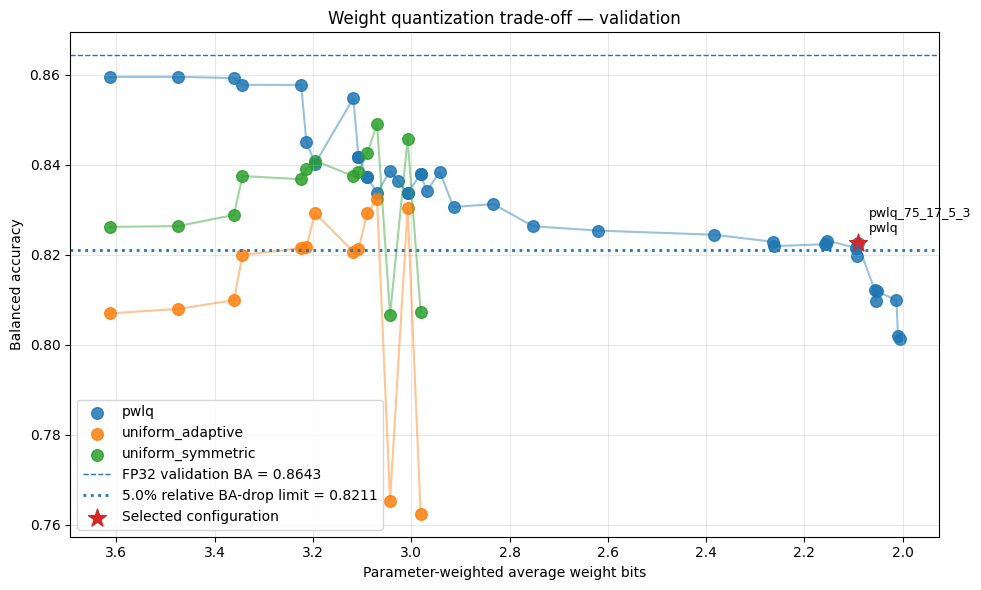

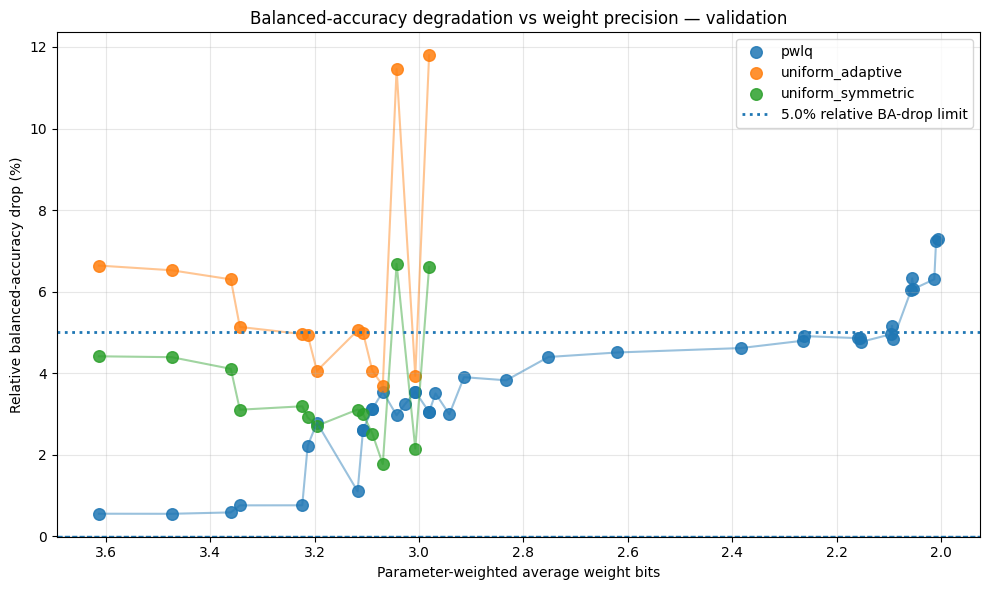


All displayed results are VALIDATION results.
TEST SET remains locked / not evaluated.


In [ ]:
# =========================================================
# COLLECT + DISPLAY MIXED-PRECISION RESULTS
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# COLLECT RESULTS
# =========================================================

def collect_quant_results(
    *result_objects
):

    """
    Combine multiple run_weight_budget_search()
    outputs into one DataFrame.

    Duplicate configurations that were rerun are
    removed, keeping the most recent result.
    """

    dfs = []

    for i, res in enumerate(
        result_objects
    ):

        if res is None:
            continue

        if (
            isinstance(res, dict)
            and
            "df_results" in res
        ):

            df = (
                res[
                    "df_results"
                ]
                .copy()
            )

            df[
                "run_id"
            ] = i

            dfs.append(
                df
            )

        elif isinstance(
            res,
            pd.DataFrame
        ):

            df = (
                res.copy()
            )

            df[
                "run_id"
            ] = i

            dfs.append(
                df
            )

        else:

            print(
                f"Skipping object {i}: "
                f"not a result dict "
                f"or DataFrame."
            )

    if len(
        dfs
    ) == 0:

        raise ValueError(
            "No valid result DataFrames found."
        )

    df_all = pd.concat(
        dfs,
        ignore_index=True
    )

    # -----------------------------------------------------
    # Remove exact configuration duplicates.
    #
    # A configuration is defined by:
    #   budget + weight mode
    #
    # Keep most recent run.
    # -----------------------------------------------------

    df_all = (
        df_all
        .drop_duplicates(
            subset=[
                "budget",
                "weight_mode"
            ],
            keep="last"
        )
        .reset_index(
            drop=True
        )
    )

    return df_all


# =========================================================
# GET FP32 VALIDATION BA
# =========================================================

def get_fp32_ba_from_results(
    *result_objects
):

    """
    Obtain canonical FP32 validation BA from the
    stored run_weight_budget_search() results.
    """

    values = []

    for res in result_objects:

        if (
            isinstance(res, dict)
            and
            "fp32_metrics" in res
            and
            res["fp32_metrics"] is not None
        ):

            metrics = (
                res[
                    "fp32_metrics"
                ]
            )

            if (
                "balanced_accuracy"
                in metrics
            ):

                values.append(
                    float(
                        metrics[
                            "balanced_accuracy"
                        ]
                    )
                )

    if len(
        values
    ) == 0:

        raise ValueError(
            "Could not find FP32 balanced accuracy "
            "in result objects."
        )

    # They should all be identical because every
    # search uses the same canonical FP32 model and val_ds.
    if not np.allclose(
        values,
        values[0],
        atol=1e-8
    ):

        print(
            "WARNING: FP32 validation BA differs "
            "between search runs:"
        )

        print(
            values
        )

    return float(
        values[0]
    )


# =========================================================
# SELECT BEST CONFIGURATION
# =========================================================

def select_best_weight_configuration(
    df_all,
    max_drop_pct=5.0
):

    """
    Same predefined selection rule used by the search:

      1. BA degradation <= max_drop_pct
      2. lowest parameter-weighted avg_weight_bits
      3. highest validation balanced accuracy as tie-break
    """

    df = (
        df_all.copy()
    )

    valid = df[
        df[
            "ba_drop_pct"
        ]
        <= max_drop_pct
    ].copy()

    if len(
        valid
    ) == 0:

        return None

    best = (
        valid
        .sort_values(
            [
                "avg_weight_bits",
                "balanced_accuracy"
            ],
            ascending=[
                True,
                False
            ]
        )
        .iloc[0]
    )

    return best


# =========================================================
# TRADE-OFF PLOT
# =========================================================

def plot_quant_tradeoff(
    df_all,
    fp32_ba,
    max_drop_pct=5.0,
    title=(
        "Weight quantization trade-off "
        "— validation"
    ),
    annotate_best=True
):

    df = (
        df_all.copy()
    )

    allowed_ba = (
        fp32_ba
        * (
            1.0
            - max_drop_pct / 100.0
        )
    )

    plt.figure(
        figsize=(
            10,
            6
        )
    )

    for mode in sorted(
        df[
            "weight_mode"
        ].unique()
    ):

        sub = df[
            df[
                "weight_mode"
            ]
            == mode
        ].copy()

        sub = (
            sub.sort_values(
                "avg_weight_bits"
            )
        )

        plt.scatter(
            sub[
                "avg_weight_bits"
            ],
            sub[
                "balanced_accuracy"
            ],
            label=mode,
            s=70,
            alpha=0.85
        )

        plt.plot(
            sub[
                "avg_weight_bits"
            ],
            sub[
                "balanced_accuracy"
            ],
            alpha=0.45
        )

    # FP32 reference
    plt.axhline(
        fp32_ba,
        linestyle="--",
        linewidth=1,
        label=(
            f"FP32 validation BA = "
            f"{fp32_ba:.4f}"
        )
    )

    # Allowed degradation threshold
    plt.axhline(
        allowed_ba,
        linestyle=":",
        linewidth=2,
        label=(
            f"{max_drop_pct:.1f}% "
            f"relative BA-drop limit "
            f"= {allowed_ba:.4f}"
        )
    )

    # -----------------------------------------------------
    # Selected configuration
    # -----------------------------------------------------

    if annotate_best:

        best = (
            select_best_weight_configuration(
                df,
                max_drop_pct=max_drop_pct
            )
        )

        if best is not None:

            plt.scatter(
                [
                    best[
                        "avg_weight_bits"
                    ]
                ],
                [
                    best[
                        "balanced_accuracy"
                    ]
                ],
                s=180,
                marker="*",
                label=(
                    "Selected configuration"
                )
            )

            plt.annotate(
                (
                    f"{best['budget']}\n"
                    f"{best['weight_mode']}"
                ),
                xy=(
                    best[
                        "avg_weight_bits"
                    ],
                    best[
                        "balanced_accuracy"
                    ]
                ),
                xytext=(
                    8,
                    8
                ),
                textcoords=(
                    "offset points"
                ),
                fontsize=9
            )

    plt.xlabel(
        "Parameter-weighted average weight bits"
    )

    plt.ylabel(
        "Balanced accuracy"
    )

    plt.title(
        title
    )

    plt.grid(
        True,
        alpha=0.3
    )

    plt.legend()

    # Lower precision / greater compression appears
    # toward the right.
    plt.gca().invert_xaxis()

    plt.tight_layout()

    plt.show()


# =========================================================
# BA DROP PLOT
# =========================================================

def plot_ba_drop_vs_bits(
    df_all,
    max_drop_pct=5.0,
    title=(
        "Balanced-accuracy degradation vs "
        "weight precision — validation"
    )
):

    df = (
        df_all.copy()
    )

    plt.figure(
        figsize=(
            10,
            6
        )
    )

    for mode in sorted(
        df[
            "weight_mode"
        ].unique()
    ):

        sub = df[
            df[
                "weight_mode"
            ]
            == mode
        ].copy()

        sub = (
            sub.sort_values(
                "avg_weight_bits"
            )
        )

        plt.scatter(
            sub[
                "avg_weight_bits"
            ],
            sub[
                "ba_drop_pct"
            ],
            label=mode,
            s=70,
            alpha=0.85
        )

        plt.plot(
            sub[
                "avg_weight_bits"
            ],
            sub[
                "ba_drop_pct"
            ],
            alpha=0.45
        )

    plt.axhline(
        max_drop_pct,
        linestyle=":",
        linewidth=2,
        label=(
            f"{max_drop_pct:.1f}% "
            f"relative BA-drop limit"
        )
    )

    plt.axhline(
        0.0,
        linestyle="--",
        linewidth=1
    )

    plt.xlabel(
        "Parameter-weighted average weight bits"
    )

    plt.ylabel(
        "Relative balanced-accuracy drop (%)"
    )

    plt.title(
        title
    )

    plt.grid(
        True,
        alpha=0.3
    )

    plt.legend()

    plt.gca().invert_xaxis()

    plt.tight_layout()

    plt.show()


# =========================================================
# COMBINE ALL THREE SEARCHES
# =========================================================

df_all = collect_quant_results(

    results,

    results_pwlq_aggressive,

    results_pwlq_more_aggressive
)


# =========================================================
# CANONICAL FP32 VALIDATION REFERENCE
# =========================================================

fp32_validation_ba = (
    get_fp32_ba_from_results(

        results,

        results_pwlq_aggressive,

        results_pwlq_more_aggressive
    )
)


print(
    f"FP32 validation BA: "
    f"{fp32_validation_ba:.6f}"
)


# =========================================================
# GLOBAL SELECTION ACROSS ALL SEARCHES
# =========================================================

best_weight_config = (
    select_best_weight_configuration(
        df_all,
        max_drop_pct=MAX_BA_DROP_PCT
    )
)


if best_weight_config is not None:

    print(
        "\n"
        + "=" * 90
    )

    print(
        "SELECTED WEIGHT CONFIGURATION "
        "— VALIDATION"
    )

    print(
        "=" * 90
    )

    print(
        best_weight_config.to_string()
    )

else:

    print(
        "\nNo configuration satisfied "
        "the validation BA degradation limit."
    )


# =========================================================
# SORTED RESULTS TABLE
# =========================================================

df_display = (
    df_all
    .sort_values(
        [
            "accepted",
            "avg_weight_bits",
            "balanced_accuracy"
        ],
        ascending=[
            False,
            True,
            False
        ]
    )
    .reset_index(
        drop=True
    )
)


display_columns = [

    "budget",

    "weight_mode",

    "avg_channel_bits",

    "avg_weight_bits",

    "accuracy",

    "balanced_accuracy",

    "ba_drop_pct",

    "accepted",

    "macro_f1"
]


display(
    df_display[
        display_columns
    ].round(
        6
    )
)


# =========================================================
# PLOTS
# =========================================================

plot_quant_tradeoff(

    df_all,

    fp32_ba=fp32_validation_ba,

    max_drop_pct=MAX_BA_DROP_PCT,

    title=(
        "Weight quantization trade-off "
        "— validation"
    )
)


plot_ba_drop_vs_bits(

    df_all,

    max_drop_pct=MAX_BA_DROP_PCT,

    title=(
        "Balanced-accuracy degradation vs "
        "weight precision — validation"
    )
)


print(
    "\nAll displayed results are VALIDATION results."
)

print(
    "TEST SET remains locked / not evaluated."
)


FROZEN WEIGHT CONFIGURATION FOR ACTIVATION SWEEP
Budget:      pwlq_75_17_5_3
Weight mode: pwlq
Avg W bits:  2.0917
Validation BA: 0.822552

ACTIVATION QUANTIZATION SWEEP — VALIDATION
Weight configuration: pwlq_75_17_5_3
Weight mode:          pwlq
Avg channel bits:     2.4517
Avg weight bits:      2.0917
FP32 validation BA:   0.864336
Activation bits:      (8, 4, 3, 2)
Activation clip:      99.900%
Maximum total BA drop: 8.00%
Calibration:          fixed calib_ds
Selection:            val_ds
Test set:             LOCKED

  WEIGHT QUANTIZATION: pwlq
  conv2d                     avg=4.25b | 2b:2 | 3b:8 | 4b:2 | 8b:4
  conv2d_1                   avg=2.69b | 2b:10 | 3b:22
  conv2d_2                   avg=2.61b | 2b:27 | 3b:35 | 4b:2
  conv2d_3                   avg=2.41b | 2b:81 | 3b:41 | 4b:6
  dense                      avg=2.00b | 2b:255 | 3b:1
  dense_1                    avg=2.01b | 2b:127 | 3b:1
  dense_2                    avg=2.58b | 2b:10 | 3b:1 | 8b:1
  conv2d_4                  

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(



pwlq_75_17_5_3 | pwlq | Wmixed-A8
Loss:              0.672258
Accuracy:          0.815849 (81.585%)
Balanced Accuracy: 0.813316 (81.332%)
Precision (macro): 0.718986 (71.899%)
Recall (macro):    0.813316 (81.332%)
Macro F1:          0.728443 (72.844%)

Total relative BA drop from FP32: 5.903%
Accepted under 8.0% rule: True

VALIDATING Wmixed-A4

  WEIGHT QUANTIZATION: pwlq
  conv2d                     avg=4.25b | 2b:2 | 3b:8 | 4b:2 | 8b:4
  conv2d_1                   avg=2.69b | 2b:10 | 3b:22
  conv2d_2                   avg=2.61b | 2b:27 | 3b:35 | 4b:2
  conv2d_3                   avg=2.41b | 2b:81 | 3b:41 | 4b:6
  dense                      avg=2.00b | 2b:255 | 3b:1
  dense_1                    avg=2.01b | 2b:127 | 3b:1
  dense_2                    avg=2.58b | 2b:10 | 3b:1 | 8b:1
  conv2d_4                   avg=4.19b | 2b:2 | 3b:9 | 4b:1 | 8b:4
  conv2d_5                   avg=2.44b | 2b:18 | 3b:14
  conv2d_6                   avg=2.22b | 2b:50 | 3b:14
  conv2d_7                   

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(



pwlq_75_17_5_3 | pwlq | Wmixed-A4
Loss:              1.132876
Accuracy:          0.800701 (80.070%)
Balanced Accuracy: 0.811770 (81.177%)
Precision (macro): 0.698557 (69.856%)
Recall (macro):    0.811770 (81.177%)
Macro F1:          0.715892 (71.589%)

Total relative BA drop from FP32: 6.082%
Accepted under 8.0% rule: True

VALIDATING Wmixed-A3

  WEIGHT QUANTIZATION: pwlq
  conv2d                     avg=4.25b | 2b:2 | 3b:8 | 4b:2 | 8b:4
  conv2d_1                   avg=2.69b | 2b:10 | 3b:22
  conv2d_2                   avg=2.61b | 2b:27 | 3b:35 | 4b:2
  conv2d_3                   avg=2.41b | 2b:81 | 3b:41 | 4b:6
  dense                      avg=2.00b | 2b:255 | 3b:1
  dense_1                    avg=2.01b | 2b:127 | 3b:1
  dense_2                    avg=2.58b | 2b:10 | 3b:1 | 8b:1
  conv2d_4                   avg=4.19b | 2b:2 | 3b:9 | 4b:1 | 8b:4
  conv2d_5                   avg=2.44b | 2b:18 | 3b:14
  conv2d_6                   avg=2.22b | 2b:50 | 3b:14
  conv2d_7                   

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(



pwlq_75_17_5_3 | pwlq | Wmixed-A3
Loss:              1.761482
Accuracy:          0.774732 (77.473%)
Balanced Accuracy: 0.807386 (80.739%)
Precision (macro): 0.660579 (66.058%)
Recall (macro):    0.807386 (80.739%)
Macro F1:          0.699159 (69.916%)

Total relative BA drop from FP32: 6.589%
Accepted under 8.0% rule: True

VALIDATING Wmixed-A2

  WEIGHT QUANTIZATION: pwlq
  conv2d                     avg=4.25b | 2b:2 | 3b:8 | 4b:2 | 8b:4
  conv2d_1                   avg=2.69b | 2b:10 | 3b:22
  conv2d_2                   avg=2.61b | 2b:27 | 3b:35 | 4b:2
  conv2d_3                   avg=2.41b | 2b:81 | 3b:41 | 4b:6
  dense                      avg=2.00b | 2b:255 | 3b:1
  dense_1                    avg=2.01b | 2b:127 | 3b:1
  dense_2                    avg=2.58b | 2b:10 | 3b:1 | 8b:1
  conv2d_4                   avg=4.19b | 2b:2 | 3b:9 | 4b:1 | 8b:4
  conv2d_5                   avg=2.44b | 2b:18 | 3b:14
  conv2d_6                   avg=2.22b | 2b:50 | 3b:14
  conv2d_7                   

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(



pwlq_75_17_5_3 | pwlq | Wmixed-A2
Loss:              11.777306
Accuracy:          0.220734 (22.073%)
Balanced Accuracy: 0.447516 (44.752%)
Precision (macro): 0.500026 (50.003%)
Recall (macro):    0.447516 (44.752%)
Macro F1:          0.335253 (33.525%)

Total relative BA drop from FP32: 48.224%
Accepted under 8.0% rule: False

ACTIVATION SWEEP SUMMARY — VALIDATION
        budget weight_mode  avg_weight_bits activation_bits configuration  balanced_accuracy  ba_drop_pct  accepted_final  accuracy  macro_f1  precision_macro  recall_macro
pwlq_75_17_5_3        pwlq         2.091709            FP32    Wmixed-A32           0.822552     4.834288            True  0.819353  0.734981         0.720081      0.822552
pwlq_75_17_5_3        pwlq         2.091709               8     Wmixed-A8           0.813316     5.902861            True  0.815849  0.728443         0.718986      0.813316
pwlq_75_17_5_3        pwlq         2.091709               4     Wmixed-A4           0.811770     6.081617        

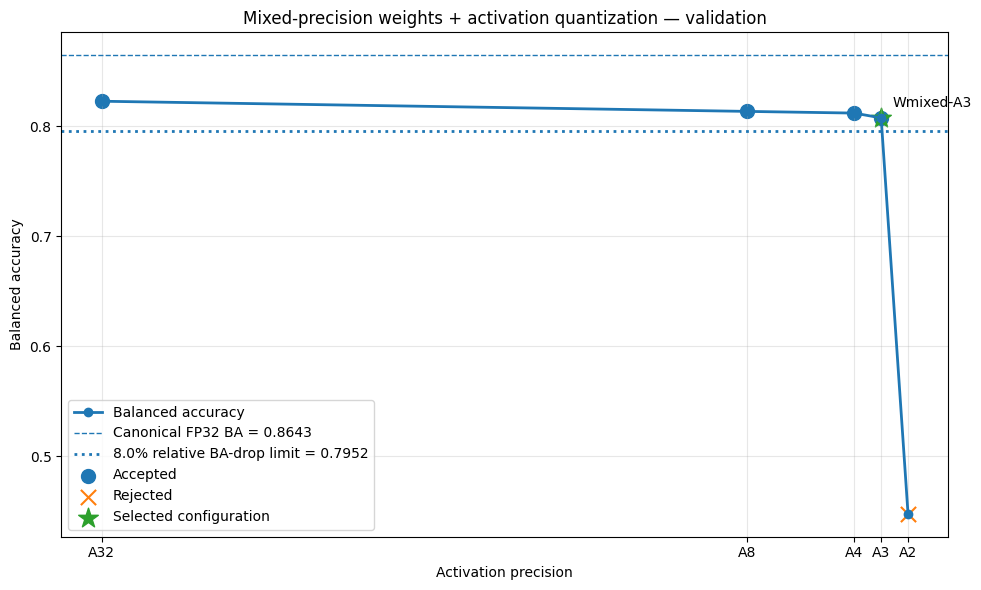

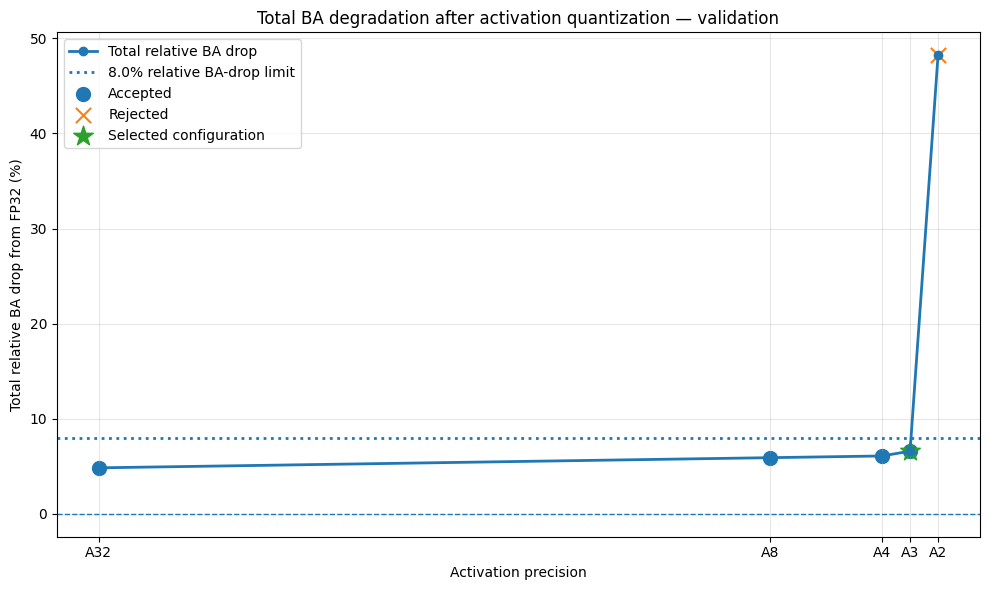


ACTIVATION SELECTION COMPLETE
Selected configuration: Wmixed-A3
Validation BA: 0.807386
Total relative BA drop: 6.589%

TEST SET remains LOCKED / NOT EVALUATED.


In [ ]:
# =========================================================
# ACTIVATION QUANTIZATION SWEEP — COMPLETE REVISION CELL
# =========================================================
#
# Protocol:
#
#   1. Weight configuration must already have been selected
#      using VALIDATION results.
#
#   2. Activation statistics are collected ONLY from the
#      fixed 1024-sample calib_ds.
#
#   3. A8 / A4 / A3 / A2 are evaluated on val_ds.
#
#   4. Selection rule:
#        - total relative BA drop from FP32 <= 8%
#        - among accepted configs, choose lowest act bits
#        - validation BA is tie-breaker
#
#   5. test_ds is NOT used anywhere in this cell.
#
# =========================================================

import gc
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt


# =========================================================
# GLOBAL ACTIVATION-SWEEP SETTINGS
# =========================================================

ACTIVATION_BITS = (
    8,
    4,
    3,
    2
)

ACT_CLIP_PERCENTILE = 0.999

MAX_FINAL_BA_DROP_PCT = 8.0

SCALE_BITS = 0
BREAK_POINT = "norm"
PW_OPT = 2
APPROXIMATE = True


# =========================================================
# ITERATE THROUGH ALL MODEL LAYERS
# =========================================================

def _iter_all_layers(model):

    for layer in model.layers:

        yield layer

        if hasattr(
            layer,
            "layers"
        ):

            yield from _iter_all_layers(
                layer
            )


# =========================================================
# COLLECT ACTIVATION STATISTICS
# =========================================================

def _collect_activation_stats_for_layers(
    model,
    calib_ds,
    target_layer_names,
    act_clip_percentile=0.999
):

    """
    Collect fixed activation clipping statistics from
    calib_ds for the selected layers.

    One activation quantizer is defined per selected layer.

    No validation or test samples are used here.
    """

    act_stats = {}

    weight_layers = (
        collect_all_weight_layers(
            model
        )
    )

    for layer in weight_layers:

        if (
            layer.name
            not in target_layer_names
        ):
            continue

        _, outputs = (
            capture_layer_activations(
                model,
                layer,
                calib_ds
            )
        )

        if not outputs:
            continue

        # -------------------------------------------------
        # Concatenate calibration activations.
        # -------------------------------------------------

        all_acts = np.concatenate(
            [
                (
                    a.numpy()
                    if hasattr(a, "numpy")
                    else np.asarray(a)
                ).reshape(-1)

                for a in outputs
            ]
        )

        if all_acts.size == 0:
            continue

        # -------------------------------------------------
        # Signed quantization is required if the layer
        # produces any negative activation.
        # -------------------------------------------------

        signed = bool(
            np.min(all_acts) < 0
        )

        # -------------------------------------------------
        # Activation clipping threshold.
        #
        # We use magnitude percentile for both signed and
        # unsigned activations.
        # -------------------------------------------------

        clip_hi = float(
            np.percentile(
                np.abs(all_acts),
                act_clip_percentile * 100.0
            )
        )

        # Protect against zero-valued activation ranges.
        clip_hi = max(
            clip_hi,
            1e-8
        )

        act_stats[
            layer.name
        ] = {

            "signed":
                signed,

            "clip_hi":
                clip_hi,

            "clip_percentile":
                act_clip_percentile
        }

    return act_stats


# =========================================================
# PATCH FIXED ACTIVATION QUANTIZERS
# =========================================================

def _patch_fixed_activation_bits(
    model,
    act_stats,
    act_bits
):

    """
    Apply fake activation quantization after the output
    of each selected layer.

    All selected layers use the same activation bit-width.

    Signed activations:
        symmetric signed quantization

    Non-negative activations:
        unsigned quantization
    """

    if int(
        act_bits
    ) < 2:

        raise ValueError(
            "Activation bit-width must be >= 2."
        )

    patched = {}

    # -----------------------------------------------------
    # BUILD ONE QUANTIZER
    # -----------------------------------------------------

    def make_qfn(
        bits,
        signed,
        clip_hi
    ):

        clip_hi = float(
            clip_hi
        )

        clip_hi_tf = tf.constant(
            clip_hi,
            dtype=tf.float32
        )

        if signed:

            qmax = (
                2 ** (
                    bits - 1
                )
                - 1
            )

            qmin = -(
                2 ** (
                    bits - 1
                )
            )

            scale = (
                clip_hi
                / qmax
            )

        else:

            qmax = (
                2 ** bits
                - 1
            )

            qmin = 0

            scale = (
                clip_hi
                / qmax
            )

        scale = max(
            float(scale),
            1e-8
        )

        scale_tf = tf.constant(
            scale,
            dtype=tf.float32
        )

        def qfn(x):

            if signed:

                x_c = tf.clip_by_value(
                    x,
                    -clip_hi_tf,
                    clip_hi_tf
                )

            else:

                x_c = tf.clip_by_value(
                    x,
                    0.0,
                    clip_hi_tf
                )

            q = tf.round(
                x_c
                / scale_tf
            )

            q = tf.clip_by_value(
                q,
                float(qmin),
                float(qmax)
            )

            return (
                q
                * scale_tf
            )

        return (
            qfn,
            scale,
            qmin,
            qmax
        )

    # -----------------------------------------------------
    # PATCH LAYER CALL
    # -----------------------------------------------------

    def make_patched_call(
        original_call,
        qfn
    ):

        def patched_call(
            inputs,
            *args,
            **kwargs
        ):

            out = original_call(
                inputs,
                *args,
                **kwargs
            )

            return qfn(
                out
            )

        return patched_call

    # -----------------------------------------------------
    # APPLY QUANTIZERS
    # -----------------------------------------------------

    for layer in (
        _iter_all_layers(
            model
        )
    ):

        if (
            layer.name
            not in act_stats
        ):
            continue

        stats = (
            act_stats[
                layer.name
            ]
        )

        (
            qfn,
            scale,
            qmin,
            qmax
        ) = make_qfn(

            bits=int(
                act_bits
            ),

            signed=stats[
                "signed"
            ],

            clip_hi=stats[
                "clip_hi"
            ]
        )

        original_call = (
            layer.call
        )

        layer.call = (
            make_patched_call(
                original_call,
                qfn
            )
        )

        patched[
            layer.name
        ] = {

            "bits":
                int(
                    act_bits
                ),

            "signed":
                stats[
                    "signed"
                ],

            "clip_hi":
                stats[
                    "clip_hi"
                ],

            "scale":
                scale,

            "qmin":
                qmin,

            "qmax":
                qmax
        }

    print(
        f"Activation quantizers patched: "
        f"{len(patched)} layers "
        f"at A{act_bits}"
    )

    return patched


# =========================================================
# HELPER — GET METRIC WITH EITHER NAMING CONVENTION
# =========================================================

def _get_metric(
    metrics,
    *names
):

    for name in names:

        if name in metrics:

            return metrics[
                name
            ]

    return np.nan


# =========================================================
# ACTIVATION SWEEP ON FIXED WEIGHT CONFIGURATION
# =========================================================

def run_activation_sweep_on_weight_config(
    calib_ds,
    val_ds,
    weight_result_obj,
    budget_name,
    weight_mode="pwlq",
    activation_bits=(
        8,
        4,
        3,
        2
    ),
    act_clip_percentile=0.999,
    max_final_ba_drop_pct=8.0,
    scale_bits=0,
    break_point="norm",
    pw_opt=2,
    approximate=True
):

    """
    Freeze one previously selected weight configuration
    and sweep activation precision on VALIDATION.

    The FP32 reference is the canonical FP32 validation BA.

    The weight-only configuration is also evaluated so that
    Wmixed-A32 is explicitly reported.

    Selection:
        total relative BA drop <= threshold,
        then lowest activation bits,
        then highest validation BA.
    """

    key = (
        budget_name,
        weight_mode
    )

    # -----------------------------------------------------
    # VERIFY WEIGHT CONFIGURATION EXISTS
    # -----------------------------------------------------

    if (
        key
        not in weight_result_obj[
            "saved_configs"
        ]
    ):

        raise KeyError(

            f"{key} not found in saved_configs.\n\n"

            f"Available keys:\n"

            f"{list(weight_result_obj['saved_configs'].keys())}"
        )

    layer_records = copy.deepcopy(
        weight_result_obj[
            "saved_configs"
        ][
            key
        ][
            "layer_records"
        ]
    )

    budget_info = copy.deepcopy(
        weight_result_obj[
            "saved_configs"
        ][
            key
        ][
            "budget_info"
        ]
    )

    # -----------------------------------------------------
    # CANONICAL FP32 VALIDATION REFERENCE
    # -----------------------------------------------------

    fp32_ba = float(
        weight_result_obj[
            "fp32_metrics"
        ][
            "balanced_accuracy"
        ]
    )

    print(
        "\n"
        + "=" * 100
    )

    print(
        "ACTIVATION QUANTIZATION SWEEP — VALIDATION"
    )

    print(
        "=" * 100
    )

    print(
        f"Weight configuration: "
        f"{budget_name}"
    )

    print(
        f"Weight mode:          "
        f"{weight_mode}"
    )

    print(
        f"Avg channel bits:     "
        f"{budget_info['avg_channel_bits']:.4f}"
    )

    print(
        f"Avg weight bits:      "
        f"{budget_info['avg_weight_bits']:.4f}"
    )

    print(
        f"FP32 validation BA:   "
        f"{fp32_ba:.6f}"
    )

    print(
        f"Activation bits:      "
        f"{activation_bits}"
    )

    print(
        f"Activation clip:      "
        f"{act_clip_percentile * 100:.3f}%"
    )

    print(
        f"Maximum total BA drop:"
        f" {max_final_ba_drop_pct:.2f}%"
    )

    print(
        "Calibration:          fixed calib_ds"
    )

    print(
        "Selection:            val_ds"
    )

    print(
        "Test set:             LOCKED"
    )

    print(
        "=" * 100
    )

    # =====================================================
    # BUILD WEIGHT-ONLY MODEL
    # =====================================================

    base_w_model = (
        load_fresh_model()
    )

    base_w_model = (
        quantize_model_from_budget_records(

            model=base_w_model,

            layer_records=layer_records,

            weight_mode=weight_mode,

            scale_bits=scale_bits,

            break_point=break_point,

            pw_opt=pw_opt,

            approximate=approximate
        )
    )

    # =====================================================
    # COLLECT ACTIVATION STATISTICS
    # =====================================================
    #
    # IMPORTANT:
    # Statistics are collected on the fixed weight-
    # quantized model, with activations still FP32.
    #
    # Only calib_ds is used.
    # =====================================================

    target_layer_names = [

        rec[
            "layer_name"
        ]

        for rec
        in layer_records
    ]

    print(
        "\n"
        + "=" * 90
    )

    print(
        "COLLECTING ACTIVATION STATISTICS "
        "ON FIXED WEIGHT MODEL"
    )

    print(
        "=" * 90
    )

    act_stats = (
        _collect_activation_stats_for_layers(

            model=base_w_model,

            calib_ds=calib_ds,

            target_layer_names=target_layer_names,

            act_clip_percentile=act_clip_percentile
        )
    )

    print(
        f"Collected activation statistics "
        f"for {len(act_stats)} layers."
    )

    # =====================================================
    # Wmixed-A32 REFERENCE
    # =====================================================

    print(
        "\n"
        + "=" * 90
    )

    print(
        "WEIGHT-ONLY REFERENCE — Wmixed-A32"
    )

    print(
        "=" * 90
    )

    weight_only_metrics = (
        compile_and_evaluate(

            base_w_model,

            val_ds,

            label=(
                f"{budget_name} | "
                f"{weight_mode} | "
                f"Wmixed-A32"
            )
        )
    )

    weight_only_ba = float(
        weight_only_metrics[
            "balanced_accuracy"
        ]
    )

    weight_only_drop_pct = (

        100.0
        * (
            fp32_ba
            - weight_only_ba
        )
        / max(
            fp32_ba,
            1e-10
        )
    )

    rows_list = []

    rows_list.append({

        "budget":
            budget_name,

        "weight_mode":
            weight_mode,

        "avg_weight_bits":
            budget_info[
                "avg_weight_bits"
            ],

        "activation_bits":
            "FP32",

        "configuration":
            "Wmixed-A32",

        "balanced_accuracy":
            weight_only_ba,

        "ba_drop_pct":
            weight_only_drop_pct,

        "accepted_final":
            (
                weight_only_drop_pct
                <= max_final_ba_drop_pct
            ),

        "accuracy":
            weight_only_metrics[
                "accuracy"
            ],

        "macro_f1":
            weight_only_metrics[
                "macro_f1"
            ],

        "precision_macro":
            _get_metric(
                weight_only_metrics,
                "precision_macro",
                "macro_precision"
            ),

        "recall_macro":
            _get_metric(
                weight_only_metrics,
                "recall_macro",
                "macro_recall"
            )
    })

    # Base model is no longer required.
    del base_w_model

    tf.keras.backend.clear_session()
    gc.collect()

    # =====================================================
    # ACTIVATION BIT SWEEP
    # =====================================================

    for act_bits in (
        activation_bits
    ):

        act_bits = int(
            act_bits
        )

        print(
            "\n"
            + "=" * 90
        )

        print(
            f"VALIDATING Wmixed-A{act_bits}"
        )

        print(
            "=" * 90
        )

        # -------------------------------------------------
        # Always start from canonical FP32.
        # -------------------------------------------------

        model_q = (
            load_fresh_model()
        )

        # -------------------------------------------------
        # Reapply frozen weight configuration.
        # -------------------------------------------------

        model_q = (
            quantize_model_from_budget_records(

                model=model_q,

                layer_records=layer_records,

                weight_mode=weight_mode,

                scale_bits=scale_bits,

                break_point=break_point,

                pw_opt=pw_opt,

                approximate=approximate
            )
        )

        # -------------------------------------------------
        # Apply fixed activation quantization.
        #
        # Statistics come from calib_ds.
        # -------------------------------------------------

        patched_stats = (
            _patch_fixed_activation_bits(

                model=model_q,

                act_stats=act_stats,

                act_bits=act_bits
            )
        )

        if (
            len(patched_stats)
            != len(act_stats)
        ):

            raise RuntimeError(
                "Not all activation quantizers "
                "were successfully patched."
            )

        # -------------------------------------------------
        # VALIDATION ONLY
        # -------------------------------------------------

        metrics = (
            compile_and_evaluate(

                model_q,

                val_ds,

                label=(
                    f"{budget_name} | "
                    f"{weight_mode} | "
                    f"Wmixed-A{act_bits}"
                )
            )
        )

        ba = float(
            metrics[
                "balanced_accuracy"
            ]
        )

        # Total degradation is measured against
        # canonical FP32, NOT against Wmixed-A32.
        ba_drop_pct = (

            100.0
            * (
                fp32_ba
                - ba
            )
            / max(
                fp32_ba,
                1e-10
            )
        )

        accepted = (
            ba_drop_pct
            <= max_final_ba_drop_pct
        )

        rows_list.append({

            "budget":
                budget_name,

            "weight_mode":
                weight_mode,

            "avg_weight_bits":
                budget_info[
                    "avg_weight_bits"
                ],

            "activation_bits":
                act_bits,

            "configuration":
                f"Wmixed-A{act_bits}",

            "balanced_accuracy":
                ba,

            "ba_drop_pct":
                ba_drop_pct,

            "accepted_final":
                accepted,

            "accuracy":
                metrics[
                    "accuracy"
                ],

            "macro_f1":
                metrics[
                    "macro_f1"
                ],

            "precision_macro":
                _get_metric(
                    metrics,
                    "precision_macro",
                    "macro_precision"
                ),

            "recall_macro":
                _get_metric(
                    metrics,
                    "recall_macro",
                    "macro_recall"
                )
        })

        print(
            f"\nTotal relative BA drop "
            f"from FP32: "
            f"{ba_drop_pct:.3f}%"
        )

        print(
            f"Accepted under "
            f"{max_final_ba_drop_pct:.1f}% rule: "
            f"{accepted}"
        )

        # -------------------------------------------------
        # CLEANUP
        # -------------------------------------------------

        del patched_stats
        del model_q

        tf.keras.backend.clear_session()
        gc.collect()

    # =====================================================
    # BUILD RESULT TABLE
    # =====================================================

    df_act_sweep = pd.DataFrame(
        rows_list
    )

    print(
        "\n"
        + "=" * 100
    )

    print(
        "ACTIVATION SWEEP SUMMARY — VALIDATION"
    )

    print(
        "=" * 100
    )

    print(
        df_act_sweep.to_string(
            index=False
        )
    )

    # =====================================================
    # SELECTION RULE
    # =====================================================
    #
    # FP32 activations are included as Wmixed-A32 reference,
    # but activation quantization selection first considers
    # actual quantized activation configurations.
    #
    # Rule:
    #
    #   1. total relative BA drop <= 8%
    #   2. lowest activation bit-width
    #   3. highest BA as tie-break
    #
    # If no quantized activation setting satisfies the
    # threshold, fall back to Wmixed-A32.
    #
    # =====================================================

    quantized_valid = (
        df_act_sweep[
            (
                df_act_sweep[
                    "activation_bits"
                ]
                != "FP32"
            )
            &
            (
                df_act_sweep[
                    "accepted_final"
                ]
                == True
            )
        ]
        .copy()
    )

    if len(
        quantized_valid
    ) > 0:

        quantized_valid[
            "_act_bits_numeric"
        ] = (
            quantized_valid[
                "activation_bits"
            ]
            .astype(int)
        )

        best = (
            quantized_valid
            .sort_values(
                [
                    "_act_bits_numeric",
                    "balanced_accuracy"
                ],
                ascending=[
                    True,
                    False
                ]
            )
            .iloc[0]
            .drop(
                labels=[
                    "_act_bits_numeric"
                ]
            )
        )

    else:

        # No quantized activation configuration met
        # the predefined threshold.
        fallback = (
            df_act_sweep[
                df_act_sweep[
                    "activation_bits"
                ]
                == "FP32"
            ]
        )

        if (
            len(fallback) > 0
            and
            bool(
                fallback.iloc[0][
                    "accepted_final"
                ]
            )
        ):

            best = (
                fallback.iloc[0]
            )

        else:

            best = None

    print(
        "\n"
        + "=" * 100
    )

    print(
        "SELECTED ACTIVATION CONFIGURATION "
        "— VALIDATION"
    )

    print(
        "=" * 100
    )

    if best is not None:

        print(
            best.to_string()
        )

    else:

        print(
            "No configuration satisfied "
            "the predefined BA degradation limit."
        )

    print(
        "\nTEST SET remains LOCKED / "
        "not evaluated."
    )

    return {

        "df_act_sweep":
            df_act_sweep,

        "best":
            best,

        "act_stats":
            act_stats,

        "layer_records":
            layer_records,

        "budget_info":
            budget_info,

        "fp32_ba":
            fp32_ba,

        "max_final_ba_drop_pct":
            max_final_ba_drop_pct
    }


# =========================================================
# SUMMARY FUNCTION
# =========================================================

def summarize_activation_results(
    activation_results
):

    """
    Display the activation sweep and the configuration
    selected by the SAME rule used during the sweep.
    """

    df = (
        activation_results[
            "df_act_sweep"
        ]
        .copy()
    )

    best = (
        activation_results.get(
            "best",
            None
        )
    )

    fp32_ba = (
        activation_results[
            "fp32_ba"
        ]
    )

    max_drop = (
        activation_results[
            "max_final_ba_drop_pct"
        ]
    )

    print(
        "\n"
        + "=" * 100
    )

    print(
        "ACTIVATION QUANTIZATION RESULTS "
        "— VALIDATION"
    )

    print(
        "=" * 100
    )

    print(
        f"Canonical FP32 BA: "
        f"{fp32_ba:.6f}"
    )

    print(
        f"Maximum relative BA drop: "
        f"{max_drop:.2f}%"
    )

    print(
        "\n"
        + df.to_string(
            index=False
        )
    )

    print(
        "\n"
        + "=" * 100
    )

    print(
        "SELECTED CONFIGURATION"
    )

    print(
        "=" * 100
    )

    if best is None:

        print(
            "No configuration satisfied "
            "the predefined criterion."
        )

        return None

    print(
        best.to_string()
    )

    return best


# =========================================================
# PLOT — BALANCED ACCURACY
# =========================================================

def plot_activation_sweep(
    activation_results,
    title=(
        "Mixed-precision weights + "
        "activation quantization — validation"
    )
):

    df = (
        activation_results[
            "df_act_sweep"
        ]
        .copy()
    )

    fp32_ba = float(
        activation_results[
            "fp32_ba"
        ]
    )

    max_drop = float(
        activation_results[
            "max_final_ba_drop_pct"
        ]
    )

    allowed_ba = (
        fp32_ba
        * (
            1.0
            - max_drop / 100.0
        )
    )

    df[
        "_act_bits_numeric"
    ] = (
        df[
            "activation_bits"
        ]
        .apply(
            lambda x:
                32
                if x == "FP32"
                else int(x)
        )
    )

    df = (
        df.sort_values(
            "_act_bits_numeric",
            ascending=False
        )
    )

    plt.figure(
        figsize=(
            10,
            6
        )
    )

    plt.plot(
        df[
            "_act_bits_numeric"
        ],
        df[
            "balanced_accuracy"
        ],
        marker="o",
        linewidth=2,
        label="Balanced accuracy"
    )

    # Canonical FP32 baseline
    plt.axhline(
        fp32_ba,
        linestyle="--",
        linewidth=1,
        label=(
            f"Canonical FP32 BA = "
            f"{fp32_ba:.4f}"
        )
    )

    # Acceptance threshold
    plt.axhline(
        allowed_ba,
        linestyle=":",
        linewidth=2,
        label=(
            f"{max_drop:.1f}% relative "
            f"BA-drop limit = "
            f"{allowed_ba:.4f}"
        )
    )

    accepted = (
        df[
            df[
                "accepted_final"
            ]
            == True
        ]
    )

    rejected = (
        df[
            df[
                "accepted_final"
            ]
            == False
        ]
    )

    if len(
        accepted
    ) > 0:

        plt.scatter(
            accepted[
                "_act_bits_numeric"
            ],
            accepted[
                "balanced_accuracy"
            ],
            s=100,
            marker="o",
            label="Accepted"
        )

    if len(
        rejected
    ) > 0:

        plt.scatter(
            rejected[
                "_act_bits_numeric"
            ],
            rejected[
                "balanced_accuracy"
            ],
            s=120,
            marker="x",
            label="Rejected"
        )

    # -----------------------------------------------------
    # Mark EXACT configuration selected by runner.
    # -----------------------------------------------------

    best = (
        activation_results.get(
            "best",
            None
        )
    )

    if best is not None:

        best_bits = (
            32
            if best[
                "activation_bits"
            ]
            == "FP32"
            else int(
                best[
                    "activation_bits"
                ]
            )
        )

        plt.scatter(
            [
                best_bits
            ],
            [
                best[
                    "balanced_accuracy"
                ]
            ],
            s=220,
            marker="*",
            label="Selected configuration"
        )

        plt.annotate(
            best[
                "configuration"
            ],
            xy=(
                best_bits,
                best[
                    "balanced_accuracy"
                ]
            ),
            xytext=(
                8,
                8
            ),
            textcoords=(
                "offset points"
            ),
            fontsize=10
        )

    # -----------------------------------------------------
    # X-axis
    # -----------------------------------------------------

    tick_values = (
        df[
            "_act_bits_numeric"
        ]
        .tolist()
    )

    tick_labels = [

        "A32"
        if x == 32
        else f"A{int(x)}"

        for x
        in tick_values
    ]

    plt.xticks(
        tick_values,
        tick_labels
    )

    plt.gca().invert_xaxis()

    plt.xlabel(
        "Activation precision"
    )

    plt.ylabel(
        "Balanced accuracy"
    )

    plt.title(
        title
    )

    plt.grid(
        True,
        alpha=0.3
    )

    plt.legend()

    plt.tight_layout()

    plt.show()


# =========================================================
# PLOT — TOTAL RELATIVE BA DROP
# =========================================================

def plot_activation_drop_sweep(
    activation_results,
    title=(
        "Total balanced-accuracy degradation "
        "after activation quantization — validation"
    )
):

    df = (
        activation_results[
            "df_act_sweep"
        ]
        .copy()
    )

    max_drop = float(
        activation_results[
            "max_final_ba_drop_pct"
        ]
    )

    df[
        "_act_bits_numeric"
    ] = (
        df[
            "activation_bits"
        ]
        .apply(
            lambda x:
                32
                if x == "FP32"
                else int(x)
        )
    )

    df = (
        df.sort_values(
            "_act_bits_numeric",
            ascending=False
        )
    )

    plt.figure(
        figsize=(
            10,
            6
        )
    )

    plt.plot(
        df[
            "_act_bits_numeric"
        ],
        df[
            "ba_drop_pct"
        ],
        marker="o",
        linewidth=2,
        label=(
            "Total relative BA drop"
        )
    )

    plt.axhline(
        max_drop,
        linestyle=":",
        linewidth=2,
        label=(
            f"{max_drop:.1f}% "
            f"relative BA-drop limit"
        )
    )

    plt.axhline(
        0.0,
        linestyle="--",
        linewidth=1
    )

    accepted = (
        df[
            df[
                "accepted_final"
            ]
            == True
        ]
    )

    rejected = (
        df[
            df[
                "accepted_final"
            ]
            == False
        ]
    )

    if len(
        accepted
    ) > 0:

        plt.scatter(
            accepted[
                "_act_bits_numeric"
            ],
            accepted[
                "ba_drop_pct"
            ],
            s=100,
            marker="o",
            label="Accepted"
        )

    if len(
        rejected
    ) > 0:

        plt.scatter(
            rejected[
                "_act_bits_numeric"
            ],
            rejected[
                "ba_drop_pct"
            ],
            s=120,
            marker="x",
            label="Rejected"
        )

    # Mark selected configuration
    best = (
        activation_results.get(
            "best",
            None
        )
    )

    if best is not None:

        best_bits = (
            32
            if best[
                "activation_bits"
            ]
            == "FP32"
            else int(
                best[
                    "activation_bits"
                ]
            )
        )

        plt.scatter(
            [
                best_bits
            ],
            [
                best[
                    "ba_drop_pct"
                ]
            ],
            s=220,
            marker="*",
            label="Selected configuration"
        )

    tick_values = (
        df[
            "_act_bits_numeric"
        ]
        .tolist()
    )

    tick_labels = [

        "A32"
        if x == 32
        else f"A{int(x)}"

        for x
        in tick_values
    ]

    plt.xticks(
        tick_values,
        tick_labels
    )

    plt.gca().invert_xaxis()

    plt.xlabel(
        "Activation precision"
    )

    plt.ylabel(
        "Total relative BA drop from FP32 (%)"
    )

    plt.title(
        title
    )

    plt.grid(
        True,
        alpha=0.3
    )

    plt.legend()

    plt.tight_layout()

    plt.show()


# =========================================================
# DETERMINE THE FROZEN WEIGHT CONFIGURATION
# =========================================================
#
# IMPORTANT:
#
# Do NOT automatically hard-code the OLD
# pwlq_85_10_2_3 result.
#
# The activation sweep should use the weight configuration
# selected by the REVISED validation search.
#
# df_all and best_weight_config come from the previous
# weight-search/results cell.
# =========================================================

if best_weight_config is None:

    raise RuntimeError(
        "No weight configuration was selected. "
        "Run the revised weight search first."
    )


selected_budget_name = str(
    best_weight_config[
        "budget"
    ]
)

selected_weight_mode = str(
    best_weight_config[
        "weight_mode"
    ]
)


print(
    "\n"
    + "=" * 100
)

print(
    "FROZEN WEIGHT CONFIGURATION FOR ACTIVATION SWEEP"
)

print(
    "=" * 100
)

print(
    f"Budget:      "
    f"{selected_budget_name}"
)

print(
    f"Weight mode: "
    f"{selected_weight_mode}"
)

print(
    f"Avg W bits:  "
    f"{best_weight_config['avg_weight_bits']:.4f}"
)

print(
    f"Validation BA: "
    f"{best_weight_config['balanced_accuracy']:.6f}"
)


# =========================================================
# FIND WHICH SEARCH RESULT OBJECT CONTAINS THE CONFIGURATION
# =========================================================
#
# Because we performed three weight-search stages, the
# selected configuration may live in any of the three
# saved_configs dictionaries.
# =========================================================

selected_key = (
    selected_budget_name,
    selected_weight_mode
)


weight_search_objects = [

    results,

    results_pwlq_aggressive,

    results_pwlq_more_aggressive
]


selected_weight_result_obj = None


for res in weight_search_objects:

    if (
        res is not None
        and
        selected_key
        in res.get(
            "saved_configs",
            {}
        )
    ):

        selected_weight_result_obj = (
            res
        )


if (
    selected_weight_result_obj
    is None
):

    raise KeyError(
        f"Could not locate {selected_key} "
        f"in any saved weight-search configuration."
    )


# =========================================================
# RUN ACTIVATION SWEEP
# =========================================================

activation_results = (
    run_activation_sweep_on_weight_config(

        calib_ds=calib_ds,

        val_ds=val_ds,

        weight_result_obj=(
            selected_weight_result_obj
        ),

        budget_name=(
            selected_budget_name
        ),

        weight_mode=(
            selected_weight_mode
        ),

        activation_bits=(
            ACTIVATION_BITS
        ),

        act_clip_percentile=(
            ACT_CLIP_PERCENTILE
        ),

        max_final_ba_drop_pct=(
            MAX_FINAL_BA_DROP_PCT
        ),

        scale_bits=(
            SCALE_BITS
        ),

        break_point=(
            BREAK_POINT
        ),

        pw_opt=(
            PW_OPT
        ),

        approximate=(
            APPROXIMATE
        )
    )
)


# =========================================================
# SUMMARY
# =========================================================

best_act = (
    summarize_activation_results(
        activation_results
    )
)


# =========================================================
# PLOTS
# =========================================================

plot_activation_sweep(

    activation_results,

    title=(
        "Mixed-precision weights + "
        "activation quantization — validation"
    )
)


plot_activation_drop_sweep(

    activation_results,

    title=(
        "Total BA degradation after "
        "activation quantization — validation"
    )
)


# =========================================================
# FINAL STATUS
# =========================================================

print(
    "\n"
    + "=" * 100
)

print(
    "ACTIVATION SELECTION COMPLETE"
)

print(
    "=" * 100
)


if best_act is not None:

    print(
        f"Selected configuration: "
        f"{best_act['configuration']}"
    )

    print(
        f"Validation BA: "
        f"{best_act['balanced_accuracy']:.6f}"
    )

    print(
        f"Total relative BA drop: "
        f"{best_act['ba_drop_pct']:.3f}%"
    )


print(
    "\nTEST SET remains LOCKED / NOT EVALUATED."
)


FINAL LOCKED TEST EVALUATION
The configuration below was selected on validation.
No selection or tuning will be performed on test results.

budget               pwlq_75_17_5_3
weight_mode                    pwlq
avg_weight_bits            2.091709
activation_bits                   3
configuration             Wmixed-A3
balanced_accuracy          0.807386
ba_drop_pct                6.588897
accepted_final                 True
accuracy                   0.774732
macro_f1                   0.699159
precision_macro            0.660579
recall_macro               0.807386

Building canonical FP32 model...

Building final frozen quantized model...

  WEIGHT QUANTIZATION: pwlq
  conv2d                     avg=4.25b | 2b:2 | 3b:8 | 4b:2 | 8b:4
  conv2d_1                   avg=2.69b | 2b:10 | 3b:22
  conv2d_2                   avg=2.61b | 2b:27 | 3b:35 | 4b:2
  conv2d_3                   avg=2.41b | 2b:81 | 3b:41 | 4b:6
  dense                      avg=2.00b | 2b:255 | 3b:1
  dense_1            

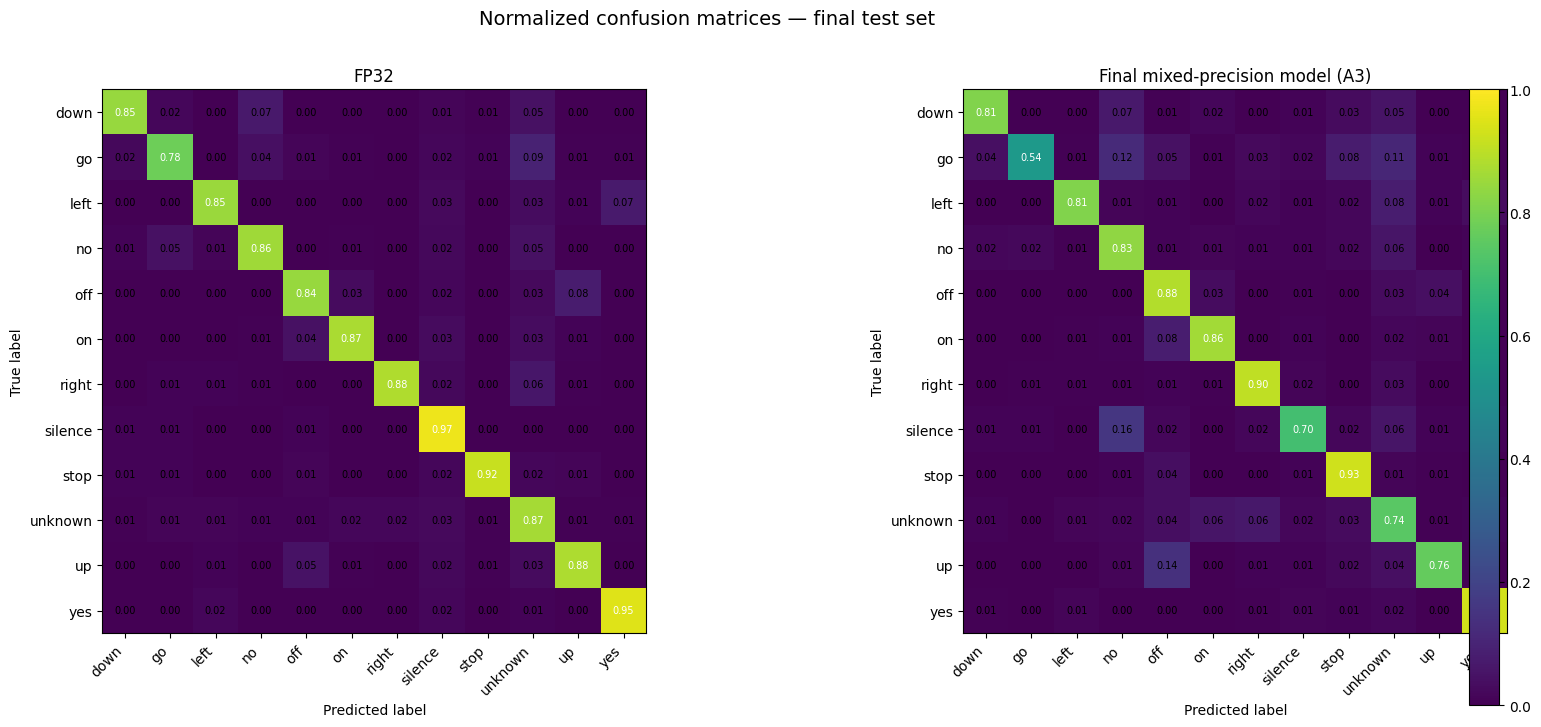


Plotting raw-count confusion-matrix comparison...


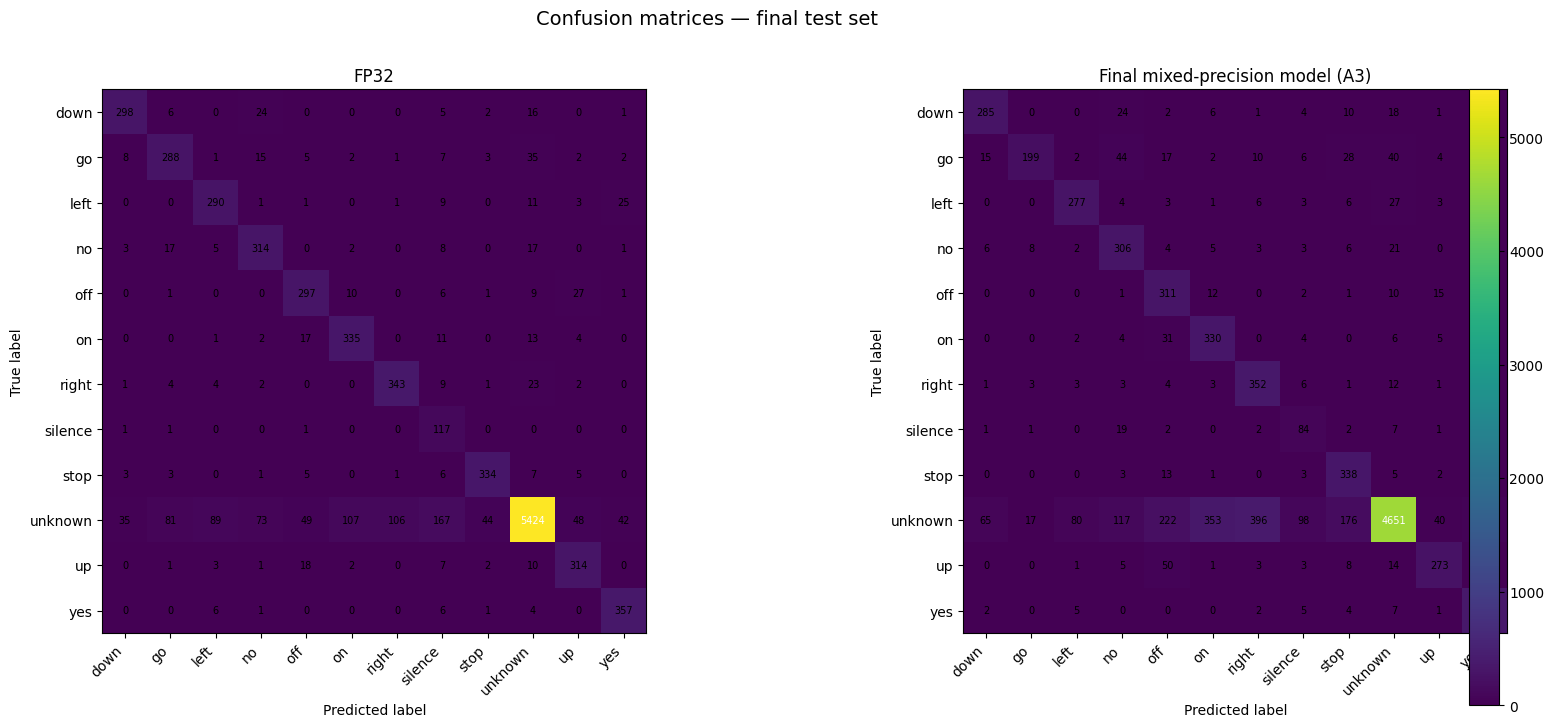


VALUES TO REPORT


,model,accuracy,balanced_accuracy,precision_macro,recall_macro,macro_f1,ba_drop_abs_vs_fp32,ba_drop_pct_vs_fp32
0,FP32,0.867975,0.876517,0.752975,0.876517,0.798271,0.000000,0.00000
1,Final mixed-precision model (A3),0.772718,0.808894,0.657936,0.808894,0.702896,0.067623,7.71496


,class,support,fp32_recall,quant_recall,recall_change
0,down,352,0.846591,0.809659,-0.036932
1,go,369,0.780488,0.539295,-0.241192
2,left,341,0.850440,0.812317,-0.038123
3,no,367,0.855586,0.833787,-0.021798
4,off,352,0.843750,0.883523,0.039773
5,on,383,0.874674,0.861619,-0.013055
6,right,389,0.881748,0.904884,0.023136
7,silence,120,0.975000,0.700000,-0.275000
8,stop,365,0.915068,0.926027,0.010959
9,unknown,6265,0.865762,0.742378,-0.123384


In [ ]:
# =========================================================
# FINAL TEST EVALUATION
# FP32 vs FINAL SELECTED QUANTIZED MODEL
# =========================================================
#
# IMPORTANT:
#
# Run this ONLY after:
#   - weight configuration is frozen
#   - activation configuration is frozen
#   - no further model/configuration selection will be made
#
# This cell evaluates:
#
#   1. Canonical FP32 model
#   2. Final selected mixed-precision weight +
#      activation quantized model
#
# on the previously untouched test_ds.
#
# =========================================================

import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)


# =========================================================
# 1. COLLECT PREDICTIONS
# =========================================================

def collect_predictions(
    model,
    eval_ds
):
    """
    Collect labels, predictions and probabilities from
    a deterministic evaluation dataset.
    """

    all_probs = []
    all_preds = []
    all_labels = []

    for x_batch, y_batch in eval_ds:

        probs = (
            model(
                x_batch,
                training=False
            )
            .numpy()
        )

        preds = np.argmax(
            probs,
            axis=1
        )

        labels = np.argmax(
            y_batch.numpy(),
            axis=1
        )

        all_probs.append(
            probs
        )

        all_preds.append(
            preds
        )

        all_labels.append(
            labels
        )

    y_prob = np.concatenate(
        all_probs
    )

    y_pred = np.concatenate(
        all_preds
    )

    y_true = np.concatenate(
        all_labels
    )

    return (
        y_true,
        y_pred,
        y_prob
    )


# =========================================================
# 2. COMPUTE FULL METRICS
# =========================================================

def compute_final_metrics(
    y_true,
    y_pred,
    class_names
):
    """
    Compute the final classification metrics used in the
    dissertation.
    """

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    balanced_accuracy = (
        balanced_accuracy_score(
            y_true,
            y_pred
        )
    )

    precision_macro = (
        precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )
    )

    recall_macro = (
        recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )
    )

    macro_f1 = (
        f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )
    )

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    report = (
        classification_report(
            y_true,
            y_pred,
            target_names=class_names,
            zero_division=0,
            output_dict=True
        )
    )

    # In single-label multiclass classification,
    # balanced accuracy should equal macro recall.
    if not np.isclose(
        balanced_accuracy,
        recall_macro,
        atol=1e-10
    ):

        raise RuntimeError(
            "Balanced accuracy and macro recall "
            "do not match."
        )

    return {

        "accuracy":
            float(
                accuracy
            ),

        "balanced_accuracy":
            float(
                balanced_accuracy
            ),

        "precision_macro":
            float(
                precision_macro
            ),

        "recall_macro":
            float(
                recall_macro
            ),

        "macro_f1":
            float(
                macro_f1
            ),

        "confusion_matrix":
            cm,

        "classification_report":
            report,
    }


# =========================================================
# 3. CONFUSION MATRIX PLOTTER
# =========================================================

def plot_confusion_matrix(
    cm,
    class_names,
    title,
    normalize=True,
    figsize=(10, 8)
):
    """
    Plot one confusion matrix.

    normalize=True gives row-normalized values, so each row
    represents the recall distribution for one true class.
    """

    if normalize:

        cm_plot = (
            cm.astype(
                np.float64
            )
        )

        row_sums = (
            cm_plot.sum(
                axis=1,
                keepdims=True
            )
        )

        cm_plot = np.divide(
            cm_plot,
            row_sums,
            out=np.zeros_like(
                cm_plot
            ),
            where=(
                row_sums != 0
            )
        )

    else:

        cm_plot = (
            cm.astype(
                np.int64
            )
        )

    fig, ax = plt.subplots(
        figsize=figsize
    )

    # No explicit colour map is required.
    im = ax.imshow(
        cm_plot,
        interpolation="nearest"
    )

    fig.colorbar(
        im,
        ax=ax,
        fraction=0.046,
        pad=0.04
    )

    tick_marks = np.arange(
        len(
            class_names
        )
    )

    ax.set_xticks(
        tick_marks
    )

    ax.set_yticks(
        tick_marks
    )

    ax.set_xticklabels(
        class_names,
        rotation=45,
        ha="right"
    )

    ax.set_yticklabels(
        class_names
    )

    ax.set_xlabel(
        "Predicted label"
    )

    ax.set_ylabel(
        "True label"
    )

    ax.set_title(
        title
    )

    threshold = (
        cm_plot.max() / 2.0
        if cm_plot.size > 0
        else 0.0
    )

    for i in range(
        cm_plot.shape[0]
    ):

        for j in range(
            cm_plot.shape[1]
        ):

            value = (
                cm_plot[
                    i,
                    j
                ]
            )

            if normalize:

                text = (
                    f"{value:.2f}"
                )

            else:

                text = (
                    f"{int(value)}"
                )

            ax.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                fontsize=8,
                color=(
                    "white"
                    if value > threshold
                    else "black"
                )
            )

    fig.tight_layout()

    plt.show()


# =========================================================
# 4. SIDE-BY-SIDE CONFUSION MATRIX COMPARISON
# =========================================================

def plot_confusion_matrix_comparison(
    cm_fp32,
    cm_quant,
    class_names,
    quant_label,
    normalize=True,
    figsize=(20, 8)
):
    """
    Plot FP32 and final quantized confusion matrices
    side-by-side using the SAME colour scale.

    This is the main thesis comparison figure.
    """

    if normalize:

        fp32_matrix = (
            cm_fp32.astype(
                np.float64
            )
        )

        quant_matrix = (
            cm_quant.astype(
                np.float64
            )
        )

        fp32_rows = (
            fp32_matrix.sum(
                axis=1,
                keepdims=True
            )
        )

        quant_rows = (
            quant_matrix.sum(
                axis=1,
                keepdims=True
            )
        )

        fp32_matrix = np.divide(
            fp32_matrix,
            fp32_rows,
            out=np.zeros_like(
                fp32_matrix
            ),
            where=(
                fp32_rows != 0
            )
        )

        quant_matrix = np.divide(
            quant_matrix,
            quant_rows,
            out=np.zeros_like(
                quant_matrix
            ),
            where=(
                quant_rows != 0
            )
        )

        # Same scale is important for visual comparison.
        vmin = 0.0
        vmax = 1.0

    else:

        fp32_matrix = (
            cm_fp32.astype(
                np.int64
            )
        )

        quant_matrix = (
            cm_quant.astype(
                np.int64
            )
        )

        vmin = 0

        vmax = max(
            int(
                fp32_matrix.max()
            ),
            int(
                quant_matrix.max()
            )
        )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=figsize
    )

    matrices = [
        fp32_matrix,
        quant_matrix
    ]

    titles = [
        "FP32",
        quant_label
    ]

    images = []

    for ax, matrix, title in zip(
        axes,
        matrices,
        titles
    ):

        im = ax.imshow(
            matrix,
            interpolation="nearest",
            vmin=vmin,
            vmax=vmax
        )

        images.append(
            im
        )

        ticks = np.arange(
            len(
                class_names
            )
        )

        ax.set_xticks(
            ticks
        )

        ax.set_yticks(
            ticks
        )

        ax.set_xticklabels(
            class_names,
            rotation=45,
            ha="right"
        )

        ax.set_yticklabels(
            class_names
        )

        ax.set_xlabel(
            "Predicted label"
        )

        ax.set_ylabel(
            "True label"
        )

        ax.set_title(
            title
        )

        threshold = (
            (
                vmin
                + vmax
            )
            / 2.0
        )

        for i in range(
            matrix.shape[0]
        ):

            for j in range(
                matrix.shape[1]
            ):

                value = (
                    matrix[
                        i,
                        j
                    ]
                )

                if normalize:

                    text = (
                        f"{value:.2f}"
                    )

                else:

                    text = (
                        f"{int(value)}"
                    )

                ax.text(
                    j,
                    i,
                    text,
                    ha="center",
                    va="center",
                    fontsize=7,
                    color=(
                        "white"
                        if value > threshold
                        else "black"
                    )
                )

    # One shared colour bar ensures direct comparability.
    fig.colorbar(
        images[0],
        ax=axes,
        fraction=0.025,
        pad=0.02
    )

    if normalize:

        fig.suptitle(
            "Normalized confusion matrices — final test set",
            fontsize=14
        )

    else:

        fig.suptitle(
            "Confusion matrices — final test set",
            fontsize=14
        )

    fig.subplots_adjust(
        top=0.88,
        bottom=0.20,
        wspace=0.25
    )

    plt.show()


# =========================================================
# 5. BUILD FINAL QUANTIZED MODEL
# =========================================================

def build_final_quantized_model(
    activation_results,
    scale_bits=0,
    break_point="norm",
    pw_opt=2,
    approximate=True
):
    """
    Reconstruct the exact configuration selected during
    validation.

    Nothing is selected using test results.
    """

    best = (
        activation_results.get(
            "best",
            None
        )
    )

    if best is None:

        raise RuntimeError(
            "activation_results['best'] is None. "
            "The final configuration must be frozen "
            "before test evaluation."
        )

    layer_records = (
        activation_results[
            "layer_records"
        ]
    )

    act_stats = (
        activation_results[
            "act_stats"
        ]
    )

    weight_mode = str(
        best[
            "weight_mode"
        ]
    )

    activation_bits = (
        best[
            "activation_bits"
        ]
    )

    # -----------------------------------------------------
    # Start from canonical FP32 model.
    # -----------------------------------------------------

    model = (
        load_fresh_model()
    )

    # -----------------------------------------------------
    # Apply the frozen weight configuration.
    # -----------------------------------------------------

    model = (
        quantize_model_from_budget_records(

            model=model,

            layer_records=layer_records,

            weight_mode=weight_mode,

            scale_bits=scale_bits,

            break_point=break_point,

            pw_opt=pw_opt,

            approximate=approximate
        )
    )

    # -----------------------------------------------------
    # Apply the activation configuration selected on val_ds.
    # -----------------------------------------------------

    if (
        activation_bits
        != "FP32"
    ):

        _patch_fixed_activation_bits(

            model=model,

            act_stats=act_stats,

            act_bits=int(
                activation_bits
            )
        )

    return (
        model,
        weight_mode,
        activation_bits
    )


# =========================================================
# 6. FINAL TEST COMPARISON
# =========================================================

def evaluate_final_fp32_vs_quantized(
    test_ds,
    activation_results,
    class_names=None,
    scale_bits=0,
    break_point="norm",
    pw_opt=2,
    approximate=True
):
    """
    FINAL locked-test evaluation.

    Compares:

        canonical FP32
            vs
        final validation-selected quantized configuration

    No model/configuration selection occurs here.
    """

    if class_names is None:

        class_names = list(
            le.classes_
        )

    # =====================================================
    # VERIFY FROZEN CONFIGURATION
    # =====================================================

    best = (
        activation_results.get(
            "best",
            None
        )
    )

    if best is None:

        raise RuntimeError(
            "No frozen activation configuration found."
        )

    print(
        "\n"
        + "=" * 100
    )

    print(
        "FINAL LOCKED TEST EVALUATION"
    )

    print(
        "=" * 100
    )

    print(
        "The configuration below was selected on validation."
    )

    print(
        "No selection or tuning will be performed on test results."
    )

    print()

    print(
        best.to_string()
        if hasattr(
            best,
            "to_string"
        )
        else best
    )

    # =====================================================
    # BUILD FP32 MODEL
    # =====================================================

    print(
        "\nBuilding canonical FP32 model..."
    )

    model_fp32 = (
        load_fresh_model()
    )

    # =====================================================
    # BUILD FINAL MODEL
    # =====================================================

    print(
        "\nBuilding final frozen quantized model..."
    )

    (
        model_final,
        weight_mode,
        activation_bits
    ) = build_final_quantized_model(

        activation_results=(
            activation_results
        ),

        scale_bits=scale_bits,

        break_point=break_point,

        pw_opt=pw_opt,

        approximate=approximate
    )

    # -----------------------------------------------------
    # Label the final model correctly.
    # -----------------------------------------------------

    if (
        activation_bits
        == "FP32"
    ):

        final_label = (
            "Final mixed-precision model (A32)"
        )

    else:

        final_label = (
            f"Final mixed-precision model "
            f"(A{int(activation_bits)})"
        )

    # =====================================================
    # FP32 TEST PREDICTIONS
    # =====================================================

    print(
        "\n"
        + "=" * 100
    )

    print(
        "FP32 — TEST SET"
    )

    print(
        "=" * 100
    )

    (
        y_true_fp32,
        y_pred_fp32,
        y_prob_fp32
    ) = collect_predictions(

        model_fp32,

        test_ds
    )

    fp32_metrics = (
        compute_final_metrics(

            y_true_fp32,

            y_pred_fp32,

            class_names
        )
    )

    # =====================================================
    # FINAL QUANTIZED TEST PREDICTIONS
    # =====================================================

    print(
        "\n"
        + "=" * 100
    )

    print(
        f"{final_label.upper()} — TEST SET"
    )

    print(
        "=" * 100
    )

    (
        y_true_quant,
        y_pred_quant,
        y_prob_quant
    ) = collect_predictions(

        model_final,

        test_ds
    )

    quant_metrics = (
        compute_final_metrics(

            y_true_quant,

            y_pred_quant,

            class_names
        )
    )

    # =====================================================
    # SANITY CHECK
    # =====================================================

    if not np.array_equal(
        y_true_fp32,
        y_true_quant
    ):

        raise RuntimeError(
            "FP32 and quantized evaluations produced "
            "different test-label ordering."
        )

    # =====================================================
    # SUMMARY TABLE
    # =====================================================

    summary = pd.DataFrame(
        [
            {
                "model":
                    "FP32",

                "accuracy":
                    fp32_metrics[
                        "accuracy"
                    ],

                "balanced_accuracy":
                    fp32_metrics[
                        "balanced_accuracy"
                    ],

                "precision_macro":
                    fp32_metrics[
                        "precision_macro"
                    ],

                "recall_macro":
                    fp32_metrics[
                        "recall_macro"
                    ],

                "macro_f1":
                    fp32_metrics[
                        "macro_f1"
                    ],
            },

            {
                "model":
                    final_label,

                "accuracy":
                    quant_metrics[
                        "accuracy"
                    ],

                "balanced_accuracy":
                    quant_metrics[
                        "balanced_accuracy"
                    ],

                "precision_macro":
                    quant_metrics[
                        "precision_macro"
                    ],

                "recall_macro":
                    quant_metrics[
                        "recall_macro"
                    ],

                "macro_f1":
                    quant_metrics[
                        "macro_f1"
                    ],
            },
        ]
    )

    fp32_ba = (
        fp32_metrics[
            "balanced_accuracy"
        ]
    )

    summary[
        "ba_drop_abs_vs_fp32"
    ] = (

        fp32_ba
        - summary[
            "balanced_accuracy"
        ]
    )

    summary[
        "ba_drop_pct_vs_fp32"
    ] = (

        100.0
        * summary[
            "ba_drop_abs_vs_fp32"
        ]
        / max(
            fp32_ba,
            1e-10
        )
    )

    print(
        "\n"
        + "=" * 100
    )

    print(
        "FINAL TEST RESULTS"
    )

    print(
        "=" * 100
    )

    print(
        summary.to_string(
            index=False
        )
    )

    # =====================================================
    # PER-CLASS RECALL COMPARISON
    # =====================================================

    per_class_rows = []

    for class_name in class_names:

        fp32_class = (
            fp32_metrics[
                "classification_report"
            ][
                class_name
            ]
        )

        quant_class = (
            quant_metrics[
                "classification_report"
            ][
                class_name
            ]
        )

        per_class_rows.append(
            {
                "class":
                    class_name,

                "support":
                    int(
                        fp32_class[
                            "support"
                        ]
                    ),

                "fp32_recall":
                    fp32_class[
                        "recall"
                    ],

                "quant_recall":
                    quant_class[
                        "recall"
                    ],

                "recall_change":
                    (
                        quant_class[
                            "recall"
                        ]
                        - fp32_class[
                            "recall"
                        ]
                    ),
            }
        )

    per_class_df = pd.DataFrame(
        per_class_rows
    )

    print(
        "\n"
        + "=" * 100
    )

    print(
        "PER-CLASS RECALL — TEST SET"
    )

    print(
        "=" * 100
    )

    print(
        per_class_df.to_string(
            index=False
        )
    )

    # =====================================================
    # MAIN CONFUSION MATRIX COMPARISON
    # =====================================================

    print(
        "\nPlotting normalized confusion-matrix comparison..."
    )

    plot_confusion_matrix_comparison(

        cm_fp32=(
            fp32_metrics[
                "confusion_matrix"
            ]
        ),

        cm_quant=(
            quant_metrics[
                "confusion_matrix"
            ]
        ),

        class_names=(
            class_names
        ),

        quant_label=(
            final_label
        ),

        normalize=True
    )

    # =====================================================
    # RAW COUNT COMPARISON
    # =====================================================

    print(
        "\nPlotting raw-count confusion-matrix comparison..."
    )

    plot_confusion_matrix_comparison(

        cm_fp32=(
            fp32_metrics[
                "confusion_matrix"
            ]
        ),

        cm_quant=(
            quant_metrics[
                "confusion_matrix"
            ]
        ),

        class_names=(
            class_names
        ),

        quant_label=(
            final_label
        ),

        normalize=False
    )

    # =====================================================
    # CLEANUP
    # =====================================================

    del model_fp32
    del model_final

    tf.keras.backend.clear_session()
    gc.collect()

    # =====================================================
    # RETURN RESULTS
    # =====================================================

    return {

        "summary":
            summary,

        "per_class":
            per_class_df,

        "fp32":
            {
                "y_true":
                    y_true_fp32,

                "y_pred":
                    y_pred_fp32,

                "y_prob":
                    y_prob_fp32,

                **fp32_metrics,
            },

        "final_quantized":
            {
                "y_true":
                    y_true_quant,

                "y_pred":
                    y_pred_quant,

                "y_prob":
                    y_prob_quant,

                **quant_metrics,
            },

        "final_label":
            final_label,

        "activation_bits":
            activation_bits,

        "weight_mode":
            weight_mode,
    }


# =========================================================
# 7. RUN FINAL TEST EVALUATION
# =========================================================
#
# IMPORTANT:
#
# There is NO:
#
#     act_bits=4
#
# here.
#
# The activation precision comes directly from the
# configuration selected on val_ds and stored in:
#
#     activation_results["best"]
#
# =========================================================

final_test_results = (
    evaluate_final_fp32_vs_quantized(

        test_ds=test_ds,

        activation_results=(
            activation_results
        ),

        class_names=list(
            le.classes_
        ),

        scale_bits=0,

        break_point="norm",

        pw_opt=2,

        approximate=True
    )
)


# =========================================================
# 8. FINAL VALUES FOR THESIS
# =========================================================

print(
    "\n"
    + "=" * 100
)

print(
    "VALUES TO REPORT"
)

print(
    "=" * 100
)

display(
    final_test_results[
        "summary"
    ]
)

display(
    final_test_results[
        "per_class"
    ]
)


FROZEN CONFIGURATION — STORAGE ANALYSIS
Selected configuration: Wmixed-A3
Validation BA:          0.807386
Total relative BA drop: 6.589%
Recorded avg channel bits: 2.4517
Recorded avg weight bits:  2.0917
Dataset inference:       NONE
Test set:                NOT USED


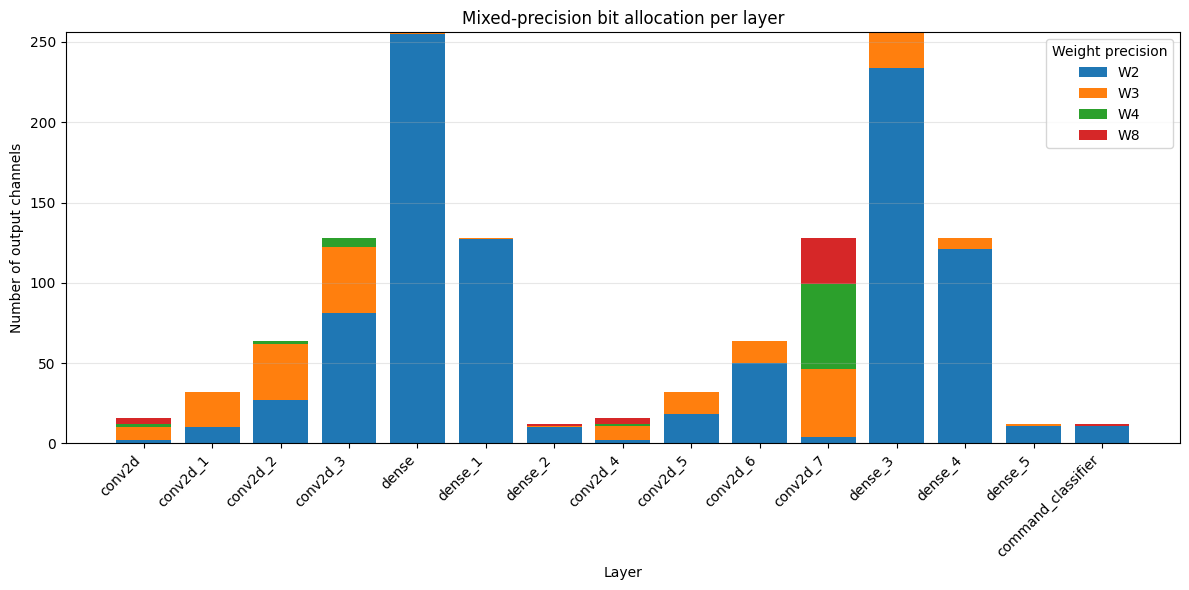


BIT ALLOCATION PER LAYER
             layer  n_channels  avg_channel_bits  2b  3b  4b  8b
            conv2d          16          4.250000   2   8   2   4
          conv2d_1          32          2.687500  10  22   0   0
          conv2d_2          64          2.609375  27  35   2   0
          conv2d_3         128          2.414062  81  41   6   0
             dense         256          2.003906 255   1   0   0
           dense_1         128          2.007812 127   1   0   0
           dense_2          12          2.583333  10   1   0   1
          conv2d_4          16          4.187500   2   9   1   4
          conv2d_5          32          2.437500  18  14   0   0
          conv2d_6          64          2.218750  50  14   0   0
          conv2d_7         128          4.515625   4  42  53  29
           dense_3         256          2.085938 234  22   0   0
           dense_4         128          2.054688 121   7   0   0
           dense_5          12          2.083333  11   1   0   0

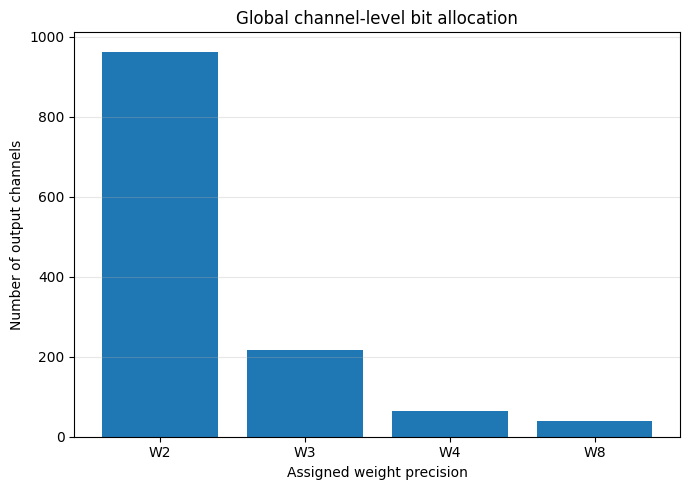


GLOBAL CHANNEL-LEVEL BIT ALLOCATION
Total quantized output channels: 1,284
 W2:   963 channels ( 75.00%)
 W3:   218 channels ( 16.98%)
 W4:    64 channels (  4.98%)
 W8:    39 channels (  3.04%)

MIXED-PRECISION WEIGHT STORAGE SUMMARY
Quantized Conv/Dense layers:       15
Kernel weights:                    6,950,688
FP32 bias values:                  1,284
Quantized output channels:         1,284

Average channel allocation:        2.4517 bits
Parameter-weighted avg W precision: 2.0917 bits

FP32 weight-layer storage:         26.5197 MiB
Packed quantized kernels only:     1.7332 MiB
Estimated quantized storage:       1.7430 MiB

Ideal kernel compression:          15.30x
Ideal kernel reduction:            93.46%

Estimated compression + overhead:  15.22x
Estimated reduction + overhead:    93.43%

Metadata assumption:               32 bits/channel
Bias assumption:                   FP32

NOTE: These are theoretical / estimated packed-storage figures.
The fake-quantized TensorFlow/Keras 

,layer,n_kernel_weights,n_channels,avg_channel_bits,avg_weight_bits,ideal_kernel_compression,effective_compression_ratio,effective_memory_reduction_pct
0,conv2d,256,16,4.250000,4.250000,7.529412,4.121212,75.735294
1,conv2d_1,8192,32,2.687500,2.687500,11.906977,10.936170,90.856031
2,conv2d_2,8192,64,2.609375,2.609375,12.263473,10.371859,90.358527
3,conv2d_3,32768,128,2.414062,2.414062,13.255663,12.058651,91.707198
4,dense,753664,256,2.003906,2.003906,15.968811,15.802800,93.672008
5,dense_1,32768,128,2.007812,2.007812,15.937743,14.228374,92.971790
6,dense_2,1536,12,2.583333,2.583333,12.387097,10.459459,90.439276
7,conv2d_4,256,16,4.187500,4.187500,7.641791,4.152672,75.919118
8,conv2d_5,8192,32,2.437500,2.437500,13.128205,11.953488,91.634241
9,conv2d_6,8192,64,2.218750,2.218750,14.422535,11.862069,91.569767


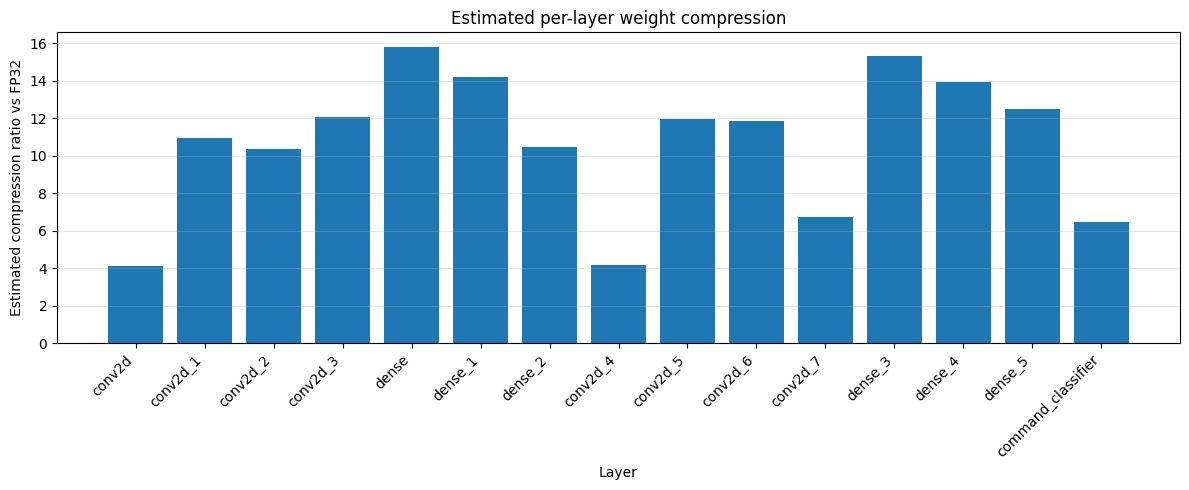

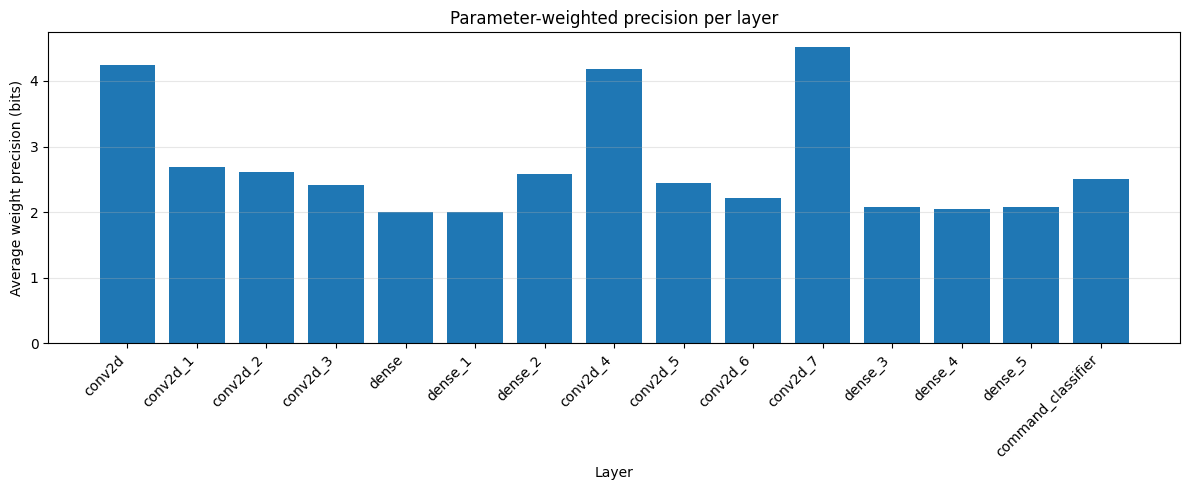


AVERAGE-BIT CONSISTENCY CHECK
Budget-search avg weight bits: 2.091709
Recalculated avg weight bits:  2.091709
Absolute difference:            0.0000000000
Consistency check: PASSED

BIT ALLOCATION / STORAGE ANALYSIS COMPLETE
Canonical model:       load_fresh_model()
Configuration source:  activation_results['layer_records']
Calibration inference: NONE
Validation inference:  NONE
Test inference:        NONE
TEST SET:              LOCKED / NOT EVALUATED


In [ ]:
# =========================================================
# FINAL BIT ALLOCATION + STORAGE / COMPRESSION ANALYSIS
# =========================================================
#
# Revised protocol:
#
#   - Uses activation_results["layer_records"], i.e. the
#     frozen mixed-precision weight configuration.
#
#   - Loads the canonical FP32 model with load_fresh_model().
#
#   - Does NOT use calib_ds, val_ds, or test_ds.
#
#   - Does NOT perform inference.
#
#   - Reports:
#       1. channel-level bit allocation
#       2. parameter-weighted average weight precision
#       3. ideal packed kernel-code storage
#       4. estimated storage including:
#            - FP32 biases
#            - per-channel quantization metadata
#
# IMPORTANT:
#
# These are theoretical / estimated storage calculations.
# The fake-quantized Keras model itself still stores
# dequantized float32 tensors.
#
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import gc


# =========================================================
# SETTINGS
# =========================================================

FP32_BITS = 32

# Metadata assumption:
#
# One FP32 scale per quantized output channel.
#
# If asymmetric quantization is used, a zero-point may also
# need to be stored. For the selected PWLQ configuration,
# this cell uses one 32-bit metadata value per channel as
# the default theoretical accounting.
#
METADATA_BITS_PER_CHANNEL = 32


# =========================================================
# 1. EXTRACT BIT ALLOCATION TABLE
# =========================================================

def make_bit_allocation_dataframe(
    layer_records
):
    """
    Create a DataFrame describing the channel-level
    bit allocation of the frozen mixed-precision model.

    Expected fields in each layer record:

        rec["layer_name"]
        rec["assigned_bits"]

    avg_channel_bits is the simple mean across output
    channels in that layer. It is NOT parameter weighted.
    """

    rows = []

    for rec in layer_records:

        layer_name = rec[
            "layer_name"
        ]

        assigned_bits = np.asarray(
            rec[
                "assigned_bits"
            ],
            dtype=int
        )

        if assigned_bits.size == 0:
            continue

        row = {

            "layer":
                layer_name,

            "n_channels":
                int(
                    assigned_bits.size
                ),

            "avg_channel_bits":
                float(
                    np.mean(
                        assigned_bits
                    )
                ),
        }

        for bit_width in [
            2,
            3,
            4,
            8
        ]:

            row[
                f"{bit_width}b"
            ] = int(
                np.sum(
                    assigned_bits
                    == bit_width
                )
            )

        rows.append(
            row
        )

    return pd.DataFrame(
        rows
    )


# =========================================================
# 2. PLOT BIT ALLOCATION PER LAYER
# =========================================================

def plot_bit_allocation_per_layer(
    layer_records,
    figsize=(12, 6)
):
    """
    Stacked bar chart showing how many output channels
    in each layer are assigned to W2/W3/W4/W8.
    """

    df = (
        make_bit_allocation_dataframe(
            layer_records
        )
    )

    if len(df) == 0:

        raise ValueError(
            "No layer bit-allocation records found."
        )

    x = np.arange(
        len(df)
    )

    bottom = np.zeros(
        len(df)
    )

    plt.figure(
        figsize=figsize
    )

    for bit_width in [
        2,
        3,
        4,
        8
    ]:

        values = (
            df[
                f"{bit_width}b"
            ]
            .to_numpy()
        )

        plt.bar(
            x,
            values,
            bottom=bottom,
            label=f"W{bit_width}"
        )

        bottom += values

    plt.xticks(
        x,
        df["layer"],
        rotation=45,
        ha="right"
    )

    plt.ylabel(
        "Number of output channels"
    )

    plt.xlabel(
        "Layer"
    )

    plt.title(
        "Mixed-precision bit allocation per layer"
    )

    plt.grid(
        True,
        axis="y",
        alpha=0.3
    )

    plt.legend(
        title="Weight precision"
    )

    plt.tight_layout()
    plt.show()

    print(
        "\n"
        + "=" * 100
    )

    print(
        "BIT ALLOCATION PER LAYER"
    )

    print(
        "=" * 100
    )

    print(
        df.to_string(
            index=False
        )
    )

    return df


# =========================================================
# 3. GLOBAL CHANNEL-LEVEL BIT ALLOCATION
# =========================================================

def plot_global_bit_allocation(
    layer_records,
    figsize=(7, 5)
):
    """
    Plot the total number of output channels assigned
    to each weight precision.

    NOTE:
    These percentages are CHANNEL percentages, not
    parameter percentages.
    """

    df = (
        make_bit_allocation_dataframe(
            layer_records
        )
    )

    if len(df) == 0:

        raise ValueError(
            "No layer bit-allocation records found."
        )

    totals = {

        "W2":
            int(
                df["2b"].sum()
            ),

        "W3":
            int(
                df["3b"].sum()
            ),

        "W4":
            int(
                df["4b"].sum()
            ),

        "W8":
            int(
                df["8b"].sum()
            ),
    }

    total_channels = sum(
        totals.values()
    )

    plt.figure(
        figsize=figsize
    )

    plt.bar(
        list(
            totals.keys()
        ),
        list(
            totals.values()
        )
    )

    plt.ylabel(
        "Number of output channels"
    )

    plt.xlabel(
        "Assigned weight precision"
    )

    plt.title(
        "Global channel-level bit allocation"
    )

    plt.grid(
        True,
        axis="y",
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()

    print(
        "\n"
        + "=" * 100
    )

    print(
        "GLOBAL CHANNEL-LEVEL BIT ALLOCATION"
    )

    print(
        "=" * 100
    )

    print(
        f"Total quantized output channels: "
        f"{total_channels:,}"
    )

    for label, count in totals.items():

        percentage = (

            100.0
            * count
            / max(
                total_channels,
                1
            )
        )

        print(
            f"{label:>3}: "
            f"{count:>5,} channels "
            f"({percentage:6.2f}%)"
        )

    return totals


# =========================================================
# 4. WEIGHT STORAGE / COMPRESSION SUMMARY
# =========================================================

def compute_weight_compression_summary(
    model,
    layer_records,
    fp32_bits=32,
    metadata_bits_per_channel=32
):
    """
    Estimate storage requirements of the frozen
    mixed-precision weight configuration.

    Two quantized storage estimates are reported.

    -------------------------------------------------------
    A. IDEAL KERNEL-CODE STORAGE
    -------------------------------------------------------

    Only packed quantized kernel values are counted:

        sum(
            weights_in_channel
            * assigned_bits
        )

    This gives the pure numerical-precision compression
    of the kernels.

    -------------------------------------------------------
    B. ESTIMATED MODEL-WEIGHT STORAGE
    -------------------------------------------------------

    Counts:

        quantized kernel codes
        + FP32 biases
        + per-output-channel quantization metadata

    The default metadata assumption is one FP32 value
    (32 bits) per output channel.

    -------------------------------------------------------

    Batch-normalization parameters and other model state
    outside the selected Conv2D/Dense weight layers are
    not included here.

    Therefore this should be described as an estimated
    storage requirement for the quantized weight layers,
    NOT the physical size of the saved Keras model.

    The fake-quantized Keras model itself remains float32.
    """

    name_to_rec = {

        rec[
            "layer_name"
        ]:
        rec

        for rec in layer_records
    }

    rows = []

    total_kernel_weights = 0
    total_bias_values = 0
    total_channels = 0

    total_fp32_kernel_bits = 0
    total_fp32_bias_bits = 0

    total_quant_kernel_bits = 0
    total_metadata_bits = 0

    # =====================================================
    # ITERATE QUANTIZED CONV2D / DENSE LAYERS
    # =====================================================

    for layer in (
        collect_all_weight_layers(
            model
        )
    ):

        if (
            layer.name
            not in name_to_rec
        ):
            continue

        weights = (
            layer.get_weights()
        )

        if not weights:
            continue

        W = np.asarray(
            weights[0]
        )

        rec = (
            name_to_rec[
                layer.name
            ]
        )

        assigned_bits = np.asarray(
            rec[
                "assigned_bits"
            ],
            dtype=int
        )

        # -------------------------------------------------
        # Conv2D:
        # [kh, kw, in_channels, out_channels]
        #
        # Dense:
        # [in_features, out_features]
        #
        # Therefore output channels / neurons are always
        # the final dimension.
        # -------------------------------------------------

        out_channels = int(
            W.shape[-1]
        )

        if (
            len(
                assigned_bits
            )
            != out_channels
        ):

            raise ValueError(

                f"Layer {layer.name}: "
                f"{out_channels} output channels but "
                f"{len(assigned_bits)} assigned "
                f"bit-widths."
            )

        weights_per_channel = int(
            np.prod(
                W.shape[:-1]
            )
        )

        n_kernel_weights = int(
            W.size
        )

        # -------------------------------------------------
        # Biases remain FP32.
        # -------------------------------------------------

        if (
            len(weights) > 1
        ):

            bias = np.asarray(
                weights[1]
            )

            n_bias_values = int(
                bias.size
            )

        else:

            n_bias_values = 0

        # -------------------------------------------------
        # FP32 reference storage
        # -------------------------------------------------

        fp32_kernel_bits = (
            n_kernel_weights
            * fp32_bits
        )

        fp32_bias_bits = (
            n_bias_values
            * fp32_bits
        )

        fp32_layer_bits = (
            fp32_kernel_bits
            + fp32_bias_bits
        )

        # -------------------------------------------------
        # Quantized kernel codes
        # -------------------------------------------------

        quant_kernel_bits = int(
            np.sum(
                assigned_bits
                * weights_per_channel
            )
        )

        # -------------------------------------------------
        # Metadata
        #
        # Default assumption:
        # one FP32 scale / metadata value per output
        # channel.
        # -------------------------------------------------

        metadata_bits = int(
            out_channels
            * metadata_bits_per_channel
        )

        # -------------------------------------------------
        # Estimated quantized layer storage
        # -------------------------------------------------

        quant_layer_bits_with_overhead = (

            quant_kernel_bits
            + fp32_bias_bits
            + metadata_bits
        )

        # -------------------------------------------------
        # Parameter-weighted average kernel precision
        # -------------------------------------------------

        parameter_weighted_avg_bits = (

            quant_kernel_bits
            / max(
                n_kernel_weights,
                1
            )
        )

        # Simple channel average
        channel_avg_bits = float(
            np.mean(
                assigned_bits
            )
        )

        # -------------------------------------------------
        # Compression ratios
        # -------------------------------------------------

        ideal_kernel_compression = (

            fp32_kernel_bits
            / max(
                quant_kernel_bits,
                1
            )
        )

        effective_layer_compression = (

            fp32_layer_bits
            / max(
                quant_layer_bits_with_overhead,
                1
            )
        )

        effective_reduction_pct = (

            100.0
            * (
                1.0
                - (
                    quant_layer_bits_with_overhead
                    / max(
                        fp32_layer_bits,
                        1
                    )
                )
            )
        )

        rows.append({

            "layer":
                layer.name,

            "n_kernel_weights":
                n_kernel_weights,

            "n_bias_values":
                n_bias_values,

            "n_channels":
                out_channels,

            "weights_per_channel":
                weights_per_channel,

            "avg_channel_bits":
                channel_avg_bits,

            "avg_weight_bits":
                parameter_weighted_avg_bits,

            "fp32_kernel_bits":
                fp32_kernel_bits,

            "fp32_bias_bits":
                fp32_bias_bits,

            "quant_kernel_bits":
                quant_kernel_bits,

            "metadata_bits":
                metadata_bits,

            "estimated_quant_bits":
                quant_layer_bits_with_overhead,

            "ideal_kernel_compression":
                ideal_kernel_compression,

            "effective_compression_ratio":
                effective_layer_compression,

            "effective_memory_reduction_pct":
                effective_reduction_pct,
        })

        # -------------------------------------------------
        # Global accumulation
        # -------------------------------------------------

        total_kernel_weights += (
            n_kernel_weights
        )

        total_bias_values += (
            n_bias_values
        )

        total_channels += (
            out_channels
        )

        total_fp32_kernel_bits += (
            fp32_kernel_bits
        )

        total_fp32_bias_bits += (
            fp32_bias_bits
        )

        total_quant_kernel_bits += (
            quant_kernel_bits
        )

        total_metadata_bits += (
            metadata_bits
        )

    # =====================================================
    # BUILD PER-LAYER DATAFRAME
    # =====================================================

    df = pd.DataFrame(
        rows
    )

    if len(df) == 0:

        raise ValueError(
            "No matching quantized weight layers found."
        )

    # =====================================================
    # GLOBAL STORAGE
    # =====================================================

    total_fp32_bits = (

        total_fp32_kernel_bits
        + total_fp32_bias_bits
    )

    estimated_quant_bits = (

        total_quant_kernel_bits
        + total_fp32_bias_bits
        + total_metadata_bits
    )

    # -----------------------------------------------------
    # Parameter-weighted average precision
    #
    # This is the number that should be used instead of
    # simply averaging channel bit-widths.
    # -------------------------------------------------

    global_avg_weight_bits = (

        total_quant_kernel_bits
        / max(
            total_kernel_weights,
            1
        )
    )

    # -----------------------------------------------------
    # Channel average — reported separately
    # -------------------------------------------------

    total_assigned_channel_bits = 0

    for rec in layer_records:

        bits = np.asarray(
            rec[
                "assigned_bits"
            ],
            dtype=int
        )

        total_assigned_channel_bits += int(
            np.sum(
                bits
            )
        )

    global_avg_channel_bits = (

        total_assigned_channel_bits
        / max(
            total_channels,
            1
        )
    )

    # -----------------------------------------------------
    # Ideal kernel-only compression
    # -------------------------------------------------

    ideal_kernel_compression = (

        total_fp32_kernel_bits
        / max(
            total_quant_kernel_bits,
            1
        )
    )

    ideal_kernel_reduction_pct = (

        100.0
        * (
            1.0
            - (
                total_quant_kernel_bits
                / max(
                    total_fp32_kernel_bits,
                    1
                )
            )
        )
    )

    # -----------------------------------------------------
    # Effective estimate including overhead
    # -------------------------------------------------

    effective_compression_ratio = (

        total_fp32_bits
        / max(
            estimated_quant_bits,
            1
        )
    )

    effective_memory_reduction_pct = (

        100.0
        * (
            1.0
            - (
                estimated_quant_bits
                / max(
                    total_fp32_bits,
                    1
                )
            )
        )
    )

    # =====================================================
    # SUMMARY
    # =====================================================

    summary = {

        "quantized_layers":
            len(df),

        "total_kernel_weights":
            total_kernel_weights,

        "total_bias_values":
            total_bias_values,

        "total_channels":
            total_channels,

        "global_avg_channel_bits":
            global_avg_channel_bits,

        "global_avg_weight_bits":
            global_avg_weight_bits,

        "fp32_kernel_bits":
            total_fp32_kernel_bits,

        "fp32_bias_bits":
            total_fp32_bias_bits,

        "fp32_total_bits":
            total_fp32_bits,

        "quant_kernel_bits":
            total_quant_kernel_bits,

        "metadata_bits":
            total_metadata_bits,

        "estimated_quant_total_bits":
            estimated_quant_bits,

        "fp32_MB":
            (
                total_fp32_bits
                / 8
                / 1024**2
            ),

        "ideal_quant_kernel_MB":
            (
                total_quant_kernel_bits
                / 8
                / 1024**2
            ),

        "estimated_quant_MB":
            (
                estimated_quant_bits
                / 8
                / 1024**2
            ),

        "ideal_kernel_compression":
            ideal_kernel_compression,

        "ideal_kernel_reduction_pct":
            ideal_kernel_reduction_pct,

        "effective_compression_ratio":
            effective_compression_ratio,

        "effective_memory_reduction_pct":
            effective_memory_reduction_pct,

        "metadata_bits_per_channel":
            metadata_bits_per_channel,
    }

    # =====================================================
    # PRINT SUMMARY
    # =====================================================

    print(
        "\n"
        + "=" * 100
    )

    print(
        "MIXED-PRECISION WEIGHT STORAGE SUMMARY"
    )

    print(
        "=" * 100
    )

    print(
        f"Quantized Conv/Dense layers:       "
        f"{summary['quantized_layers']}"
    )

    print(
        f"Kernel weights:                    "
        f"{summary['total_kernel_weights']:,}"
    )

    print(
        f"FP32 bias values:                  "
        f"{summary['total_bias_values']:,}"
    )

    print(
        f"Quantized output channels:         "
        f"{summary['total_channels']:,}"
    )

    print()

    print(
        f"Average channel allocation:        "
        f"{summary['global_avg_channel_bits']:.4f} bits"
    )

    print(
        f"Parameter-weighted avg W precision:"
        f" {summary['global_avg_weight_bits']:.4f} bits"
    )

    print()

    print(
        f"FP32 weight-layer storage:         "
        f"{summary['fp32_MB']:.4f} MiB"
    )

    print(
        f"Packed quantized kernels only:     "
        f"{summary['ideal_quant_kernel_MB']:.4f} MiB"
    )

    print(
        f"Estimated quantized storage:       "
        f"{summary['estimated_quant_MB']:.4f} MiB"
    )

    print()

    print(
        f"Ideal kernel compression:          "
        f"{summary['ideal_kernel_compression']:.2f}x"
    )

    print(
        f"Ideal kernel reduction:            "
        f"{summary['ideal_kernel_reduction_pct']:.2f}%"
    )

    print()

    print(
        f"Estimated compression + overhead:  "
        f"{summary['effective_compression_ratio']:.2f}x"
    )

    print(
        f"Estimated reduction + overhead:    "
        f"{summary['effective_memory_reduction_pct']:.2f}%"
    )

    print()

    print(
        f"Metadata assumption:               "
        f"{metadata_bits_per_channel} bits/channel"
    )

    print(
        "Bias assumption:                   "
        "FP32"
    )

    print()

    print(
        "NOTE: These are theoretical / estimated packed-storage "
        "figures."
    )

    print(
        "The fake-quantized TensorFlow/Keras model still stores "
        "dequantized float32 tensors."
    )

    print(
        "=" * 100
    )

    return (
        df,
        summary
    )


# =========================================================
# 5. PLOT PER-LAYER COMPRESSION
# =========================================================

def plot_compression_per_layer(
    compression_df,
    figsize=(12, 5)
):
    """
    Plot estimated per-layer compression relative to FP32,
    including FP32 biases and the specified metadata
    overhead.
    """

    df = (
        compression_df.copy()
    )

    plt.figure(
        figsize=figsize
    )

    plt.bar(
        df[
            "layer"
        ],
        df[
            "effective_compression_ratio"
        ]
    )

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.xlabel(
        "Layer"
    )

    plt.ylabel(
        "Estimated compression ratio vs FP32"
    )

    plt.title(
        "Estimated per-layer weight compression"
    )

    plt.grid(
        True,
        axis="y",
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()


# =========================================================
# 6. PLOT PARAMETER-WEIGHTED PRECISION PER LAYER
# =========================================================

def plot_average_weight_bits_per_layer(
    compression_df,
    figsize=(12, 5)
):
    """
    Plot parameter-weighted average kernel precision
    for each quantized layer.
    """

    df = (
        compression_df.copy()
    )

    plt.figure(
        figsize=figsize
    )

    plt.bar(
        df[
            "layer"
        ],
        df[
            "avg_weight_bits"
        ]
    )

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.xlabel(
        "Layer"
    )

    plt.ylabel(
        "Average weight precision (bits)"
    )

    plt.title(
        "Parameter-weighted precision per layer"
    )

    plt.grid(
        True,
        axis="y",
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()


# =========================================================
# 7. GET THE FROZEN FINAL WEIGHT CONFIGURATION
# =========================================================

if (
    "activation_results"
    not in globals()
):

    raise RuntimeError(
        "activation_results does not exist. "
        "Run the revised activation-selection cell first."
    )


if (
    "layer_records"
    not in activation_results
):

    raise KeyError(
        "activation_results does not contain layer_records."
    )


layer_records = (
    activation_results[
        "layer_records"
    ]
)


print(
    "\n"
    + "=" * 100
)

print(
    "FROZEN CONFIGURATION — STORAGE ANALYSIS"
)

print(
    "=" * 100
)


# ---------------------------------------------------------
# Show selected activation configuration if available.
# ---------------------------------------------------------

best_activation = (
    activation_results.get(
        "best",
        None
    )
)


if (
    best_activation
    is not None
):

    print(
        f"Selected configuration: "
        f"{best_activation['configuration']}"
    )

    print(
        f"Validation BA:          "
        f"{best_activation['balanced_accuracy']:.6f}"
    )

    print(
        f"Total relative BA drop: "
        f"{best_activation['ba_drop_pct']:.3f}%"
    )


# ---------------------------------------------------------
# Show selected weight budget information.
# ---------------------------------------------------------

budget_info = (
    activation_results.get(
        "budget_info",
        None
    )
)


if (
    budget_info
    is not None
):

    if (
        "avg_channel_bits"
        in budget_info
    ):

        print(
            f"Recorded avg channel bits: "
            f"{budget_info['avg_channel_bits']:.4f}"
        )

    if (
        "avg_weight_bits"
        in budget_info
    ):

        print(
            f"Recorded avg weight bits:  "
            f"{budget_info['avg_weight_bits']:.4f}"
        )


print(
    "Dataset inference:       NONE"
)

print(
    "Test set:                NOT USED"
)

print(
    "=" * 100
)


# =========================================================
# 8. BIT ALLOCATION ANALYSIS
# =========================================================

df_bits = (
    plot_bit_allocation_per_layer(
        layer_records
    )
)


global_bits = (
    plot_global_bit_allocation(
        layer_records
    )
)


# =========================================================
# 9. LOAD CANONICAL FP32 MODEL
# =========================================================
#
# IMPORTANT:
# No old model_path / timestamped model.
#
# This model is loaded only so that we can inspect kernel
# and bias shapes. No inference is performed.
# =========================================================

fp32_model = (
    load_fresh_model()
)


# =========================================================
# 10. STORAGE / COMPRESSION ANALYSIS
# =========================================================

(
    compression_df,
    compression_summary
) = compute_weight_compression_summary(

    model=fp32_model,

    layer_records=layer_records,

    fp32_bits=FP32_BITS,

    metadata_bits_per_channel=(
        METADATA_BITS_PER_CHANNEL
    ),
)


# =========================================================
# 11. DISPLAY PER-LAYER STORAGE TABLE
# =========================================================

print(
    "\n"
    + "=" * 100
)

print(
    "PER-LAYER STORAGE DETAILS"
)

print(
    "=" * 100
)


display_columns = [

    "layer",

    "n_kernel_weights",

    "n_channels",

    "avg_channel_bits",

    "avg_weight_bits",

    "ideal_kernel_compression",

    "effective_compression_ratio",

    "effective_memory_reduction_pct",
]


display(
    compression_df[
        display_columns
    ].reset_index(
        drop=True
    )
)


# =========================================================
# 12. PLOTS
# =========================================================

plot_compression_per_layer(
    compression_df
)


plot_average_weight_bits_per_layer(
    compression_df
)


# =========================================================
# 13. CONSISTENCY CHECK
# =========================================================
#
# Compare our independently calculated parameter-weighted
# average weight precision against the value recorded by
# the budget search.
# =========================================================

if (
    budget_info is not None
    and
    "avg_weight_bits"
    in budget_info
):

    recorded_avg = float(
        budget_info[
            "avg_weight_bits"
        ]
    )

    calculated_avg = float(
        compression_summary[
            "global_avg_weight_bits"
        ]
    )

    difference = abs(
        recorded_avg
        - calculated_avg
    )

    print(
        "\n"
        + "=" * 100
    )

    print(
        "AVERAGE-BIT CONSISTENCY CHECK"
    )

    print(
        "=" * 100
    )

    print(
        f"Budget-search avg weight bits: "
        f"{recorded_avg:.6f}"
    )

    print(
        f"Recalculated avg weight bits:  "
        f"{calculated_avg:.6f}"
    )

    print(
        f"Absolute difference:            "
        f"{difference:.10f}"
    )

    if (
        difference
        < 1e-6
    ):

        print(
            "Consistency check: PASSED"
        )

    else:

        print(
            "Consistency check: WARNING — "
            "values differ."
        )


# =========================================================
# 14. CLEANUP
# =========================================================

del fp32_model

tf.keras.backend.clear_session()
gc.collect()


# =========================================================
# 15. FINAL STATUS
# =========================================================

print(
    "\n"
    + "=" * 100
)

print(
    "BIT ALLOCATION / STORAGE ANALYSIS COMPLETE"
)

print(
    "=" * 100
)

print(
    "Canonical model:       load_fresh_model()"
)

print(
    "Configuration source:  activation_results['layer_records']"
)

print(
    "Calibration inference: NONE"
)

print(
    "Validation inference:  NONE"
)

print(
    "Test inference:        NONE"
)

print(
    "TEST SET:              LOCKED / NOT EVALUATED"
)

print(
    "=" * 100
)


FINAL PROPOSED CONFIGURATION ANALYSIS
Quantized layers recorded: 15
Selected activation precision: A3
Configuration source: activation_results['layer_records']
No calibration / validation / test inference is performed in this cell.


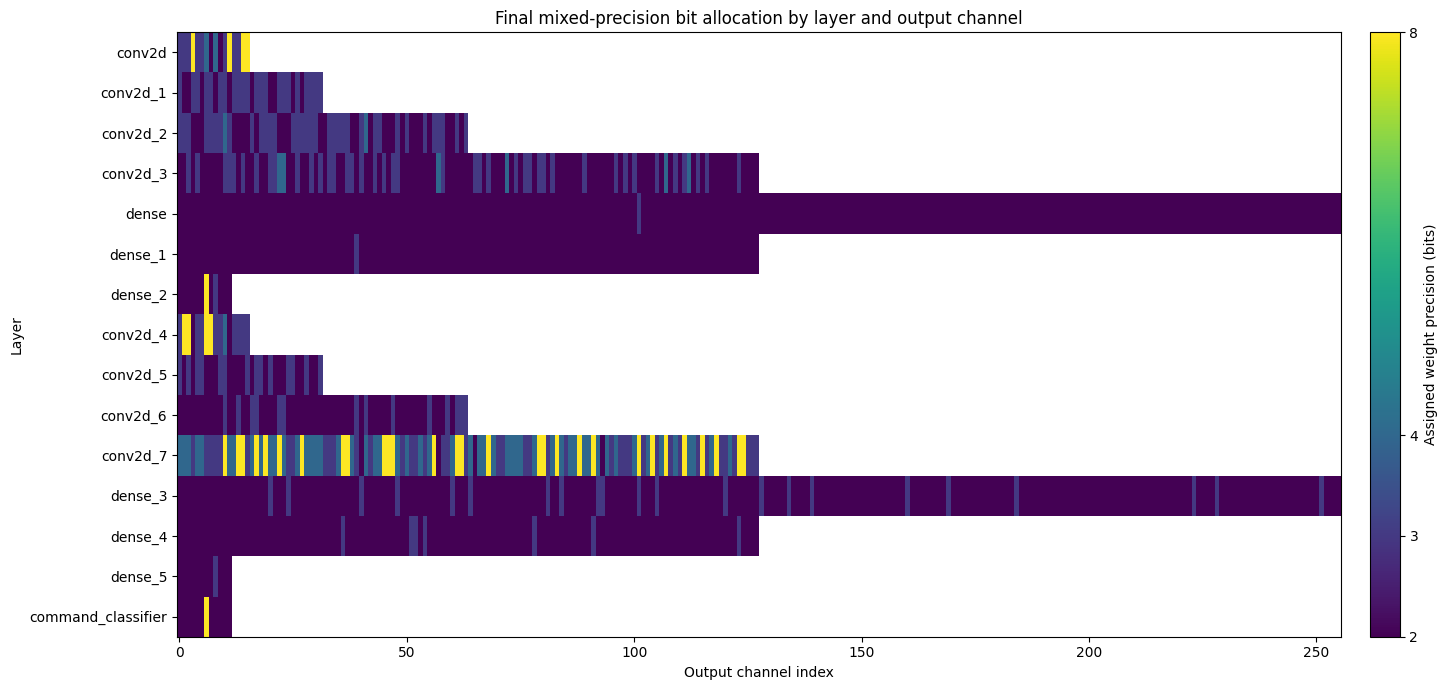


GLOBAL BIT DISTRIBUTION


,Precision,Channels,Channel share (%),Kernel weights,Parameter share (%)
0,W2,963,75.00%,6367176,91.60%
1,W3,218,16.98%,560400,8.06%
2,W4,64,4.98%,15408,0.22%
3,W8,39,3.04%,7704,0.11%


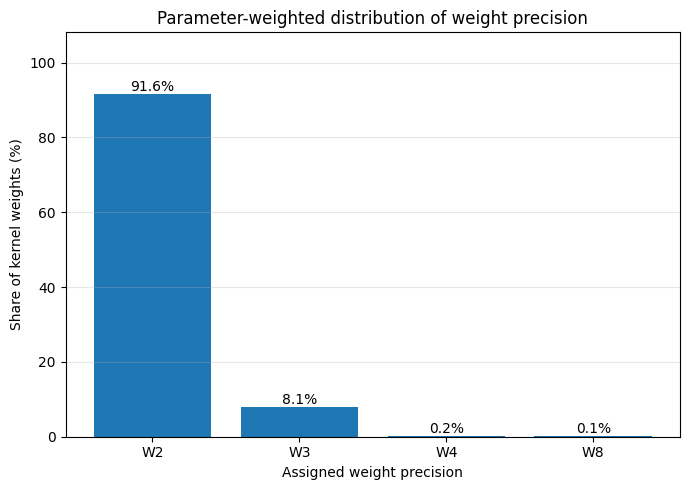


PER-LAYER BIT ALLOCATION


,layer,n_channels,n_kernel_weights,W2_channels,W3_channels,W4_channels,W8_channels,avg_channel_bits,avg_weight_bits
0,conv2d,16,256,2,8,2,4,4.250,4.250
1,conv2d_1,32,8192,10,22,0,0,2.688,2.688
2,conv2d_2,64,8192,27,35,2,0,2.609,2.609
3,conv2d_3,128,32768,81,41,6,0,2.414,2.414
4,dense,256,753664,255,1,0,0,2.004,2.004
5,dense_1,128,32768,127,1,0,0,2.008,2.008
6,dense_2,12,1536,10,1,0,1,2.583,2.583
7,conv2d_4,16,256,2,9,1,4,4.188,4.188
8,conv2d_5,32,8192,18,14,0,0,2.438,2.438
9,conv2d_6,64,8192,50,14,0,0,2.219,2.219



FINAL PROPOSED CONFIGURATION — COMPACT SUMMARY


,Method,Weight distribution,Avg. W bits,Activation bits,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Relative BA Drop (%),Ideal kernel compression,Estimated compression,FP32 storage (MiB),Estimated quantized storage (MiB),Estimated memory reduction (%)
0,Proposed Method,"W2: 91.6%, W3: 8.1%, W4: 0.2%, W8: 0.1%",2.092,3,0.7727,0.8089,0.6579,0.8089,0.7029,7.71%,15.30x,15.22x,26.5197,1.7430,93.43%



STORAGE / COMPRESSION SUMMARY
Total kernel weights:                  6,950,688
Total quantized output channels:       1,284

Simple average channel allocation:     2.4517 bits
Parameter-weighted average W precision: 2.0917 bits

FP32 reference storage:                26.5197 MiB
Ideal packed quantized kernels:        1.7332 MiB
Estimated quantized storage:           1.7430 MiB

Ideal kernel compression:              15.30x
Ideal kernel memory reduction:         93.46%

Estimated compression incl. overhead:  15.22x
Estimated reduction incl. overhead:    93.43%

Metadata assumption:                   32 bits/output channel
Bias assumption:                       FP32

IMPORTANT: these storage/compression values describe theoretical/estimated packed representations.
The fake-quantized Keras model itself still stores dequantized float32 tensors.

FINAL CONFIGURATION ANALYSIS COMPLETE
✓ Layer/channel bit map generated
✓ Parameter-weighted bit distribution generated
✓ Parameter-weighted aver

In [ ]:
# ============================================================
# FINAL PROPOSED CONFIGURATION ANALYSIS
#
# Produces:
#   1. Bit map: layer × output channel
#   2. Parameter-weighted W2/W3/W4/W8 distribution
#   3. Compact final configuration table
#   4. Theoretical / estimated compression information
#
# IMPORTANT:
#   - Uses the FROZEN configuration from:
#         activation_results["layer_records"]
#
#   - Does NOT perform calibration, validation, or test inference.
#   - Test metrics are only READ from final_quantized_test_results.
#   - The model remains fake-quantized; storage values below are
#     theoretical / estimated packed-storage values.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import gc


# ============================================================
# 0. SETTINGS
# ============================================================

FP32_BITS = 32

# Storage assumption:
# one FP32 metadata value per quantized output channel.
METADATA_BITS_PER_CHANNEL = 32


# ============================================================
# 1. CHECK REQUIRED VARIABLES
# ============================================================

required_variables = [
    "activation_results",
    "fp32_test_results",
    "final_quantized_test_results",
]

for variable_name in required_variables:

    if variable_name not in globals():

        raise RuntimeError(
            f"{variable_name} does not exist. "
            f"Run the corresponding previous cell first."
        )


if "layer_records" not in activation_results:

    raise KeyError(
        "activation_results does not contain 'layer_records'."
    )


layer_records = activation_results["layer_records"]


# Selected activation precision
best_activation = activation_results.get(
    "best",
    None
)

if best_activation is not None:

    # Try to obtain it directly if stored.
    activation_bits = best_activation.get(
        "activation_bits",
        None
    )

    # Otherwise infer from configuration string, e.g. Wmixed-A3
    if activation_bits is None:

        config_string = str(
            best_activation.get(
                "configuration",
                ""
            )
        )

        import re

        match = re.search(
            r"A(\d+)",
            config_string
        )

        if match:

            activation_bits = int(
                match.group(1)
            )

        else:

            activation_bits = 3

else:

    # Final selected configuration in this experiment
    activation_bits = 3


print("\n" + "=" * 110)
print("FINAL PROPOSED CONFIGURATION ANALYSIS")
print("=" * 110)

print(
    f"Quantized layers recorded: "
    f"{len(layer_records)}"
)

print(
    f"Selected activation precision: "
    f"A{activation_bits}"
)

print(
    "Configuration source: "
    "activation_results['layer_records']"
)

print(
    "No calibration / validation / test inference "
    "is performed in this cell."
)

print("=" * 110)


# ============================================================
# 2. LOAD FP32 MODEL ONLY TO INSPECT KERNEL SHAPES
# ============================================================

fp32_model = load_fresh_model()


# ============================================================
# 3. MATCH LAYER RECORDS TO MODEL LAYERS
# ============================================================

name_to_record = {

    rec["layer_name"]: rec

    for rec in layer_records
}


analysis_rows = []

global_parameter_counts = {
    2: 0,
    3: 0,
    4: 0,
    8: 0,
}

global_channel_counts = {
    2: 0,
    3: 0,
    4: 0,
    8: 0,
}


total_kernel_weights = 0
total_bias_values = 0
total_channels = 0

total_quant_kernel_bits = 0
total_fp32_kernel_bits = 0
total_fp32_bias_bits = 0
total_metadata_bits = 0


for layer in collect_all_weight_layers(
    fp32_model
):

    if layer.name not in name_to_record:
        continue

    weights = layer.get_weights()

    if not weights:
        continue

    W = np.asarray(
        weights[0]
    )

    bias = (
        np.asarray(weights[1])
        if len(weights) > 1
        else None
    )

    assigned_bits = np.asarray(
        name_to_record[
            layer.name
        ]["assigned_bits"],
        dtype=int
    )

    # --------------------------------------------------------
    # Output channels are assumed to be the last dimension:
    #
    # Conv2D:
    # [kh, kw, input_channels, output_channels]
    #
    # Dense:
    # [input_features, output_features]
    # --------------------------------------------------------

    out_channels = int(
        W.shape[-1]
    )

    if len(assigned_bits) != out_channels:

        raise ValueError(
            f"{layer.name}: "
            f"{out_channels} output channels but "
            f"{len(assigned_bits)} assigned bit-widths."
        )

    weights_per_channel = int(
        np.prod(
            W.shape[:-1]
        )
    )

    n_kernel_weights = int(
        W.size
    )

    n_bias_values = (
        int(bias.size)
        if bias is not None
        else 0
    )

    # --------------------------------------------------------
    # Count channels and PARAMETERS at each precision
    # --------------------------------------------------------

    channel_counts = {}
    parameter_counts = {}

    for bit_width in [2, 3, 4, 8]:

        n_channels_at_bit = int(
            np.sum(
                assigned_bits == bit_width
            )
        )

        n_parameters_at_bit = (
            n_channels_at_bit
            * weights_per_channel
        )

        channel_counts[
            bit_width
        ] = n_channels_at_bit

        parameter_counts[
            bit_width
        ] = n_parameters_at_bit

        global_channel_counts[
            bit_width
        ] += n_channels_at_bit

        global_parameter_counts[
            bit_width
        ] += n_parameters_at_bit

    # --------------------------------------------------------
    # Quantized kernel storage
    # --------------------------------------------------------

    quant_kernel_bits = int(
        np.sum(
            assigned_bits
            * weights_per_channel
        )
    )

    fp32_kernel_bits = (
        n_kernel_weights
        * FP32_BITS
    )

    fp32_bias_bits = (
        n_bias_values
        * FP32_BITS
    )

    metadata_bits = (
        out_channels
        * METADATA_BITS_PER_CHANNEL
    )

    # --------------------------------------------------------
    # Average precision
    # --------------------------------------------------------

    avg_channel_bits = float(
        np.mean(
            assigned_bits
        )
    )

    avg_weight_bits = (
        quant_kernel_bits
        / max(
            n_kernel_weights,
            1
        )
    )

    # --------------------------------------------------------
    # Save layer information
    # --------------------------------------------------------

    analysis_rows.append({

        "layer":
            layer.name,

        "n_channels":
            out_channels,

        "weights_per_channel":
            weights_per_channel,

        "n_kernel_weights":
            n_kernel_weights,

        "assigned_bits":
            assigned_bits,

        "W2_channels":
            channel_counts[2],

        "W3_channels":
            channel_counts[3],

        "W4_channels":
            channel_counts[4],

        "W8_channels":
            channel_counts[8],

        "W2_weights":
            parameter_counts[2],

        "W3_weights":
            parameter_counts[3],

        "W4_weights":
            parameter_counts[4],

        "W8_weights":
            parameter_counts[8],

        "avg_channel_bits":
            avg_channel_bits,

        "avg_weight_bits":
            avg_weight_bits,

        "quant_kernel_bits":
            quant_kernel_bits,

        "fp32_kernel_bits":
            fp32_kernel_bits,

        "fp32_bias_bits":
            fp32_bias_bits,

        "metadata_bits":
            metadata_bits,
    })

    # --------------------------------------------------------
    # Global accumulation
    # --------------------------------------------------------

    total_kernel_weights += (
        n_kernel_weights
    )

    total_bias_values += (
        n_bias_values
    )

    total_channels += (
        out_channels
    )

    total_quant_kernel_bits += (
        quant_kernel_bits
    )

    total_fp32_kernel_bits += (
        fp32_kernel_bits
    )

    total_fp32_bias_bits += (
        fp32_bias_bits
    )

    total_metadata_bits += (
        metadata_bits
    )


analysis_df = pd.DataFrame(
    analysis_rows
)


if len(analysis_df) == 0:

    raise RuntimeError(
        "No matching quantized layers were found."
    )


# ============================================================
# 4. GLOBAL PRECISION / STORAGE STATISTICS
# ============================================================

# Parameter-weighted average W precision
global_avg_weight_bits = (
    total_quant_kernel_bits
    / total_kernel_weights
)


# Simple average over channels
total_assigned_channel_bits = sum(

    int(
        np.sum(
            row["assigned_bits"]
        )
    )

    for row in analysis_rows
)


global_avg_channel_bits = (
    total_assigned_channel_bits
    / total_channels
)


# ------------------------------------------------------------
# FP32 storage reference
# ------------------------------------------------------------

fp32_total_bits = (
    total_fp32_kernel_bits
    + total_fp32_bias_bits
)


# ------------------------------------------------------------
# Ideal packed kernel storage
#
# Only quantized kernel codes.
# ------------------------------------------------------------

ideal_quant_kernel_bits = (
    total_quant_kernel_bits
)


ideal_kernel_compression = (
    total_fp32_kernel_bits
    / ideal_quant_kernel_bits
)


ideal_kernel_reduction_pct = (
    100.0
    * (
        1.0
        - (
            ideal_quant_kernel_bits
            / total_fp32_kernel_bits
        )
    )
)


# ------------------------------------------------------------
# Estimated packed storage + overhead
#
# Quantized kernels
# + FP32 biases
# + metadata
# ------------------------------------------------------------

estimated_quant_total_bits = (
    total_quant_kernel_bits
    + total_fp32_bias_bits
    + total_metadata_bits
)


estimated_compression_ratio = (
    fp32_total_bits
    / estimated_quant_total_bits
)


estimated_memory_reduction_pct = (
    100.0
    * (
        1.0
        - (
            estimated_quant_total_bits
            / fp32_total_bits
        )
    )
)


fp32_MB = (
    fp32_total_bits
    / 8
    / 1024**2
)


ideal_quant_kernel_MB = (
    ideal_quant_kernel_bits
    / 8
    / 1024**2
)


estimated_quant_MB = (
    estimated_quant_total_bits
    / 8
    / 1024**2
)


# ============================================================
# 5. FIGURE 1 — BIT MAP: LAYER × OUTPUT CHANNEL
# ============================================================

max_channels = max(
    len(row["assigned_bits"])
    for row in analysis_rows
)


bit_map = np.full(
    (
        len(analysis_rows),
        max_channels
    ),
    np.nan,
    dtype=float
)


layer_names = []


for i, row in enumerate(
    analysis_rows
):

    bits = row[
        "assigned_bits"
    ]

    bit_map[
        i,
        :len(bits)
    ] = bits

    layer_names.append(
        row["layer"]
    )


masked_bit_map = np.ma.masked_invalid(
    bit_map
)


fig, ax = plt.subplots(
    figsize=(16, 7)
)


im = ax.imshow(
    masked_bit_map,
    aspect="auto",
    interpolation="nearest",
    vmin=2,
    vmax=8
)


cbar = fig.colorbar(
    im,
    ax=ax,
    pad=0.02
)


cbar.set_label(
    "Assigned weight precision (bits)"
)


cbar.set_ticks(
    [2, 3, 4, 8]
)


ax.set_yticks(
    np.arange(
        len(layer_names)
    )
)


ax.set_yticklabels(
    layer_names
)


ax.set_xlabel(
    "Output channel index"
)


ax.set_ylabel(
    "Layer"
)


ax.set_title(
    "Final mixed-precision bit allocation by layer and output channel"
)


plt.tight_layout()
plt.show()


# ============================================================
# 6. PARAMETER-WEIGHTED BIT DISTRIBUTION
# ============================================================

parameter_distribution_rows = []


for bit_width in [
    2,
    3,
    4,
    8
]:

    n_weights = (
        global_parameter_counts[
            bit_width
        ]
    )

    parameter_percentage = (
        100.0
        * n_weights
        / total_kernel_weights
    )

    n_channels = (
        global_channel_counts[
            bit_width
        ]
    )

    channel_percentage = (
        100.0
        * n_channels
        / total_channels
    )

    parameter_distribution_rows.append({

        "Precision":
            f"W{bit_width}",

        "Channels":
            n_channels,

        "Channel share (%)":
            channel_percentage,

        "Kernel weights":
            n_weights,

        "Parameter share (%)":
            parameter_percentage,
    })


parameter_distribution_df = pd.DataFrame(
    parameter_distribution_rows
)


print(
    "\n"
    + "=" * 110
)

print(
    "GLOBAL BIT DISTRIBUTION"
)

print(
    "=" * 110
)


display(
    parameter_distribution_df.style.format({

        "Channel share (%)":
            "{:.2f}%",

        "Parameter share (%)":
            "{:.2f}%",
    })
)


# ============================================================
# 7. FIGURE 2 — PARAMETER-WEIGHTED DISTRIBUTION
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 5)
)


bars = ax.bar(
    parameter_distribution_df[
        "Precision"
    ],
    parameter_distribution_df[
        "Parameter share (%)"
    ]
)


ax.set_xlabel(
    "Assigned weight precision"
)


ax.set_ylabel(
    "Share of kernel weights (%)"
)


ax.set_title(
    "Parameter-weighted distribution of weight precision"
)


max_share = parameter_distribution_df[
    "Parameter share (%)"
].max()


ax.set_ylim(
    0,
    max(
        max_share * 1.18,
        1
    )
)


ax.grid(
    True,
    axis="y",
    alpha=0.3
)


for bar, value in zip(

    bars,

    parameter_distribution_df[
        "Parameter share (%)"
    ]
):

    ax.text(

        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height(),

        f"{value:.1f}%",

        ha="center",
        va="bottom"
    )


plt.tight_layout()
plt.show()


# ============================================================
# 8. OPTIONAL — PER-LAYER BIT ALLOCATION TABLE
# ============================================================

layer_display_columns = [

    "layer",

    "n_channels",

    "n_kernel_weights",

    "W2_channels",

    "W3_channels",

    "W4_channels",

    "W8_channels",

    "avg_channel_bits",

    "avg_weight_bits",
]


print(
    "\n"
    + "=" * 110
)

print(
    "PER-LAYER BIT ALLOCATION"
)

print(
    "=" * 110
)


display(
    analysis_df[
        layer_display_columns
    ].style.format({

        "avg_channel_bits":
            "{:.3f}",

        "avg_weight_bits":
            "{:.3f}",
    })
)


# ============================================================
# 9. BUILD PARAMETER-WEIGHTED DISTRIBUTION STRING
# ============================================================

distribution_dict = {

    row["Precision"]:
        float(
            row["Parameter share (%)"]
        )

    for _, row
    in parameter_distribution_df.iterrows()
}


distribution_string = (

    f"W2: "
    f"{distribution_dict.get('W2', 0):.1f}%, "

    f"W3: "
    f"{distribution_dict.get('W3', 0):.1f}%, "

    f"W4: "
    f"{distribution_dict.get('W4', 0):.1f}%, "

    f"W8: "
    f"{distribution_dict.get('W8', 0):.1f}%"
)


# ============================================================
# 10. GET FINAL TEST METRICS
# ============================================================

final_accuracy = float(
    final_quantized_test_results[
        "accuracy"
    ]
)


final_ba = float(
    final_quantized_test_results[
        "balanced_accuracy"
    ]
)


final_macro_precision = float(
    final_quantized_test_results[
        "macro_precision"
    ]
)


final_macro_recall = float(
    final_quantized_test_results[
        "macro_recall"
    ]
)


final_macro_f1 = float(
    final_quantized_test_results[
        "macro_f1"
    ]
)


fp32_ba = float(
    fp32_test_results[
        "balanced_accuracy"
    ]
)


relative_ba_drop = (
    100.0
    * (
        fp32_ba
        - final_ba
    )
    / fp32_ba
)


# ============================================================
# 11. FINAL COMPACT CONFIGURATION TABLE
# ============================================================

final_configuration_df = pd.DataFrame([

    {
        "Method":
            "Proposed Method",

        "Weight distribution":
            distribution_string,

        "Avg. W bits":
            global_avg_weight_bits,

        "Activation bits":
            activation_bits,

        "Accuracy":
            final_accuracy,

        "Balanced Accuracy":
            final_ba,

        "Macro Precision":
            final_macro_precision,

        "Macro Recall":
            final_macro_recall,

        "Macro F1":
            final_macro_f1,

        "Relative BA Drop (%)":
            relative_ba_drop,

        "Ideal kernel compression":
            ideal_kernel_compression,

        "Estimated compression":
            estimated_compression_ratio,

        "FP32 storage (MiB)":
            fp32_MB,

        "Estimated quantized storage (MiB)":
            estimated_quant_MB,

        "Estimated memory reduction (%)":
            estimated_memory_reduction_pct,
    }

])


print(
    "\n"
    + "=" * 140
)

print(
    "FINAL PROPOSED CONFIGURATION — COMPACT SUMMARY"
)

print(
    "=" * 140
)


display(

    final_configuration_df.style.format({

        "Avg. W bits":
            "{:.3f}",

        "Accuracy":
            "{:.4f}",

        "Balanced Accuracy":
            "{:.4f}",

        "Macro Precision":
            "{:.4f}",

        "Macro Recall":
            "{:.4f}",

        "Macro F1":
            "{:.4f}",

        "Relative BA Drop (%)":
            "{:.2f}%",

        "Ideal kernel compression":
            "{:.2f}x",

        "Estimated compression":
            "{:.2f}x",

        "FP32 storage (MiB)":
            "{:.4f}",

        "Estimated quantized storage (MiB)":
            "{:.4f}",

        "Estimated memory reduction (%)":
            "{:.2f}%",
    })
)


# ============================================================
# 12. STORAGE SUMMARY
# ============================================================

print(
    "\n"
    + "=" * 110
)

print(
    "STORAGE / COMPRESSION SUMMARY"
)

print(
    "=" * 110
)


print(
    f"Total kernel weights:                  "
    f"{total_kernel_weights:,}"
)


print(
    f"Total quantized output channels:       "
    f"{total_channels:,}"
)


print()


print(
    f"Simple average channel allocation:     "
    f"{global_avg_channel_bits:.4f} bits"
)


print(
    f"Parameter-weighted average W precision:"
    f" {global_avg_weight_bits:.4f} bits"
)


print()


print(
    f"FP32 reference storage:                "
    f"{fp32_MB:.4f} MiB"
)


print(
    f"Ideal packed quantized kernels:        "
    f"{ideal_quant_kernel_MB:.4f} MiB"
)


print(
    f"Estimated quantized storage:           "
    f"{estimated_quant_MB:.4f} MiB"
)


print()


print(
    f"Ideal kernel compression:              "
    f"{ideal_kernel_compression:.2f}x"
)


print(
    f"Ideal kernel memory reduction:         "
    f"{ideal_kernel_reduction_pct:.2f}%"
)


print()


print(
    f"Estimated compression incl. overhead:  "
    f"{estimated_compression_ratio:.2f}x"
)


print(
    f"Estimated reduction incl. overhead:    "
    f"{estimated_memory_reduction_pct:.2f}%"
)


print()


print(
    f"Metadata assumption:                   "
    f"{METADATA_BITS_PER_CHANNEL} bits/output channel"
)


print(
    "Bias assumption:                       "
    "FP32"
)


print()


print(
    "IMPORTANT: these storage/compression values describe "
    "theoretical/estimated packed representations."
)


print(
    "The fake-quantized Keras model itself still stores "
    "dequantized float32 tensors."
)


print(
    "=" * 110
)


# ============================================================
# 13. CLEANUP
# ============================================================

del fp32_model

tf.keras.backend.clear_session()

gc.collect()


# ============================================================
# 14. FINAL STATUS
# ============================================================

print(
    "\n"
    + "=" * 110
)

print(
    "FINAL CONFIGURATION ANALYSIS COMPLETE"
)

print(
    "=" * 110
)

print(
    "✓ Layer/channel bit map generated"
)

print(
    "✓ Parameter-weighted bit distribution generated"
)

print(
    "✓ Parameter-weighted average W precision calculated"
)

print(
    "✓ Compact final configuration table generated"
)

print(
    "✓ Theoretical packed compression calculated"
)

print(
    "✓ Estimated compression with overhead calculated"
)

print(
    "✓ No new test-set inference performed"
)

print(
    "=" * 110
)


# ─────────────────────────────────────────────────────
# 🎯 9. COMPRESSION ANALYSIS METHODS
# ─────────────────────────────────────────────────────

In [ ]:
def compression_analysis_pwlq(model, bits_list=[2, 3, 4, 8], mode="channel", zero_point=False):
    assert mode in ("channel", "layer"), "mode must be 'channel' or 'layer'"

    total_weight_params = 0
    total_bias_params   = 0
    total_scale_factors = 0

    def process_layer(layer):
        nonlocal total_weight_params, total_bias_params, total_scale_factors

        # Recurse into nested models
        if isinstance(layer, tf.keras.Model):
            for sub_layer in layer.layers:
                process_layer(sub_layer)
            return

        if isinstance(layer, (tf.keras.layers.Conv2D, tf.keras.layers.Dense)):
            weights = layer.get_weights()
            if not weights:
                return
            kernel = weights[0]
            total_weight_params += kernel.size

            # Conv2D: (kH, kW, in_ch, out_ch) — Dense: (in_features, out_features)
            out_channels = kernel.shape[-1]

            if mode == "channel":
                total_scale_factors += out_channels
            else:
                total_scale_factors += 1

            if layer.use_bias and len(weights) > 1:
                total_bias_params += weights[1].size

    for layer in model.layers:
        process_layer(layer)

    original_bits      = 32
    weight_original_mb = (total_weight_params * original_bits) / (8 * 1024**2)
    bias_mb            = (total_bias_params   * original_bits) / (8 * 1024**2)

    # PWLQ specific overhead:
    # - 2 scale factors per channel/layer (center + tail region)
    # - 1 breakpoint per channel/layer (float32)
    # - optionally 2 zero points per channel/layer if asymmetric
    scale_mb      = (total_scale_factors * 2 * original_bits) / (8 * 1024**2)  # x2 vs uniform
    breakpoint_mb = (total_scale_factors * 1 * original_bits) / (8 * 1024**2)  # breakpoint p
    zp_mb         = (total_scale_factors * 2 * 32) / (8 * 1024**2) if zero_point else 0.0  # x2 vs uniform

    total_original_mb = weight_original_mb + bias_mb

    print(f"Mode:              per-{'channel' if mode == 'channel' else 'layer'}")
    print(f"Quantization:      PWLQ {'asymmetric (2 scales + 2 zp + breakpoint)' if zero_point else 'symmetric (2 scales + breakpoint)'}")
    print(f"Weight params:     {total_weight_params:,}")
    print(f"Bias params:       {total_bias_params:,}")
    print(f"Scale factors:     {total_scale_factors * 2:,} ({scale_mb:.4f} MB) — 2 per {'channel' if mode == 'channel' else 'layer'}")
    print(f"Breakpoints:       {total_scale_factors:,} ({breakpoint_mb:.4f} MB) — 1 per {'channel' if mode == 'channel' else 'layer'}")
    if zero_point:
        print(f"Zero points:       {total_scale_factors * 2:,} ({zp_mb:.4f} MB) — 2 per {'channel' if mode == 'channel' else 'layer'}")
    print(f"Original size:     {total_original_mb:.4f} MB (float32)")
    print(f"{'─'*95}")
    print(f"{'Bits':<8} {'Weight MB':<14} {'Bias MB':<10} {'Scale MB':<12} {'BKP MB':<10} {'ZP MB':<10} {'Total MB':<12} {'Compression'}")
    print(f"{'─'*95}")
    for bits in sorted(bits_list):
        weight_quantized_mb = (total_weight_params * bits) / (8 * 1024**2)
        total_quantized_mb  = weight_quantized_mb + bias_mb + scale_mb + breakpoint_mb + zp_mb
        ratio               = total_original_mb / total_quantized_mb
        print(f"{bits:<8} {weight_quantized_mb:<14.4f} {bias_mb:<10.4f} {scale_mb:<12.4f} {breakpoint_mb:<10.4f} {zp_mb:<10.4f} {total_quantized_mb:<12.4f} x{ratio:.2f}")
    print(f"{'─'*95}")

# symmetric PWLQ
compression_analysis_pwlq(model, bits_list=[2, 3, 4, 8], mode="channel", zero_point=False)
# asymmetric PWLQ
compression_analysis_pwlq(model, bits_list=[2, 3, 4, 8], mode="channel", zero_point=True)

# layer-wise symmetric PWLQ
compression_analysis_pwlq(model, bits_list=[2, 3, 4, 8], mode="layer", zero_point=False)
# layer-wise asymmetric PWLQ
compression_analysis_pwlq(model, bits_list=[2, 3, 4, 8], mode="layer", zero_point=True)

In [ ]:
def analyze_model_weights(model, prefix=""):
    """
    Recursively analyzes every Conv2D and Dense layer in a Keras model,
    printing and returning the number of weights per channel and per layer.

    Returns:
        dict: {
            layer_name: {
                "shape":               tuple,
                "out_channels":        int,
                "weights_per_channel": int,
                "total_weights":       int
            }
        }
    """
    info = {}

    for layer in model.layers:
        full_name = f"{prefix}.{layer.name}" if prefix else layer.name

        # Recurse into nested models (e.g. MFCC/MSLFB sub-models in ensemble)
        if isinstance(layer, tf.keras.Model):
            sub_info = analyze_model_weights(layer, full_name)
            info.update(sub_info)
            continue

        if not isinstance(layer, (tf.keras.layers.Conv2D, tf.keras.layers.Dense)):
            continue

        weights = layer.get_weights()
        if not weights:
            continue

        kernel = weights[0]
        out_ch         = kernel.shape[-1]
        weights_per_ch = kernel[..., 0].size   # all dims except out_channel
        total_weights  = kernel.size

        info[full_name] = {
            "shape":               kernel.shape,
            "out_channels":        out_ch,
            "weights_per_channel": weights_per_ch,
            "total_weights":       total_weights
        }

        print(f"Layer: {full_name}")
        print(f"  shape:               {kernel.shape}")
        print(f"  out_channels:        {out_ch}")
        print(f"  weights_per_channel: {weights_per_ch}")
        print(f"  total_weights:       {total_weights}")
        print()

    return info

In [ ]:
def compression_analysis(model, bits_list=[2, 3, 4, 8], mode="channel", zero_point=False):
    assert mode in ("channel", "layer"), "mode must be 'channel' or 'layer'"

    total_weight_params = 0
    total_bias_params   = 0
    total_scale_factors = 0

    def process_layer(layer):
        nonlocal total_weight_params, total_bias_params, total_scale_factors

        # Recurse into nested models
        if isinstance(layer, tf.keras.Model):
            for sub_layer in layer.layers:
                process_layer(sub_layer)
            return

        if isinstance(layer, (tf.keras.layers.Conv2D, tf.keras.layers.Dense)):
            weights = layer.get_weights()
            if not weights:
                return
            kernel = weights[0]
            total_weight_params += kernel.size

            if isinstance(layer, tf.keras.layers.Conv2D):
                # Conv2D kernel shape: (kH, kW, in_ch, out_ch)
                out_channels = kernel.shape[-1]
            else:
                # Dense kernel shape: (in_features, out_features)
                out_channels = kernel.shape[-1]

            if mode == "channel":
                total_scale_factors += out_channels  # one scale per out_channel/neuron
            else:
                total_scale_factors += 1             # one scale per layer

            if layer.use_bias and len(weights) > 1:
                total_bias_params += weights[1].size

    for layer in model.layers:
        process_layer(layer)

    original_bits      = 32
    weight_original_mb = (total_weight_params * original_bits) / (8 * 1024**2)
    bias_mb            = (total_bias_params   * original_bits) / (8 * 1024**2)
    scale_mb           = (total_scale_factors * original_bits) / (8 * 1024**2)
    zp_mb              = (total_scale_factors * 32)            / (8 * 1024**2) if zero_point else 0.0
    total_original_mb  = weight_original_mb + bias_mb

    print(f"Mode:              per-{'channel' if mode == 'channel' else 'layer'}")
    print(f"Quantization:      {'asymmetric (scale + zero_point)' if zero_point else 'symmetric (scale only)'}")
    print(f"Weight params:     {total_weight_params:,}")
    print(f"Bias params:       {total_bias_params:,}")
    print(f"Scale factors:     {total_scale_factors:,} ({scale_mb:.4f} MB at float32)")
    if zero_point:
        print(f"Zero points:       {total_scale_factors:,} ({zp_mb:.4f} MB at int32)")
    print(f"Original size:     {total_original_mb:.4f} MB (float32)")
    print(f"{'─'*85}")
    print(f"{'Bits':<8} {'Weight MB':<14} {'Bias MB':<10} {'Scale MB':<12} {'ZP MB':<10} {'Total MB':<12} {'Compression'}")
    print(f"{'─'*85}")
    for bits in sorted(bits_list):
        weight_quantized_mb = (total_weight_params * bits) / (8 * 1024**2)
        total_quantized_mb  = weight_quantized_mb + bias_mb + scale_mb + zp_mb
        ratio               = total_original_mb / total_quantized_mb
        print(f"{bits:<8} {weight_quantized_mb:<14.4f} {bias_mb:<10.4f} {scale_mb:<12.4f} {zp_mb:<10.4f} {total_quantized_mb:<12.4f} x{ratio:.2f}")
    print(f"{'─'*85}")

# symmetric (no zero point)
compression_analysis(model, bits_list=[2, 3, 4, 8], mode="channel", zero_point=False)
# asymmetric (with zero point)
compression_analysis(model, bits_list=[2, 3, 4, 8], mode="channel", zero_point=True)

# layer-wise symmetric (no zero point)
compression_analysis(model, bits_list=[2, 3, 4, 8], mode="layer", zero_point=False)
# layer-wise asymmetric (with zero point)
compression_analysis(model, bits_list=[2, 3, 4, 8], mode="layer", zero_point=True)

In [ ]:
def print_unique_weights(model, max_print=16, prefix=""):
    for layer in model.layers:
        layer_name = f"{prefix}/{layer.name}" if prefix else layer.name

        if isinstance(layer, (tf.keras.Model, tf.keras.Sequential)):
            print_unique_weights(layer, max_print, prefix=layer_name)
            continue

        if not layer.get_weights():
            continue

        kernel = layer.get_weights()[0]

        if kernel.ndim != 4:
            continue

        w = tf.reshape(kernel, [-1])
        unique_vals = tf.sort(tf.unique(w).y)

        print(f"\n{layer_name}")
        print(f"  kernel shape: {kernel.shape}")
        print(f"  number of unique weights: {unique_vals.shape[0]}")
        print(f"  first {min(max_print, unique_vals.shape[0])} values:")
        print(unique_vals[:max_print].numpy())


# ─────────────────────────────────────────────────────
# 🔬 10. STATE OF THE ART METHODS
# ─────────────────────────────────────────────────────

## ─────────────────────────────────────────────────────
## 🔬 10.1 PWLQ
## ─────────────────────────────────────────────────────

In [ ]:
import os
import sys
import numpy as np
import torch
import tensorflow as tf
from tensorflow.keras.models import load_model

sys.path.append("/content")
from pwlq.pwlq import piecewise_linear_quant


def quantize_model_pwlq(
    model,
    bits,
    scale_bits=0,
    break_point="norm",
    pw_opt=2,
    approximate=True,
    granularity="per_layer",
    label=None,
    verbose=True,
):
    assert granularity in ("per_layer", "per_channel"), (
        "granularity must be 'per_layer' or 'per_channel'"
    )

    if label is None:
        label = f"PWLQ {bits}-bit ({granularity})"

    layers = collect_all_weight_layers(model)

    if verbose:
        print(f"\n{'=' * 60}")
        print(f"  {label}")
        print(f"{'=' * 60}")

    for layer in layers:
        weights = layer.get_weights()

        if not weights:
            continue

        W = weights[0]
        b = weights[1] if len(weights) > 1 else None

        w_torch = torch.from_numpy(W.astype(np.float32))

        # ---------------------------------------------------------
        # Per-layer quantization
        # ---------------------------------------------------------
        if granularity == "per_layer":
            qw_flat, _, _ = piecewise_linear_quant(
                w_torch.reshape(-1),
                bits=bits,
                scale_bits=scale_bits,
                break_point_approach=break_point,
                pw_opt=pw_opt,
                approximate=approximate,
            )

            Wq = qw_flat.reshape(w_torch.shape).cpu().numpy()

        # ---------------------------------------------------------
        # Per-channel quantization
        # ---------------------------------------------------------
        else:
            w_flat = w_torch.reshape(w_torch.shape[0], -1)

            qw_list = []

            for c in range(w_flat.shape[0]):
                qw, _, _ = piecewise_linear_quant(
                    w_flat[c],
                    bits=bits,
                    scale_bits=scale_bits,
                    break_point_approach=break_point,
                    pw_opt=pw_opt,
                    approximate=approximate,
                )

                qw_list.append(qw)

            Wq = (
                torch.stack(qw_list)
                .reshape(w_torch.shape)
                .cpu()
                .numpy()
            )

        # Preserve the original bias
        if b is not None:
            layer.set_weights([Wq, b])
        else:
            layer.set_weights([Wq])

        if verbose:
            layer_type = (
                "Conv2D"
                if isinstance(layer, tf.keras.layers.Conv2D)
                else "Dense"
            )

            print(
                f"  {layer.name:<22} "
                f"{layer_type:<8} → "
                f"{bits}-bit ({granularity})"
            )

    if verbose:
        print("\nQuantization complete.")

    return model

In [ ]:
# Load one clean FP32 reference model
revision_model = load_fresh_model()

for bits in [8, 4, 2]:
    for granularity in ["per_layer", "per_channel"]:

        # Load a fresh copy for EVERY quantization run
        quantized_model = load_fresh_model()

        label = f"PWLQ {bits}-bit ({granularity})"

        quantize_model_pwlq(
            quantized_model,
            bits=bits,
            granularity=granularity,
            label=label,
        )

        # Validation set for comparing quantization configurations
        compile_and_evaluate(
            quantized_model,
            val_ds,
            label=label,
        )

        # Compare quantized weights against the fresh FP32 revision model
        #plot_weight_distribution_comparison(revision_model,quantized_model,label=label)


  PWLQ 8-bit (per_layer)
  conv2d                 Conv2D   → 8-bit (per_layer)
  conv2d_1               Conv2D   → 8-bit (per_layer)
  conv2d_2               Conv2D   → 8-bit (per_layer)
  conv2d_3               Conv2D   → 8-bit (per_layer)
  dense                  Dense    → 8-bit (per_layer)
  dense_1                Dense    → 8-bit (per_layer)
  dense_2                Dense    → 8-bit (per_layer)
  conv2d_4               Conv2D   → 8-bit (per_layer)
  conv2d_5               Conv2D   → 8-bit (per_layer)
  conv2d_6               Conv2D   → 8-bit (per_layer)
  conv2d_7               Conv2D   → 8-bit (per_layer)
  dense_3                Dense    → 8-bit (per_layer)
  dense_4                Dense    → 8-bit (per_layer)
  dense_5                Dense    → 8-bit (per_layer)
  command_classifier     Dense    → 8-bit (per_layer)

Quantization complete.

PWLQ 8-bit (per_layer)
Loss:              0.522854
Accuracy:          0.857069 (85.707%)
Balanced Accuracy: 0.864268 (86.427%)
Precision (m

## ─────────────────────────────────────────────────────
## 🔬 10.2 BITSPLIT
## ─────────────────────────────────────────────────────

In [ ]:
import os
import numpy as np
import tensorflow as tf


# ---------------------------------------------------------
# BIT-SPLIT (OFWA) CORE
# ---------------------------------------------------------

def fwa(W, bitwidth):
    """
    Fixed-point Weight Approximation (FWA).

    Minimises || W - alpha * Q ||^2 over integer Q and scale alpha.
    W shape: (out_channels, flattened_kernel_size)
    """
    max_val = 2 ** (bitwidth - 1) - 1

    alpha = np.abs(W).max(axis=1) / max_val
    alpha_old = alpha * 1.1

    while np.linalg.norm(alpha - alpha_old) > 1e-9:
        q = W / alpha[:, None]
        q = np.round(q)
        q = np.clip(q, -max_val, max_val)
        alpha_old = alpha
        alpha = np.sum(W * q, axis=1) / np.sum(q * q, axis=1)

    return q, alpha


def split(Q, bitwidth):
    """
    Bit-Split: decompose integer matrix Q into (bitwidth-1) ternary bit planes.
    Each plane B_k in {-1, 0, +1}. MSB is at index 0 (list reversed at end).

    Note: uses np.int32 instead of the deprecated np.int (removed in NumPy 1.24).
    """
    Q_sign = np.sign(Q)
    Q_abs  = np.abs(Q)
    B_sav  = []

    for _ in range(bitwidth - 1):
        # Extract LSB: equivalent to Q_abs % 2
        B = Q_abs - (Q_abs.astype(np.int32) // 2) * 2
        B *= Q_sign
        B_sav.append(B)
        # Right-shift
        Q_abs = (Q_abs.astype(np.int32) // 2).astype(np.float32)

    return B_sav[::-1]  # MSB first


def get_int_B(B_sav):
    """
    Bit-Stitch: reconstruct fixed-point value from ternary planes.
    q = B0 + B1/2 + B2/4 + ...   (B0 is MSB)
    """
    B_sum = B_sav[0].copy()
    for i in range(1, len(B_sav)):
        B_sum += B_sav[i] / (2 ** i)
    return B_sum


def get_int_B_exclusive(B_sav, bit):
    """
    Bit-Stitch excluding plane `bit`. Used for residual computation.
    """
    B_sum = np.zeros_like(B_sav[0])
    for i in range(len(B_sav)):
        if i == bit:
            continue
        B_sum += B_sav[i] / (2 ** i)
    return B_sum


def get_ot_given_a(W, alpha):
    """
    Optimal ternary update given residual W and scale alpha.
    Implements Eq. (8) from the paper:
      +1 or -1  if |W| >= alpha/2
       0        otherwise
    """
    B = np.sign(W)
    B[np.abs(W) * 2 < alpha[:, None]] = 0
    return B


def ofwa(W, bitwidth, max_epoch=50):
    """
    Optimal Fixed-point Weight Approximation (OFWA).

    Pipeline:
      1. FWA initialisation
      2. Bit-Split
      3. Alternating optimisation of alpha and each bit plane
      4. Bit-Stitch

    Returns
    -------
    B_sav : list of ternary planes
    B_sum : reconstructed fixed-point integer matrix
    alpha : per-channel scale factors
    """
    assert bitwidth >= 3, "OFWA requires bitwidth >= 3"

    Q, alpha = fwa(W, bitwidth)
    B_sav    = split(Q, bitwidth)

    # Reposition decimal point: absorb implicit base 2^(bitwidth-2) into alpha
    # so that get_int_B() works with values in [-1, 1].
    alpha = alpha * (2 ** (bitwidth - 2))

    for _ in range(max_epoch):
        alpha_old = alpha.copy()

        B_sum = get_int_B(B_sav)
        # Least-squares update for alpha (Eq. 4)
        alpha = np.sum(W * B_sum, axis=1) / np.sum(B_sum * B_sum, axis=1)

        if np.linalg.norm(alpha - alpha_old) <= 1e-9:
            break

        # Update each bit plane sequentially (Eq. 5-8)
        for bit in range(bitwidth - 1):
            W_res      = W - get_int_B_exclusive(B_sav, bit) * alpha[:, None]
            B_sav[bit] = get_ot_given_a(W_res * (2 ** bit), alpha)

    B_sum = get_int_B(B_sav)
    return B_sav, B_sum, alpha


# ---------------------------------------------------------
# KERAS KERNEL QUANTIZATION
# ---------------------------------------------------------

def bitsplit_quantize_kernel(kernel, num_bits):
    """
    Apply OFWA to a Keras kernel.

    Conv2D kernel shape: (H, W, Cin, Cout) -> reshape to (Cout, H*W*Cin)
    Dense  kernel shape: (Cin, Cout)        -> transpose to (Cout, Cin)
    """
    original_shape = kernel.shape

    if kernel.ndim == 4:
        # (H, W, Cin, Cout) -> (Cout, H, W, Cin) -> (Cout, H*W*Cin)
        W = np.transpose(kernel, (3, 0, 1, 2))
        W = W.reshape(W.shape[0], -1)

    elif kernel.ndim == 2:
        W = kernel.T  # (Cout, Cin)

    else:
        return kernel  # unknown shape, return unchanged

    _B_sav, B_sum, alpha = ofwa(W, num_bits)

    W_q = B_sum * alpha[:, None]

    if kernel.ndim == 4:
        W_q = W_q.reshape(
            original_shape[3],  # Cout
            original_shape[0],  # H
            original_shape[1],  # W
            original_shape[2],  # Cin
        )
        W_q = np.transpose(W_q, (1, 2, 3, 0))  # back to (H, W, Cin, Cout)
    else:
        W_q = W_q.T  # back to (Cin, Cout)

    return W_q.astype(np.float32)


# ---------------------------------------------------------
# RECURSIVE MODEL QUANTIZATION
# ---------------------------------------------------------

def quantize_all_layers_tf(model, num_bits=8):
    """
    Recursively apply OFWA to Conv2D and Dense layers.
    Recurses into Sequential submodels (e.g. model_mfcc, model_mslfb).
    Biases are always left at full precision.
    """
    assert num_bits >= 3, "Bit-split OFWA requires num_bits >= 3"

    for layer in model.layers:

        # Recurse into Sequential submodels
        if isinstance(layer, tf.keras.Model):
            quantize_all_layers_tf(layer, num_bits)
            continue

        if isinstance(layer, (tf.keras.layers.Conv2D,
                              tf.keras.layers.Dense)):
            weights = layer.get_weights()
            if not weights:
                continue

            W_q = bitsplit_quantize_kernel(weights[0], num_bits)

            if len(weights) == 2:
                layer.set_weights([W_q, weights[1]])  # preserve bias
            else:
                layer.set_weights([W_q])

In [ ]:
# ---------------------------------------------------------
# BITSPLIT — LOAD FRESH MODEL, QUANTIZE, EVALUATE
# ---------------------------------------------------------

# Clean FP32 reference model — never modified
revision_model = load_fresh_model()

for bits in [8, 4, 3]:

    # Fresh revision model for every quantization configuration
    quantized_model = load_fresh_model()

    label = f"BitSplit {bits}-bit (per-channel)"

    # Quantize fresh model
    quantize_all_layers_tf(
        quantized_model,
        num_bits=bits,
    )

    # Evaluate on VALIDATION set while comparing configurations
    compile_and_evaluate(
        quantized_model,
        val_ds,
        label=label,
    )

    # Compare against untouched FP32 revision model
    # plot_weight_distribution_comparison(revision_model,quantized_model,label=label)

## ─────────────────────────────────────────────────────
## 🔬 10.3 ADAROUND
## ─────────────────────────────────────────────────────

In [ ]:
import os
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import load_model


# =========================================================
# SCALE — fixed MSE-optimal, computed once (paper Section 5)
# =========================================================
def compute_initial_scale(w, num_bits):
    qmin = -(2 ** (num_bits - 1))
    qmax =  (2 ** (num_bits - 1)) - 1
    axes = tuple(range(len(w.shape) - 1))

    w_max      = tf.reduce_max(tf.abs(w), axis=axes, keepdims=True) + 1e-8
    scale_init = w_max / qmax

    best_scale = scale_init
    best_mse   = tf.reduce_mean((w - tf.clip_by_value(
                    tf.round(w / scale_init), qmin, qmax) * scale_init) ** 2)

    for alpha in np.linspace(0.7, 1.0, 20):
        s   = scale_init * alpha
        w_q = tf.clip_by_value(tf.round(w / s), qmin, qmax) * s
        mse = tf.reduce_mean((w - w_q) ** 2)
        if mse < best_mse:
            best_mse   = mse
            best_scale = s

    return best_scale, qmin, qmax


# =========================================================
# RECTIFIED SIGMOID h(V) — paper equation (23)
# =========================================================
def rectified_sigmoid(v, gamma=-0.1, zeta=1.1):
    s = tf.sigmoid(v)
    h = s * (zeta - gamma) + gamma
    return tf.clip_by_value(h, 0.0, 1.0)


# =========================================================
# REGULARIZER f_reg — paper equation (24)
# =========================================================
def rounding_regularizer(hv, beta):
    return tf.reduce_sum(1.0 - tf.pow(tf.abs(2.0 * hv - 1.0), beta))


# =========================================================
# COLLECT LAYERS RECURSIVELY
# =========================================================
def collect_quant_layers(model):
    layers = []
    def _collect(layer):
        if isinstance(layer, (tf.keras.layers.Conv2D, tf.keras.layers.Dense)):
            layers.append(layer)
        if hasattr(layer, "layers"):
            for sub in layer.layers:
                _collect(sub)
    for l in model.layers:
        _collect(l)
    return layers


# =========================================================
# CAPTURE LAYER ACTIVATIONS — patches instance not class
# =========================================================
def capture_layer_activations(model, layer, calib_ds):
    """
    Capture input and output activations for a specific layer
    by patching the instance's call method directly.
    Patching the instance (layer.call) instead of the class
    (layer.__class__.call) ensures the hook only fires for
    this specific layer, not all layers of the same type.
    """
    captured = {"inp": [], "out": []}
    original_call = layer.call

    def hooked_call(inputs, *args, **kwargs):
        result = original_call(inputs, *args, **kwargs)
        captured["inp"].append(tf.identity(inputs))
        captured["out"].append(tf.identity(result))
        return result

    layer.call = hooked_call  # patch instance, not class

    for batch in calib_ds:
        x_batch, _ = batch
        model(x_batch, training=False)

    layer.call = original_call  # restore

    return captured["inp"], captured["out"]


# =========================================================
# MANUAL LAYER FORWARD (for Conv2D and Dense)
# =========================================================
def manual_forward(layer, x, w, b):
    if isinstance(layer, tf.keras.layers.Conv2D):
        y = tf.nn.conv2d(x, w, strides=layer.strides, padding=layer.padding.upper())
        if b is not None:
            y = tf.nn.bias_add(y, b)
    elif isinstance(layer, tf.keras.layers.Dense):
        y = tf.matmul(x, w)
        if b is not None:
            y = y + b
    if layer.activation is not None:
        y = layer.activation(y)
    return y


# =========================================================
# ADAROUND — single layer optimization
# =========================================================
def adaround_layer(
    model, layer, calib_ds,
    num_bits=4, num_iters=10000,
    lambda_reg=1.0,
    beta_start=20.0,
    beta_end=2.0,
    warmup=0.2,
    lr=1e-3
):
    weights = layer.get_weights()
    if not weights:
        return

    print(f"\n=== AdaRound: {layer.name} | shape: {weights[0].shape} ===")

    w = tf.constant(weights[0], tf.float32)
    b = tf.constant(weights[1], tf.float32) if len(weights) > 1 else None

    scale, qmin, qmax = compute_initial_scale(w, num_bits)
    w_scaled = w / scale

    # Capture calibration activations
    layer_inputs, layer_outputs = capture_layer_activations(model, layer, calib_ds)

    if not layer_inputs:
        print(f"  WARNING: No activations captured for {layer.name}, skipping.")
        return

    # Baseline naive MSE
    w_naive   = tf.clip_by_value(tf.round(w_scaled), qmin, qmax) * scale
    naive_mse = np.mean([
        tf.reduce_mean((y_fp - manual_forward(layer, x_l, w_naive, b)) ** 2).numpy()
        for x_l, y_fp in zip(layer_inputs, layer_outputs)
    ])
    print(f"  Naive rounding MSE:   {naive_mse:.8f}")

    # Initialize V
    frac         = w_scaled - tf.floor(w_scaled)
    frac_clipped = tf.clip_by_value(frac, 0.001, 0.999)
    gamma, zeta  = -0.1, 1.1
    s_init       = (frac_clipped - gamma) / (zeta - gamma)
    s_init       = tf.clip_by_value(s_init, 0.001, 0.999)
    V            = tf.Variable(tf.math.log(s_init / (1.0 - s_init)), trainable=True)

    optimizer    = tf.keras.optimizers.Adam(lr)
    warmup_iters = int(num_iters * warmup)
    n_batches    = len(layer_inputs)

    for it in range(num_iters):
        progress = max(0.0, (it - warmup_iters) / max(num_iters - warmup_iters, 1))
        beta     = beta_start + (beta_end - beta_start) * progress

        idx  = np.random.randint(0, n_batches)
        x_l  = layer_inputs[idx]
        y_fp = layer_outputs[idx]

        with tf.GradientTape() as tape:
            h_v         = rectified_sigmoid(V)
            w_tilde_int = tf.clip_by_value(tf.floor(w_scaled) + h_v, qmin, qmax)
            w_tilde     = w_tilde_int * scale

            y_q      = manual_forward(layer, x_l, w_tilde, b)
            rec_loss = tf.reduce_mean((y_fp - y_q) ** 2)

            if it >= warmup_iters:
                reg_loss = lambda_reg * rounding_regularizer(h_v, beta)
            else:
                reg_loss = 0.0

            loss = rec_loss + reg_loss

        grads = tape.gradient(loss, [V])
        optimizer.apply_gradients(zip(grads, [V]))

        if it % 1000 == 0 or it == num_iters - 1:
            h_debug = rectified_sigmoid(V)
            pct_up  = tf.reduce_mean(tf.cast(h_debug > 0.5, tf.float32)).numpy() * 100
            print(f"  iter {it:05d} | rec={rec_loss:.2e} | beta={beta:.2f} | >0.5={pct_up:.1f}%")

    # Hard rounding
    h_hard      = tf.cast(rectified_sigmoid(V) >= 0.5, tf.float32)
    w_final_int = tf.clip_by_value(tf.floor(w_scaled) + h_hard, qmin, qmax)
    w_final     = w_final_int * scale

    pct_up = tf.reduce_mean(h_hard).numpy() * 100
    print(f"  Hard rounding: {pct_up:.1f}% rounded up")

    adaround_mse = np.mean([
        tf.reduce_mean((y_fp - manual_forward(layer, x_l, w_final, b)) ** 2).numpy()
        for x_l, y_fp in zip(layer_inputs, layer_outputs)
    ])
    print(f"  AdaRound MSE:         {adaround_mse:.8f}")
    print(f"  MSE improvement:      {naive_mse / max(adaround_mse, 1e-10):.2f}x")

    layer.set_weights([w_final.numpy(), b.numpy()] if b is not None else [w_final.numpy()])


# =========================================================
# APPLY ADAROUND TO FULL MODEL
# =========================================================
def apply_adaround(model, calib_ds, num_bits=4, num_iters=10000):
    quant_layers = collect_quant_layers(model)

    print("Quantizable layers:")
    for i, l in enumerate(quant_layers):
        print(f"  [{i:02d}] {l.name} | shape: {l.get_weights()[0].shape if l.get_weights() else 'N/A'}")

    for layer in quant_layers:
        adaround_layer(model, layer, calib_ds, num_bits=num_bits, num_iters=num_iters)

    print("\nAdaRound complete.")

In [ ]:
# =========================================================
# ADAROUND — CALIBRATE + QUANTIZE + EVALUATE
# =========================================================

# Clean FP32 reference model — never modified
revision_model = load_fresh_model()

# Calibration data:
# 1024 representative samples from the TRAINING set
calib_ds = (
    train_ds
    .unbatch()
    .batch(32)
    .take(1024 // 32)
)

for bits in [8, 4, 2]:

    # Fresh revision model for every quantization configuration
    quantized_model = load_fresh_model()

    label = f"AdaRound {bits}-bit"

    # AdaRound uses calibration data to optimize rounding
    apply_adaround(
        quantized_model,
        calib_ds,
        num_bits=bits,
    )

    # Validation set for comparing bit-widths/configurations
    compile_and_evaluate(
        quantized_model,
        val_ds,
        label=label,
    )

    # Compare against untouched FP32 revision model
    #plot_weight_distribution_comparison(revision_model,quantized_model,label=label)

## ─────────────────────────────────────────────────────
## 🔬 10.4 SUBSETQ
## ─────────────────────────────────────────────────────

In [ ]:
from itertools import combinations
from joblib import Parallel, delayed

# ---------------------------------------------------------
# UNIVERSAL SET & HELPERS
# ---------------------------------------------------------
def gen_universal_set():
    powers = [1.0, 0.5, 0.25, 0.125, 0.0]
    uset   = set()
    for a in powers:
        for b in powers:
            v = a + b
            if v > 0:
                uset.add(round(v, 6))
    uset    = sorted(uset, reverse=True)
    max_val = uset[0]
    uset    = [v / max_val for v in uset]
    return np.array(sorted(set([round(v, 6) for v in uset]), reverse=True))


def find_scale_factor(w_abs, S, max_iter=50, tol=1e-5):
    alpha = 1.0
    for _ in range(max_iter):
        S_scaled  = alpha * S
        qi        = S_scaled[np.argmin(np.abs(w_abs[:, None] - S_scaled[None, :]), axis=1)]
        denom     = np.sum(qi ** 2)
        if denom < 1e-10:
            break
        alpha_new = np.sum(w_abs * qi) / denom
        if abs(alpha_new - alpha) < tol:
            alpha = alpha_new
            break
        alpha = alpha_new
    return alpha


def _find_best_qps_fast(w_flat, combos):
    w_abs  = np.abs(w_flat)
    signs  = np.sign(w_flat)
    signs[signs == 0] = 1

    best_loss = np.inf
    best_wq   = None

    for S in combos:
        S      = np.array(S)
        alpha  = find_scale_factor(w_abs, S)
        S_sc   = alpha * S
        idx    = np.argmin(np.abs(w_abs[:, None] - S_sc[None, :]), axis=1)
        qi     = S_sc[idx]
        wq     = qi * signs
        loss   = np.mean((w_flat - wq) ** 2)
        if loss < best_loss:
            best_loss = loss
            best_wq   = wq

    return best_wq


# ---------------------------------------------------------
# PROCESS ONE CHANNEL — used by joblib
# ---------------------------------------------------------
def _process_channel(w_ch, combos):
    return _find_best_qps_fast(w_ch, combos)


# ---------------------------------------------------------
# PER-CHANNEL SubsetQ — parallelized
# ---------------------------------------------------------
def subset_quantize_channel_wise(W, bits=4, n_jobs=-1):
    Su     = gen_universal_set()
    N      = min(2 ** (bits - 1), len(Su))
    combos = list(combinations(Su, N))
    out_ch = W.shape[-1]
    W_r    = W.reshape(-1, out_ch)

    results = Parallel(n_jobs=n_jobs, prefer='threads')(
        delayed(_process_channel)(W_r[:, c], combos)
        for c in range(out_ch)
    )

    Wq = np.stack(results, axis=1)
    return Wq.reshape(W.shape)


# ---------------------------------------------------------
# PER-LAYER SubsetQ
# ---------------------------------------------------------
def subset_quantize_layer_wise(W, bits=4):
    Su     = gen_universal_set()
    N      = min(2 ** (bits - 1), len(Su))
    combos = list(combinations(Su, N))
    wq     = _find_best_qps_fast(W.flatten(), combos)
    return wq.reshape(W.shape)


# ---------------------------------------------------------
# APPLY TO KERAS MODEL
# ---------------------------------------------------------
def apply_subsetq_keras(model, bits=4, mode="channel", n_jobs=-1):
    assert mode in ("channel", "layer"), "mode must be 'channel' or 'layer'"
    layers = collect_all_weight_layers(model)

    print(f"\n{'='*60}")
    print(f"  SubsetQ {bits}-bit (per-{mode})")
    print(f"{'='*60}")

    for layer in layers:
        weights = layer.get_weights()
        if not weights:
            continue

        W  = weights[0]
        b  = weights[1] if len(weights) > 1 else None
        is_conv = isinstance(layer, tf.keras.layers.Conv2D)

        print(f"  {layer.name:<22} {'Conv2D' if is_conv else 'Dense':<8} "
              f"shape={W.shape}")

        if mode == "channel":
            Wq = subset_quantize_channel_wise(W, bits=bits, n_jobs=n_jobs)
        else:
            Wq = subset_quantize_layer_wise(W, bits=bits)

        layer.set_weights([Wq.astype(np.float32), b] if b is not None
                          else [Wq.astype(np.float32)])

    print("\nQuantization complete.")
    return model


  SubsetQ 4-bit (per-layer)
  conv2d                 Conv2D   shape=(4, 4, 1, 16)
  conv2d_1               Conv2D   shape=(4, 4, 16, 32)
  conv2d_2               Conv2D   shape=(2, 2, 32, 64)
  conv2d_3               Conv2D   shape=(2, 2, 64, 128)
  dense                  Dense    shape=(2944, 256)
  dense_1                Dense    shape=(256, 128)
  dense_2                Dense    shape=(128, 12)
  conv2d_4               Conv2D   shape=(4, 4, 1, 16)
  conv2d_5               Conv2D   shape=(4, 4, 16, 32)
  conv2d_6               Conv2D   shape=(2, 2, 32, 64)
  conv2d_7               Conv2D   shape=(2, 2, 64, 128)
  dense_3                Dense    shape=(23552, 256)
  dense_4                Dense    shape=(256, 128)
  dense_5                Dense    shape=(128, 12)
  command_classifier     Dense    shape=(24, 12)

Quantization complete.

SubsetQ 4-bit (per-layer)
loss                : 13.8096
accuracy            : 0.8082
balanced_accuracy   : 0.7977
precision_macro     : 0.7028
recall_

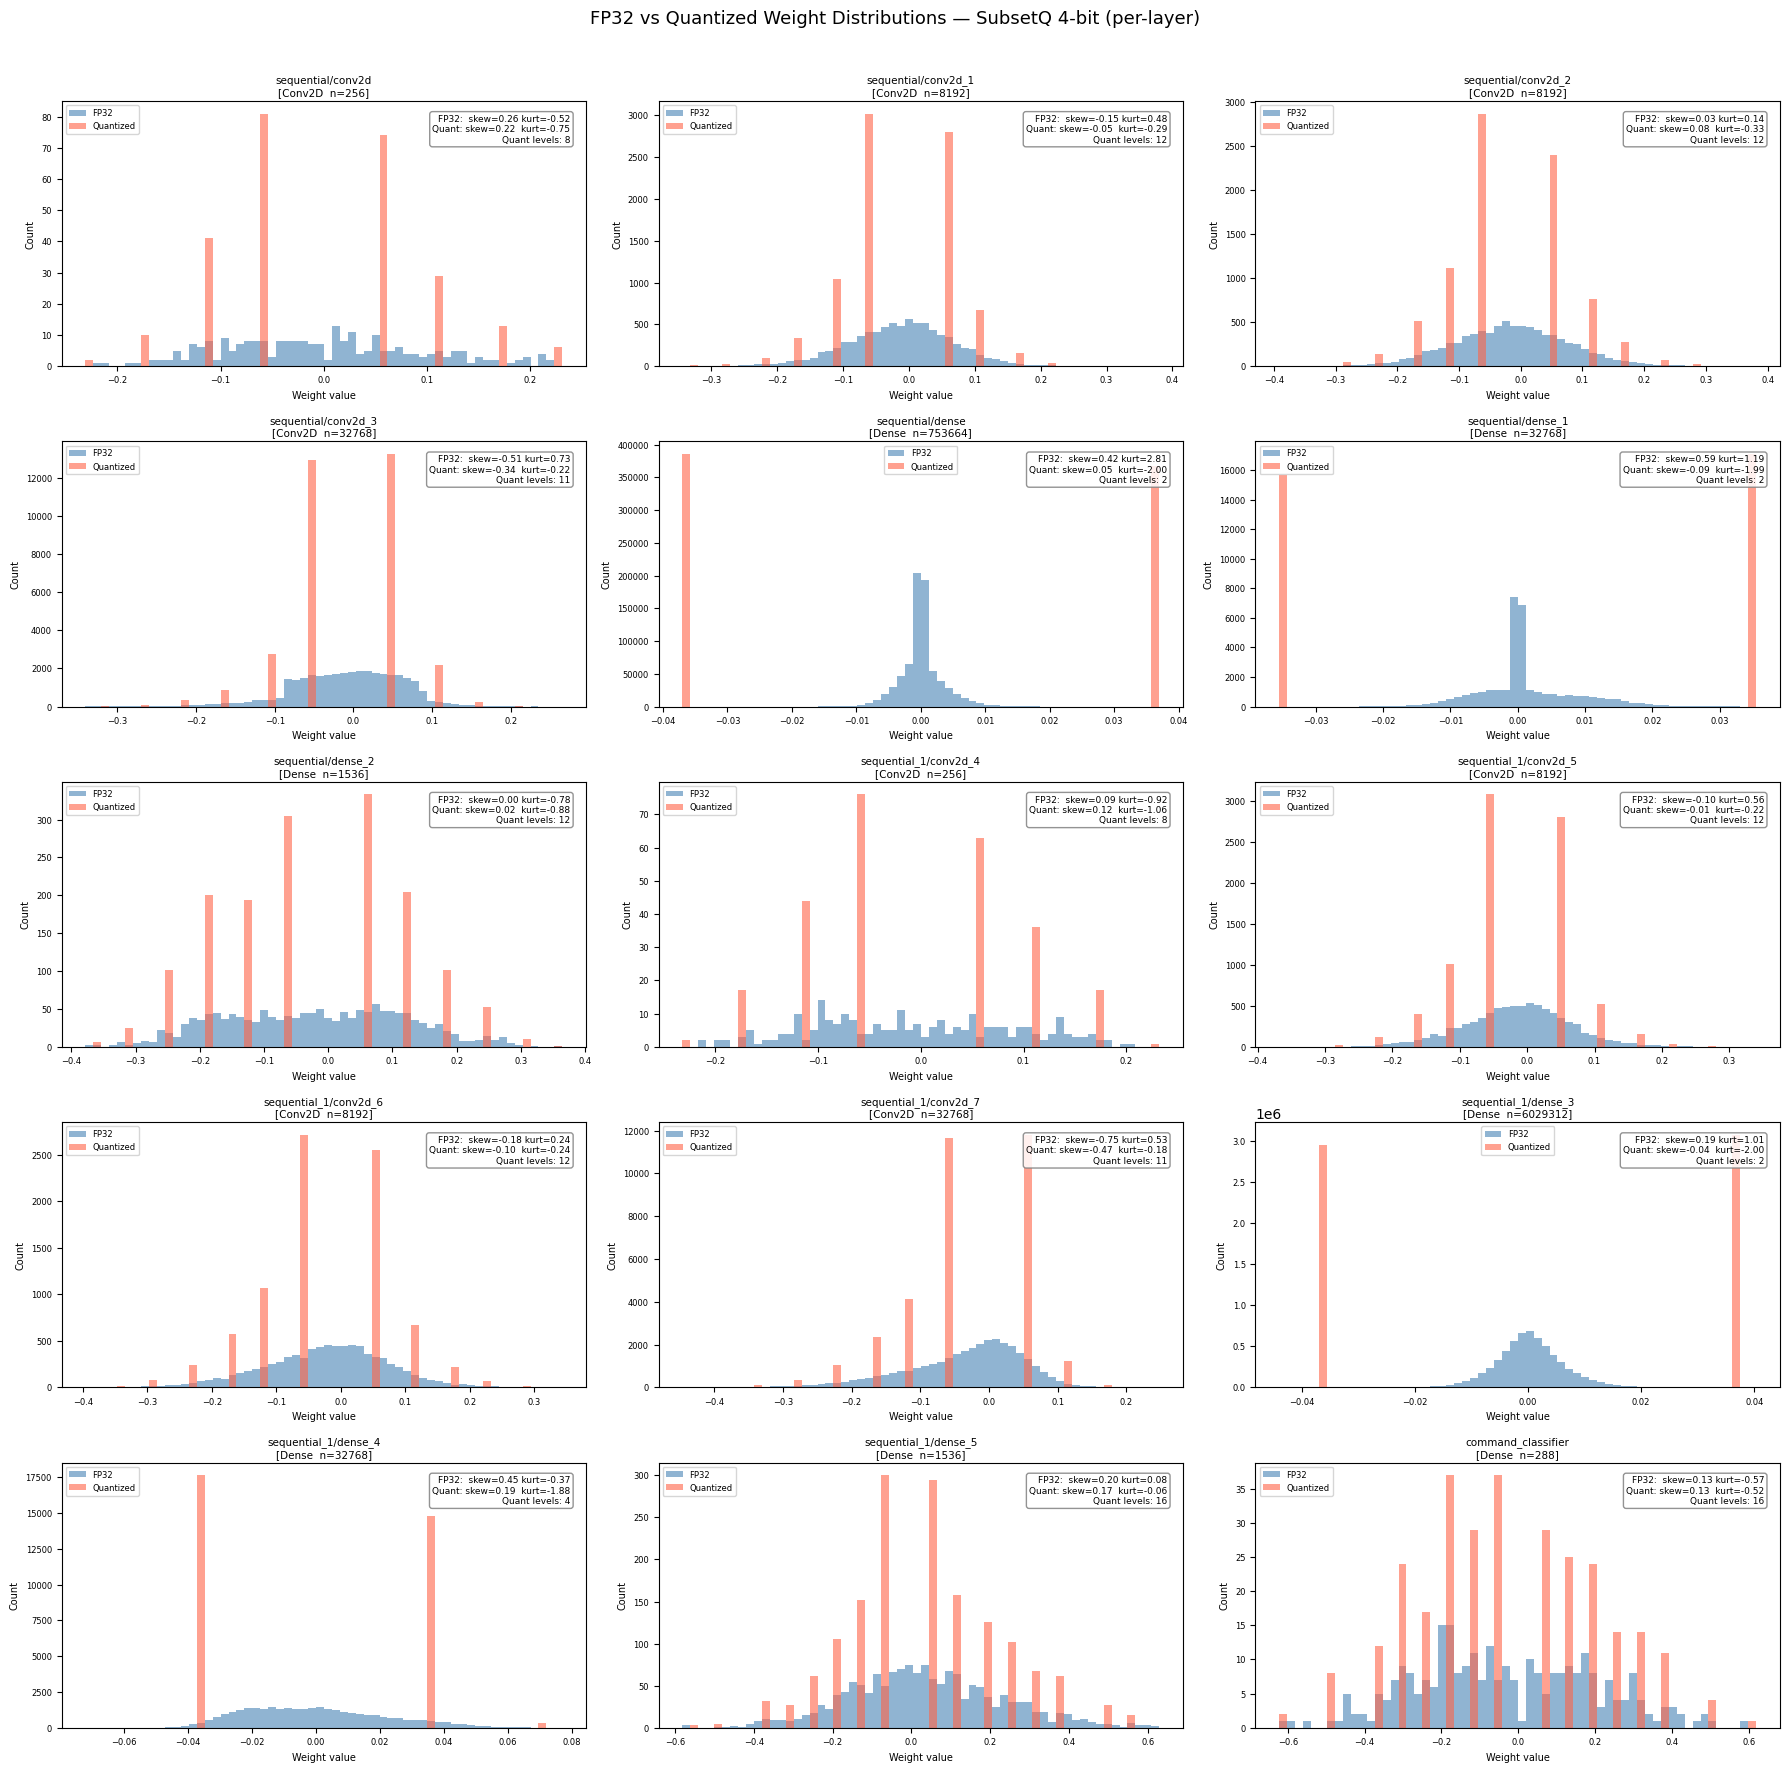


  SubsetQ 3-bit (per-layer)
  conv2d                 Conv2D   shape=(4, 4, 1, 16)
  conv2d_1               Conv2D   shape=(4, 4, 16, 32)
  conv2d_2               Conv2D   shape=(2, 2, 32, 64)
  conv2d_3               Conv2D   shape=(2, 2, 64, 128)
  dense                  Dense    shape=(2944, 256)
  dense_1                Dense    shape=(256, 128)
  dense_2                Dense    shape=(128, 12)
  conv2d_4               Conv2D   shape=(4, 4, 1, 16)
  conv2d_5               Conv2D   shape=(4, 4, 16, 32)
  conv2d_6               Conv2D   shape=(2, 2, 32, 64)
  conv2d_7               Conv2D   shape=(2, 2, 64, 128)
  dense_3                Dense    shape=(23552, 256)
  dense_4                Dense    shape=(256, 128)
  dense_5                Dense    shape=(128, 12)
  command_classifier     Dense    shape=(24, 12)

Quantization complete.

SubsetQ 3-bit (per-layer)
loss                : 14.0069
accuracy            : 0.8206
balanced_accuracy   : 0.7145
precision_macro     : 0.7582
recall_

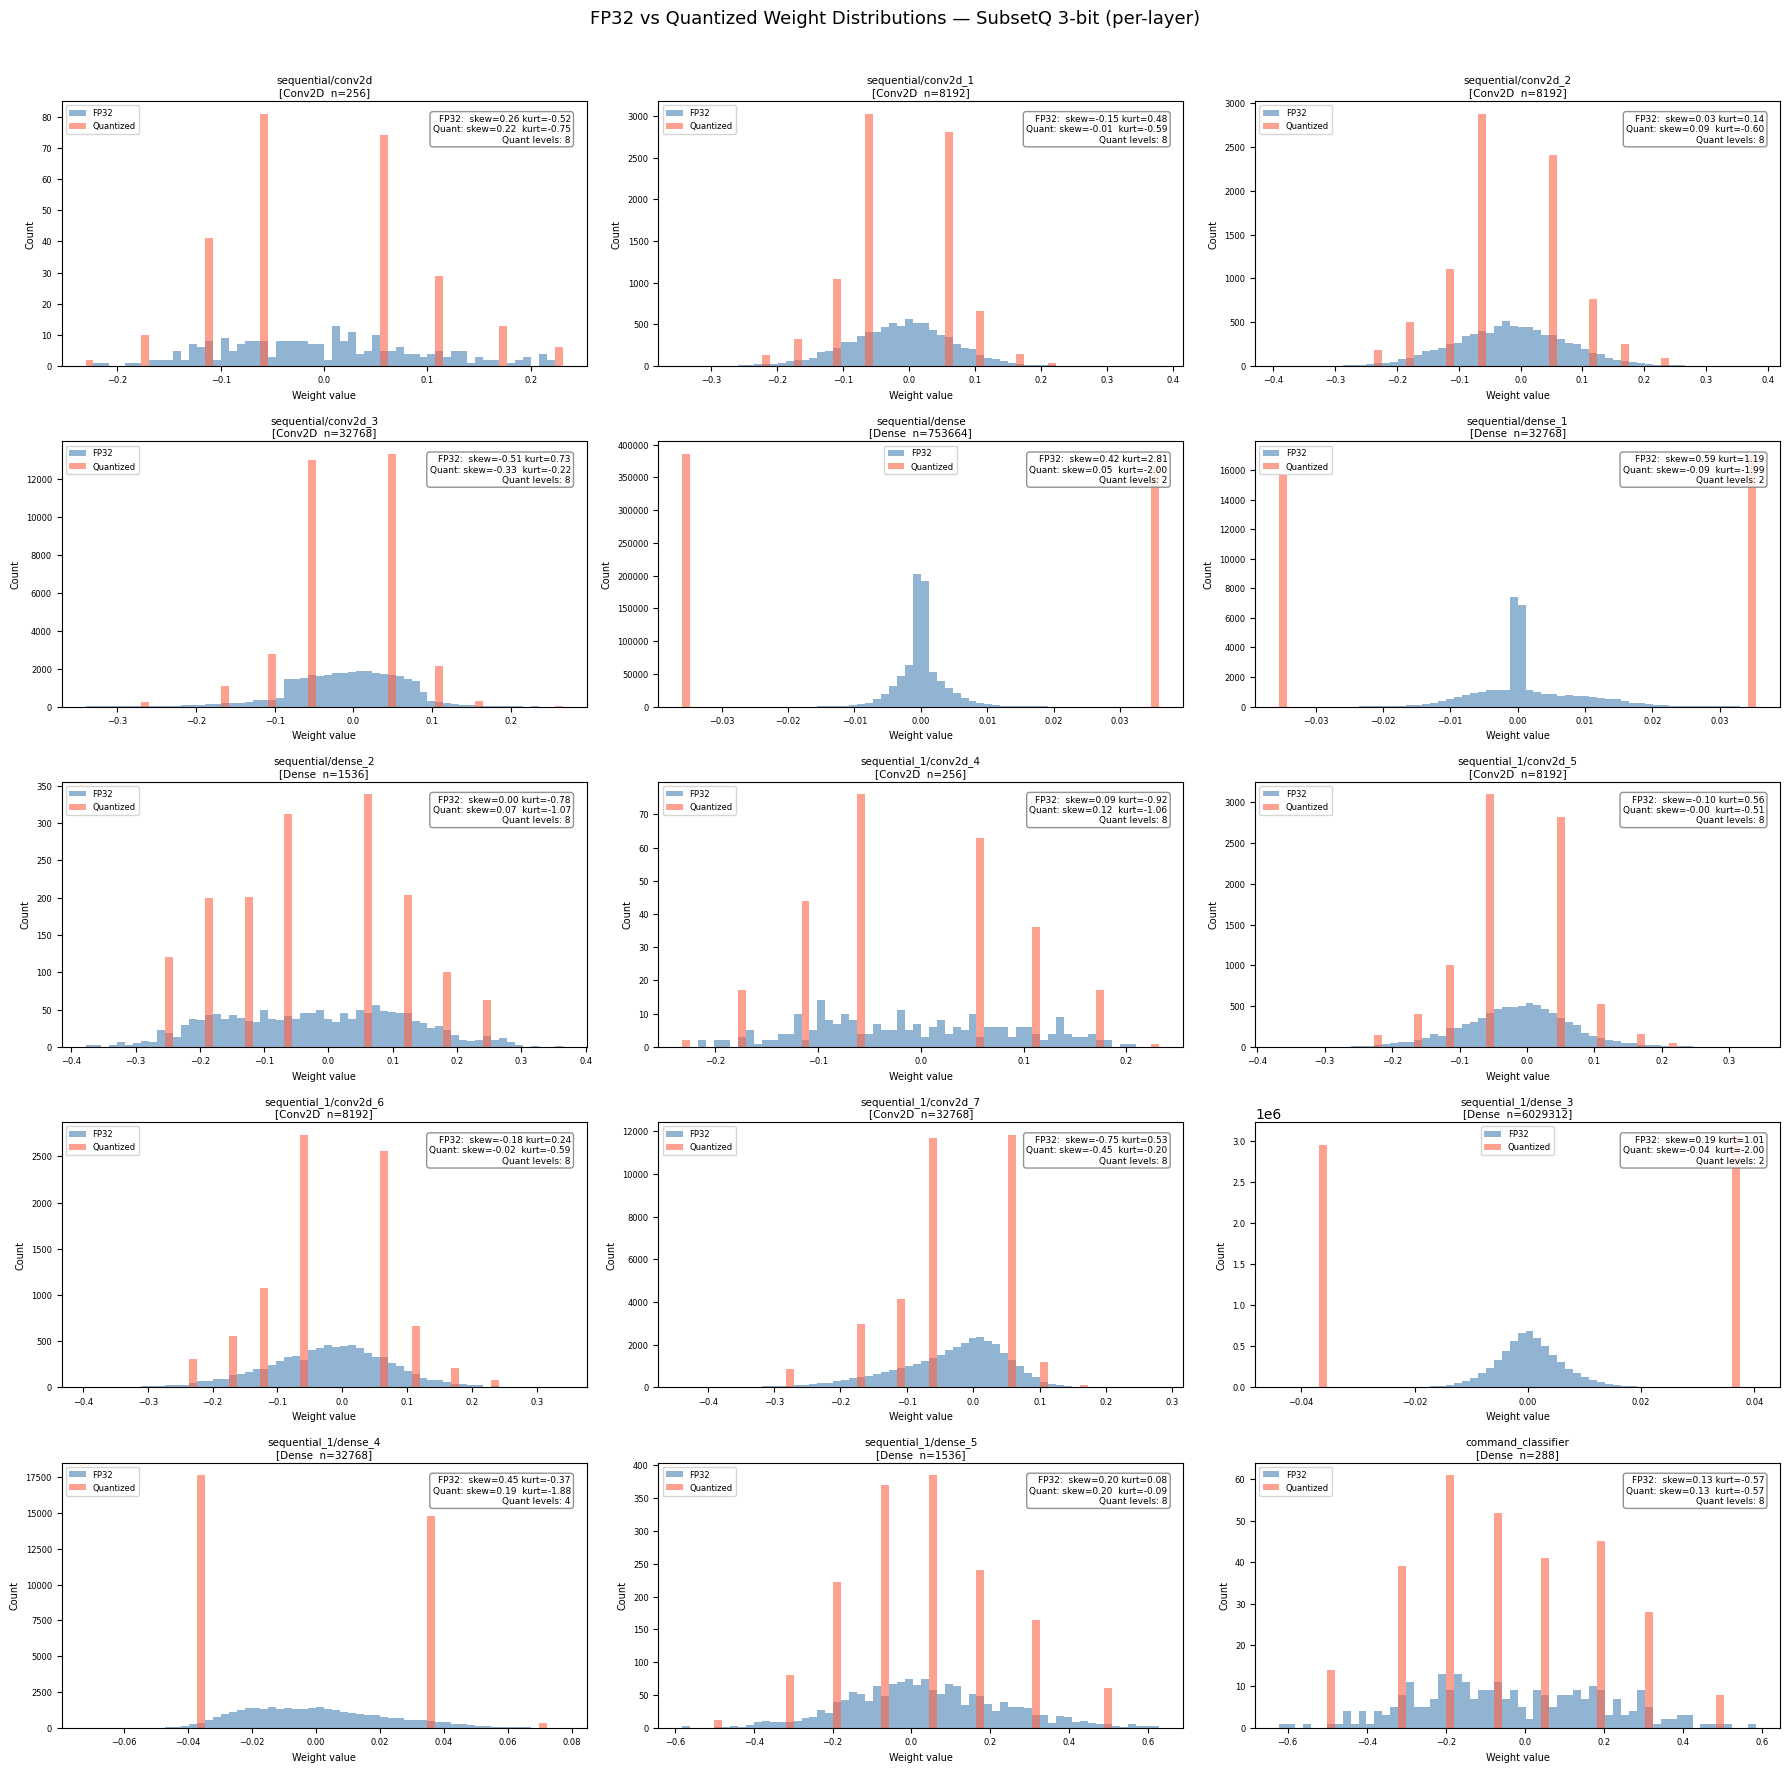


  SubsetQ 2-bit (per-layer)
  conv2d                 Conv2D   shape=(4, 4, 1, 16)
  conv2d_1               Conv2D   shape=(4, 4, 16, 32)
  conv2d_2               Conv2D   shape=(2, 2, 32, 64)
  conv2d_3               Conv2D   shape=(2, 2, 64, 128)
  dense                  Dense    shape=(2944, 256)
  dense_1                Dense    shape=(256, 128)
  dense_2                Dense    shape=(128, 12)
  conv2d_4               Conv2D   shape=(4, 4, 1, 16)
  conv2d_5               Conv2D   shape=(4, 4, 16, 32)
  conv2d_6               Conv2D   shape=(2, 2, 32, 64)
  conv2d_7               Conv2D   shape=(2, 2, 64, 128)
  dense_3                Dense    shape=(23552, 256)
  dense_4                Dense    shape=(256, 128)
  dense_5                Dense    shape=(128, 12)
  command_classifier     Dense    shape=(24, 12)

Quantization complete.

SubsetQ 2-bit (per-layer)
loss                : 14.8837
accuracy            : 0.7302
balanced_accuracy   : 0.6808
precision_macro     : 0.6781
recall_

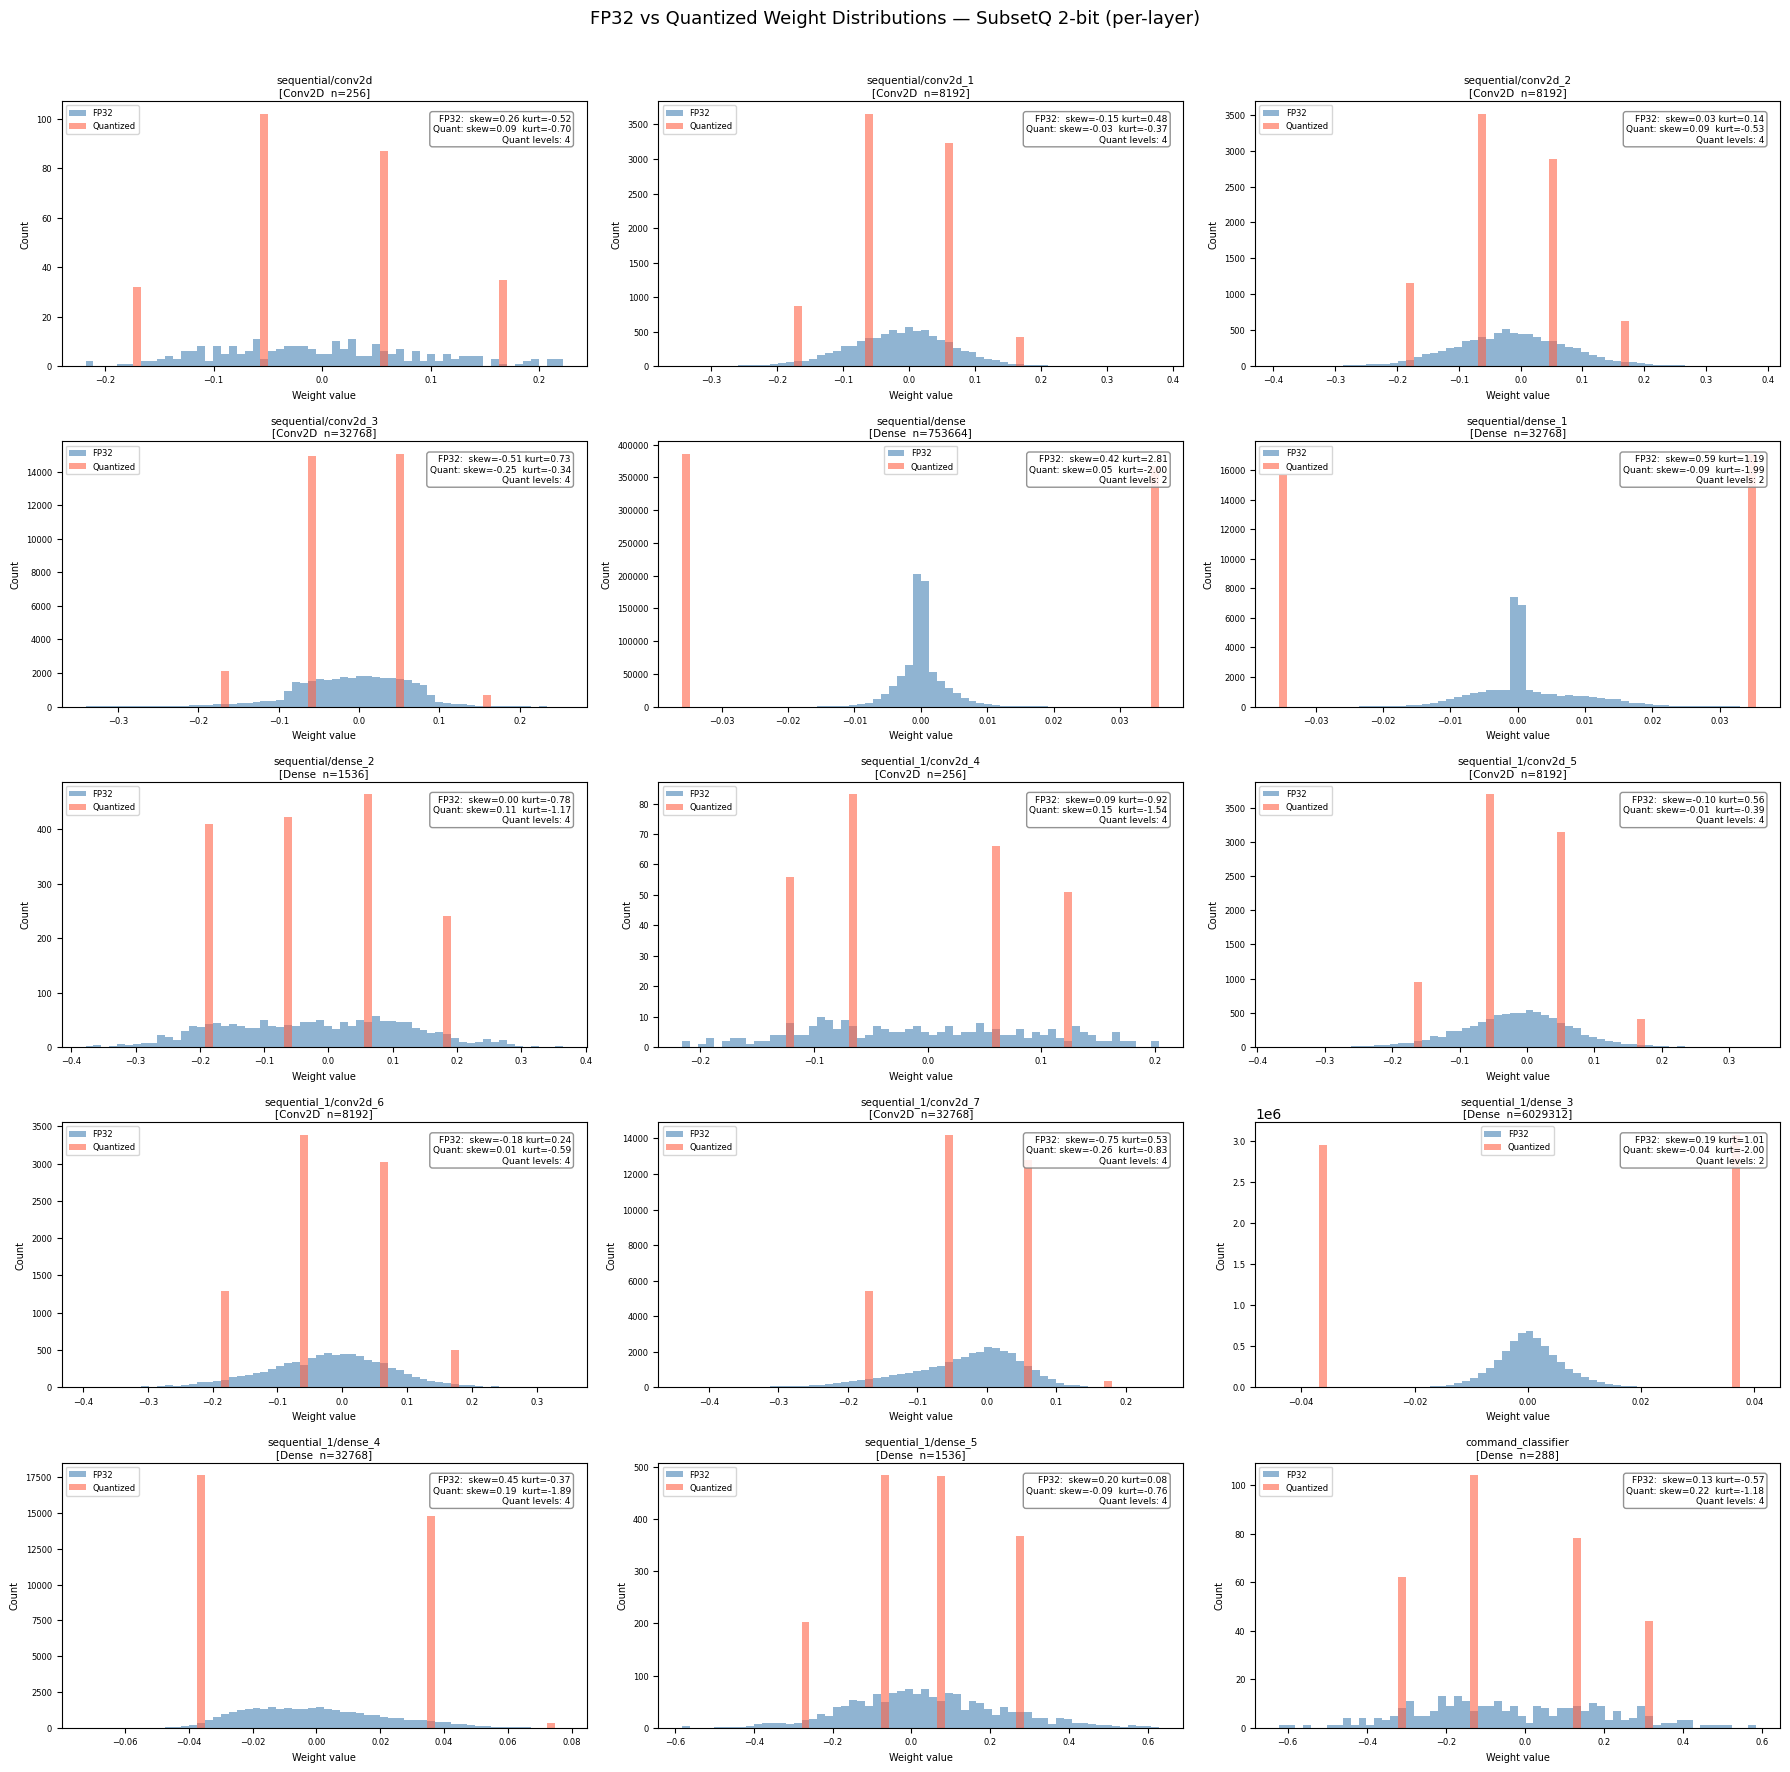

In [ ]:
# ---------------------------------------------------------
# SUBSETQ — LOAD FRESH MODEL, QUANTIZE, EVALUATE
# ---------------------------------------------------------

# Clean FP32 reference model — never modified
revision_model = load_fresh_model()

for mode in ["layer"]:
    for bits in [4, 3, 2]:

        # Fresh revision model for every configuration
        quantized_model = load_fresh_model()

        label = f"SubsetQ {bits}-bit (per-{mode})"

        # Apply SubsetQ
        apply_subsetq_keras(
            quantized_model,
            bits=bits,
            mode=mode,
        )

        # Validation set for comparing configurations
        compile_and_evaluate(
            quantized_model,
            val_ds,
            label=label,
        )

        # Compare against untouched FP32 revision model
        plot_weight_distribution_comparison(revision_model,quantized_model,label=label)

In [ ]:
# =========================================================
# SUBSETQ — VALIDATION SWEEP
# =========================================================

for mode in ["channel"]:

    for bits in [4, 3, 2]:

        # Always start from canonical FP32 checkpoint
        model = load_fresh_model()

        lbl = f"SubsetQ {bits}-bit (per-{mode})"

        # Apply SubsetQ
        apply_subsetq_keras(
            model,
            bits=bits,
            mode=mode
        )

        # Evaluate on VALIDATION
        compile_and_evaluate(
            model,
            val_ds,
            label=lbl
        )

        # Optional
        # plot_weight_distribution_comparison(
        #     fp32_model,
        #     model,
        #     label=lbl
        # )


print("\nSubsetQ validation sweep complete.")
print("TEST SET remains locked / not evaluated.")


  SubsetQ 4-bit (per-channel)
  conv2d                 Conv2D   shape=(4, 4, 1, 16)
  conv2d_1               Conv2D   shape=(4, 4, 16, 32)
  conv2d_2               Conv2D   shape=(2, 2, 32, 64)
  conv2d_3               Conv2D   shape=(2, 2, 64, 128)
  dense                  Dense    shape=(2944, 256)
  dense_1                Dense    shape=(256, 128)
  dense_2                Dense    shape=(128, 12)
  conv2d_4               Conv2D   shape=(4, 4, 1, 16)
  conv2d_5               Conv2D   shape=(4, 4, 16, 32)
  conv2d_6               Conv2D   shape=(2, 2, 32, 64)
  conv2d_7               Conv2D   shape=(2, 2, 64, 128)
  dense_3                Dense    shape=(23552, 256)
  dense_4                Dense    shape=(256, 128)
  dense_5                Dense    shape=(128, 12)
  command_classifier     Dense    shape=(24, 12)

Quantization complete.

SubsetQ 4-bit (per-channel)
loss                : 13.9566
accuracy            : 0.7943
balanced_accuracy   : 0.7902
precision_macro     : 0.6943
rec

## ─────────────────────────────────────────────────────
## 🔬 10.5 BRECQ
## ─────────────────────────────────────────────────────

### ─────────────────────────────────────────────────────
### 🔬 10.5.1 BRECQ SETUP
### ─────────────────────────────────────────────────────

In [ ]:
import os
import tensorflow as tf
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"


# ==========================================================
# PADDING HELPER
# ==========================================================
def tf_same_pad(x, kernel_size=2):
    h, w       = x.shape[2], x.shape[3]
    pad_h      = (kernel_size - 1) if h % 1 == 0 else 0
    pad_w      = (kernel_size - 1) if w % 1 == 0 else 0
    pad_top    = pad_h // 2;  pad_bottom = pad_h - pad_top
    pad_left   = pad_w // 2;  pad_right  = pad_w - pad_left
    return F.pad(x, (pad_left, pad_right, pad_top, pad_bottom))


# ==========================================================
# MODEL — WITH BN (no folding)
# ==========================================================
class SubModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,   16, 4, padding=0, bias=True)
        self.bn1   = nn.BatchNorm2d(16,  eps=0.001)
        self.drop1 = nn.Dropout(0.45)
        self.conv2 = nn.Conv2d(16,  32, 4, padding=0, bias=True)
        self.bn2   = nn.BatchNorm2d(32,  eps=0.001)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.drop2 = nn.Dropout(0.45)
        self.conv3 = nn.Conv2d(32,  64, 2, padding=0, bias=True)
        self.bn3   = nn.BatchNorm2d(64,  eps=0.001)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.drop3 = nn.Dropout(0.45)
        self.conv4 = nn.Conv2d(64, 128, 2, padding=0, bias=True)
        self.bn4   = nn.BatchNorm2d(128, eps=0.001)
        self.drop4 = nn.Dropout(0.45)
        self.fc1   = None
        self.drop5 = nn.Dropout(0.45)
        self.fc2   = None
        self.drop6 = nn.Dropout(0.45)
        self.fc3   = None

    def _build_fcs(self, flat_size):
        self.fc1 = nn.Linear(flat_size, 256).to(device)
        self.fc2 = nn.Linear(256, 128).to(device)
        self.fc3 = nn.Linear(128, 12).to(device)

    def forward(self, x):
        x = x.permute(0, 3, 1, 2)
        x = self.bn1(F.relu(self.conv1(x)));  x = self.drop1(x)
        x = self.bn2(F.relu(self.conv2(x)));  x = self.pool1(x);  x = self.drop2(x)
        x = tf_same_pad(x)
        x = self.bn3(F.relu(self.conv3(x)));  x = self.pool2(x);  x = self.drop3(x)
        x = tf_same_pad(x)
        x = self.bn4(F.relu(self.conv4(x)));  x = self.drop4(x)
        x = x.permute(0, 2, 3, 1)
        x = torch.flatten(x, 1)
        if self.fc1 is None:
            self._build_fcs(x.shape[1])
        x = F.relu(self.fc1(x));  x = self.drop5(x)
        x = F.relu(self.fc2(x));  x = self.drop6(x)
        x = F.relu(self.fc3(x))
        return x


class DualBranchEnsemble(nn.Module):
    def __init__(self):
        super().__init__()
        self.branch_mfcc  = SubModel()
        self.branch_mslfb = SubModel()
        self.classifier   = nn.Linear(24, 12)

    def forward(self, x1, x2):
        o1 = self.branch_mfcc(x1)
        o2 = self.branch_mslfb(x2)
        x  = torch.cat([o1, o2], dim=1)
        return F.softmax(self.classifier(x), dim=1)


# ==========================================================
# WRAPPER
# ==========================================================
class TupleInputModel(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.branch_mfcc  = model.branch_mfcc
        self.branch_mslfb = model.branch_mslfb
        self.classifier   = model.classifier

    def forward(self, x):
        x1, x2 = x
        o1  = self.branch_mfcc(x1)
        o2  = self.branch_mslfb(x2)
        out = torch.cat([o1, o2], dim=1)
        return torch.nn.functional.softmax(self.classifier(out), dim=1)


# ==========================================================
# WEIGHT TRANSFER HELPERS
# ==========================================================
def load_conv(tf_layer, torch_layer):
    weights = tf_layer.get_weights()
    w = np.transpose(weights[0], (3, 2, 0, 1))
    torch_layer.weight.data.copy_(torch.tensor(w).float().to(device))
    if len(weights) > 1:
        torch_layer.bias.data.copy_(torch.tensor(weights[1]).float().to(device))

def load_batchnorm(tf_layer, torch_layer):
    gamma, beta, moving_mean, moving_var = tf_layer.get_weights()
    torch_layer.weight.data.copy_(      torch.tensor(gamma).float().to(device))
    torch_layer.bias.data.copy_(        torch.tensor(beta).float().to(device))
    torch_layer.running_mean.data.copy_(torch.tensor(moving_mean).float().to(device))
    torch_layer.running_var.data.copy_( torch.tensor(moving_var).float().to(device))

def load_dense(tf_layer, torch_layer):
    w, b = tf_layer.get_weights()
    torch_layer.weight.data.copy_(torch.tensor(w.T).float().to(device))
    torch_layer.bias.data.copy_(  torch.tensor(b).float().to(device))

def transfer_branch(tf_seq, pt_branch):
    load_conv(     tf_seq.layers[0],  pt_branch.conv1)
    load_batchnorm(tf_seq.layers[1],  pt_branch.bn1)
    load_conv(     tf_seq.layers[3],  pt_branch.conv2)
    load_batchnorm(tf_seq.layers[4],  pt_branch.bn2)
    load_conv(     tf_seq.layers[7],  pt_branch.conv3)
    load_batchnorm(tf_seq.layers[8],  pt_branch.bn3)
    load_conv(     tf_seq.layers[11], pt_branch.conv4)
    load_batchnorm(tf_seq.layers[12], pt_branch.bn4)
    load_dense(    tf_seq.layers[15], pt_branch.fc1)
    load_dense(    tf_seq.layers[17], pt_branch.fc2)
    load_dense(    tf_seq.layers[19], pt_branch.fc3)

In [ ]:
# ==========================================================
# COMPARE OUTPUTS
# ==========================================================
def compare_outputs(tf_model, pt_model, mfcc_h, mfcc_w, mslfb_h, mslfb_w, device):
    x1 = np.random.randn(1, mfcc_h,  mfcc_w,  1).astype(np.float32)
    x2 = np.random.randn(1, mslfb_h, mslfb_w, 1).astype(np.float32)

    tf_out = tf_model([x1, x2], training=False).numpy()

    pt_model.eval()
    with torch.no_grad():
        pt_out = pt_model(
            torch.tensor(x1).to(device),
            torch.tensor(x2).to(device)
        ).cpu().numpy()

    print("Max absolute difference:", np.max(np.abs(tf_out - pt_out)))
    print("TF  output:", tf_out)
    print("PT  output:", pt_out)


# ==========================================================
# DEBUG LAYER BY LAYER — fixed for Conv(relu) → BN → Dropout
# ==========================================================
def debug_layer_by_layer_fixed(pt_model, seq2, mfcc_h, mfcc_w, device):
    x1 = np.random.randn(1, mfcc_h, mfcc_w, 1).astype(np.float32)

    # TF step by step
    t_tf = tf.constant(x1)
    tf_intermediates = {}
    for i, layer in enumerate(seq2.layers):
        t_tf = layer(t_tf, training=False)
        tf_intermediates[i] = t_tf.numpy()
        print(f"TF layer [{i}] {layer.name}: {t_tf.shape}")
    print()

    pt_model.eval()
    with torch.no_grad():
        t = torch.tensor(x1).to(device).permute(0, 3, 1, 2)

        # Conv+ReLU → TF[0]
        t = F.relu(pt_model.branch_mfcc.conv1(t))
        diff = np.max(np.abs(tf_intermediates[0].transpose(0,3,1,2) - t.cpu().numpy()))
        print(f"After conv1+relu  max diff: {diff:.6f}  PT: {tuple(t.shape)}")

        # BN → TF[1]
        t = pt_model.branch_mfcc.bn1(t)
        diff = np.max(np.abs(tf_intermediates[1].transpose(0,3,1,2) - t.cpu().numpy()))
        print(f"After bn1         max diff: {diff:.6f}  PT: {tuple(t.shape)}")
        # TF[2] = Dropout (no-op) — skip

        # Conv+ReLU → TF[3]
        t = F.relu(pt_model.branch_mfcc.conv2(t))
        diff = np.max(np.abs(tf_intermediates[3].transpose(0,3,1,2) - t.cpu().numpy()))
        print(f"After conv2+relu  max diff: {diff:.6f}  PT: {tuple(t.shape)}")

        # BN → TF[4]
        t = pt_model.branch_mfcc.bn2(t)
        diff = np.max(np.abs(tf_intermediates[4].transpose(0,3,1,2) - t.cpu().numpy()))
        print(f"After bn2         max diff: {diff:.6f}  PT: {tuple(t.shape)}")

        # MaxPool → TF[5]
        t = F.max_pool2d(t, 2, 2)
        diff = np.max(np.abs(tf_intermediates[5].transpose(0,3,1,2) - t.cpu().numpy()))
        print(f"After pool1       max diff: {diff:.6f}  PT: {tuple(t.shape)}")
        # TF[6] = Dropout (no-op) — skip

        # Conv+ReLU → TF[7]
        t = tf_same_pad(t)
        t = F.relu(pt_model.branch_mfcc.conv3(t))
        diff = np.max(np.abs(tf_intermediates[7].transpose(0,3,1,2) - t.cpu().numpy()))
        print(f"After conv3+relu  max diff: {diff:.6f}  PT: {tuple(t.shape)}")

        # BN → TF[8]
        t = pt_model.branch_mfcc.bn3(t)
        diff = np.max(np.abs(tf_intermediates[8].transpose(0,3,1,2) - t.cpu().numpy()))
        print(f"After bn3         max diff: {diff:.6f}  PT: {tuple(t.shape)}")

        # MaxPool → TF[9]
        t = F.max_pool2d(t, 2, 2)
        diff = np.max(np.abs(tf_intermediates[9].transpose(0,3,1,2) - t.cpu().numpy()))
        print(f"After pool2       max diff: {diff:.6f}  PT: {tuple(t.shape)}")
        # TF[10] = Dropout (no-op) — skip

        # Conv+ReLU → TF[11]
        t = tf_same_pad(t)
        t = F.relu(pt_model.branch_mfcc.conv4(t))
        diff = np.max(np.abs(tf_intermediates[11].transpose(0,3,1,2) - t.cpu().numpy()))
        print(f"After conv4+relu  max diff: {diff:.6f}  PT: {tuple(t.shape)}")

        # BN → TF[12]
        t = pt_model.branch_mfcc.bn4(t)
        diff = np.max(np.abs(tf_intermediates[12].transpose(0,3,1,2) - t.cpu().numpy()))
        print(f"After bn4         max diff: {diff:.6f}  PT: {tuple(t.shape)}")
        # TF[13] = Dropout (no-op) — skip

        # Flatten → TF[14]
        t = t.permute(0, 2, 3, 1)
        t = torch.flatten(t, 1)
        diff = np.max(np.abs(tf_intermediates[14] - t.cpu().numpy()))
        print(f"After flatten     max diff: {diff:.6f}  PT: {tuple(t.shape)}")

        # Dense+ReLU → TF[15]
        t = F.relu(pt_model.branch_mfcc.fc1(t))
        diff = np.max(np.abs(tf_intermediates[15] - t.cpu().numpy()))
        print(f"After fc1+relu    max diff: {diff:.6f}  PT: {tuple(t.shape)}")
        # TF[16] = Dropout (no-op) — skip

        # Dense+ReLU → TF[17]
        t = F.relu(pt_model.branch_mfcc.fc2(t))
        diff = np.max(np.abs(tf_intermediates[17] - t.cpu().numpy()))
        print(f"After fc2+relu    max diff: {diff:.6f}  PT: {tuple(t.shape)}")
        # TF[18] = Dropout (no-op) — skip

        # Dense+ReLU → TF[19]
        t = F.relu(pt_model.branch_mfcc.fc3(t))
        diff = np.max(np.abs(tf_intermediates[19] - t.cpu().numpy()))
        print(f"After fc3+relu    max diff: {diff:.6f}  PT: {tuple(t.shape)}")

In [ ]:
# ==========================================================
# LOAD TF MODEL + TRANSFER + CALL BOTH FUNCTIONS
# ==========================================================
file_date  = "20260320_064356"
model_path = os.path.join(main_directory, f"results/ensemble_mfcc_mslfb_resumed_{file_date}.keras")
tf_model   = tf.keras.models.load_model(model_path)

mfcc_h,  mfcc_w  = tf_model.input[0].shape[1], tf_model.input[0].shape[2]
mslfb_h, mslfb_w = tf_model.input[1].shape[1], tf_model.input[1].shape[2]
print(f"TF model loaded ✓  MFCC: ({mfcc_h},{mfcc_w})  MSLFB: ({mslfb_h},{mslfb_w})")

seq2 = tf_model.get_layer("sequential")
seq3 = tf_model.get_layer("sequential_1")

fresh_pt = DualBranchEnsemble().to(device)
fresh_pt.eval()
with torch.no_grad():
    _ = fresh_pt.branch_mfcc( torch.randn(1, mfcc_h,  mfcc_w,  1).to(device))
    _ = fresh_pt.branch_mslfb(torch.randn(1, mslfb_h, mslfb_w, 1).to(device))

transfer_branch(seq2, fresh_pt.branch_mfcc)
transfer_branch(seq3, fresh_pt.branch_mslfb)
load_dense(tf_model.get_layer("dense_6"), fresh_pt.classifier)
print("Weights transferred ✓")

compare_outputs(tf_model, fresh_pt, mfcc_h, mfcc_w, mslfb_h, mslfb_w, device)
debug_layer_by_layer_fixed(fresh_pt, seq2, mfcc_h, mfcc_w, device)

TF model loaded ✓  MFCC: (98,12)  MSLFB: (98,40)
Weights transferred ✓
Max absolute difference: 2.910383e-10
TF  output: [[2.3397774e-06 5.7188286e-06 7.6110103e-07 4.6295369e-07 3.2231058e-06
  2.8777010e-06 3.4263678e-06 9.9938726e-01 1.0143466e-05 5.5525324e-04
  2.2407123e-07 2.8289569e-05]]
PT  output: [[2.3397820e-06 5.7188454e-06 7.6110319e-07 4.6295551e-07 3.2231087e-06
  2.8777065e-06 3.4263808e-06 9.9938726e-01 1.0143486e-05 5.5525353e-04
  2.2407187e-07 2.8289569e-05]]
TF layer [0] conv2d: (1, 95, 9, 16)
TF layer [1] batch_normalization: (1, 95, 9, 16)
TF layer [2] dropout: (1, 95, 9, 16)
TF layer [3] conv2d_1: (1, 92, 6, 32)
TF layer [4] batch_normalization_1: (1, 92, 6, 32)
TF layer [5] max_pooling2d: (1, 46, 3, 32)
TF layer [6] dropout_1: (1, 46, 3, 32)
TF layer [7] conv2d_2: (1, 46, 3, 64)
TF layer [8] batch_normalization_2: (1, 46, 3, 64)
TF layer [9] max_pooling2d_1: (1, 23, 1, 64)
TF layer [10] dropout_2: (1, 23, 1, 64)
TF layer [11] conv2d_3: (1, 23, 1, 128)
TF layer

### ─────────────────────────────────────────────────────
### 🔬 10.5.2 BRECQ METHODOLOGY
### ─────────────────────────────────────────────────────

In [ ]:
from sklearn.metrics import precision_score, recall_score

# ==========================================================
# EVALUATE FUNCTION
# ==========================================================
def evaluate_quant_model(model, dataset):
    model.eval()
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for (inputs, labels) in dataset:
            x1 = torch.from_numpy(inputs[0].numpy()).float().to(device)
            x2 = torch.from_numpy(inputs[1].numpy()).float().to(device)

            outputs = model((x1, x2))
            preds   = torch.argmax(outputs, dim=1).cpu().numpy()
            targets = torch.argmax(
                torch.from_numpy(labels.numpy()), dim=1
            ).numpy()

            all_preds.append(preds)
            all_labels.append(targets)

    all_preds  = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    accuracy  = (all_preds == all_labels).mean()
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall    = recall_score(   all_labels, all_preds, average='macro', zero_division=0)

    classes = np.unique(all_labels)

    # Balanced accuracy = mean per-class recall
    per_class_recall = [
        np.mean(all_preds[all_labels == c] == c)
        for c in classes
    ]
    balanced_acc = float(np.mean(per_class_recall))

    # Macro F1 = unweighted mean of per-class F1 scores
    per_class_f1 = []
    for c in classes:
        tp = np.sum((all_preds == c) & (all_labels == c))
        fp = np.sum((all_preds == c) & (all_labels != c))
        fn = np.sum((all_preds != c) & (all_labels == c))
        precision_c = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall_c    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1_c        = (2 * precision_c * recall_c / (precision_c + recall_c)
                       if (precision_c + recall_c) > 0 else 0.0)
        per_class_f1.append(f1_c)

    macro_f1 = float(np.mean(per_class_f1))

    return accuracy, precision, recall, balanced_acc, macro_f1


# ==========================================================
# BRECQ — FIXED CALIBRATION DATA
# ==========================================================
#
# Uses the SAME frozen 1024-sample calibration subset
# as the other PTQ experiments.
# ==========================================================

cali_x1_list = []
cali_x2_list = []

for (x1_batch, x2_batch), _ in calib_ds:

    cali_x1_list.append(
        torch.from_numpy(
            x1_batch.numpy()
        ).float()
    )

    cali_x2_list.append(
        torch.from_numpy(
            x2_batch.numpy()
        ).float()
    )


cali_x1 = torch.cat(
    cali_x1_list,
    dim=0
).cpu()

cali_x2 = torch.cat(
    cali_x2_list,
    dim=0
).cpu()


assert cali_x1.shape[0] == 1024
assert cali_x2.shape[0] == 1024


print(
    f"BRECQ calibration data cached: "
    f"{cali_x1.shape[0]} samples ✓"
)


# ==========================================================
# BRECQ HELPERS
# ==========================================================
def brecq_build_and_transfer(tf_model, device):
    """Build a fresh PyTorch model and transfer weights from Keras."""
    mfcc_h,  mfcc_w  = tf_model.input[0].shape[1], tf_model.input[0].shape[2]
    mslfb_h, mslfb_w = tf_model.input[1].shape[1], tf_model.input[1].shape[2]

    fresh_pt = DualBranchEnsemble().to(device)
    fresh_pt.eval()
    with torch.no_grad():
        _ = fresh_pt.branch_mfcc( torch.randn(1, mfcc_h,  mfcc_w,  1).to(device))
        _ = fresh_pt.branch_mslfb(torch.randn(1, mslfb_h, mslfb_w, 1).to(device))

    seq2 = tf_model.get_layer("sequential")
    seq3 = tf_model.get_layer("sequential_1")
    transfer_branch(seq2, fresh_pt.branch_mfcc)
    transfer_branch(seq3, fresh_pt.branch_mslfb)
    load_dense(tf_model.get_layer("command_classifier"), fresh_pt.classifier)
    fresh_pt.eval()
    return fresh_pt


def brecq_build_quant_model(wrapped, n_bits, device):
    """Wrap model in QuantModel and fix activation quantizers."""
    weight_quant_params = dict(n_bits=n_bits, symmetric=False, channel_wise=True,  scale_method='max')
    act_quant_params    = dict(n_bits=n_bits, symmetric=False, channel_wise=False, scale_method='max')

    quant_model = QuantModel(wrapped, weight_quant_params, act_quant_params).to(device)
    quant_model.eval()

    for name, module in quant_model.named_modules():
        if isinstance(module, QuantModule):
            module.act_quantizer.delta      = torch.tensor(1.0).to(device)
            module.act_quantizer.zero_point = torch.tensor(0.0).to(device)
            module.act_quantizer.inited     = True
    print("  Activation quantizers set to identity ✓")
    return quant_model


def brecq_init_weight_scales(quant_model, cali_x1, cali_x2, device):
    """Initialize weight quantization scales via calibration forward pass."""
    print("  Initializing weight quantization scales...")
    with torch.no_grad():
        quant_model.set_quant_state(True, False)
        _ = quant_model((cali_x1.to(device), cali_x2.to(device)))
        quant_model.set_quant_state(False, False)

    print(f"\n  {'Layer':<45} {'delta_mean':>12}  {'zp_mean':>10}")
    print(f"  {'-'*70}")
    for name, module in quant_model.named_modules():
        if isinstance(module, QuantModule):
            delta      = module.weight_quantizer.delta
            zp         = module.weight_quantizer.zero_point
            delta_mean = delta.mean().item() if delta is not None else -1
            zp_mean    = zp.mean().item()    if zp    is not None else -1
            flag = " ← SUSPICIOUS" if delta_mean < 1e-6 or delta_mean > 10 else ""
            print(f"  {name:<45} {delta_mean:>12.8f}  {zp_mean:>10.4f}{flag}")


def brecq_reconstruct_layers(quant_model, cali_x1, cali_x2, device):
    """Layer-by-layer reconstruction using BRECQ."""
    print("  Layer-by-layer reconstruction...")
    for name, module in quant_model.named_modules():
        if isinstance(module, QuantModule) and not module.ignore_reconstruction:
            print(f"    layer: {name}")
            layer_reconstruction(
                quant_model, module,
                (cali_x1.to(device), cali_x2.to(device)),
                batch_size=32, iters=1000, weight=0.001,
                opt_mode='mse', asym=False, include_act_func=True,
                b_range=(20, 2), warmup=0.2, act_quant=False,
                lr=4e-5, p=2.0, multi_gpu=False
            )


def brecq_plot_weight_distributions(quant_model, n_bits):
    records = []
    for name, module in quant_model.named_modules():
        if isinstance(module, QuantModule):
            if not (hasattr(module, 'org_weight') and module.org_weight is not None):
                continue

            fp_w = module.org_weight.detach()

            with torch.no_grad():
                q_w = module.weight_quantizer(fp_w)

            records.append((
                name,
                fp_w.cpu().numpy(),
                q_w.cpu().numpy(),
            ))

    print(f"  Layers found: {len(records)}")
    if len(records) == 0:
        print("  WARNING: no layers found — skipping distribution plot.")
        return

    n_plots   = len(records)
    n_cols    = 3
    n_rows    = math.ceil(n_plots / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
    axes      = axes.flatten()

    for i, (name, fp_w, q_w) in enumerate(records):
        ax      = axes[i]
        fp_flat = fp_w.flatten()
        q_flat  = q_w.flatten()

        w_min     = min(fp_flat.min(), q_flat.min())
        w_max     = max(fp_flat.max(), q_flat.max())
        bin_edges = np.linspace(w_min, w_max, 60)

        ax.hist(fp_flat, bins=bin_edges, color='steelblue', alpha=0.6,
                edgecolor='none', label='FP32')
        ax.hist(q_flat,  bins=bin_edges, color='tomato',    alpha=0.6,
                edgecolor='none', label='Quantized')

        n_levels = len(np.unique(q_flat))
        ax.annotate(
            f"FP32  n={len(fp_flat)}\nQuant levels: {n_levels}",
            xy=(0.97, 0.95), xycoords='axes fraction',
            fontsize=6.5, ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.85)
        )
        ax.set_title(name, fontsize=7.5, pad=4)
        ax.set_xlabel("Weight value", fontsize=7)
        ax.set_ylabel("Count",        fontsize=7)
        ax.tick_params(labelsize=6)
        ax.legend(fontsize=6)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(
        f"FP32 vs BRECQ {n_bits}-bit Weight Distributions",
        fontsize=13, y=1.01
    )
    plt.tight_layout()
    plt.show()


# ==========================================================
# BRECQ PIPELINE — REVISED / SELF-CONTAINED
# ==========================================================
#
# Protocol:
#
#   FP32 source:
#       load_fresh_model()
#
#   Calibration:
#       fixed calib_ds (1024 samples)
#
#   Evaluation / comparison:
#       val_ds
#
#   Test:
#       LOCKED / NOT USED
#
# Important:
#   This function does NOT depend on fp32_val_metrics.
#
# ==========================================================

def run_brecq(
    n_bits,
    plot_distributions=False
):

    print(f"\n{'=' * 60}")
    print(
        f"  BRECQ {n_bits}-bit "
        f"(layer-by-layer)"
    )
    print(f"{'=' * 60}")

    # ======================================================
    # 1. LOAD CANONICAL FP32 KERAS MODEL
    # ======================================================

    tf_model = load_fresh_model()

    # ======================================================
    # 2. TRANSFER KERAS -> PYTORCH
    # ======================================================

    fresh_pt = brecq_build_and_transfer(
        tf_model,
        device
    )

    del tf_model

    # ======================================================
    # 3. FP32 TRANSFER SANITY CHECK — VALIDATION
    # ======================================================
    #
    # This serves TWO purposes:
    #
    #   1. Verify that Keras -> PyTorch transfer is correct.
    #   2. Provide the FP32 reference for BRECQ degradation.
    #
    # No external fp32_val_metrics variable is needed.
    #
    # ======================================================

    fp32_pt_model = TupleInputModel(
        fresh_pt
    ).to(device)

    (
        acc_fp32,
        precision_fp32,
        recall_fp32,
        balanced_acc_fp32,
        macro_f1_fp32
    ) = evaluate_quant_model(
        fp32_pt_model,
        val_ds
    )

    print(
        "\n  PyTorch FP32 transfer sanity check"
    )

    print(
        f"  Accuracy:          "
        f"{acc_fp32:.6f}"
    )

    print(
        f"  Balanced Accuracy: "
        f"{balanced_acc_fp32:.6f}"
    )

    print(
        f"  Macro Precision:   "
        f"{precision_fp32:.6f}"
    )

    print(
        f"  Macro Recall:      "
        f"{recall_fp32:.6f}"
    )

    print(
        f"  Macro F1:          "
        f"{macro_f1_fp32:.6f}"
    )

    # ======================================================
    # 4. TRANSFER SANITY CHECK AGAINST KNOWN CANONICAL RESULT
    # ======================================================
    #
    # These are ONLY sanity-check constants from the
    # canonical revised validation evaluation.
    #
    # They are not used for model selection.
    #
    # ======================================================

    EXPECTED_FP32_VAL_ACC = 0.857585
    EXPECTED_FP32_VAL_BA  = 0.864336

    acc_transfer_diff = abs(
        acc_fp32
        - EXPECTED_FP32_VAL_ACC
    )

    ba_transfer_diff = abs(
        balanced_acc_fp32
        - EXPECTED_FP32_VAL_BA
    )

    print(
        f"\n  Keras reference accuracy: "
        f"{EXPECTED_FP32_VAL_ACC:.6f}"
    )

    print(
        f"  Transfer Δaccuracy:       "
        f"{acc_transfer_diff:.8f}"
    )

    print(
        f"  Keras reference BA:       "
        f"{EXPECTED_FP32_VAL_BA:.6f}"
    )

    print(
        f"  Transfer ΔBA:             "
        f"{ba_transfer_diff:.8f}"
    )

    if (
        acc_transfer_diff > 1e-3
        or
        ba_transfer_diff > 1e-3
    ):

        raise RuntimeError(
            "\nKeras -> PyTorch FP32 transfer differs "
            "from the canonical validation result by "
            "more than 0.001.\n"
            "Do not trust BRECQ results until the "
            "transfer is checked."
        )

    print(
        "  Transfer sanity check: PASSED ✓"
    )

    # ======================================================
    # 5. BUILD BRECQ QUANTIZED MODEL
    # ======================================================

    wrapped = TupleInputModel(
        fresh_pt
    ).to(device)

    quant_model = brecq_build_quant_model(
        wrapped,
        n_bits,
        device
    )

    # ======================================================
    # 6. INITIALIZE WEIGHT QUANTIZATION SCALES
    # ======================================================

    brecq_init_weight_scales(
        quant_model,
        cali_x1,
        cali_x2,
        device
    )

    # ======================================================
    # 7. VALIDATION AFTER INITIAL QUANTIZATION
    # ======================================================

    quant_model.set_quant_state(
        True,
        False
    )

    quant_model.eval()

    (
        acc_init,
        precision_init,
        recall_init,
        balanced_acc_init,
        macro_f1_init
    ) = evaluate_quant_model(
        quant_model,
        val_ds
    )

    print(
        "\n  After scale initialization:"
    )

    print(
        f"  Accuracy:          "
        f"{acc_init:.6f}"
    )

    print(
        f"  Balanced Accuracy: "
        f"{balanced_acc_init:.6f}"
    )

    print(
        f"  Macro F1:          "
        f"{macro_f1_init:.6f}"
    )

    # Disable quantization before reconstruction setup.
    quant_model.set_quant_state(
        False,
        False
    )

    # ======================================================
    # 8. BRECQ LAYER-BY-LAYER RECONSTRUCTION
    # ======================================================
    #
    # IMPORTANT:
    # Reconstruction uses ONLY the fixed calibration set.
    #
    # ======================================================

    brecq_reconstruct_layers(
        quant_model,
        cali_x1,
        cali_x2,
        device
    )

    # ======================================================
    # 9. FINAL VALIDATION EVALUATION
    # ======================================================

    quant_model.set_quant_state(
        True,
        False
    )

    quant_model.eval()

    (
        accuracy,
        precision,
        recall,
        balanced_acc,
        macro_f1
    ) = evaluate_quant_model(
        quant_model,
        val_ds
    )

    # ======================================================
    # 10. METRIC CONSISTENCY CHECK
    # ======================================================
    #
    # In this single-label multiclass setting:
    #
    # Balanced Accuracy == Macro Recall
    #
    # ======================================================

    assert np.isclose(
        balanced_acc,
        recall,
        atol=1e-8
    ), (
        "Balanced Accuracy and Macro Recall "
        "should be equal."
    )

    # ======================================================
    # 11. DEGRADATION RELATIVE TO FP32
    # ======================================================

    ba_drop_abs = (
        balanced_acc_fp32
        - balanced_acc
    )

    ba_drop_pct = (
        100.0
        * ba_drop_abs
        / max(
            balanced_acc_fp32,
            1e-10
        )
    )

    acc_drop_abs = (
        acc_fp32
        - accuracy
    )

    acc_drop_pct = (
        100.0
        * acc_drop_abs
        / max(
            acc_fp32,
            1e-10
        )
    )

    # ======================================================
    # 12. REPORT
    # ======================================================

    print(
        f"\n  BRECQ {n_bits}-bit "
        f"VALIDATION RESULTS"
    )

    print(
        f"  {'=' * 58}"
    )

    print(
        f"  {'Metric':<32} "
        f"{'Value':>14}"
    )

    print(
        f"  {'-' * 48}"
    )

    print(
        f"  {'FP32 Accuracy':<32} "
        f"{acc_fp32:>14.6f}"
    )

    print(
        f"  {'FP32 Balanced Accuracy':<32} "
        f"{balanced_acc_fp32:>14.6f}"
    )

    print(
        f"  {'After scale init Accuracy':<32} "
        f"{acc_init:>14.6f}"
    )

    print(
        f"  {'After scale init BA':<32} "
        f"{balanced_acc_init:>14.6f}"
    )

    print(
        f"  {'After reconstruction Accuracy':<32} "
        f"{accuracy:>14.6f}"
    )

    print(
        f"  {'After reconstruction BA':<32} "
        f"{balanced_acc:>14.6f}"
    )

    print(
        f"  {'Macro Precision':<32} "
        f"{precision:>14.6f}"
    )

    print(
        f"  {'Macro Recall':<32} "
        f"{recall:>14.6f}"
    )

    print(
        f"  {'Macro F1':<32} "
        f"{macro_f1:>14.6f}"
    )

    print(
        f"  {'BA drop (absolute)':<32} "
        f"{ba_drop_abs:>14.6f}"
    )

    print(
        f"  {'BA drop (relative %)':<32} "
        f"{ba_drop_pct:>13.3f}%"
    )

    print(
        f"  {'Accuracy drop (relative %)':<32} "
        f"{acc_drop_pct:>13.3f}%"
    )

    print(
        f"  {'=' * 58}"
    )

    # ======================================================
    # 13. OPTIONAL WEIGHT DISTRIBUTION PLOTS
    # ======================================================

    if plot_distributions:

        brecq_plot_weight_distributions(
            quant_model,
            n_bits
        )

    # ======================================================
    # 14. STRUCTURED RESULTS
    # ======================================================

    results = {

        "method":
            "BRECQ",

        "configuration":
            f"W{n_bits}",

        "bits":
            int(
                n_bits
            ),

        # --------------------------------------------------
        # FP32 reference
        # --------------------------------------------------

        "fp32_accuracy":
            float(
                acc_fp32
            ),

        "fp32_balanced_accuracy":
            float(
                balanced_acc_fp32
            ),

        "fp32_macro_precision":
            float(
                precision_fp32
            ),

        "fp32_macro_recall":
            float(
                recall_fp32
            ),

        "fp32_macro_f1":
            float(
                macro_f1_fp32
            ),

        # --------------------------------------------------
        # Initial quantization
        # --------------------------------------------------

        "init_accuracy":
            float(
                acc_init
            ),

        "init_balanced_accuracy":
            float(
                balanced_acc_init
            ),

        "init_macro_f1":
            float(
                macro_f1_init
            ),

        # --------------------------------------------------
        # Final reconstructed BRECQ
        # --------------------------------------------------

        "accuracy":
            float(
                accuracy
            ),

        "balanced_accuracy":
            float(
                balanced_acc
            ),

        "macro_precision":
            float(
                precision
            ),

        "macro_recall":
            float(
                recall
            ),

        "macro_f1":
            float(
                macro_f1
            ),

        # --------------------------------------------------
        # Degradation
        # --------------------------------------------------

        "ba_drop_abs":
            float(
                ba_drop_abs
            ),

        "ba_drop_pct":
            float(
                ba_drop_pct
            ),

        "accuracy_drop_abs":
            float(
                acc_drop_abs
            ),

        "accuracy_drop_pct":
            float(
                acc_drop_pct
            ),
    }

    # ======================================================
    # 15. IMPORTANT
    # ======================================================

    print(
        "\n  Data usage:"
    )

    print(
        "    Calibration -> fixed calib_ds"
    )

    print(
        "    Evaluation  -> val_ds"
    )

    print(
        "    Test        -> NOT USED / LOCKED"
    )

    return results

BRECQ calibration data cached: 1024 samples ✓


In [ ]:
# ==========================================================
# RUN BRECQ W8 / W4 / W2
# ==========================================================

brecq_results = []

for n_bits in [
    8,
    4,
    2
]:

    result = run_brecq(
        n_bits=n_bits,
        plot_distributions=False
    )

    brecq_results.append(
        result
    )


# ==========================================================
# CREATE SUMMARY DATAFRAME
# ==========================================================

brecq_df = pd.DataFrame(
    brecq_results
)


display_columns = [

    "configuration",

    "accuracy",

    "balanced_accuracy",

    "macro_precision",

    "macro_recall",

    "macro_f1",

    "ba_drop_abs",

    "ba_drop_pct",
]


print(
    "\n"
    + "=" * 90
)

print(
    "BRECQ VALIDATION SUMMARY"
)

print(
    "=" * 90
)


display(
    brecq_df[
        display_columns
    ]
)


print(
    "\nTEST SET remains LOCKED / NOT EVALUATED."
)


  BRECQ 8-bit (layer-by-layer)

  PyTorch FP32 transfer sanity check
  Accuracy:          0.857585
  Balanced Accuracy: 0.864336
  Macro Precision:   0.745206
  Macro Recall:      0.864336
  Macro F1:          0.783876

  Keras reference accuracy: 0.857585
  Transfer Δaccuracy:       0.00000050
  Keras reference BA:       0.864336
  Transfer ΔBA:             0.00000010
  Transfer sanity check: PASSED ✓
  Activation quantizers set to identity ✓
  Initializing weight quantization scales...

  Layer                                           delta_mean     zp_mean
  ----------------------------------------------------------------------
  model.branch_mfcc.conv1                         0.00129788    113.4375
  model.branch_mfcc.conv2                         0.00188996    140.8438
  model.branch_mfcc.conv3                         0.00191760    133.7031
  model.branch_mfcc.conv4                         0.00154273    155.7500
  model.branch_mfcc.fc1                           0.31648231     78

/content/brecq/quant/layer_recon.py:161: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  float(total_loss), float(rec_loss), float(round_loss), b, self.count))


Total loss:	0.156 (rec:0.000, round:0.156)	b=13.25	count=500
Total loss:	0.039 (rec:0.000, round:0.039)	b=2.00	count=1000
    layer: model.branch_mfcc.conv2
Init alpha to be FP32
Total loss:	5.384 (rec:0.000, round:5.383)	b=13.25	count=500
Total loss:	1.362 (rec:0.000, round:1.362)	b=2.00	count=1000
    layer: model.branch_mfcc.conv3
Init alpha to be FP32
Total loss:	5.432 (rec:0.000, round:5.432)	b=13.25	count=500
Total loss:	1.496 (rec:0.000, round:1.496)	b=2.00	count=1000
    layer: model.branch_mfcc.conv4
Init alpha to be FP32
Total loss:	21.633 (rec:0.000, round:21.633)	b=13.25	count=500
Total loss:	5.735 (rec:0.001, round:5.734)	b=2.00	count=1000
    layer: model.branch_mfcc.fc1
Init alpha to be FP32
Total loss:	338.947 (rec:0.000, round:338.947)	b=13.25	count=500
Total loss:	84.504 (rec:0.000, round:84.504)	b=2.00	count=1000
    layer: model.branch_mfcc.fc2
Init alpha to be FP32
Total loss:	13.764 (rec:0.000, round:13.764)	b=13.25	count=500
Total loss:	3.363 (rec:0.000, round:3.

,configuration,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,ba_drop_abs,ba_drop_pct
0,W8,0.857585,0.864100,0.745343,0.864100,0.783843,0.000236,0.027288
1,W4,0.854184,0.865136,0.739386,0.865136,0.781241,-0.000800,-0.092521
2,W2,0.736500,0.751910,0.719801,0.751910,0.683573,0.112426,13.007260



TEST SET remains LOCKED / NOT EVALUATED.


## ─────────────────────────────────────────────────────
## 🔬 10.6 LAPQ
## ─────────────────────────────────────────────────────

In [ ]:
import os
import tensorflow as tf
import numpy as np
from scipy.optimize import minimize

# ---------------------------------------------------------
# UNIFORM SYMMETRIC QUANTIZER (paper equation 1-2)
# ---------------------------------------------------------
def uniform_symmetric_quant_tf(w, bits, clip):
    qmax  = 2 ** (bits - 1) - 1
    scale = clip / qmax
    x     = tf.clip_by_value(w, -clip, clip)
    return tf.round(x / scale) * scale


# ---------------------------------------------------------
# LP NORM OF QUANTIZATION ERROR (paper Phase 1)
# ---------------------------------------------------------
def lp_quant_error(w_fp, bits, clip, p):
    w_q   = uniform_symmetric_quant_tf(
                tf.constant(w_fp, tf.float32), bits, clip)
    error = tf.abs(tf.constant(w_fp, tf.float32) - w_q)
    return tf.reduce_mean(tf.pow(error + 1e-10, p)).numpy()


# ---------------------------------------------------------
# FIND Δp FOR ONE LAYER (Phase 1, per layer per p)
# ---------------------------------------------------------
def find_delta_p(w_fp, bits, p, n_candidates=10):
    w_max      = np.max(np.abs(w_fp)) + 1e-12
    candidates = np.linspace(0.1 * w_max, w_max, n_candidates)
    errors     = [lp_quant_error(w_fp, bits, c, p) for c in candidates]
    return candidates[np.argmin(errors)]


# ---------------------------------------------------------
# COLLECT WEIGHT LAYERS
# ---------------------------------------------------------
def collect_weight_layers(model):
    layers = []
    def _collect(m):
        for layer in m.layers:
            if isinstance(layer, (tf.keras.layers.Conv2D,
                                  tf.keras.layers.Dense)):
                if layer.kernel is not None:
                    layers.append(layer)
            if hasattr(layer, 'layers'):
                _collect(layer)
    _collect(model)
    return list(dict.fromkeys(layers))


# ---------------------------------------------------------
# FAST LOSS EVALUATION
# ---------------------------------------------------------
loss_fn = tf.keras.losses.CategoricalCrossentropy()

@tf.function
def _forward_loss(model, cal_x1_tf, cal_x2_tf, cal_y_tf):
    y_pred = model((cal_x1_tf, cal_x2_tf), training=False)
    return loss_fn(cal_y_tf, y_pred)

def evaluate_loss_fast(model, cal_x1_tf, cal_x2_tf, cal_y_tf):
    return _forward_loss(model, cal_x1_tf, cal_x2_tf, cal_y_tf).numpy()


# ---------------------------------------------------------
# APPLY + EVALUATE THEN RESTORE
# ---------------------------------------------------------
def apply_and_evaluate(model, layers, originals, clips, bits,
                        cal_x1_tf, cal_x2_tf, cal_y_tf):
    for layer, w in zip(layers, originals):
        layer.kernel.assign(w)
    for layer, clip in zip(layers, clips):
        layer.kernel.assign(
            uniform_symmetric_quant_tf(layer.kernel, bits, float(clip))
        )
    loss = evaluate_loss_fast(model, cal_x1_tf, cal_x2_tf, cal_y_tf)
    for layer, w in zip(layers, originals):
        layer.kernel.assign(w)
    return loss


# ---------------------------------------------------------
# PHASE 1 + 2: LAYERWISE Lp INIT WITH QUADRATIC APPROX
# ---------------------------------------------------------
def layerwise_lp_initialization(model, layers, originals,
                                 cal_x1_tf, cal_x2_tf, cal_y_tf, bits):
    p_values = [0.5, 1.0, 2.0, 4.0]

    # Phase 1: find Δp for every layer and every p value
    print("  Phase 1: computing per-layer Δp for each p...")
    delta_ps = []
    for layer in layers:
        w_fp = layer.kernel.numpy()
        deltas_for_layer = [find_delta_p(w_fp, bits, p) for p in p_values]
        delta_ps.append(deltas_for_layer)
        print(f"    {layer.name}: clips = "
              f"{[f'{d:.4f}' for d in deltas_for_layer]}")

    # Phase 2: evaluate task loss at each p
    print("  Phase 2: evaluating task loss at each p (forward passes)...")
    task_losses = []
    for j, p in enumerate(p_values):
        clips_for_p = [delta_ps[i][j] for i in range(len(layers))]
        loss = apply_and_evaluate(
            model, layers, originals, clips_for_p, bits,
            cal_x1_tf, cal_x2_tf, cal_y_tf
        )
        task_losses.append(loss)
        print(f"    p={p:.1f}  →  task loss = {loss:.6f}")

    # Fit quadratic and find optimal p*
    coeffs  = np.polyfit(p_values, task_losses, 2)
    a, b, _ = coeffs

    if a > 0:
        p_opt = -b / (2 * a)
        p_opt = np.clip(p_opt, min(p_values), max(p_values))
        print(f"  Quadratic minimum at p* = {p_opt:.4f}")
    else:
        p_opt = p_values[int(np.argmin(task_losses))]
        print(f"  No quadratic minimum — using best observed p = {p_opt:.4f}")

    # Interpolate Δp* for each layer at optimal p*
    init_clips = []
    for i, layer in enumerate(layers):
        clip_opt = float(np.interp(p_opt, p_values, delta_ps[i]))
        init_clips.append(clip_opt)
        print(f"  {layer.name}: init clip = {clip_opt:.6f}")

    return np.array(init_clips)


# ---------------------------------------------------------
# PHASE 3: JOINT SCIPY OPTIMIZATION
# ---------------------------------------------------------
def joint_optimization(model, layers, originals, init_clips,
                        cal_x1_tf, cal_x2_tf, cal_y_tf,
                        bits, max_iter=100):
    call_count = [0]
    best_loss  = [np.inf]
    no_improve = [0]
    PATIENCE   = 50   # stop if no improvement in 50 steps

    def objective(clips):
        call_count[0] += 1
        clips = np.abs(clips)
        loss  = apply_and_evaluate(
            model, layers, originals, clips, bits,
            cal_x1_tf, cal_x2_tf, cal_y_tf
        )
        if call_count[0] % 10 == 0:
            print(f"    Joint opt step {call_count[0]}: loss={loss:.6f}")

        # Early stopping
        if loss < best_loss[0] - 1e-4:
            best_loss[0]  = loss
            no_improve[0] = 0
        else:
            no_improve[0] += 1

        if no_improve[0] >= PATIENCE:
            print(f"    Early stop at step {call_count[0]} — no improvement for {PATIENCE} steps")
            raise StopIteration

        return loss

    try:
        result = minimize(
            objective,
            init_clips,
            method='Powell',
            options={
                'maxiter': max_iter,
                'ftol':    1e-3,    # looser — Powell with 15 dims doesn't need 1e-4
                'xtol':    1e-3,    # also loosen parameter tolerance
                'disp':    True,
            }
        )
        opt_clips = np.abs(result.x)
    except StopIteration:
        # Return best clips seen so far — Powell doesn't expose current x on interrupt
        # so we re-apply init_clips as fallback (still better than running forever)
        print("  Using best clips found before early stop.")
        opt_clips = np.abs(init_clips)

    return opt_clips


# ---------------------------------------------------------
# FULL LAPQ PIPELINE
# ---------------------------------------------------------
def lapq_quantize_model(model, cal_x1_tf, cal_x2_tf, cal_y_tf, bits=4):
    layers    = collect_weight_layers(model)
    originals = [l.kernel.numpy().copy() for l in layers]

    print(f"Found {len(layers)} quantizable layers")

    print("\nPhase 1+2: Layerwise Lp initialization with task-loss quadratic fit...")
    init_clips = layerwise_lp_initialization(
        model, layers, originals,
        cal_x1_tf, cal_x2_tf, cal_y_tf, bits
    )

    print("\nPhase 3: Joint Powell optimization...")
    opt_clips = joint_optimization(
        model, layers, originals, init_clips,
        cal_x1_tf, cal_x2_tf, cal_y_tf,
        bits, max_iter=100
    )

    print("\nApplying final optimized quantization...")
    for layer, w in zip(layers, originals):
        layer.kernel.assign(w)
    for layer, clip in zip(layers, opt_clips):
        layer.kernel.assign(
            uniform_symmetric_quant_tf(layer.kernel, bits, float(clip))
        )

    print("LAPQ complete.")

In [ ]:
# =========================================================
# LAPQ PER-LAYER
# =========================================================
#
# Uses:
#   - canonical FP32 checkpoint via load_fresh_model()
#   - fixed 1024-sample calib_ds
#   - val_ds for quantization evaluation
#
# test_ds remains locked.
# =========================================================

import gc


# ---------------------------------------------------------
# CACHE FIXED CALIBRATION DATA
# ---------------------------------------------------------

cal_x1_list = []
cal_x2_list = []
cal_y_list  = []

for (x1_batch, x2_batch), y_batch in calib_ds:

    cal_x1_list.append(
        x1_batch.numpy()
    )

    cal_x2_list.append(
        x2_batch.numpy()
    )

    cal_y_list.append(
        y_batch.numpy()
    )


cal_x1_tf = tf.constant(
    np.concatenate(
        cal_x1_list,
        axis=0
    ),
    dtype=tf.float32
)

cal_x2_tf = tf.constant(
    np.concatenate(
        cal_x2_list,
        axis=0
    ),
    dtype=tf.float32
)

cal_y_tf = tf.constant(
    np.concatenate(
        cal_y_list,
        axis=0
    ),
    dtype=tf.float32
)


print(
    f"Calibration data cached: "
    f"{cal_x1_tf.shape[0]} samples ✓"
)

assert cal_x1_tf.shape[0] == 1024
assert cal_x2_tf.shape[0] == 1024
assert cal_y_tf.shape[0] == 1024


# =========================================================
# RUN LAPQ PER-LAYER
# =========================================================

for bits in [8, 4, 2]:

    # Always start from canonical FP32 checkpoint
    model = load_fresh_model()

    lbl = (
        f"LAPQ {bits}-bit "
        f"(per-layer)"
    )


    # -----------------------------------------------------
    # LAPQ QUANTIZATION
    # -----------------------------------------------------

    lapq_quantize_model(
        model,
        cal_x1_tf,
        cal_x2_tf,
        cal_y_tf,
        bits=bits
    )


    # -----------------------------------------------------
    # VALIDATION EVALUATION
    # -----------------------------------------------------

    compile_and_evaluate(
        model,
        val_ds,
        label=lbl
    )


    # -----------------------------------------------------
    # OPTIONAL WEIGHT DISTRIBUTION PLOT
    # -----------------------------------------------------

    #plot_weight_distribution_comparison(fp32_model,model,label=lbl)


print(
    "\nLAPQ per-layer validation sweep complete."
)

print(
    "TEST SET remains locked / not evaluated."
)

In [ ]:
import os
import tensorflow as tf
import numpy as np
from scipy.optimize import minimize


# ---------------------------------------------------------
# UNIFORM SYMMETRIC QUANTIZER — per-channel clips
# clips shape: (out_ch,)  weights shape: (..., out_ch)
# ---------------------------------------------------------
def uniform_symmetric_quant_perchannel_tf(w, bits, clips):
    """
    w     : tf.Tensor (..., out_ch)
    clips : tf.Tensor (out_ch,)
    """
    qmax   = float(2 ** (bits - 1) - 1)
    clips  = tf.cast(clips, tf.float32)
    scales = clips / qmax                        # (out_ch,)
    w_clip = tf.clip_by_value(w, -clips, clips)
    return tf.round(w_clip / scales) * scales


# ---------------------------------------------------------
# LP ERROR FOR A SINGLE CHANNEL VECTOR
# ---------------------------------------------------------
def lp_quant_error_channel(w_ch, bits, clip, p):
    """w_ch: 1-D numpy array"""
    qmax   = 2 ** (bits - 1) - 1
    scale  = clip / qmax
    w_tf   = tf.constant(w_ch, tf.float32)
    w_clip = tf.clip_by_value(w_tf, -clip, clip)
    w_q    = tf.round(w_clip / scale) * scale
    error  = tf.abs(w_tf - w_q)
    return tf.reduce_mean(tf.pow(error + 1e-10, p)).numpy()


# ---------------------------------------------------------
# FIND Δp FOR ONE CHANNEL
# ---------------------------------------------------------
def find_delta_p_channel(w_ch, bits, p, n_candidates=10):
    w_max      = np.max(np.abs(w_ch)) + 1e-12
    candidates = np.linspace(0.1 * w_max, w_max, n_candidates)
    errors     = [lp_quant_error_channel(w_ch, bits, c, p) for c in candidates]
    return candidates[np.argmin(errors)]


# ---------------------------------------------------------
# COLLECT WEIGHT LAYERS
# ---------------------------------------------------------
def collect_weight_layers(model):
    layers = []
    def _collect(m):
        for layer in m.layers:
            if isinstance(layer, (tf.keras.layers.Conv2D,
                                  tf.keras.layers.Dense)):
                if layer.kernel is not None:
                    layers.append(layer)
            if hasattr(layer, 'layers'):
                _collect(layer)
    _collect(model)
    return list(dict.fromkeys(layers))


# ---------------------------------------------------------
# FAST LOSS EVALUATION
# ---------------------------------------------------------
loss_fn = tf.keras.losses.CategoricalCrossentropy()

@tf.function
def _forward_loss(model, cal_x1_tf, cal_x2_tf, cal_y_tf):
    y_pred = model((cal_x1_tf, cal_x2_tf), training=False)
    return loss_fn(cal_y_tf, y_pred)

def evaluate_loss_fast(model, cal_x1_tf, cal_x2_tf, cal_y_tf):
    return _forward_loss(model, cal_x1_tf, cal_x2_tf, cal_y_tf).numpy()


# ---------------------------------------------------------
# APPLY PER-CHANNEL CLIPS + EVALUATE THEN RESTORE
# layer_clips: list of np.ndarray, one (out_ch,) per layer
# ---------------------------------------------------------
def apply_and_evaluate_perchannel(model, layers, originals, layer_clips, bits,
                                   cal_x1_tf, cal_x2_tf, cal_y_tf):
    # Restore originals first
    for layer, w in zip(layers, originals):
        layer.kernel.assign(w)

    # Apply per-channel quantization
    for layer, clips in zip(layers, layer_clips):
        w      = layer.kernel          # (..., out_ch)
        clips_t = tf.constant(clips, dtype=tf.float32)
        layer.kernel.assign(
            uniform_symmetric_quant_perchannel_tf(w, bits, clips_t)
        )

    loss = evaluate_loss_fast(model, cal_x1_tf, cal_x2_tf, cal_y_tf)

    # Restore
    for layer, w in zip(layers, originals):
        layer.kernel.assign(w)

    return loss


# ---------------------------------------------------------
# PHASE 1+2 — PER-CHANNEL Lp INIT WITH QUADRATIC APPROX
# ---------------------------------------------------------
def layerwise_lp_initialization_perchannel(model, layers, originals,
                                            cal_x1_tf, cal_x2_tf, cal_y_tf,
                                            bits):
    p_values = [0.5, 1.0, 2.0, 4.0]

    # Phase 1: per-channel Δp for each layer and each p
    print("  Phase 1: computing per-channel Δp for each p...")
    # delta_ps[layer_idx][p_idx] = np.ndarray (out_ch,)
    delta_ps = []
    for layer in layers:
        w_fp   = layer.kernel.numpy()          # (..., out_ch)
        out_ch = w_fp.shape[-1]
        W_r    = w_fp.reshape(-1, out_ch)      # (fan_in, out_ch)

        layer_deltas = []
        for p in p_values:
            ch_clips = np.array([
                find_delta_p_channel(W_r[:, c], bits, p)
                for c in range(out_ch)
            ], dtype=np.float32)
            layer_deltas.append(ch_clips)

        delta_ps.append(layer_deltas)
        means = [f"{d.mean():.4f}" for d in layer_deltas]
        print(f"    {layer.name} ({out_ch} ch): mean clips per p = {means}")

    # Phase 2: evaluate task loss for each p using its per-channel clips
    print("  Phase 2: evaluating task loss at each p (forward passes)...")
    task_losses = []
    for j, p in enumerate(p_values):
        clips_for_p = [delta_ps[i][j] for i in range(len(layers))]
        loss = apply_and_evaluate_perchannel(
            model, layers, originals, clips_for_p, bits,
            cal_x1_tf, cal_x2_tf, cal_y_tf
        )
        task_losses.append(loss)
        print(f"    p={p:.1f}  →  task loss = {loss:.6f}")

    # Fit quadratic and find optimal p*
    coeffs  = np.polyfit(p_values, task_losses, 2)
    a, b, _ = coeffs

    if a > 0:
        p_opt = float(np.clip(-b / (2 * a), min(p_values), max(p_values)))
        print(f"  Quadratic minimum at p* = {p_opt:.4f}")
    else:
        p_opt = float(p_values[int(np.argmin(task_losses))])
        print(f"  No quadratic minimum — using best observed p = {p_opt:.4f}")

    # Interpolate per-channel clips at p* for each layer
    init_clips = []
    for i, layer in enumerate(layers):
        out_ch    = layers[i].kernel.shape[-1]
        ch_clips  = np.array([
            float(np.interp(p_opt, p_values, [delta_ps[i][j][c] for j in range(len(p_values))]))
            for c in range(out_ch)
        ], dtype=np.float32)
        init_clips.append(ch_clips)
        print(f"  {layer.name}: mean init clip = {ch_clips.mean():.6f}  "
              f"min={ch_clips.min():.6f}  max={ch_clips.max():.6f}")

    return init_clips


# ---------------------------------------------------------
# PHASE 3: JOINT SCIPY OPTIMIZATION — PER-CHANNEL
# The optimisation vector is the concatenation of all
# per-channel clips across all layers, then split back.
# ---------------------------------------------------------
def joint_optimization_perchannel(model, layers, originals, init_clips,
                                   cal_x1_tf, cal_x2_tf, cal_y_tf,
                                   bits, max_iter=100):

    # Build index boundaries to split flat vector back into per-layer arrays
    sizes  = [c.shape[0] for c in init_clips]
    splits = np.cumsum([0] + sizes)
    x0     = np.concatenate(init_clips)

    call_count = [0]
    best_loss  = [np.inf]
    best_x     = [x0.copy()]
    no_improve = [0]
    PATIENCE   = 50

    def objective(x):
        call_count[0] += 1
        x       = np.abs(x)
        # Split flat vector back to per-layer channel clips
        layer_clips = [
            x[splits[i]:splits[i+1]].astype(np.float32)
            for i in range(len(layers))
        ]
        loss = apply_and_evaluate_perchannel(
            model, layers, originals, layer_clips, bits,
            cal_x1_tf, cal_x2_tf, cal_y_tf
        )
        if call_count[0] % 10 == 0:
            print(f"    Joint opt step {call_count[0]}: loss={loss:.6f}")

        if loss < best_loss[0] - 1e-4:
            best_loss[0]  = loss
            best_x[0]     = x.copy()
            no_improve[0] = 0
        else:
            no_improve[0] += 1

        if no_improve[0] >= PATIENCE:
            print(f"    Early stop at step {call_count[0]}")
            raise StopIteration

        return loss

    try:
        result = minimize(
            objective, x0,
            method  = 'Powell',
            options = {'maxiter': max_iter, 'ftol': 1e-3, 'xtol': 1e-3, 'disp': True},
        )
        opt_x = np.abs(result.x)
    except StopIteration:
        print("  Using best clips found before early stop.")
        opt_x = np.abs(best_x[0])

    opt_clips = [
        opt_x[splits[i]:splits[i+1]].astype(np.float32)
        for i in range(len(layers))
    ]
    return opt_clips


# ---------------------------------------------------------
# FULL LAPQ PER-CHANNEL PIPELINE
# ---------------------------------------------------------
def lapq_quantize_model_perchannel(model, cal_x1_tf, cal_x2_tf, cal_y_tf, bits=4):
    layers    = collect_weight_layers(model)
    originals = [l.kernel.numpy().copy() for l in layers]

    total_ch = sum(l.kernel.shape[-1] for l in layers)
    print(f"Found {len(layers)} quantizable layers  |  {total_ch} total channels")

    print("\nPhase 1+2: Per-channel Lp initialization with quadratic fit...")
    init_clips = layerwise_lp_initialization_perchannel(
        model, layers, originals,
        cal_x1_tf, cal_x2_tf, cal_y_tf, bits
    )

    print(f"\nPhase 3: Joint Powell optimization over {total_ch}-dim clip vector...")
    opt_clips = joint_optimization_perchannel(
        model, layers, originals, init_clips,
        cal_x1_tf, cal_x2_tf, cal_y_tf,
        bits, max_iter=100
    )

    print("\nApplying final optimized per-channel quantization...")
    for layer, w in zip(layers, originals):
        layer.kernel.assign(w)
    for layer, clips in zip(layers, opt_clips):
        clips_t = tf.constant(clips, dtype=tf.float32)
        layer.kernel.assign(
            uniform_symmetric_quant_perchannel_tf(layer.kernel, bits, clips_t)
        )
        print(f"  {layer.name:<26} {layer.kernel.shape[-1]:>4} ch | "
              f"clip mean={clips.mean():.4f}  min={clips.min():.4f}  max={clips.max():.4f}")

    print("LAPQ per-channel complete.")

In [ ]:
# ---------------------------------------------------------
# CACHE FIXED CALIBRATION DATA
# ---------------------------------------------------------

cal_x1_list = []
cal_x2_list = []
cal_y_list  = []

for (x1_batch, x2_batch), y_batch in calib_ds:

    cal_x1_list.append(
        x1_batch.numpy()
    )

    cal_x2_list.append(
        x2_batch.numpy()
    )

    cal_y_list.append(
        y_batch.numpy()
    )


cal_x1_tf = tf.constant(
    np.concatenate(
        cal_x1_list,
        axis=0
    ),
    dtype=tf.float32
)

cal_x2_tf = tf.constant(
    np.concatenate(
        cal_x2_list,
        axis=0
    ),
    dtype=tf.float32
)

cal_y_tf = tf.constant(
    np.concatenate(
        cal_y_list,
        axis=0
    ),
    dtype=tf.float32
)


print(
    f"Calibration data cached: "
    f"{cal_x1_tf.shape[0]} samples ✓"
)

assert cal_x1_tf.shape[0] == 1024
assert cal_x2_tf.shape[0] == 1024
assert cal_y_tf.shape[0] == 1024


# =========================================================
# RUN LAPQ
# =========================================================

for bits in [8, 4, 2]:

    # Always start from canonical FP32 checkpoint
    model = load_fresh_model()

    lbl = (
        f"LAPQ {bits}-bit "
        f"(per-channel)"
    )


    # -----------------------------------------------------
    # LAPQ CALIBRATION / QUANTIZATION
    # -----------------------------------------------------

    lapq_quantize_model_perchannel(
        model,
        cal_x1_tf,
        cal_x2_tf,
        cal_y_tf,
        bits=bits
    )


    # -----------------------------------------------------
    # VALIDATION EVALUATION
    # -----------------------------------------------------

    compile_and_evaluate(
        model,
        val_ds,
        label=lbl
    )


    # Optional visualization
    #
    # plot_weight_distribution_comparison(
    #     fp32_model,
    #     model,
    #     label=lbl
    # )


    # -----------------------------------------------------
    # CLEANUP
    # -----------------------------------------------------

    del model

    tf.keras.backend.clear_session()

    gc.collect()


print(
    "\nLAPQ validation sweep complete."
)

print(
    "TEST SET remains locked / not evaluated."
)

## ─────────────────────────────────────────────────────
## 🔬 10.7 QDROP
## ─────────────────────────────────────────────────────

In [ ]:
import copy

# ==========================================================
# DEVICE — CPU fallback if no GPU available
# ==========================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


# ==========================================================
# QDROP CONFIG — scales with bit-width
# ==========================================================
class QDropReconConfig:
    def __init__(self, n_bits=4):
        self.batch_size = 32
        self.b_range    = (20, 2)
        self.warm_up    = 0.2
        self.drop_prob  = 0.5
        self.scale_lr   = 4e-5
        self.keep_gpu   = True
        self.round_mode = 'learned_hard_sigmoid'

        # Scale iters and rounding weight with bit-width
        if n_bits <= 2:
            self.iters  = 5000
            self.weight = 0.1
        elif n_bits <= 4:
            self.iters  = 2000
            self.weight = 0.01
        else:
            self.iters  = 1000
            self.weight = 0.001


# ==========================================================
# QDROP — FIXED CALIBRATION DATA
# ==========================================================

cali_x1_list = []
cali_x2_list = []

for (x1_batch, x2_batch), _ in calib_ds:

    cali_x1_list.append(
        torch.from_numpy(x1_batch.numpy()).float()
    )

    cali_x2_list.append(
        torch.from_numpy(x2_batch.numpy()).float()
    )

cali_x1 = torch.cat(
    cali_x1_list,
    dim=0
).cpu()

cali_x2 = torch.cat(
    cali_x2_list,
    dim=0
).cpu()

assert cali_x1.shape[0] == 1024
assert cali_x2.shape[0] == 1024

print(
    f"QDrop calibration data cached: "
    f"{cali_x1.shape[0]} samples ✓"
)


# ==========================================================
# QDROP MODEL BUILDER
# ==========================================================
def qdrop_build_quant_model(fresh_pt, n_bits, device):
    import types
    from quantization.quantized_module import QuantizedLayer, QuantizedBlock

    w_qconfig           = types.SimpleNamespace()
    w_qconfig.bit       = n_bits
    w_qconfig.symmetric = n_bits > 2   # asymmetric at 2-bit, symmetric otherwise
    w_qconfig.ch_axis   = 0
    w_qconfig.observer  = 'MinMaxObserver'
    w_qconfig.quantizer = 'AdaRoundFakeQuantize'

    a_qconfig           = types.SimpleNamespace()
    a_qconfig.bit       = n_bits
    a_qconfig.symmetric = False
    a_qconfig.ch_axis   = -1
    a_qconfig.observer  = 'AvgMSEFastObserver'
    a_qconfig.quantizer = 'LSQFakeQuantize'

    def replace_module(module, w_qconfig, a_qconfig, qoutput=True):
        childs = list(module.named_children())
        st, ed = 0, len(childs)
        prev_quantmodule = None
        while st < ed:
            tmp_qoutput = qoutput if st == ed - 1 else True
            name, child = childs[st]
            if isinstance(child, (torch.nn.Conv2d, torch.nn.Linear)):
                setattr(module, name,
                        QuantizedLayer(child, None, w_qconfig, a_qconfig,
                                       qoutput=tmp_qoutput))
                prev_quantmodule = getattr(module, name)
            elif isinstance(child, (torch.nn.ReLU, torch.nn.ReLU6)):
                if prev_quantmodule is not None:
                    prev_quantmodule.activation = child
                    setattr(module, name, StraightThrough())
            else:
                replace_module(child, w_qconfig, a_qconfig, tmp_qoutput)
            st += 1

    model = TupleInputModel(fresh_pt).to(device)
    replace_module(model, w_qconfig, a_qconfig, qoutput=False)
    model.eval()
    return model


# ==========================================================
# QDROP RECONSTRUCTION
# ==========================================================
def qdrop_reconstruct(quant_model, fp_model, cali_x1, cali_x2, device, n_bits):
    """Layer-by-layer QDrop reconstruction."""
    print("  QDrop reconstruction...")

    config    = QDropReconConfig(n_bits=n_bits)
    cali_data = (cali_x1.to(device), cali_x2.to(device))

    enable_quantization(quant_model)

    def recon_model(module, fp_module):
        for name, child in module.named_children():
            if isinstance(child, (QuantizedLayer, QuantizedBlock)):
                print(f"    QDrop: {name}")
                fp_child = getattr(fp_module, name)
                reconstruction(
                    quant_model, fp_model,
                    child, fp_child,
                    cali_data, config
                )
            else:
                try:
                    recon_model(child, getattr(fp_module, name))
                except AttributeError:
                    pass

    recon_model(quant_model, fp_model)
    print("  Reconstruction complete ✓")


# ==========================================================
# QDROP CALIBRATION
# ==========================================================
def qdrop_calibrate(quant_model, cali_x1, cali_x2, device):
    cali_data = (cali_x1.to(device), cali_x2.to(device))

    print("  Calibrating activation quantizers...")
    with torch.no_grad():
        enable_calibration_woquantization(quant_model,
                                          quantizer_type='act_fake_quant')
        for _ in range(4):
            quant_model(cali_data)

        print("  Calibrating weight quantizers...")
        enable_calibration_woquantization(quant_model,
                                          quantizer_type='weight_fake_quant')
        quant_model(cali_data)

    print("  Calibration done ✓")


# ==========================================================
# PLOT
# ==========================================================
def brecq_plot_weight_distributions_qdrop(fp32_weights_dict, quant_model, n_bits):
    records = []
    for name, module in quant_model.named_modules():
        if isinstance(module, (torch.nn.Conv2d, torch.nn.Linear)):
            if name not in fp32_weights_dict:
                continue
            fp_w = fp32_weights_dict[name]
            q_w  = module.weight.detach().cpu().numpy()
            records.append((name, fp_w, q_w))

    if not records:
        print("  WARNING: no layers found for plot.")
        return

    n_plots   = len(records)
    n_cols    = 3
    n_rows    = math.ceil(n_plots / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
    axes      = axes.flatten()

    for i, (name, fp_w, q_w) in enumerate(records):
        ax        = axes[i]
        fp_flat   = fp_w.flatten()
        q_flat    = q_w.flatten()
        w_min     = min(fp_flat.min(), q_flat.min())
        w_max     = max(fp_flat.max(), q_flat.max())
        bin_edges = np.linspace(w_min, w_max, 60)

        ax.hist(fp_flat, bins=bin_edges, color='steelblue',
                alpha=0.6, edgecolor='none', label='FP32')
        ax.hist(q_flat,  bins=bin_edges, color='tomato',
                alpha=0.6, edgecolor='none', label='Quantized')

        n_levels = len(np.unique(q_flat))
        ax.annotate(f"FP32 n={len(fp_flat)}\nQuant levels: {n_levels}",
                    xy=(0.97, 0.95), xycoords='axes fraction',
                    fontsize=6.5, ha='right', va='top',
                    bbox=dict(boxstyle='round,pad=0.3', fc='white',
                              ec='gray', alpha=0.85))
        ax.set_title(name, fontsize=7.5, pad=4)
        ax.set_xlabel("Weight value", fontsize=7)
        ax.set_ylabel("Count", fontsize=7)
        ax.tick_params(labelsize=6)
        ax.legend(fontsize=6)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f"FP32 vs QDrop {n_bits}-bit Weight Distributions",
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


# ==========================================================
# QDROP PIPELINE — REVISION PROTOCOL
# ==========================================================

def run_qdrop(n_bits):

    print(f"\n{'='*55}")
    print(f"  QDrop {n_bits}-bit | device={device}")
    print(f"{'='*55}")

    # ------------------------------------------------------
    # 1. LOAD CANONICAL FP32 MODEL
    # ------------------------------------------------------
    tf_model = load_fresh_model()

    # ------------------------------------------------------
    # 2. TRANSFER KERAS -> PYTORCH
    # ------------------------------------------------------
    fresh_pt = brecq_build_and_transfer(
        tf_model,
        device
    )

    del tf_model

    # ------------------------------------------------------
    # 3. FP32 TRANSFER SANITY CHECK — VALIDATION ONLY
    # ------------------------------------------------------
    fp32_pt_model = TupleInputModel(
        fresh_pt
    ).to(device)

    (
        acc_fp32,
        prec_fp32,
        rec_fp32,
        bal_fp32,
        f1_fp32
    ) = evaluate_quant_model(
        fp32_pt_model,
        val_ds
    )

    print("\n  FP32 PyTorch transfer sanity check:")
    print(f"  Accuracy:          {acc_fp32:.6f}")
    print(f"  Balanced Accuracy: {bal_fp32:.6f}")
    print(f"  Macro F1:          {f1_fp32:.6f}")

    # Optional comparison against canonical Keras result
    print(f"  Expected Keras Accuracy: 0.857585")

    transfer_diff = abs(
        acc_fp32 - 0.857585
    )

    print(
        f"  Transfer ΔAccuracy: {transfer_diff:.8f}"
    )

    if transfer_diff > 1e-3:
        print(
            "  WARNING: TensorFlow -> PyTorch transfer "
            "differs noticeably from canonical FP32."
        )

    # ------------------------------------------------------
    # 4. COPY FP32 MODEL FOR QDROP RECONSTRUCTION TARGET
    # ------------------------------------------------------
    fresh_pt_copy = copy.deepcopy(
        fresh_pt
    )

    # ------------------------------------------------------
    # 5. BUILD QUANTIZED MODEL
    # ------------------------------------------------------
    quant_model = qdrop_build_quant_model(
        fresh_pt,
        n_bits,
        device
    )

    quant_model = quant_model.to(
        device
    )

    # Pure FP32 reference model used during reconstruction
    fp_model = TupleInputModel(
        fresh_pt_copy
    ).to(device)

    fp_model.eval()

    # ------------------------------------------------------
    # 6. SAVE FP32 WEIGHTS FOR OPTIONAL PLOTS
    # ------------------------------------------------------
    fp32_weights_dict = {}

    for name, module in quant_model.named_modules():

        if isinstance(
            module,
            (torch.nn.Conv2d, torch.nn.Linear)
        ):

            fp32_weights_dict[name] = (
                module.weight
                .detach()
                .cpu()
                .numpy()
                .copy()
            )

    # ------------------------------------------------------
    # 7. CALIBRATION
    # ------------------------------------------------------
    #
    # cali_x1 / cali_x2 MUST come from our fixed
    # 1024-sample calib_ds.
    # ------------------------------------------------------

    qdrop_calibrate(
        quant_model,
        cali_x1,
        cali_x2,
        device
    )

    # ------------------------------------------------------
    # 8. VALIDATION AFTER INITIAL CALIBRATION
    # ------------------------------------------------------
    enable_quantization(
        quant_model
    )

    quant_model.eval()

    (
        acc_init,
        prec_init,
        rec_init,
        bal_init,
        f1_init
    ) = evaluate_quant_model(
        quant_model,
        val_ds
    )

    print("\n  After calibration:")
    print(f"  Accuracy:          {acc_init:.6f}")
    print(f"  Balanced Accuracy: {bal_init:.6f}")
    print(f"  Macro F1:          {f1_init:.6f}")

    # ------------------------------------------------------
    # 9. QDROP RECONSTRUCTION
    # ------------------------------------------------------
    qdrop_reconstruct(
        quant_model,
        fp_model,
        cali_x1,
        cali_x2,
        device,
        n_bits=n_bits
    )

    # ------------------------------------------------------
    # 10. FINAL VALIDATION EVALUATION
    # ------------------------------------------------------
    enable_quantization(
        quant_model
    )

    quant_model.eval()

    (
        accuracy,
        precision,
        recall,
        balanced_acc,
        macro_f1
    ) = evaluate_quant_model(
        quant_model,
        val_ds
    )

    # Balanced Accuracy should equal Macro Recall
    assert np.isclose(
        balanced_acc,
        recall,
        atol=1e-8
    )

    # ------------------------------------------------------
    # 11. RESULTS
    # ------------------------------------------------------
    print(
        f"\n  QDrop {n_bits}-bit "
        f"VALIDATION RESULTS"
    )

    print(f"  {'='*50}")
    print(f"  {'Metric':<25} {'Value':>12}")
    print(f"  {'-'*40}")

    print(
        f"  {'FP32 Accuracy':<25} "
        f"{acc_fp32:>12.6f}"
    )

    print(
        f"  {'FP32 Balanced Acc.':<25} "
        f"{bal_fp32:>12.6f}"
    )

    print(
        f"  {'After calibration':<25} "
        f"{acc_init:>12.6f}"
    )

    print(
        f"  {'After QDrop':<25} "
        f"{accuracy:>12.6f}"
    )

    print(
        f"  {'Balanced Accuracy':<25} "
        f"{balanced_acc:>12.6f}"
    )

    print(
        f"  {'Macro Precision':<25} "
        f"{precision:>12.6f}"
    )

    print(
        f"  {'Macro Recall':<25} "
        f"{recall:>12.6f}"
    )

    print(
        f"  {'Macro F1':<25} "
        f"{macro_f1:>12.6f}"
    )

    print(f"  {'='*50}")

    print("  Dataset: VALIDATION")
    print("  TEST SET: LOCKED")

    # ------------------------------------------------------
    # 12. OPTIONAL WEIGHT DISTRIBUTION
    # ------------------------------------------------------
    # Uncomment if wanted:
    #
    # brecq_plot_weight_distributions_qdrop(
    #     fp32_weights_dict,
    #     quant_model,
    #     n_bits
    # )

    # ------------------------------------------------------
    # 13. CLEANUP / RETURN
    # ------------------------------------------------------

    return (
        accuracy,
        precision,
        recall,
        balanced_acc,
        macro_f1
    )


Using device: cuda
QDrop calibration data cached: 1024 samples ✓


In [ ]:
# ==========================================================
# QDROP — VALIDATION SWEEP
# ==========================================================

qdrop_results = {}

for n_bits in [8, 4, 2]:

    acc, prec, rec, bal, f1 = run_qdrop(
        n_bits
    )

    qdrop_results[n_bits] = (
        acc,
        prec,
        rec,
        bal,
        f1
    )

    torch.cuda.empty_cache()
    gc.collect()


# ==========================================================
# SUMMARY
# ==========================================================

print(f"\n{'=' * 80}")
print("  QDROP — VALIDATION SUMMARY")
print(f"{'=' * 80}")

print(
    f"  {'Method':<20} "
    f"{'Accuracy':>10} "
    f"{'Balanced':>10} "
    f"{'Precision':>10} "
    f"{'Recall':>10} "
    f"{'Macro F1':>10}"
)

print(
    f"  {'-' * 75}"
)


for n_bits, (
    acc,
    prec,
    rec,
    bal,
    f1
) in qdrop_results.items():

    print(
        f"  {'QDrop W' + str(n_bits):<20} "
        f"{acc:>10.4f} "
        f"{bal:>10.4f} "
        f"{prec:>10.4f} "
        f"{rec:>10.4f} "
        f"{f1:>10.4f}"
    )


print(f"{'=' * 80}")

print(
    "  Dataset: VALIDATION"
)

print(
    "  TEST SET: LOCKED / NOT EVALUATED"
)


  QDrop 8-bit | device=cuda

  FP32 PyTorch transfer sanity check:
  Accuracy:          0.857585
  Balanced Accuracy: 0.864336
  Macro F1:          0.783876
  Expected Keras Accuracy: 0.857585
  Transfer ΔAccuracy: 0.00000050
  Calibrating activation quantizers...


/content/qdrop/qdrop/quantization/observer.py:330: UserWarning: _aminmax is deprecated as of PyTorch 1.11 and will be removed in a future release. Use aminmax instead. This warning will only appear once per process. (Triggered internally at /pytorch/aten/src/ATen/native/ReduceAllOps.cpp:71.)
  x_min, x_max = torch._aminmax(x)


  Calibrating weight quantizers...
  Calibration done ✓


/content/qdrop/qdrop/quantization/observer.py:89: UserWarning: _aminmax is deprecated as of PyTorch 1.11 and will be removed in a future release. Use aminmax instead. This warning will only appear once per process. (Triggered internally at /pytorch/aten/src/ATen/native/TensorCompare.cpp:817.)
  min_val_cur, max_val_cur = torch._aminmax(y, 1)



  After calibration:
  Accuracy:          0.857275
  Balanced Accuracy: 0.864329
  Macro F1:          0.783829
  QDrop reconstruction...
    QDrop: conv1
    QDrop: conv2
    QDrop: conv3
    QDrop: conv4
    QDrop: fc1
    QDrop: fc2
    QDrop: fc3
    QDrop: conv1
    QDrop: conv2
    QDrop: conv3
    QDrop: conv4
    QDrop: fc1
    QDrop: fc2
    QDrop: fc3
    QDrop: classifier
  Reconstruction complete ✓

  QDrop 8-bit VALIDATION RESULTS
  Metric                           Value
  ----------------------------------------
  FP32 Accuracy                 0.857585
  FP32 Balanced Acc.            0.864336
  After calibration             0.857275
  After QDrop                   0.857069
  Balanced Accuracy             0.862857
  Macro Precision               0.744282
  Macro Recall                  0.862857
  Macro F1                      0.782807
  Dataset: VALIDATION
  TEST SET: LOCKED

  QDrop 4-bit | device=cuda

  FP32 PyTorch transfer sanity check:
  Accuracy:          0.857585
 

# ─────────────────────────────────────────────────────
# 🎙️ 11. LIVE AUDIO TESTING
# ─────────────────────────────────────────────────────

In [ ]:
# =========================================================
# SINGLE-AUDIO INFERENCE — REVISED PROTOCOL
# =========================================================
#
# Uses:
#   load_fresh_model()
#
# Therefore the model is always the canonical revised FP32:
#   revision_best_model.keras
#
# No old timestamped model_path is used.
# =========================================================

import os
import random
import numpy as np
import tensorflow as tf

from IPython.display import Audio, display
from scipy.io import wavfile


# =========================================================
# 1. REPRODUCIBILITY
# =========================================================

INFERENCE_SEED = 42

random.seed(INFERENCE_SEED)
np.random.seed(INFERENCE_SEED)


# =========================================================
# 2. LOAD CANONICAL FP32 MODEL
# =========================================================

model = load_fresh_model()

print("=" * 80)
print("SINGLE-AUDIO INFERENCE")
print("=" * 80)
print("Model: canonical revised FP32 model")
print("Loader: load_fresh_model()")


# =========================================================
# 3. CLASS NAMES
# =========================================================
#
# Use the exact LabelEncoder ordering used during training.
# Never hard-code class indices.
# =========================================================

class_names = list(le.classes_)

print("\nClass names:")
print(class_names)


# =========================================================
# 4. PREPROCESS ONE WAV FILE
# =========================================================

def preprocess_audio_custom(audio_path):
    """
    Preprocess one clean WAV recording using the same
    feature extraction expected by the trained model.

    No synthetic background noise is added during this
    single-file inference example.
    """

    sr, signal = wavfile.read(
        audio_path
    )

    signal = signal.astype(
        np.float32
    )

    # -----------------------------------------------------
    # Force expected audio length
    # -----------------------------------------------------

    if len(signal) < audio_length:

        signal = np.pad(
            signal,
            (
                0,
                audio_length - len(signal)
            )
        )

    else:

        signal = signal[
            :audio_length
        ]

    # -----------------------------------------------------
    # Feature extraction
    # -----------------------------------------------------

    mfcc = MFCC(
        signal
    )

    mslfb = MSLFB(
        signal
    )

    # -----------------------------------------------------
    # Same per-feature normalization convention
    # -----------------------------------------------------

    mfcc = (
        mfcc
        - np.mean(mfcc)
    ) / (
        np.std(mfcc)
        + 1e-8
    )

    mslfb = (
        mslfb
        - np.mean(mslfb)
    ) / (
        np.std(mslfb)
        + 1e-8
    )

    # -----------------------------------------------------
    # Add batch + channel dimensions
    # -----------------------------------------------------

    mfcc = np.expand_dims(
        mfcc,
        axis=(0, -1)
    ).astype(
        np.float32
    )

    mslfb = np.expand_dims(
        mslfb,
        axis=(0, -1)
    ).astype(
        np.float32
    )

    return (
        signal,
        sr,
        mfcc,
        mslfb
    )


# =========================================================
# 5. PREDICT ONE AUDIO FILE
# =========================================================

def predict(
    audio_path,
    play_audio=True,
    show_all_scores=True
):
    """
    Predict one WAV file with the canonical revised FP32
    model.
    """

    if not os.path.isfile(
        audio_path
    ):

        raise FileNotFoundError(
            f"Audio file not found:\n{audio_path}"
        )

    (
        signal,
        sr,
        mfcc_input,
        mslfb_input
    ) = preprocess_audio_custom(
        audio_path
    )

    # -----------------------------------------------------
    # Optional audio playback
    # -----------------------------------------------------

    if play_audio:

        display(
            Audio(
                signal,
                rate=sr
            )
        )

    # -----------------------------------------------------
    # Prediction
    # -----------------------------------------------------

    preds = model(
        [
            mfcc_input,
            mslfb_input
        ],
        training=False
    ).numpy()[0]

    pred_idx = int(
        np.argmax(
            preds
        )
    )

    confidence = float(
        preds[
            pred_idx
        ]
    )

    predicted_class = (
        class_names[
            pred_idx
        ]
    )

    # -----------------------------------------------------
    # Display result
    # -----------------------------------------------------

    print(
        f"File:       {audio_path}"
    )

    print(
        f"Predicted:  {predicted_class}"
    )

    print(
        f"Confidence: {confidence:.4f}"
    )

    if show_all_scores:

        print(
            "\nAll class probabilities:"
        )

        sorted_scores = sorted(
            zip(
                class_names,
                preds
            ),
            key=lambda x: -x[1]
        )

        for (
            class_name,
            score
        ) in sorted_scores:

            print(
                f"  {class_name:<10} "
                f"{float(score):.4f}"
            )

    return (
        predicted_class,
        confidence
    )


# =========================================================
# 6. PREDICT A SPECIFIC FILE
# =========================================================
#
# NOTE:
# main_directory should point to the Speech Commands
# dataset root.
# =========================================================

specific_audio = os.path.join(
    main_directory,
    "yes",
    "004ae714_nohash_0.wav"
)

predict(
    specific_audio
)


# =========================================================
# 7. PREDICT RANDOM SAMPLE FROM COMMAND FOLDER
# =========================================================

def predict_random(
    command,
    seed=INFERENCE_SEED
):
    """
    Select a reproducible example from a Speech Commands
    folder and run inference.

    Using a fixed seed avoids changing the demonstration
    every time the notebook is executed.
    """

    folder = os.path.join(
        main_directory,
        command
    )

    if not os.path.isdir(
        folder
    ):

        raise FileNotFoundError(
            f"Command folder not found:\n{folder}"
        )

    audio_files = sorted(
        [
            os.path.join(
                folder,
                filename
            )
            for filename in os.listdir(
                folder
            )
            if filename.lower().endswith(
                ".wav"
            )
        ]
    )

    if len(audio_files) == 0:

        raise RuntimeError(
            f"No WAV files found in:\n{folder}"
        )

    # Local RNG means the function does not alter the
    # notebook's global random state.
    rng = random.Random(
        seed
    )

    audio_path = rng.choice(
        audio_files
    )

    print(
        "\n"
        + "=" * 80
    )

    print(
        f"EXAMPLE FROM '{command}'"
    )

    print(
        "=" * 80
    )

    return predict(
        audio_path
    )


# =========================================================
# 8. EXAMPLE COMMANDS
# =========================================================

predict_random(
    "yes",
    seed=42
)

predict_random(
    "no",
    seed=43
)

predict_random(
    "stop",
    seed=44
)


# =========================================================
# 9. EVALUATE A SMALL SAMPLE FROM ONE FOLDER
# =========================================================
#
# NOTE:
# This is only a qualitative / demonstration utility.
#
# Do NOT use this as a replacement for the official
# test_ds evaluation.
#
# =========================================================

def evaluate_folder(
    command,
    n_samples=20,
    seed=INFERENCE_SEED,
    play_audio=False,
    show_predictions=True
):
    """
    Evaluate a deterministic sample of raw WAV files from
    one Speech Commands folder.

    This is useful for manual inspection / demonstration,
    but it is NOT the official test-set evaluation.
    """

    folder = os.path.join(
        main_directory,
        command
    )

    if not os.path.isdir(
        folder
    ):

        raise FileNotFoundError(
            f"Command folder not found:\n{folder}"
        )

    files = sorted(
        [
            filename
            for filename in os.listdir(
                folder
            )
            if filename.lower().endswith(
                ".wav"
            )
        ]
    )

    if len(files) == 0:

        raise RuntimeError(
            f"No WAV files found in:\n{folder}"
        )

    # -----------------------------------------------------
    # Deterministic sample
    # -----------------------------------------------------

    rng = random.Random(
        seed
    )

    selected_files = rng.sample(
        files,
        min(
            n_samples,
            len(files)
        )
    )

    # -----------------------------------------------------
    # Map dataset folder -> classifier label
    # -----------------------------------------------------

    known_commands = {
        "yes",
        "no",
        "up",
        "down",
        "left",
        "right",
        "on",
        "off",
        "stop",
        "go",
    }

    expected_label = (
        command
        if command in known_commands
        else "unknown"
    )

    correct = 0

    rows = []

    print(
        "\n"
        + "=" * 80
    )

    print(
        f"FOLDER SAMPLE: {command}"
    )

    print(
        f"Expected model label: "
        f"{expected_label}"
    )

    print(
        f"Samples: {len(selected_files)}"
    )

    print(
        "=" * 80
    )

    # -----------------------------------------------------
    # Predict
    # -----------------------------------------------------

    for filename in selected_files:

        audio_path = os.path.join(
            folder,
            filename
        )

        (
            signal,
            sr,
            mfcc_input,
            mslfb_input
        ) = preprocess_audio_custom(
            audio_path
        )

        if play_audio:

            display(
                Audio(
                    signal,
                    rate=sr
                )
            )

        probs = model(
            [
                mfcc_input,
                mslfb_input
            ],
            training=False
        ).numpy()[0]

        pred_idx = int(
            np.argmax(
                probs
            )
        )

        predicted_label = (
            class_names[
                pred_idx
            ]
        )

        confidence = float(
            probs[
                pred_idx
            ]
        )

        is_correct = (
            predicted_label
            == expected_label
        )

        if is_correct:

            correct += 1

        rows.append(
            {
                "file":
                    filename,

                "expected":
                    expected_label,

                "predicted":
                    predicted_label,

                "confidence":
                    confidence,

                "correct":
                    is_correct,
            }
        )

        if show_predictions:

            status = (
                "✓"
                if is_correct
                else "✗"
            )

            print(
                f"{status} "
                f"{filename:<35} "
                f"-> {predicted_label:<10} "
                f"({confidence:.3f})"
            )

    # -----------------------------------------------------
    # Summary
    # -----------------------------------------------------

    accuracy = (
        correct
        / max(
            len(selected_files),
            1
        )
    )

    print(
        "\n"
        + "-" * 80
    )

    print(
        f"{command} "
        f"(expected '{expected_label}'): "
        f"{correct}/{len(selected_files)} "
        f"correct "
        f"({100.0 * accuracy:.1f}%)"
    )

    return rows


# =========================================================
# 10. OPTIONAL FOLDER DEMONSTRATIONS
# =========================================================

# evaluate_folder("yes",   n_samples=10, seed=42)
# evaluate_folder("no",    n_samples=10, seed=42)
# evaluate_folder("go",    n_samples=10, seed=42)
# evaluate_folder("down",  n_samples=10, seed=42)
# evaluate_folder("left",  n_samples=10, seed=42)
# evaluate_folder("up",    n_samples=10, seed=42)
# evaluate_folder("off",   n_samples=10, seed=42)
# evaluate_folder("on",    n_samples=10, seed=42)
# evaluate_folder("right", n_samples=10, seed=42)
# evaluate_folder("stop",  n_samples=10, seed=42)

<a id="refrences"></a>
## <center>References</center>

[1] Yu, Dong and Li Deng. “Automatic Speech Recognition: A Deep Learning Approach.” (2014).

[2] https://medium.com/analytics-vidhya/understanding-the-mel-spectrogram-fca2afa2ce53

[3] https://medium.com/linagoralabs/computing-mfccs-voice-recognition-features-on-arm-systems-dae45f016eb6

[4] https://haythamfayek.com/2016/04/21/speech-processing-for-machine-learning.html

[5] Uday Kamath, John Liu, James Whitaker. "Deep Learning for NLP and Speech Recognition" (2019)

[6] Jiang, Wenbin et al. “Speech Magnitude Spectrum Reconstruction from MFCCs Using Deep Neural Network.” Chinese Journal of Electronics 27 (2018): 393-398.

[7] Dahl, George E. et al. “Context-Dependent Pre-Trained Deep Neural Networks for Large-Vocabulary Speech Recognition.” IEEE Transactions on Audio, Speech, and Language Processing 20 (2012): 30-42.

[8] Tanveer, Muhammad Hassan et al. “Mel-spectrogram and Deep CNN Based Representation Learning from Bio-Sonar Implementation on UAVs.” 2021 International Conference on Computer, Control and Robotics (ICCCR) (2021): 220-224.

[9] Hönig, Florian et al. “Revising Perceptual Linear Prediction (PLP).” INTERSPEECH (2005).

# ─────────────────────────────────────────────────────
# 📚 12. TESTS
# ─────────────────────────────────────────────────────


FINAL TEST — FP32
Test samples:       10036
Accuracy:           0.867975 (86.798%)
Balanced Accuracy:  0.876517 (87.652%)
Macro Precision:    0.752975 (75.298%)
Macro Recall:       0.876517 (87.652%)
Macro F1:           0.798271 (79.827%)

PER-CLASS RESULTS
  class  precision  recall     f1  support
   down     0.8539  0.8466 0.8502      352
     go     0.7164  0.7805 0.7471      369
   left     0.7268  0.8504 0.7838      341
     no     0.7235  0.8556 0.7840      367
    off     0.7557  0.8438 0.7973      352
     on     0.7314  0.8747 0.7967      383
  right     0.7588  0.8817 0.8157      389
silence     0.3268  0.9750 0.4895      120
   stop     0.8608  0.9151 0.8871      365
unknown     0.9740  0.8658 0.9167     6265
     up     0.7753  0.8771 0.8231      358
    yes     0.8322  0.9520 0.8881      375


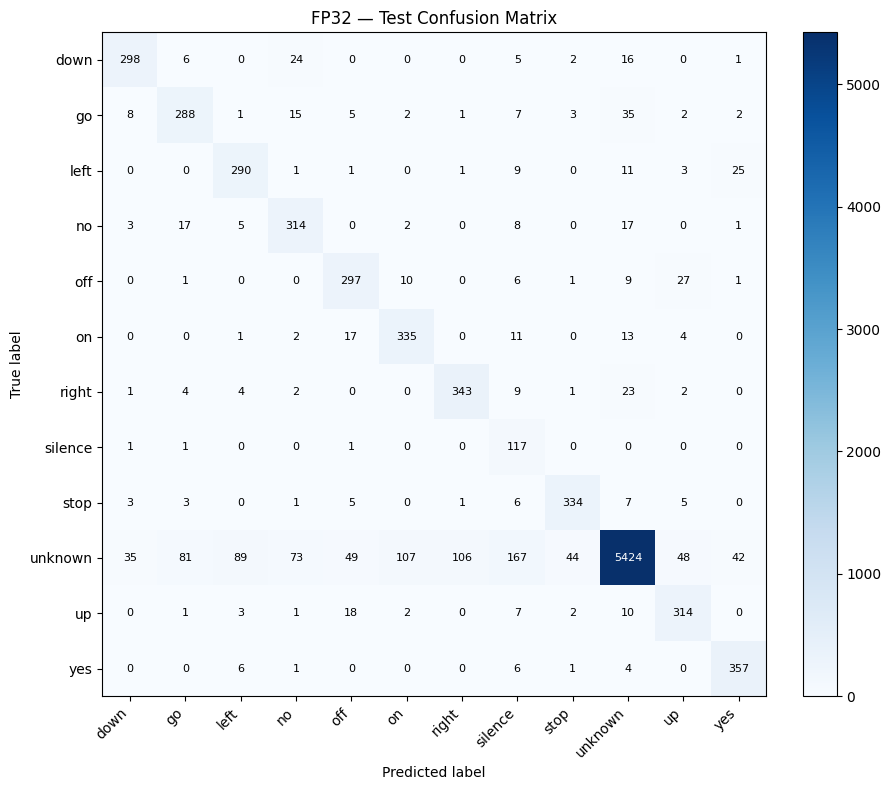

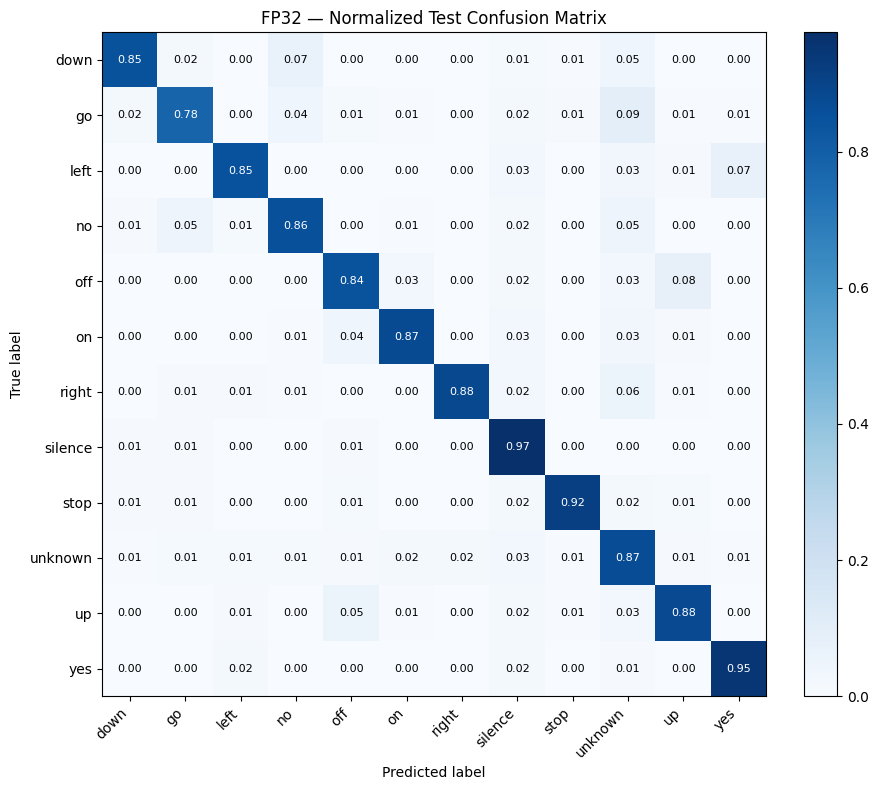

In [ ]:
# =========================================================
# GENERIC FINAL TEST-SET EVALUATION
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)


# =========================================================
# 1. GENERIC TEST FUNCTION
# =========================================================

def test_model(
    model,
    test_ds,
    model_name="Model",
    class_names=None,
    plot_cm=True,
):
    """
    Evaluate a TensorFlow/Keras model on the final test set.

    Reports:
        - Accuracy
        - Balanced Accuracy
        - Macro Precision
        - Macro Recall
        - Macro F1
        - Per-class precision / recall / F1
        - Raw confusion matrix
        - Confusion matrix normalized by true class

    IMPORTANT:
        Use only after the model/configuration has been frozen.
        Test results must not be used for further selection/tuning.
    """

    if class_names is None:
        class_names = list(le.classes_)

    # -----------------------------------------------------
    # Predictions
    # -----------------------------------------------------

    all_true = []
    all_pred = []
    all_prob = []

    for x_batch, y_batch in test_ds:

        probs = model(
            x_batch,
            training=False
        ).numpy()

        preds = np.argmax(
            probs,
            axis=1
        )

        labels = np.argmax(
            y_batch.numpy(),
            axis=1
        )

        all_true.append(labels)
        all_pred.append(preds)
        all_prob.append(probs)

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)
    y_prob = np.concatenate(all_prob)

    # -----------------------------------------------------
    # Main metrics
    # -----------------------------------------------------

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    balanced_accuracy = balanced_accuracy_score(
        y_true,
        y_pred
    )

    macro_precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    # Balanced Accuracy == Macro Recall for this
    # single-label multiclass problem.
    assert np.isclose(
        balanced_accuracy,
        macro_recall,
        atol=1e-10
    )

    # -----------------------------------------------------
    # Raw confusion matrix
    # -----------------------------------------------------

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    # -----------------------------------------------------
    # Normalized confusion matrix
    # Each row is normalized by the number of samples
    # belonging to the corresponding true class.
    # -----------------------------------------------------

    cm_normalized = cm.astype(
        np.float64
    )

    row_sums = cm_normalized.sum(
        axis=1,
        keepdims=True
    )

    cm_normalized = np.divide(
        cm_normalized,
        row_sums,
        out=np.zeros_like(cm_normalized),
        where=row_sums != 0
    )

    # -----------------------------------------------------
    # Per-class report
    # -----------------------------------------------------

    report = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    per_class_rows = []

    for class_name in class_names:

        values = report[
            class_name
        ]

        per_class_rows.append({
            "class":
                class_name,

            "precision":
                values["precision"],

            "recall":
                values["recall"],

            "f1":
                values["f1-score"],

            "support":
                int(values["support"]),
        })

    per_class_df = pd.DataFrame(
        per_class_rows
    )

    # -----------------------------------------------------
    # Print main results
    # -----------------------------------------------------

    print(
        "\n"
        + "=" * 80
    )

    print(
        f"FINAL TEST — {model_name}"
    )

    print(
        "=" * 80
    )

    print(
        f"Test samples:       {len(y_true)}"
    )

    print(
        f"Accuracy:           {accuracy:.6f} "
        f"({100 * accuracy:.3f}%)"
    )

    print(
        f"Balanced Accuracy:  {balanced_accuracy:.6f} "
        f"({100 * balanced_accuracy:.3f}%)"
    )

    print(
        f"Macro Precision:    {macro_precision:.6f} "
        f"({100 * macro_precision:.3f}%)"
    )

    print(
        f"Macro Recall:       {macro_recall:.6f} "
        f"({100 * macro_recall:.3f}%)"
    )

    print(
        f"Macro F1:           {macro_f1:.6f} "
        f"({100 * macro_f1:.3f}%)"
    )

    # -----------------------------------------------------
    # Per-class results
    # -----------------------------------------------------

    print(
        "\nPER-CLASS RESULTS"
    )

    print(
        per_class_df.to_string(
            index=False,
            float_format=lambda x: f"{x:.4f}"
        )
    )

    # -----------------------------------------------------
    # Helper function for confusion matrices
    # -----------------------------------------------------

    def plot_confusion_matrix(
        matrix,
        title,
        normalized=False
    ):

        fig, ax = plt.subplots(
            figsize=(10, 8)
        )

        im = ax.imshow(
            matrix,
            interpolation="nearest",
            cmap="Blues"
        )

        fig.colorbar(
            im,
            ax=ax,
            fraction=0.046,
            pad=0.04
        )

        # -------------------------------------------------
        # Axis labels
        # -------------------------------------------------

        ticks = np.arange(
            len(class_names)
        )

        ax.set_xticks(ticks)
        ax.set_yticks(ticks)

        ax.set_xticklabels(
            class_names,
            rotation=45,
            ha="right"
        )

        ax.set_yticklabels(
            class_names
        )

        ax.set_xlabel(
            "Predicted label"
        )

        ax.set_ylabel(
            "True label"
        )

        ax.set_title(
            title
        )

        # -------------------------------------------------
        # Cell annotation threshold
        # -------------------------------------------------

        threshold = (
            matrix.max() * 0.65
            if matrix.size
            else 0
        )

        # -------------------------------------------------
        # Cell annotations
        # -------------------------------------------------

        for i in range(
            matrix.shape[0]
        ):

            for j in range(
                matrix.shape[1]
            ):

                value = matrix[i, j]

                if normalized:
                    text = f"{value:.2f}"
                else:
                    text = f"{int(value)}"

                ax.text(
                    j,
                    i,
                    text,
                    ha="center",
                    va="center",
                    fontsize=8,
                    color=(
                        "white"
                        if value > threshold
                        else "black"
                    )
                )

        plt.tight_layout()
        plt.show()

    # -----------------------------------------------------
    # Plot BOTH confusion matrices
    # -----------------------------------------------------

    if plot_cm:

        # 1. Raw counts
        plot_confusion_matrix(
            matrix=cm,
            title=(
                f"{model_name} — "
                f"Test Confusion Matrix"
            ),
            normalized=False
        )

        # 2. Normalized by true class
        plot_confusion_matrix(
            matrix=cm_normalized,
            title=(
                f"{model_name} — "
                f"Normalized Test Confusion Matrix"
            ),
            normalized=True
        )

    # -----------------------------------------------------
    # Structured return
    # -----------------------------------------------------

    return {
        "model_name":
            model_name,

        "n_samples":
            len(y_true),

        "accuracy":
            float(accuracy),

        "balanced_accuracy":
            float(balanced_accuracy),

        "macro_precision":
            float(macro_precision),

        "macro_recall":
            float(macro_recall),

        "macro_f1":
            float(macro_f1),

        "per_class":
            per_class_df,

        "confusion_matrix":
            cm,

        "confusion_matrix_normalized":
            cm_normalized,

        "y_true":
            y_true,

        "y_pred":
            y_pred,

        "y_prob":
            y_prob,
    }


# =========================================================
# 2. TEST CANONICAL FP32 MODEL
# =========================================================

fp32_model = load_fresh_model()

fp32_test_results = test_model(
    model=fp32_model,
    test_ds=test_ds,
    model_name="FP32",
    class_names=list(le.classes_),
    plot_cm=True,
)


BUILDING FINAL PROPOSED MODEL — Wmixed-A3

  WEIGHT QUANTIZATION: pwlq
  conv2d                     avg=4.25b | 2b:2 | 3b:8 | 4b:2 | 8b:4
  conv2d_1                   avg=2.69b | 2b:10 | 3b:22
  conv2d_2                   avg=2.61b | 2b:27 | 3b:35 | 4b:2
  conv2d_3                   avg=2.41b | 2b:81 | 3b:41 | 4b:6
  dense                      avg=2.00b | 2b:255 | 3b:1
  dense_1                    avg=2.01b | 2b:127 | 3b:1
  dense_2                    avg=2.58b | 2b:10 | 3b:1 | 8b:1
  conv2d_4                   avg=4.19b | 2b:2 | 3b:9 | 4b:1 | 8b:4
  conv2d_5                   avg=2.44b | 2b:18 | 3b:14
  conv2d_6                   avg=2.22b | 2b:50 | 3b:14
  conv2d_7                   avg=4.52b | 2b:4 | 3b:42 | 4b:53 | 8b:29
  dense_3                    avg=2.09b | 2b:234 | 3b:22
  dense_4                    avg=2.05b | 2b:121 | 3b:7
  dense_5                    avg=2.08b | 2b:11 | 3b:1
  command_classifier         avg=2.50b | 2b:11 | 8b:1
Activation quantizers patched: 15 layers at A

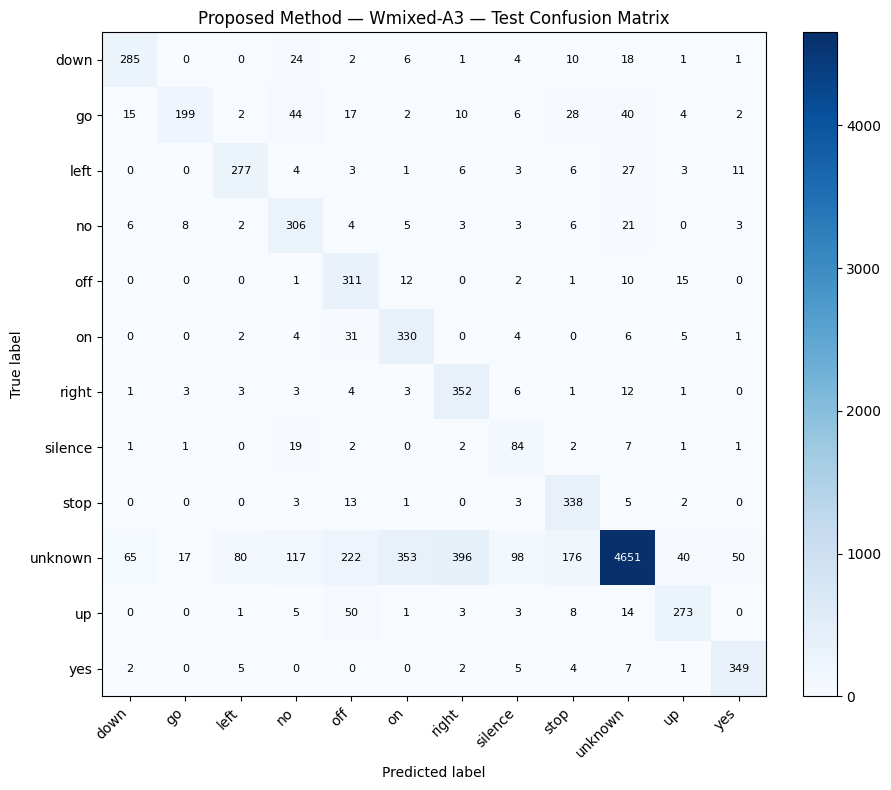

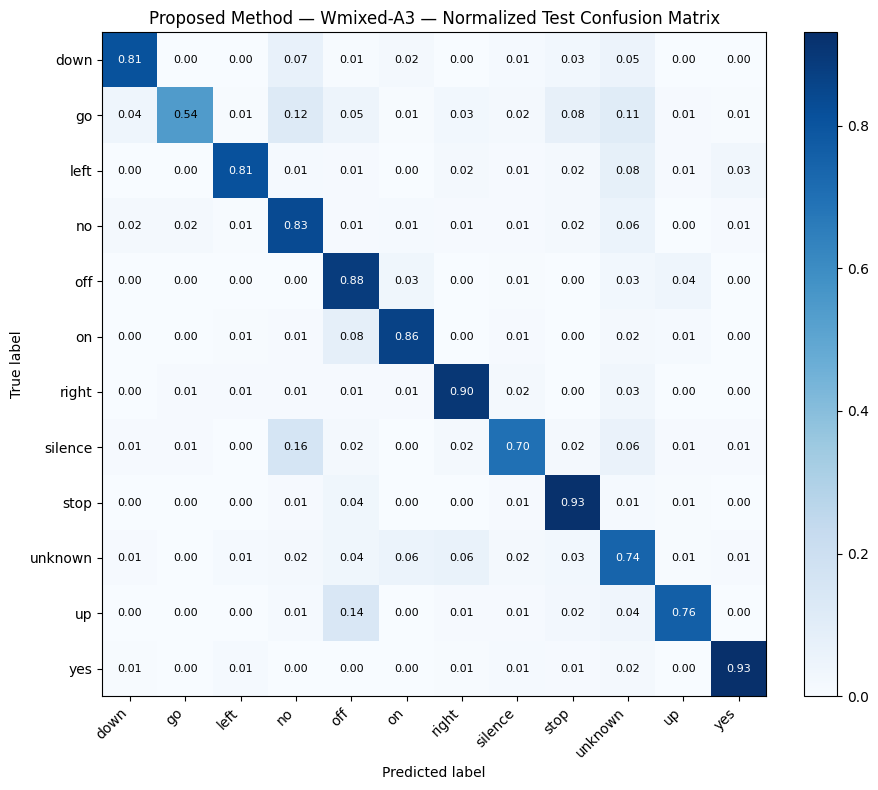

In [ ]:
# ============================================================
# 3. TEST FINAL PROPOSED MODEL
# Wmixed-A3
# ============================================================

print("\n" + "=" * 80)
print("BUILDING FINAL PROPOSED MODEL — Wmixed-A3")
print("=" * 80)

# ------------------------------------------------------------
# Build the frozen final quantized model
# ------------------------------------------------------------

final_quantized_model, weight_mode, activation_bits = (
    build_final_quantized_model(
        activation_results=activation_results,
        scale_bits=0,
        break_point="norm",
        pw_opt=2,
        approximate=True,
    )
)

# ------------------------------------------------------------
# Verify selected configuration
# ------------------------------------------------------------

print(f"Weight configuration: {weight_mode}")
print(f"Activation bits:      {activation_bits}")

# The final frozen configuration should be A3
assert activation_bits == 3, (
    f"Expected final activation precision A3, "
    f"but received A{activation_bits}."
)

# ------------------------------------------------------------
# Final test evaluation
# ------------------------------------------------------------

proposed_test_results = test_model(
    model=final_quantized_model,
    test_ds=test_ds,
    model_name="Proposed Method — Wmixed-A3",
    class_names=list(le.classes_),
    plot_cm=True,
)

In [ ]:
# ============================================================
# 1. CANONICAL MODEL LOADER
# ============================================================

def load_fresh_model():
    """
    Always returns a fresh copy of the canonical FP32 model.
    """
    return tf.keras.models.load_model(
        CANONICAL_MODEL_PATH,
        compile=False
    )


# ============================================================
# 2. RESULT STORAGE
# ============================================================

final_test_rows = []


def store_test_result(
    method,
    weight_precision,
    activation_precision,
    granularity,
    results,
    extra_config=""
):
    """
    Stores one final-test result in a common format.
    """

    final_test_rows.append({
        "Method": method,
        "Weight Precision": weight_precision,
        "Activation Precision": activation_precision,
        "Granularity": granularity,
        "Configuration": extra_config,

        "Accuracy": results["accuracy"],
        "Balanced Accuracy": results["balanced_accuracy"],
        "Macro Precision": results["macro_precision"],
        "Macro Recall": results["macro_recall"],
        "Macro F1": results["macro_f1"],
    })


def cleanup_model(model):
    """
    Releases TensorFlow/Keras memory between independent candidates.
    """
    del model
    tf.keras.backend.clear_session()
    gc.collect()


FINAL TEST — PROPOSED METHOD

  WEIGHT QUANTIZATION: pwlq
  conv2d                     avg=4.25b | 2b:2 | 3b:8 | 4b:2 | 8b:4
  conv2d_1                   avg=2.69b | 2b:10 | 3b:22
  conv2d_2                   avg=2.61b | 2b:27 | 3b:35 | 4b:2
  conv2d_3                   avg=2.41b | 2b:81 | 3b:41 | 4b:6
  dense                      avg=2.00b | 2b:255 | 3b:1
  dense_1                    avg=2.01b | 2b:127 | 3b:1
  dense_2                    avg=2.58b | 2b:10 | 3b:1 | 8b:1
  conv2d_4                   avg=4.19b | 2b:2 | 3b:9 | 4b:1 | 8b:4
  conv2d_5                   avg=2.44b | 2b:18 | 3b:14
  conv2d_6                   avg=2.22b | 2b:50 | 3b:14
  conv2d_7                   avg=4.52b | 2b:4 | 3b:42 | 4b:53 | 8b:29
  dense_3                    avg=2.09b | 2b:234 | 3b:22
  dense_4                    avg=2.05b | 2b:121 | 3b:7
  dense_5                    avg=2.08b | 2b:11 | 3b:1
  command_classifier         avg=2.50b | 2b:11 | 8b:1
Activation quantizers patched: 15 layers at A3

FINAL TEST

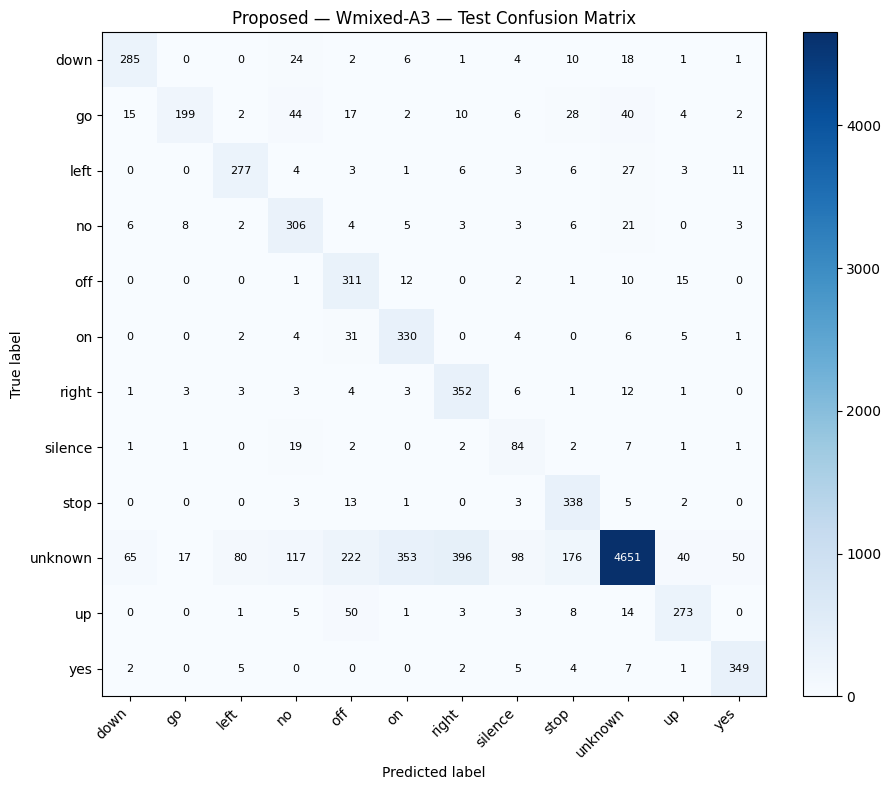

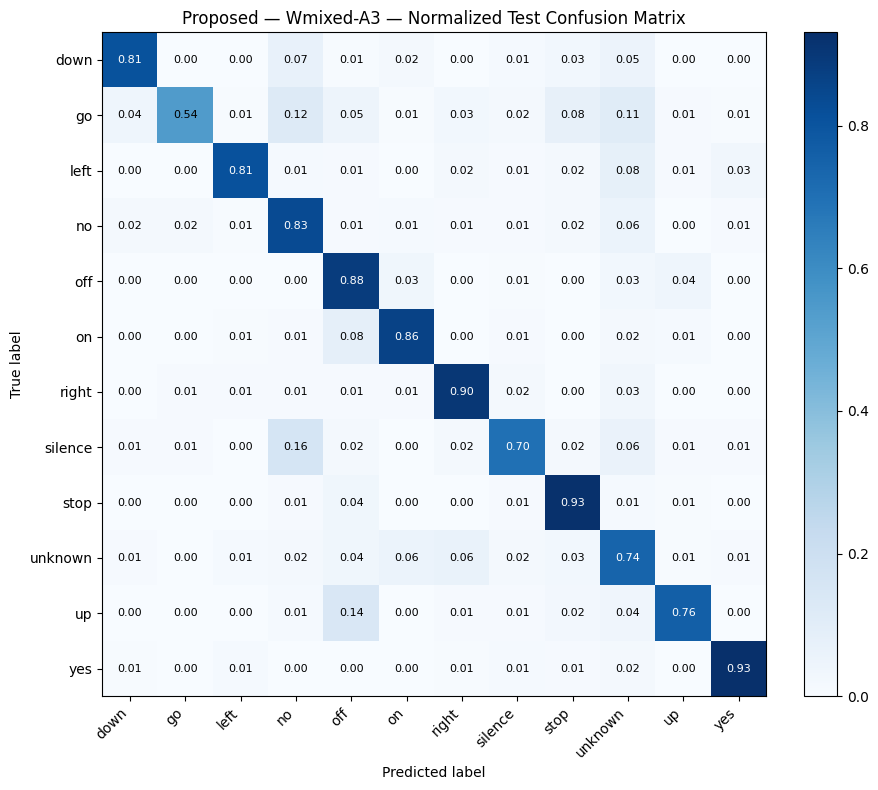

In [ ]:
# ============================================================
# 4. PROPOSED METHOD
# Wmixed-A3 (or whatever activation_results selected)
# ============================================================

print("\n" + "=" * 80)
print("FINAL TEST — PROPOSED METHOD")
print("=" * 80)

# ============================================================
# CONFIGURATION
# ============================================================

CANONICAL_MODEL_PATH = (
    "/content/drive/MyDrive/results/revision_best_model.keras"
)

CLASS_NAMES = list(le.classes_)


final_quantized_model, weight_mode, activation_bits = (
    build_final_quantized_model(
        activation_results=activation_results,
        scale_bits=0,
        break_point="norm",
        pw_opt=2,
        approximate=True,
    )
)

final_quantized_test_results = test_model(
    model=final_quantized_model,
    test_ds=test_ds,
    model_name=f"Proposed — Wmixed-A{activation_bits}",
    class_names=CLASS_NAMES,
    plot_cm=True,
)

store_test_result(
    method="Proposed Method",
    weight_precision="Wmixed",
    activation_precision=f"A{activation_bits}",
    granularity="Per-channel",
    results=final_quantized_test_results,
    extra_config=str(weight_mode),
)

cleanup_model(final_quantized_model)


FINAL TEST — CANONICAL FP32

FINAL TEST — FP32
Test samples:       10036
Accuracy:           0.867975 (86.798%)
Balanced Accuracy:  0.876517 (87.652%)
Macro Precision:    0.752975 (75.298%)
Macro Recall:       0.876517 (87.652%)
Macro F1:           0.798271 (79.827%)

PER-CLASS RESULTS
  class  precision  recall     f1  support
   down     0.8539  0.8466 0.8502      352
     go     0.7164  0.7805 0.7471      369
   left     0.7268  0.8504 0.7838      341
     no     0.7235  0.8556 0.7840      367
    off     0.7557  0.8438 0.7973      352
     on     0.7314  0.8747 0.7967      383
  right     0.7588  0.8817 0.8157      389
silence     0.3268  0.9750 0.4895      120
   stop     0.8608  0.9151 0.8871      365
unknown     0.9740  0.8658 0.9167     6265
     up     0.7753  0.8771 0.8231      358
    yes     0.8322  0.9520 0.8881      375


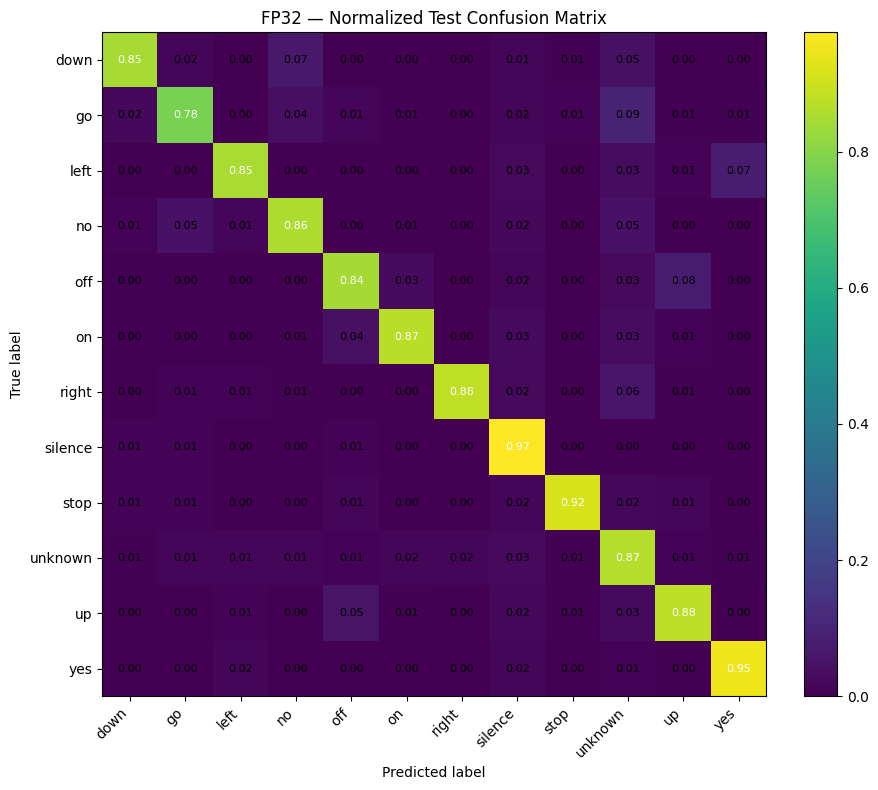


FINAL TEST — PROPOSED METHOD

  WEIGHT QUANTIZATION: pwlq
  conv2d                     avg=4.25b | 2b:2 | 3b:8 | 4b:2 | 8b:4
  conv2d_1                   avg=2.69b | 2b:10 | 3b:22
  conv2d_2                   avg=2.61b | 2b:27 | 3b:35 | 4b:2
  conv2d_3                   avg=2.41b | 2b:81 | 3b:41 | 4b:6
  dense                      avg=2.00b | 2b:255 | 3b:1
  dense_1                    avg=2.01b | 2b:127 | 3b:1
  dense_2                    avg=2.58b | 2b:10 | 3b:1 | 8b:1
  conv2d_4                   avg=4.19b | 2b:2 | 3b:9 | 4b:1 | 8b:4
  conv2d_5                   avg=2.44b | 2b:18 | 3b:14
  conv2d_6                   avg=2.22b | 2b:50 | 3b:14
  conv2d_7                   avg=4.52b | 2b:4 | 3b:42 | 4b:53 | 8b:29
  dense_3                    avg=2.09b | 2b:234 | 3b:22
  dense_4                    avg=2.05b | 2b:121 | 3b:7
  dense_5                    avg=2.08b | 2b:11 | 3b:1
  command_classifier         avg=2.50b | 2b:11 | 8b:1
Activation quantizers patched: 15 layers at A3

FINAL TEST

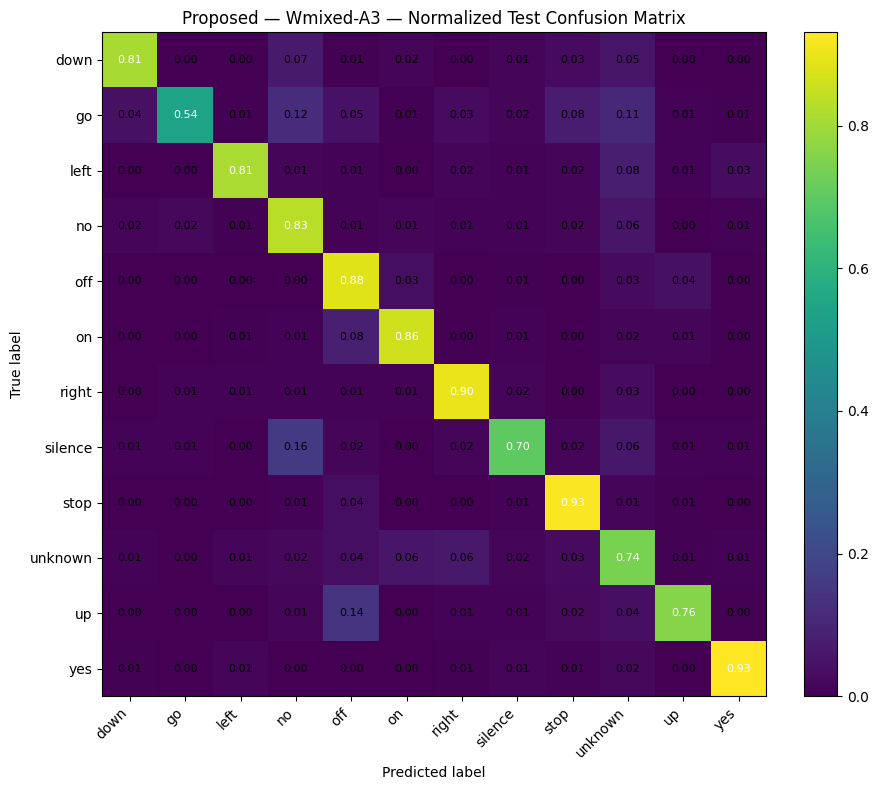


FINAL TEST — UNIFORM PER-CHANNEL

--- Uniform Per-channel W8A32 ---

FINAL TEST — Uniform — W8A32
Test samples:       10036
Accuracy:           0.868075 (86.807%)
Balanced Accuracy:  0.876965 (87.697%)
Macro Precision:    0.753282 (75.328%)
Macro Recall:       0.876965 (87.697%)
Macro F1:           0.798587 (79.859%)

PER-CLASS RESULTS
  class  precision  recall     f1  support
   down     0.8539  0.8466 0.8502      352
     go     0.7153  0.7832 0.7477      369
   left     0.7312  0.8534 0.7876      341
     no     0.7218  0.8556 0.7830      367
    off     0.7590  0.8409 0.7978      352
     on     0.7346  0.8747 0.7986      383
  right     0.7605  0.8817 0.8167      389
silence     0.3250  0.9750 0.4875      120
   stop     0.8546  0.9178 0.8851      365
unknown     0.9740  0.8656 0.9166     6265
     up     0.7734  0.8771 0.8220      358
    yes     0.8361  0.9520 0.8903      375

--- Uniform Per-channel W4A32 ---

FINAL TEST — Uniform — W4A32
Test samples:       10036
Accuracy:  

/usr/local/lib/python3.13/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (255) found smaller than n_clusters (256). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


  conv2d_4               Conv2D   → 8-bit (256 centroids)
  conv2d_5               Conv2D   → 8-bit (256 centroids)
  conv2d_6               Conv2D   → 8-bit (256 centroids)
  conv2d_7               Conv2D   → 8-bit (256 centroids)
  dense_3                Dense    → 8-bit (256 centroids)
  dense_4                Dense    → 8-bit (256 centroids)
  dense_5                Dense    → 8-bit (256 centroids)
  command_classifier     Dense    → 8-bit (256 centroids)

Quantization complete.

FINAL TEST — K-Means — W8A32
Test samples:       10036
Accuracy:           0.867776 (86.778%)
Balanced Accuracy:  0.876062 (87.606%)
Macro Precision:    0.752529 (75.253%)
Macro Recall:       0.876062 (87.606%)
Macro F1:           0.797830 (79.783%)

PER-CLASS RESULTS
  class  precision  recall     f1  support
   down     0.8539  0.8466 0.8502      352
     go     0.7164  0.7805 0.7471      369
   left     0.7268  0.8504 0.7838      341
     no     0.7252  0.8556 0.7850      367
    off     0.7532  0.8409 

,Method,Weight Precision,Activation Precision,Granularity,Configuration,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Relative BA Drop (%)
0,FP32,FP32,FP32,--,,0.867975,0.876517,0.752975,0.876517,0.798271,0.0000
1,Proposed Method,Wmixed,A3,Per-channel,pwlq,0.772718,0.808894,0.657936,0.808894,0.702896,7.7150
2,Uniform,W8,A32,Per-channel,,0.868075,0.876965,0.753282,0.876965,0.798587,-0.0512
3,Uniform,W4,A32,Per-channel,,0.858609,0.873536,0.740147,0.873536,0.788176,0.3401
4,Uniform,W2,A32,Per-channel,,0.047330,0.108889,0.014133,0.108889,0.023073,87.5771
5,K-Means,W8,A32,Per-layer,,0.867776,0.876062,0.752529,0.876062,0.797830,0.0518
6,K-Means,W4,A32,Per-layer,,0.859306,0.876112,0.738108,0.876112,0.789399,0.0461
7,K-Means,W2,A32,Per-layer,,0.693503,0.722067,0.621863,0.722067,0.599522,17.6209
8,Lloyd-Max,W8,A32,Per-layer,,0.868473,0.876379,0.753932,0.876379,0.798685,0.0157
9,Lloyd-Max,W4,A32,Per-layer,,0.835592,0.877950,0.705732,0.877950,0.769043,-0.1635



WEIGHT-ONLY FINAL TEST RESULTS


,Method,Weight Precision,Activation Precision,Granularity,Configuration,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Relative BA Drop (%)
0,FP32,FP32,FP32,--,,0.867975,0.876517,0.752975,0.876517,0.798271,0.0000
2,Uniform,W8,A32,Per-channel,,0.868075,0.876965,0.753282,0.876965,0.798587,-0.0512
3,Uniform,W4,A32,Per-channel,,0.858609,0.873536,0.740147,0.873536,0.788176,0.3401
4,Uniform,W2,A32,Per-channel,,0.047330,0.108889,0.014133,0.108889,0.023073,87.5771
5,K-Means,W8,A32,Per-layer,,0.867776,0.876062,0.752529,0.876062,0.797830,0.0518
6,K-Means,W4,A32,Per-layer,,0.859306,0.876112,0.738108,0.876112,0.789399,0.0461
7,K-Means,W2,A32,Per-layer,,0.693503,0.722067,0.621863,0.722067,0.599522,17.6209
8,Lloyd-Max,W8,A32,Per-layer,,0.868473,0.876379,0.753932,0.876379,0.798685,0.0157
9,Lloyd-Max,W4,A32,Per-layer,,0.835592,0.877950,0.705732,0.877950,0.769043,-0.1635
10,Lloyd-Max,W2,A32,Per-layer,,0.708250,0.738980,0.643873,0.738980,0.620060,15.6913



WEIGHT + ACTIVATION FINAL TEST RESULTS


,Method,Weight Precision,Activation Precision,Granularity,Configuration,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Relative BA Drop (%)
1,Proposed Method,Wmixed,A3,Per-channel,pwlq,0.772718,0.808894,0.657936,0.808894,0.702896,7.7150



Saved final benchmark to:
/content/drive/MyDrive/results/revision_final_test_benchmark.csv

FINAL TEST BENCHMARK COMPLETE.


In [ ]:
# ============================================================
# FINAL TEST BENCHMARK
# FP32 + Proposed + Uniform + K-Means + Lloyd-Max
# + Group-wise + PWLQ + BitSplit
#
# IMPORTANT:
#   - All configurations are assumed to have been frozen
#     BEFORE looking at test results.
#   - test_ds is used ONLY for final evaluation.
#   - Every independent candidate starts from the same
#     canonical FP32 checkpoint.
# ============================================================

import gc
import numpy as np
import pandas as pd
import tensorflow as tf

# ============================================================
# CONFIGURATION
# ============================================================

CANONICAL_MODEL_PATH = (
    "/content/drive/MyDrive/results/revision_best_model.keras"
)

CLASS_NAMES = list(le.classes_)

# Predefined benchmark configurations
UNIFORM_BITS = [8, 4, 2]
KMEANS_BITS = [8, 4, 2]
LLOYD_BITS = [8, 4, 2]

GROUPWISE_BITS = [8, 4, 2]
GROUPWISE_GROUP_SIZES = [64, 32, 16]

PWLQ_BITS = [8, 4, 2]

BITSPLIT_BITS = [8, 4, 3]


# ============================================================
# 3. FP32
# ============================================================

print("\n" + "=" * 80)
print("FINAL TEST — CANONICAL FP32")
print("=" * 80)

fp32_model = load_fresh_model()

fp32_test_results = test_model(
    model=fp32_model,
    test_ds=test_ds,
    model_name="FP32",
    class_names=CLASS_NAMES,
    plot_cm=True,
)

store_test_result(
    method="FP32",
    weight_precision="FP32",
    activation_precision="FP32",
    granularity="--",
    results=fp32_test_results,
)

cleanup_model(fp32_model)


# ============================================================
# 4. PROPOSED METHOD
# Wmixed-A3 (or whatever activation_results selected)
# ============================================================

print("\n" + "=" * 80)
print("FINAL TEST — PROPOSED METHOD")
print("=" * 80)

final_quantized_model, weight_mode, activation_bits = (
    build_final_quantized_model(
        activation_results=activation_results,
        scale_bits=0,
        break_point="norm",
        pw_opt=2,
        approximate=True,
    )
)

final_quantized_test_results = test_model(
    model=final_quantized_model,
    test_ds=test_ds,
    model_name=f"Proposed — Wmixed-A{activation_bits}",
    class_names=CLASS_NAMES,
    plot_cm=True,
)

store_test_result(
    method="Proposed Method",
    weight_precision="Wmixed",
    activation_precision=f"A{activation_bits}",
    granularity="Per-channel",
    results=final_quantized_test_results,
    extra_config=str(weight_mode),
)

cleanup_model(final_quantized_model)


# ============================================================
# 5. UNIFORM — PER-LAYER
# W8A32 / W4A32 / W2A32
# ============================================================

print("\n" + "=" * 80)
print("FINAL TEST — UNIFORM PER-LAYER")
print("=" * 80)

for bits in UNIFORM_BITS:

    print(f"\n--- Uniform Per-layer W{bits}A32 ---")

    model = load_fresh_model()

    # Uses the per-layer uniform quantizer already
    # defined in the notebook.
    quantize_dequantize_uniform(
        model,
        num_bits=bits,
        verbose=False
    )

    results = test_model(
        model=model,
        test_ds=test_ds,
        model_name=f"Uniform — W{bits}A32",
        class_names=CLASS_NAMES,
        plot_cm=False,
    )

    store_test_result(
        method="Uniform",
        weight_precision=f"W{bits}",
        activation_precision="A32",
        granularity="Per-layer",
        results=results,
    )

    cleanup_model(model)


# ============================================================
# 6. K-MEANS — PER-LAYER
# W8A32 / W4A32 / W2A32
# ============================================================

print("\n" + "=" * 80)
print("FINAL TEST — K-MEANS")
print("=" * 80)

for bits in KMEANS_BITS:

    print(f"\n--- K-Means W{bits}A32 ---")

    # Always start from the canonical FP32 model
    model = load_fresh_model()

    # In-place quantization: function returns None
    quantize_dequantize_kmeans(
        model,
        num_bits=bits
    )

    results = test_model(
        model=model,
        test_ds=test_ds,
        model_name=f"K-Means — W{bits}A32",
        class_names=CLASS_NAMES,
        plot_cm=False,
    )

    store_test_result(
        method="K-Means",
        weight_precision=f"W{bits}",
        activation_precision="A32",
        granularity="Per-layer",
        results=results,
    )

    cleanup_model(model)


# ============================================================
# 7. LLOYD-MAX — PER-LAYER
# W8A32 / W4A32 / W2A32
# ============================================================

print("\n" + "=" * 80)
print("FINAL TEST — LLOYD-MAX")
print("=" * 80)

for bits in LLOYD_BITS:

    print(f"\n--- Lloyd-Max W{bits}A32 ---")

    # Always start from the canonical FP32 model
    model = load_fresh_model()

    # In-place quantization: function returns None
    quantize_dequantize_lloydmax(
        model,
        num_bits=bits
    )

    results = test_model(
        model=model,
        test_ds=test_ds,
        model_name=f"Lloyd-Max — W{bits}A32",
        class_names=CLASS_NAMES,
        plot_cm=False,
    )

    store_test_result(
        method="Lloyd-Max",
        weight_precision=f"W{bits}",
        activation_precision="A32",
        granularity="Per-layer",
        results=results,
    )

    cleanup_model(model)


# ============================================================
# 8. GROUP-WISE
# W8/W4/W2 × G64/G32/G16
# All configurations are weight-only -> A32
# ============================================================

print("\n" + "=" * 80)
print("FINAL TEST — GROUP-WISE")
print("=" * 80)

for bits in GROUPWISE_BITS:

    for group_size in GROUPWISE_GROUP_SIZES:

        print(
            f"\n--- Group-wise "
            f"W{bits}A32 / G{group_size} ---"
        )

        # Always start from the canonical FP32 model
        model = load_fresh_model()

        # In-place quantization: function returns None
        quantize_dequantize_groupwise(
            model,
            num_bits=bits,
            group_size=group_size
        )

        results = test_model(
            model=model,
            test_ds=test_ds,
            model_name=(
                f"Group-wise G{group_size} — "
                f"W{bits}A32"
            ),
            class_names=CLASS_NAMES,
            plot_cm=False,
        )

        store_test_result(
            method="Group-wise",
            weight_precision=f"W{bits}",
            activation_precision="A32",
            granularity=f"Group={group_size}",
            results=results,
        )

        cleanup_model(model)


# ============================================================
# 9. PWLQ BASELINE
# W8A32 / W4A32 / W2A32
# Per-layer + Per-channel
# ============================================================

print("\n" + "=" * 80)
print("FINAL TEST — PWLQ BASELINE")
print("=" * 80)

for bits in PWLQ_BITS:

    for granularity in ["per_layer", "per_channel"]:

        print(
            f"\n--- PWLQ W{bits}A32 "
            f"({granularity}) ---"
        )

        # Always start from the same canonical FP32 model
        model = load_fresh_model()

        label = f"PWLQ {bits}-bit ({granularity})"

        # Same exact PWLQ configuration used during validation.
        # Quantization is performed IN-PLACE.
        quantize_model_pwlq(
            model,
            bits=bits,
            granularity=granularity,
            label=label,
        )

        # Final evaluation on the locked test set
        results = test_model(
            model=model,
            test_ds=test_ds,
            model_name=(
                f"PWLQ — W{bits}A32 "
                f"({granularity})"
            ),
            class_names=CLASS_NAMES,
            plot_cm=False,
        )

        # Cleaner name for the results table
        granularity_name = (
            "Per-layer"
            if granularity == "per_layer"
            else "Per-channel"
        )

        store_test_result(
            method="PWLQ",
            weight_precision=f"W{bits}",
            activation_precision="A32",
            granularity=granularity_name,
            results=results,
        )

        cleanup_model(model)


# ============================================================
# 10. BITSPLIT
# W8A32 / W4A32 / W3A32
# Per-channel
# ============================================================

print("\n" + "=" * 80)
print("FINAL TEST — BITSPLIT")
print("=" * 80)

for bits in BITSPLIT_BITS:

    print(f"\n--- BitSplit W{bits}A32 (per-channel) ---")

    # Fresh canonical FP32 model for every configuration
    model = load_fresh_model()

    label = f"BitSplit {bits}-bit (per-channel)"

    # Same exact BitSplit configuration used during validation.
    # Quantization is performed IN-PLACE.
    quantize_all_layers_tf(
        model,
        num_bits=bits,
    )

    # Final evaluation on test set
    results = test_model(
        model=model,
        test_ds=test_ds,
        model_name=f"BitSplit — W{bits}A32 (per-channel)",
        class_names=CLASS_NAMES,
        plot_cm=False,
    )

    store_test_result(
        method="BitSplit",
        weight_precision=f"W{bits}",
        activation_precision="A32",
        granularity="Per-channel",
        results=results,
    )

    cleanup_model(model)


# ============================================================
# 11. FINAL RESULTS TABLE
# ============================================================

final_test_df = pd.DataFrame(final_test_rows)

# FP32 reference BA
fp32_ba = final_test_df.loc[
    final_test_df["Method"] == "FP32",
    "Balanced Accuracy"
].iloc[0]

# Relative BA degradation
final_test_df["Relative BA Drop (%)"] = (
    100.0
    * (
        fp32_ba
        - final_test_df["Balanced Accuracy"]
    )
    / fp32_ba
)

# Avoid tiny floating-point value for FP32
final_test_df.loc[
    final_test_df["Method"] == "FP32",
    "Relative BA Drop (%)"
] = 0.0


# ============================================================
# 12. DISPLAY
# ============================================================

display_columns = [
    "Method",
    "Weight Precision",
    "Activation Precision",
    "Granularity",
    "Configuration",
    "Accuracy",
    "Balanced Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "Relative BA Drop (%)",
]

print("\n" + "=" * 110)
print("FINAL TEST BENCHMARK")
print("=" * 110)

display(
    final_test_df[display_columns]
    .style
    .format({
        "Accuracy": "{:.6f}",
        "Balanced Accuracy": "{:.6f}",
        "Macro Precision": "{:.6f}",
        "Macro Recall": "{:.6f}",
        "Macro F1": "{:.6f}",
        "Relative BA Drop (%)": "{:.4f}",
    })
)


# ============================================================
# 13. WEIGHT-ONLY TABLE
# ============================================================

weight_only_df = final_test_df[
    final_test_df["Activation Precision"].isin(
        ["FP32", "A32"]
    )
].copy()

print("\nWEIGHT-ONLY FINAL TEST RESULTS")
display(
    weight_only_df[display_columns]
    .style
    .format({
        "Accuracy": "{:.6f}",
        "Balanced Accuracy": "{:.6f}",
        "Macro Precision": "{:.6f}",
        "Macro Recall": "{:.6f}",
        "Macro F1": "{:.6f}",
        "Relative BA Drop (%)": "{:.4f}",
    })
)


# ============================================================
# 14. WEIGHT + ACTIVATION TABLE
# ============================================================

weight_activation_df = final_test_df[
    ~final_test_df["Activation Precision"].isin(
        ["FP32", "A32"]
    )
].copy()

print("\nWEIGHT + ACTIVATION FINAL TEST RESULTS")
display(
    weight_activation_df[display_columns]
    .style
    .format({
        "Accuracy": "{:.6f}",
        "Balanced Accuracy": "{:.6f}",
        "Macro Precision": "{:.6f}",
        "Macro Recall": "{:.6f}",
        "Macro F1": "{:.6f}",
        "Relative BA Drop (%)": "{:.4f}",
    })
)


# ============================================================
# 15. SAVE FINAL RESULTS
# ============================================================

output_csv = (
    "/content/drive/MyDrive/results/"
    "revision_final_test_benchmark.csv"
)

final_test_df.to_csv(
    output_csv,
    index=False
)

print("\nSaved final benchmark to:")
print(output_csv)

print("\nFINAL TEST BENCHMARK COMPLETE.")

In [ ]:
import gc
import numpy as np
import pandas as pd
import tensorflow as tf

# ============================================================
# CONFIGURATION
# ============================================================

CANONICAL_MODEL_PATH = (
    "/content/drive/MyDrive/results/revision_best_model.keras"
)

CLASS_NAMES = list(le.classes_)

# ============================================================
# FINAL TEST — ADAROUND
# W8A32 / W4A32 / W2A32
# ============================================================

print("\n" + "=" * 80)
print("FINAL TEST — ADAROUND")
print("=" * 80)

ADAROUND_BITS = [8, 4, 2]

for bits in ADAROUND_BITS:

    print(f"\n--- AdaRound W{bits}A32 ---")

    # Fresh canonical FP32 model
    model = load_fresh_model()

    # Same calibration-based AdaRound procedure used on validation
    apply_adaround(
        model,
        calib_ds,
        num_bits=bits,
    )

    # Final test evaluation
    results = test_model(
        model=model,
        test_ds=test_ds,
        model_name=f"AdaRound — W{bits}A32",
        class_names=CLASS_NAMES,
        plot_cm=False,
    )

    store_test_result(
        method="AdaRound",
        weight_precision=f"W{bits}",
        activation_precision="A32",
        granularity="Per-layer",  # change ONLY if your implementation is not per-layer
        results=results,
    )

    cleanup_model(model)


print("\nAdaRound final test complete.")


FINAL TEST — ADAROUND

--- AdaRound W8A32 ---
Quantizable layers:
  [00] conv2d | shape: (4, 4, 1, 16)
  [01] conv2d_1 | shape: (4, 4, 16, 32)
  [02] conv2d_2 | shape: (2, 2, 32, 64)
  [03] conv2d_3 | shape: (2, 2, 64, 128)
  [04] dense | shape: (2944, 256)
  [05] dense_1 | shape: (256, 128)
  [06] dense_2 | shape: (128, 12)
  [07] conv2d_4 | shape: (4, 4, 1, 16)
  [08] conv2d_5 | shape: (4, 4, 16, 32)
  [09] conv2d_6 | shape: (2, 2, 32, 64)
  [10] conv2d_7 | shape: (2, 2, 64, 128)
  [11] dense_3 | shape: (23552, 256)
  [12] dense_4 | shape: (256, 128)
  [13] dense_5 | shape: (128, 12)
  [14] command_classifier | shape: (24, 12)

=== AdaRound: conv2d | shape: (4, 4, 1, 16) ===
  Naive rounding MSE:   0.00000069
  iter 00000 | rec=9.15e-13 | beta=20.00 | >0.5=52.0%
  iter 01000 | rec=7.34e-13 | beta=20.00 | >0.5=52.0%
  iter 02000 | rec=6.00e-13 | beta=20.00 | >0.5=52.0%
  iter 03000 | rec=3.08e-07 | beta=17.75 | >0.5=52.3%
  iter 04000 | rec=2.96e-07 | beta=15.50 | >0.5=52.3%
  iter 0

In [ ]:
import gc
import numpy as np
import pandas as pd
import tensorflow as tf

# ============================================================
# CONFIGURATION
# ============================================================

CANONICAL_MODEL_PATH = (
    "/content/drive/MyDrive/results/revision_best_model.keras"
)

CLASS_NAMES = list(le.classes_)

# ============================================================
# FINAL TEST — SUBSETQ
# W4A32 / W3A32 / W2A32
# Per-layer + Per-channel
# ============================================================

print("\n" + "=" * 80)
print("FINAL TEST — SUBSETQ")
print("=" * 80)

SUBSETQ_BITS = [4, 3, 2]

for mode in ["layer", "channel"]:

    for bits in SUBSETQ_BITS:

        print(
            f"\n--- SubsetQ W{bits}A32 "
            f"(per-{mode}) ---"
        )

        # Fresh canonical FP32 model
        model = load_fresh_model()

        # Same configuration used during validation
        apply_subsetq_keras(
            model,
            bits=bits,
            mode=mode,
        )

        # Final test evaluation
        results = test_model(
            model=model,
            test_ds=test_ds,
            model_name=(
                f"SubsetQ — W{bits}A32 "
                f"(per-{mode})"
            ),
            class_names=CLASS_NAMES,
            plot_cm=False,
        )

        store_test_result(
            method="SubsetQ",
            weight_precision=f"W{bits}",
            activation_precision="A32",
            granularity=(
                "Per-layer"
                if mode == "layer"
                else "Per-channel"
            ),
            results=results,
        )

        cleanup_model(model)


print("\nSubsetQ final test complete.")


FINAL TEST — SUBSETQ

--- SubsetQ W4A32 (per-layer) ---

  SubsetQ 4-bit (per-layer)
  conv2d                 Conv2D   shape=(4, 4, 1, 16)
  conv2d_1               Conv2D   shape=(4, 4, 16, 32)
  conv2d_2               Conv2D   shape=(2, 2, 32, 64)
  conv2d_3               Conv2D   shape=(2, 2, 64, 128)
  dense                  Dense    shape=(2944, 256)
  dense_1                Dense    shape=(256, 128)
  dense_2                Dense    shape=(128, 12)
  conv2d_4               Conv2D   shape=(4, 4, 1, 16)
  conv2d_5               Conv2D   shape=(4, 4, 16, 32)
  conv2d_6               Conv2D   shape=(2, 2, 32, 64)
  conv2d_7               Conv2D   shape=(2, 2, 64, 128)
  dense_3                Dense    shape=(23552, 256)
  dense_4                Dense    shape=(256, 128)
  dense_5                Dense    shape=(128, 12)
  command_classifier     Dense    shape=(24, 12)

Quantization complete.

FINAL TEST — SubsetQ — W4A32 (per-layer)
Test samples:       10036
Accuracy:           0.8183

In [ ]:
# ============================================================
# CONFIGURATION
# ============================================================

CANONICAL_MODEL_PATH = (
    "/content/drive/MyDrive/results/revision_best_model.keras"
)

CLASS_NAMES = list(le.classes_)

# ============================================================
# FINAL TEST — LAPQ
# W8A32 / W4A32 / W2A32
# Per-layer + Per-channel
# ============================================================

print("\n" + "=" * 80)
print("FINAL TEST — LAPQ")
print("=" * 80)


# ------------------------------------------------------------
# 1. Cache the FIXED calibration set
# ------------------------------------------------------------

cal_x1_list = []
cal_x2_list = []
cal_y_list = []

for (x1_batch, x2_batch), y_batch in calib_ds:

    cal_x1_list.append(
        x1_batch.numpy()
    )

    cal_x2_list.append(
        x2_batch.numpy()
    )

    cal_y_list.append(
        y_batch.numpy()
    )


cal_x1_tf = tf.constant(
    np.concatenate(
        cal_x1_list,
        axis=0
    ),
    dtype=tf.float32
)

cal_x2_tf = tf.constant(
    np.concatenate(
        cal_x2_list,
        axis=0
    ),
    dtype=tf.float32
)

cal_y_tf = tf.constant(
    np.concatenate(
        cal_y_list,
        axis=0
    ),
    dtype=tf.float32
)


print(
    f"Calibration data cached: "
    f"{cal_x1_tf.shape[0]} samples"
)

assert cal_x1_tf.shape[0] == 1024
assert cal_x2_tf.shape[0] == 1024
assert cal_y_tf.shape[0] == 1024


LAPQ_BITS = [8, 4, 2]


# ------------------------------------------------------------
# 2. LAPQ — PER-CHANNEL
# ------------------------------------------------------------

for bits in LAPQ_BITS:

    print(
        f"\n--- LAPQ W{bits}A32 "
        f"(per-channel) ---"
    )

    # Fresh canonical FP32 model
    model = load_fresh_model()

    # Same per-channel LAPQ procedure used during validation
    lapq_quantize_model_perchannel(
        model,
        cal_x1_tf,
        cal_x2_tf,
        cal_y_tf,
        bits=bits,
    )

    # Final test evaluation
    results = test_model(
        model=model,
        test_ds=test_ds,
        model_name=(
            f"LAPQ — W{bits}A32 "
            f"(per-channel)"
        ),
        class_names=CLASS_NAMES,
        plot_cm=False,
    )

    store_test_result(
        method="LAPQ",
        weight_precision=f"W{bits}",
        activation_precision="A32",
        granularity="Per-channel",
        results=results,
    )

    cleanup_model(model)


# ------------------------------------------------------------
# 3. LAPQ — PER-LAYER
# ------------------------------------------------------------

for bits in LAPQ_BITS:

    print(
        f"\n--- LAPQ W{bits}A32 "
        f"(per-layer) ---"
    )

    # Fresh canonical FP32 model
    model = load_fresh_model()

    # Same per-layer LAPQ procedure used during validation
    lapq_quantize_model(
        model,
        cal_x1_tf,
        cal_x2_tf,
        cal_y_tf,
        bits=bits,
    )

    # Final test evaluation
    results = test_model(
        model=model,
        test_ds=test_ds,
        model_name=(
            f"LAPQ — W{bits}A32 "
            f"(per-layer)"
        ),
        class_names=CLASS_NAMES,
        plot_cm=False,
    )

    store_test_result(
        method="LAPQ",
        weight_precision=f"W{bits}",
        activation_precision="A32",
        granularity="Per-layer",
        results=results,
    )

    cleanup_model(model)


# ------------------------------------------------------------
# 4. Release cached calibration tensors
# ------------------------------------------------------------

del cal_x1_list
del cal_x2_list
del cal_y_list

del cal_x1_tf
del cal_x2_tf
del cal_y_tf

import gc
gc.collect()

print("\nLAPQ final test complete.")


FINAL TEST — LAPQ
Calibration data cached: 1024 samples

--- LAPQ W8A32 (per-channel) ---
Found 15 quantizable layers  |  1284 total channels

Phase 1+2: Per-channel Lp initialization with quadratic fit...
  Phase 1: computing per-channel Δp for each p...
    conv2d (16 ch): mean clips per p = ['0.1944', '0.1944', '0.1944', '0.1944']
    conv2d_1 (32 ch): mean clips per p = ['0.2230', '0.2780', '0.2780', '0.2780']
    conv2d_2 (64 ch): mean clips per p = ['0.2473', '0.2759', '0.2759', '0.2759']
    conv2d_3 (128 ch): mean clips per p = ['0.2018', '0.2431', '0.2431', '0.2431']
    dense (256 ch): mean clips per p = ['0.0070', '0.0087', '0.0107', '0.0107']
    dense_1 (128 ch): mean clips per p = ['0.0205', '0.0220', '0.0220', '0.0220']
    dense_2 (12 ch): mean clips per p = ['0.3066', '0.3145', '0.3145', '0.3145']
    conv2d_4 (16 ch): mean clips per p = ['0.1778', '0.1778', '0.1778', '0.1778']
    conv2d_5 (32 ch): mean clips per p = ['0.2242', '0.2713', '0.2720', '0.2720']
    conv2

In [ ]:
# ============================================================
# TEST FUNCTION FOR PYTORCH / BRECQ MODELS
# Same output structure as the Keras test_model()
# ============================================================

import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)


def test_model_brecq(
    model,
    test_ds,
    model_name="BRECQ",
    class_names=None,
    device=device,
):
    """
    Final TEST evaluation for the PyTorch BRECQ QuantModel.

    Returns the same main metric keys as the Keras test_model(),
    allowing the result to be passed directly to store_test_result().

    IMPORTANT:
        Call only after the BRECQ configuration is frozen.
    """

    if class_names is None:
        class_names = list(le.classes_)

    model.eval()

    all_true = []
    all_pred = []
    all_prob = []

    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------

    with torch.no_grad():

        for (x1_batch, x2_batch), y_batch in test_ds:

            x1 = torch.from_numpy(
                x1_batch.numpy()
            ).float().to(device)

            x2 = torch.from_numpy(
                x2_batch.numpy()
            ).float().to(device)

            outputs = model(
                (x1, x2)
            )

            # Your PyTorch model may already output probabilities
            # or logits. Argmax is valid in either case.
            preds = torch.argmax(
                outputs,
                dim=1
            ).cpu().numpy()

            labels = np.argmax(
                y_batch.numpy(),
                axis=1
            )

            all_true.append(labels)
            all_pred.append(preds)

            # Store model outputs for consistency with test_model()
            all_prob.append(
                outputs.detach().cpu().numpy()
            )

    y_true = np.concatenate(
        all_true
    )

    y_pred = np.concatenate(
        all_pred
    )

    y_prob = np.concatenate(
        all_prob
    )

    # --------------------------------------------------------
    # Main metrics
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    balanced_accuracy = balanced_accuracy_score(
        y_true,
        y_pred
    )

    macro_precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )

    macro_recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )

    # Same consistency check as Keras test_model()
    assert np.isclose(
        balanced_accuracy,
        macro_recall,
        atol=1e-10,
    )

    # --------------------------------------------------------
    # Confusion matrix
    # --------------------------------------------------------

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    # --------------------------------------------------------
    # Per-class results
    # --------------------------------------------------------

    report = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )

    per_class_rows = []

    for class_name in class_names:

        values = report[
            class_name
        ]

        per_class_rows.append({
            "class":
                class_name,

            "precision":
                values["precision"],

            "recall":
                values["recall"],

            "f1":
                values["f1-score"],

            "support":
                int(values["support"]),
        })

    per_class_df = pd.DataFrame(
        per_class_rows
    )

    # --------------------------------------------------------
    # Print results
    # --------------------------------------------------------

    print(
        "\n"
        + "=" * 80
    )

    print(
        f"FINAL TEST — {model_name}"
    )

    print(
        "=" * 80
    )

    print(
        f"Test samples:       {len(y_true)}"
    )

    print(
        f"Accuracy:           {accuracy:.6f} "
        f"({100 * accuracy:.3f}%)"
    )

    print(
        f"Balanced Accuracy:  {balanced_accuracy:.6f} "
        f"({100 * balanced_accuracy:.3f}%)"
    )

    print(
        f"Macro Precision:    {macro_precision:.6f} "
        f"({100 * macro_precision:.3f}%)"
    )

    print(
        f"Macro Recall:       {macro_recall:.6f} "
        f"({100 * macro_recall:.3f}%)"
    )

    print(
        f"Macro F1:           {macro_f1:.6f} "
        f"({100 * macro_f1:.3f}%)"
    )

    print(
        "\nPER-CLASS RESULTS"
    )

    print(
        per_class_df.to_string(
            index=False,
            float_format=lambda x: f"{x:.4f}",
        )
    )

    # --------------------------------------------------------
    # Structured return
    # Same important keys as Keras test_model()
    # --------------------------------------------------------

    return {
        "model_name":
            model_name,

        "n_samples":
            len(y_true),

        "accuracy":
            float(accuracy),

        "balanced_accuracy":
            float(balanced_accuracy),

        "macro_precision":
            float(macro_precision),

        "macro_recall":
            float(macro_recall),

        "macro_f1":
            float(macro_f1),

        "per_class":
            per_class_df,

        "confusion_matrix":
            cm,

        "y_true":
            y_true,

        "y_pred":
            y_pred,

        "y_prob":
            y_prob,
    }

# ============================================================
# FINAL TEST — BRECQ
#
# Weight-only:
# W8A32 / W4A32 / W2A32
#
# Calibration / reconstruction -> fixed calib_ds
# Final evaluation             -> test_ds
# ============================================================

def build_final_brecq_model(
    n_bits,
):
    """
    Build and reconstruct one frozen BRECQ model.

    Uses:
        canonical FP32 checkpoint
        fixed 1024-sample calibration set

    Does NOT use:
        validation set for tuning
        test set during quantization/reconstruction
    """

    print("\n" + "=" * 80)

    print(
        f"BUILDING BRECQ W{n_bits}A32"
    )

    print("=" * 80)

    # ========================================================
    # 1. Canonical FP32 Keras model
    # ========================================================

    tf_model = load_fresh_model()

    # ========================================================
    # 2. Transfer Keras -> PyTorch
    # ========================================================

    fresh_pt = brecq_build_and_transfer(
        tf_model,
        device,
    )

    del tf_model

    # ========================================================
    # 3. Wrap model
    # ========================================================

    wrapped = TupleInputModel(
        fresh_pt
    ).to(device)

    # ========================================================
    # 4. Build BRECQ QuantModel
    # ========================================================

    quant_model = brecq_build_quant_model(
        wrapped,
        n_bits,
        device,
    )

    # ========================================================
    # 5. Initialize WEIGHT quantization
    # ========================================================

    brecq_init_weight_scales(
        quant_model,
        cali_x1,
        cali_x2,
        device,
    )

    # ========================================================
    # 6. Disable quantization before reconstruction
    # ========================================================

    quant_model.set_quant_state(
        False,
        False,
    )

    # ========================================================
    # 7. BRECQ reconstruction
    #
    # Uses ONLY fixed calibration data.
    # ========================================================

    brecq_reconstruct_layers(
        quant_model,
        cali_x1,
        cali_x2,
        device,
    )

    # ========================================================
    # 8. Enable WEIGHT quantization only
    #
    # True  -> weights quantized
    # False -> activations remain FP32
    # ========================================================

    quant_model.set_quant_state(
        True,
        False,
    )

    quant_model.eval()

    print(
        f"\nBRECQ W{n_bits}A32 ready for final test ✓"
    )

    return quant_model


# ============================================================
# FINAL TEST — BRECQ
# W8A32 / W4A32 / W2A32
# ============================================================

print("\n" + "=" * 80)
print("FINAL TEST — BRECQ")
print("=" * 80)

BRECQ_BITS = [
    8,
    4,
    2,
]


for bits in BRECQ_BITS:

    print(
        f"\n--- BRECQ W{bits}A32 ---"
    )

    # --------------------------------------------------------
    # Build + reconstruct frozen BRECQ model
    # --------------------------------------------------------

    model = build_final_brecq_model(
        n_bits=bits,
    )

    # --------------------------------------------------------
    # FINAL TEST
    # --------------------------------------------------------

    results = test_model_brecq(
        model=model,
        test_ds=test_ds,
        model_name=f"BRECQ — W{bits}A32",
        class_names=CLASS_NAMES,
        device=device,
    )

    # --------------------------------------------------------
    # Store in same benchmark as all other methods
    # --------------------------------------------------------

    store_test_result(
        method="BRECQ",
        weight_precision=f"W{bits}",
        activation_precision="A32",
        granularity="Per-channel",
        results=results,
    )

    # --------------------------------------------------------
    # SAVE AFTER EVERY BIT-WIDTH
    #
    # Important because BRECQ reconstruction is expensive.
    # --------------------------------------------------------

    checkpoint_path = (
        "/content/drive/MyDrive/results/"
        "revision_final_test_benchmark_checkpoint.csv"
    )

    pd.DataFrame(
        final_test_rows
    ).to_csv(
        checkpoint_path,
        index=False,
    )

    print(
        f"\n✓ BRECQ W{bits}A32 "
        f"stored and checkpointed"
    )

    # --------------------------------------------------------
    # Cleanup
    # --------------------------------------------------------

    del model

    import gc

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


print(
    "\nBRECQ FINAL TEST COMPLETE."
)


FINAL TEST — BRECQ

--- BRECQ W8A32 ---

BUILDING BRECQ W8A32
  Activation quantizers set to identity ✓
  Initializing weight quantization scales...

  Layer                                           delta_mean     zp_mean
  ----------------------------------------------------------------------
  model.branch_mfcc.conv1                         0.00129788    113.4375
  model.branch_mfcc.conv2                         0.00188996    140.8438
  model.branch_mfcc.conv3                         0.00191760    133.7031
  model.branch_mfcc.conv4                         0.00154273    155.7500
  model.branch_mfcc.fc1                           0.31648231     78.4258
  model.branch_mfcc.fc2                           0.06264631     99.2500
  model.branch_mfcc.fc3                           0.00209555    147.5833
  model.branch_mslfb.conv1                        0.00124378    137.0000
  model.branch_mslfb.conv2                        0.00186423    132.4688
  model.branch_mslfb.conv3                    

/content/brecq/quant/layer_recon.py:161: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  float(total_loss), float(rec_loss), float(round_loss), b, self.count))


Total loss:	0.156 (rec:0.000, round:0.156)	b=13.25	count=500
Total loss:	0.039 (rec:0.000, round:0.039)	b=2.00	count=1000
    layer: model.branch_mfcc.conv2
Init alpha to be FP32
Total loss:	5.384 (rec:0.000, round:5.384)	b=13.25	count=500
Total loss:	1.361 (rec:0.000, round:1.360)	b=2.00	count=1000
    layer: model.branch_mfcc.conv3
Init alpha to be FP32
Total loss:	5.432 (rec:0.000, round:5.432)	b=13.25	count=500
Total loss:	1.496 (rec:0.000, round:1.496)	b=2.00	count=1000
    layer: model.branch_mfcc.conv4
Init alpha to be FP32
Total loss:	21.633 (rec:0.000, round:21.633)	b=13.25	count=500
Total loss:	5.736 (rec:0.001, round:5.735)	b=2.00	count=1000
    layer: model.branch_mfcc.fc1
Init alpha to be FP32
Total loss:	338.946 (rec:0.000, round:338.946)	b=13.25	count=500
Total loss:	84.506 (rec:0.000, round:84.505)	b=2.00	count=1000
    layer: model.branch_mfcc.fc2
Init alpha to be FP32
Total loss:	13.764 (rec:0.000, round:13.764)	b=13.25	count=500
Total loss:	3.361 (rec:0.000, round:3.

In [ ]:
# ============================================================
# BUILD FINAL QDROP MODEL
#
# QDrop:
#   W8A8
#   W4A4
#   W2A2
#
# Calibration / reconstruction -> fixed calib_ds
# Final evaluation             -> test_ds
# ============================================================

def build_final_qdrop_model(
    n_bits,
):
    """
    Build one frozen QDrop model.

    Uses:
        - canonical FP32 checkpoint
        - fixed 1024-sample calibration set

    Does NOT use:
        - validation set during this final reconstruction
        - test set during calibration/reconstruction

    Returns:
        reconstructed PyTorch QDrop model
    """

    print("\n" + "=" * 80)
    print(f"BUILDING QDROP W{n_bits}A{n_bits}")
    print("=" * 80)

    # --------------------------------------------------------
    # 1. Load canonical FP32 Keras model
    # --------------------------------------------------------

    tf_model = load_fresh_model()

    # --------------------------------------------------------
    # 2. Transfer Keras -> PyTorch
    # --------------------------------------------------------

    fresh_pt = brecq_build_and_transfer(
        tf_model,
        device,
    )

    del tf_model

    # --------------------------------------------------------
    # 3. Copy FP32 model
    #
    # This copy is used as the reconstruction target.
    # --------------------------------------------------------

    fresh_pt_copy = copy.deepcopy(
        fresh_pt
    )

    # --------------------------------------------------------
    # 4. Build QDrop quantized model
    # --------------------------------------------------------

    quant_model = qdrop_build_quant_model(
        fresh_pt,
        n_bits,
        device,
    )

    quant_model = quant_model.to(
        device
    )

    # --------------------------------------------------------
    # 5. Build FP32 reconstruction target
    # --------------------------------------------------------

    fp_model = TupleInputModel(
        fresh_pt_copy
    ).to(device)

    fp_model.eval()

    # --------------------------------------------------------
    # 6. Calibration
    #
    # cali_x1 / cali_x2 are the FIXED 1024-sample
    # calibration subset from TRAIN.
    # --------------------------------------------------------

    qdrop_calibrate(
        quant_model,
        cali_x1,
        cali_x2,
        device,
    )

    # --------------------------------------------------------
    # 7. QDrop reconstruction
    # --------------------------------------------------------

    qdrop_reconstruct(
        quant_model,
        fp_model,
        cali_x1,
        cali_x2,
        device,
        n_bits=n_bits,
    )

    # --------------------------------------------------------
    # 8. Enable final weight + activation quantization
    # --------------------------------------------------------

    enable_quantization(
        quant_model
    )

    quant_model.eval()

    # --------------------------------------------------------
    # 9. Cleanup FP32 reconstruction target
    # --------------------------------------------------------

    del fp_model
    del fresh_pt_copy

    import gc
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print(
        f"\nQDrop W{n_bits}A{n_bits} "
        f"ready for final test ✓"
    )

    return quant_model


# ============================================================
# FINAL TEST — QDROP
#
# W8A8 / W4A4 / W2A2
# ============================================================

print("\n" + "=" * 80)
print("FINAL TEST — QDROP")
print("=" * 80)

QDROP_BITS = [
    8,
    4,
    2,
]


for bits in QDROP_BITS:

    print(
        f"\n--- QDrop W{bits}A{bits} ---"
    )

    # --------------------------------------------------------
    # Build + reconstruct QDrop model
    # --------------------------------------------------------

    model = build_final_qdrop_model(
        n_bits=bits,
    )

    # --------------------------------------------------------
    # FINAL TEST
    #
    # test_model_brecq works for this model because both
    # BRECQ and QDrop use the PyTorch tuple-input interface.
    # --------------------------------------------------------

    results = test_model_brecq(
        model=model,
        test_ds=test_ds,
        model_name=(
            f"QDrop — W{bits}A{bits}"
        ),
        class_names=CLASS_NAMES,
        device=device,
    )

    # --------------------------------------------------------
    # Store in common final benchmark
    # --------------------------------------------------------

    store_test_result(
        method="QDrop",
        weight_precision=f"W{bits}",
        activation_precision=f"A{bits}",
        granularity="Per-channel",
        results=results,
    )

    # --------------------------------------------------------
    # Save progress immediately
    #
    # Particularly important for QDrop W2A2 because your
    # reconstruction uses 5000 iterations.
    # --------------------------------------------------------

    checkpoint_path = (
        "/content/drive/MyDrive/results/"
        "revision_final_test_benchmark_checkpoint.csv"
    )

    pd.DataFrame(
        final_test_rows
    ).to_csv(
        checkpoint_path,
        index=False,
    )

    print(
        f"\n✓ QDrop W{bits}A{bits} "
        f"stored and checkpointed"
    )

    # --------------------------------------------------------
    # Cleanup
    # --------------------------------------------------------

    del model

    import gc
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


print(
    "\nQDROP FINAL TEST COMPLETE."
)


FINAL TEST — QDROP

--- QDrop W8A8 ---

BUILDING QDROP W8A8
  Calibrating activation quantizers...


/content/qdrop/qdrop/quantization/observer.py:330: UserWarning: _aminmax is deprecated as of PyTorch 1.11 and will be removed in a future release. Use aminmax instead. This warning will only appear once per process. (Triggered internally at /pytorch/aten/src/ATen/native/ReduceAllOps.cpp:71.)
  x_min, x_max = torch._aminmax(x)


  Calibrating weight quantizers...
  Calibration done ✓
  QDrop reconstruction...
    QDrop: conv1


/content/qdrop/qdrop/quantization/observer.py:89: UserWarning: _aminmax is deprecated as of PyTorch 1.11 and will be removed in a future release. Use aminmax instead. This warning will only appear once per process. (Triggered internally at /pytorch/aten/src/ATen/native/TensorCompare.cpp:817.)
  min_val_cur, max_val_cur = torch._aminmax(y, 1)


    QDrop: conv2
    QDrop: conv3
    QDrop: conv4
    QDrop: fc1
    QDrop: fc2
    QDrop: fc3
    QDrop: conv1
    QDrop: conv2
    QDrop: conv3
    QDrop: conv4
    QDrop: fc1
    QDrop: fc2
    QDrop: fc3
    QDrop: classifier
  Reconstruction complete ✓

QDrop W8A8 ready for final test ✓

FINAL TEST — QDrop — W8A8
Test samples:       10036
Accuracy:           0.869171 (86.917%)
Balanced Accuracy:  0.876743 (87.674%)
Macro Precision:    0.754767 (75.477%)
Macro Recall:       0.876743 (87.674%)
Macro F1:           0.799483 (79.948%)

PER-CLASS RESULTS
  class  precision  recall     f1  support
   down     0.8490  0.8466 0.8478      352
     go     0.7225  0.7832 0.7516      369
   left     0.7289  0.8592 0.7887      341
     no     0.7245  0.8529 0.7835      367
    off     0.7570  0.8409 0.7968      352
     on     0.7341  0.8721 0.7971      383
  right     0.7578  0.8766 0.8129      389
silence     0.3277  0.9750 0.4906      120
   stop     0.8590  0.9178 0.8874      365
unknown  

# ─────────────────────────────────────────────────────
# 📚 13. TEMPORARY GRAPH VISUALIZER
# ─────────────────────────────────────────────────────


In [ ]:
from scipy import stats
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def compare_layer_distributions(model, alpha=0.05):
    """
    Global Kruskal-Wallis analysis of weight distributions across
    trainable Conv2D/Dense layers.

    IMPORTANT:
    - Kruskal-Wallis is a GLOBAL test.
    - A significant result indicates that at least one group differs.
    - It does NOT identify which specific pairs of layers differ.
    - No post-hoc pairwise analysis is performed here.
    """

    # -------------------------------------------------------
    # 1. Collect kernel weights from all quantizable layers
    # -------------------------------------------------------
    layers = collect_all_weight_layers(model)

    weights = {}

    for layer in layers:
        layer_weights = layer.get_weights()

        if len(layer_weights) == 0:
            continue

        # Kernel only; biases are not included
        w = np.asarray(layer_weights[0]).flatten()

        if w.size > 0:
            weights[layer.name] = w

    names = list(weights.keys())
    groups = list(weights.values())

    if len(groups) < 2:
        raise ValueError(
            "Kruskal-Wallis requires at least two weight groups."
        )

    # -------------------------------------------------------
    # 2. Kruskal-Wallis global test
    # -------------------------------------------------------
    H, p_value = stats.kruskal(*groups)

    n_groups = len(groups)
    degrees_freedom = n_groups - 1
    total_weights = sum(len(group) for group in groups)

    # -------------------------------------------------------
    # 3. Group-size table
    # -------------------------------------------------------
    group_sizes_df = pd.DataFrame({
        "Layer": names,
        "Number of weights": [len(group) for group in groups]
    })

    group_sizes_df["Percentage (%)"] = (
        100.0
        * group_sizes_df["Number of weights"]
        / total_weights
    )

    # -------------------------------------------------------
    # 4. Print complete statistical report
    # -------------------------------------------------------
    print("=" * 70)
    print("KRUSKAL-WALLIS GLOBAL TEST")
    print("=" * 70)

    print(f"Number of groups:     {n_groups}")
    print(f"Degrees of freedom:   {degrees_freedom}")
    print(f"Total kernel weights: {total_weights:,}")
    print(f"H statistic:          {H:.6f}")
    print(f"p-value:              {p_value:.6e}")
    print(f"Significance level:   {alpha}")

    print("\nGROUP SIZES")
    print("-" * 70)

    print(
        group_sizes_df.to_string(
            index=False,
            formatters={
                "Number of weights": lambda x: f"{x:,}",
                "Percentage (%)": lambda x: f"{x:.3f}"
            }
        )
    )

    print("\nINTERPRETATION")
    print("-" * 70)

    if p_value < alpha:
        print(
            f"p < {alpha}: reject the null hypothesis."
        )
        print(
            "There is evidence that at least one layer weight "
            "distribution differs from the others."
        )
    else:
        print(
            f"p >= {alpha}: do not reject the null hypothesis."
        )
        print(
            "The analysis does not provide sufficient evidence "
            "of a difference between the layer weight distributions."
        )

    print(
        "\nNOTE: Kruskal-Wallis is a global test. "
        "It does not identify which specific pairs of layers differ."
    )
    print(
        "Pairwise claims would require a separate post-hoc analysis "
        "with correction for multiple comparisons."
    )

    # -------------------------------------------------------
    # 5. Descriptive mean-rank analysis
    # -------------------------------------------------------
    all_values = np.concatenate(groups)
    all_ranks = stats.rankdata(all_values)

    mean_ranks = {}

    idx = 0

    for name, group in zip(names, groups):
        n = len(group)
        group_ranks = all_ranks[idx:idx + n]

        mean_ranks[name] = float(
            np.mean(group_ranks)
        )

        idx += n

    rank_df = pd.DataFrame({
        "Layer": names,
        "Mean rank": [mean_ranks[name] for name in names],
        "Number of weights": [len(group) for group in groups]
    })

    rank_df = rank_df.sort_values(
        "Mean rank",
        ascending=True
    ).reset_index(drop=True)

    # -------------------------------------------------------
    # 6. Descriptive plot
    # -------------------------------------------------------
    fig, ax = plt.subplots(
        figsize=(10, max(5, len(rank_df) * 0.45))
    )

    y = np.arange(len(rank_df))

    ax.scatter(
        rank_df["Mean rank"],
        y
    )

    # Overall mean rank of all observations
    grand_mean_rank = (len(all_values) + 1) / 2.0

    ax.axvline(
        grand_mean_rank,
        linestyle="--",
        linewidth=1,
        label="Overall mean rank"
    )

    ax.set_yticks(y)
    ax.set_yticklabels(
        rank_df["Layer"]
    )

    ax.set_xlabel(
        "Mean rank of kernel weights"
    )

    ax.set_ylabel(
        "Layer"
    )

    ax.set_title(
        "Descriptive Mean Ranks of Layer Weight Distributions"
    )

    ax.legend()
    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()

    # -------------------------------------------------------
    # 7. Return all values needed for the thesis
    # -------------------------------------------------------
    results = {
        "H": float(H),
        "p_value": float(p_value),
        "degrees_freedom": int(degrees_freedom),
        "n_groups": int(n_groups),
        "total_weights": int(total_weights),
        "alpha": float(alpha),
        "group_sizes": group_sizes_df,
        "mean_ranks": rank_df,
    }

    return results

KRUSKAL-WALLIS GLOBAL TEST
Number of groups:     15
Degrees of freedom:   14
Total kernel weights: 6,950,688
H statistic:          7699.408107
p-value:              0.000000e+00
Significance level:   0.05

GROUP SIZES
----------------------------------------------------------------------
             Layer Number of weights Percentage (%)
            conv2d               256          0.004
          conv2d_1             8,192          0.118
          conv2d_2             8,192          0.118
          conv2d_3            32,768          0.471
             dense           753,664         10.843
           dense_1            32,768          0.471
           dense_2             1,536          0.022
          conv2d_4               256          0.004
          conv2d_5             8,192          0.118
          conv2d_6             8,192          0.118
          conv2d_7            32,768          0.471
           dense_3         6,029,312         86.744
           dense_4            32,76

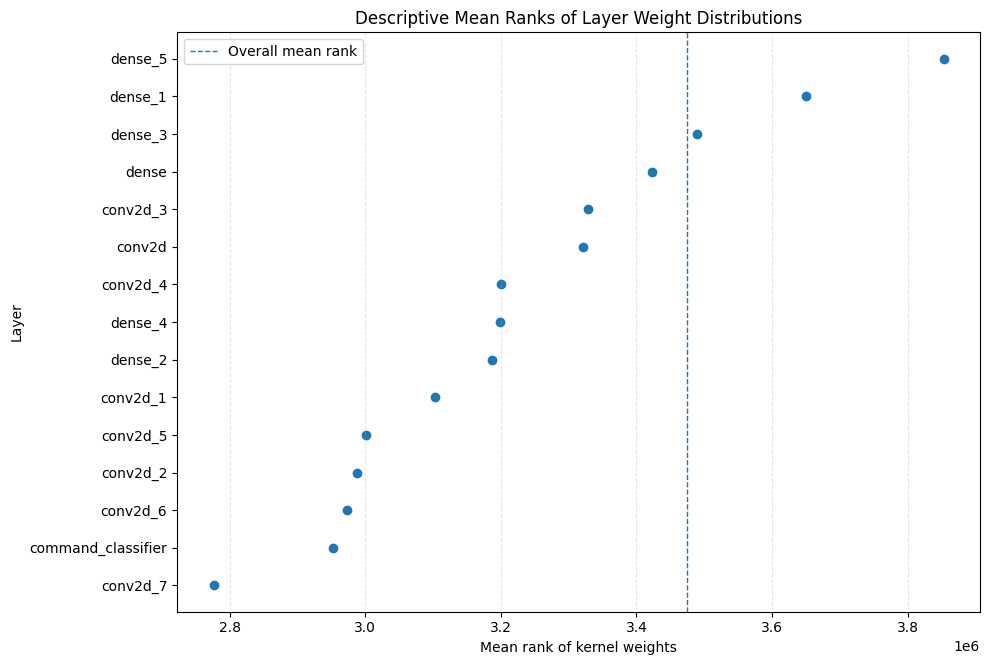

In [ ]:
fp32_model = load_fresh_model()

kruskal_results = compare_layer_distributions(
    fp32_model,
    alpha=0.05
)

Loaded canonical FP32 model:
/content/drive/MyDrive/results/revision_best_model.keras
Plot saved to: /content/drive/MyDrive/results/revision_weight_distributions.png


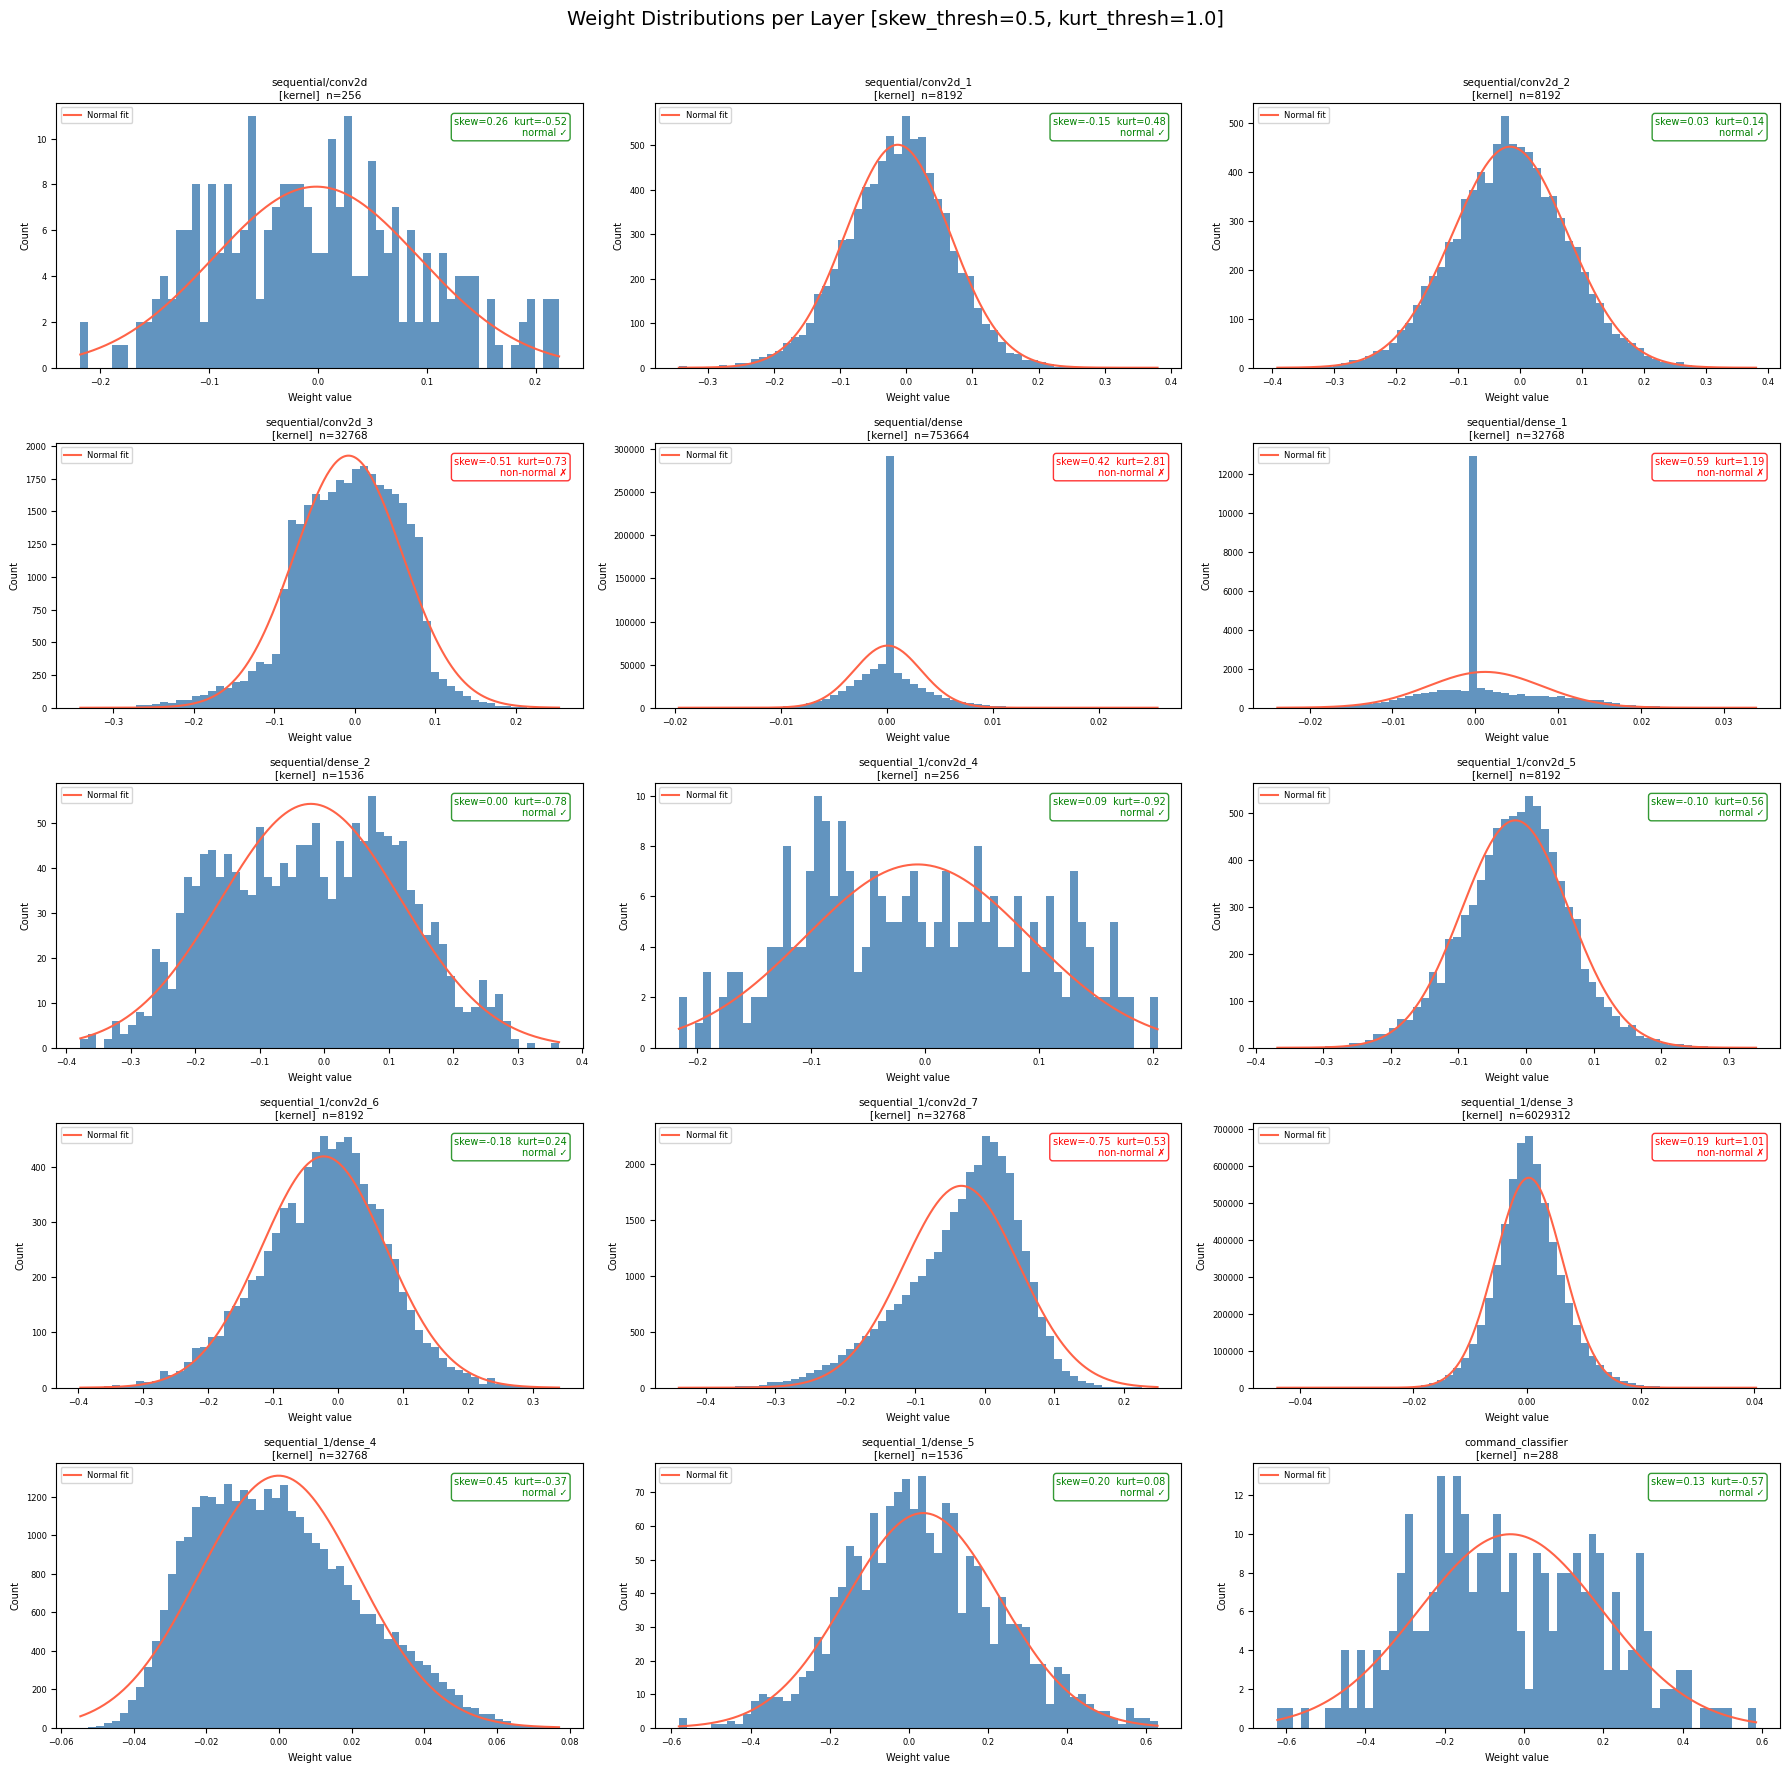


Layer                                                   Tensor      n weights     Skew     Kurt    Normal?
--------------------------------------------------------------------------------------------------------------
sequential/conv2d                                       kernel            256    0.261   -0.521          ✓
sequential/conv2d_1                                     kernel           8192   -0.152    0.485          ✓
sequential/conv2d_2                                     kernel           8192    0.027    0.141          ✓
sequential/conv2d_3                                     kernel          32768   -0.512    0.734          ✗
sequential/dense                                        kernel         753664    0.420    2.813          ✗
sequential/dense_1                                      kernel          32768    0.593    1.188          ✗
sequential/dense_2                                      kernel           1536    0.001   -0.782          ✓
sequential_1/conv2d_4           

In [ ]:
# ============================================================
# Weight distribution analysis — Canonical FP32 model
# ============================================================

# Load the canonical FP32 model
model = load_fresh_model()

print("Loaded canonical FP32 model:")
print("/content/drive/MyDrive/results/revision_best_model.keras")

# Plot and analyse kernel-weight distributions
plot_weight_distributions(
    model=model,
    bins=60,
    skew_threshold=0.5,
    kurt_threshold=1.0,
    save_path="/content/drive/MyDrive/results/revision_weight_distributions.png"
)

LAYER SENSITIVITY RANKING — 2-BIT PROBE
Dataset: fixed calibration subset
Metric:  Relative MSE of layer output
Rank 1:  least sensitive



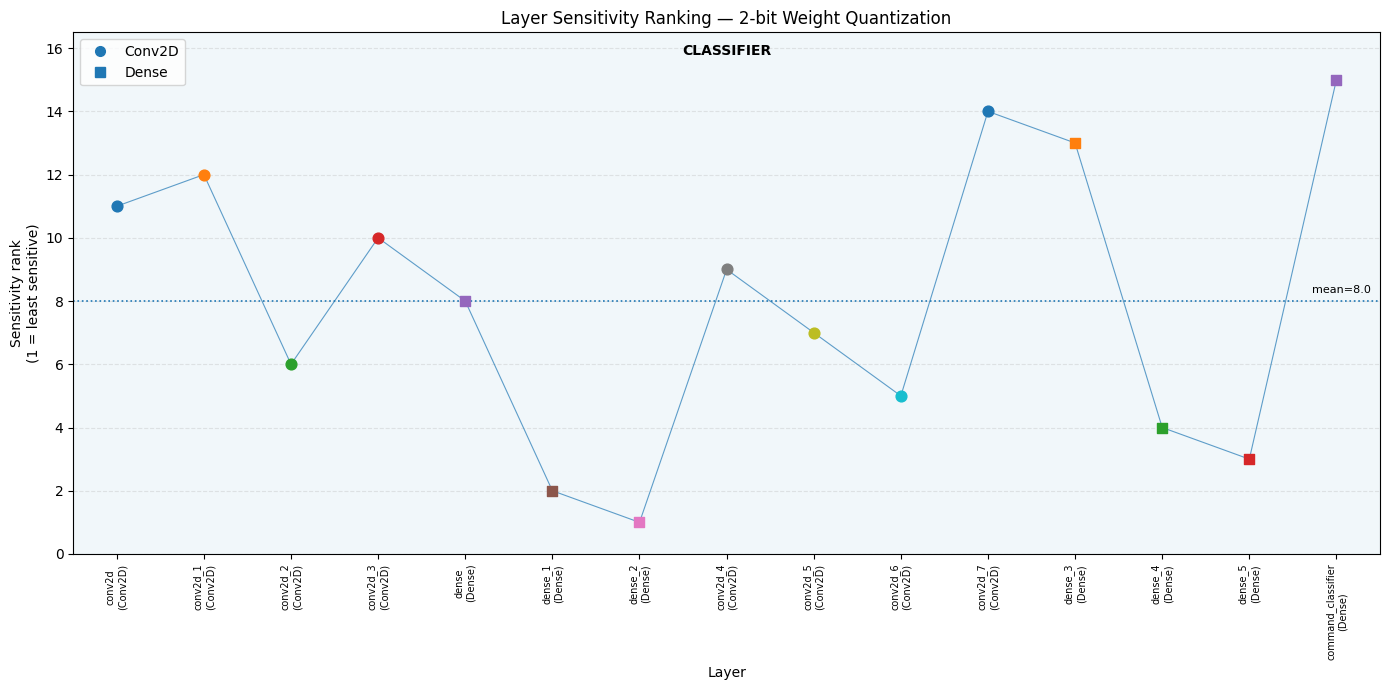


SENSITIVITY RANKING — 2-BIT (least → most sensitive)
 Rank Layer                  Section         Type           RelMSE      Weights
------------------------------------------------------------------------------
    1 dense_2                classifier      Dense        0.029683        1,536
    2 dense_1                classifier      Dense        0.053409       32,768
    3 dense_5                classifier      Dense        0.068571        1,536
    4 dense_4                classifier      Dense        0.069269       32,768
    5 conv2d_6               classifier      Conv2D       0.171853        8,192
    6 conv2d_2               classifier      Conv2D       0.209958        8,192
    7 conv2d_5               classifier      Conv2D       0.228211        8,192
    8 dense                  classifier      Dense        0.247672      753,664
    9 conv2d_4               classifier      Conv2D       0.279997          256
   10 conv2d_3               classifier      Conv2D       0.283472 

In [ ]:
model = load_fresh_model()

sensitivity_rank_df, sensitivity_section_summary = (
    plot_sensitivity_rank_by_section(
        base_model=model,
        calib_ds=calib_ds,
        num_bits=2
    )
)

Loaded canonical FP32 model:
/content/drive/MyDrive/results/revision_best_model.keras
WEIGHT DISTRIBUTION STATISTICS — CANONICAL FP32 MODEL
              name   type n_weights      std    range kurtosis    skew
            conv2d Conv2D       256 0.094708 0.439633  -0.5077  0.2629
          conv2d_1 Conv2D     8,192 0.078716 0.723545   0.4856 -0.1519
          conv2d_2 Conv2D     8,192 0.092981 0.772323   0.1422  0.0273
          conv2d_3 Conv2D    32,768 0.067249 0.594142   0.7345 -0.5121
             dense  Dense   753,664 0.003143 0.045211   2.8128  0.4202
           dense_1  Dense    32,768 0.006841 0.057727   1.1887  0.5930
           dense_2  Dense     1,536 0.139885 0.742101  -0.7803  0.0011
          conv2d_4 Conv2D       256 0.098186 0.419443  -0.9136  0.0948
          conv2d_5 Conv2D     8,192 0.079418 0.707577   0.5586 -0.0951
          conv2d_6 Conv2D     8,192 0.095804 0.736115   0.2438 -0.1828
          conv2d_7 Conv2D    32,768 0.082988 0.686441   0.5272 -0.7539
        

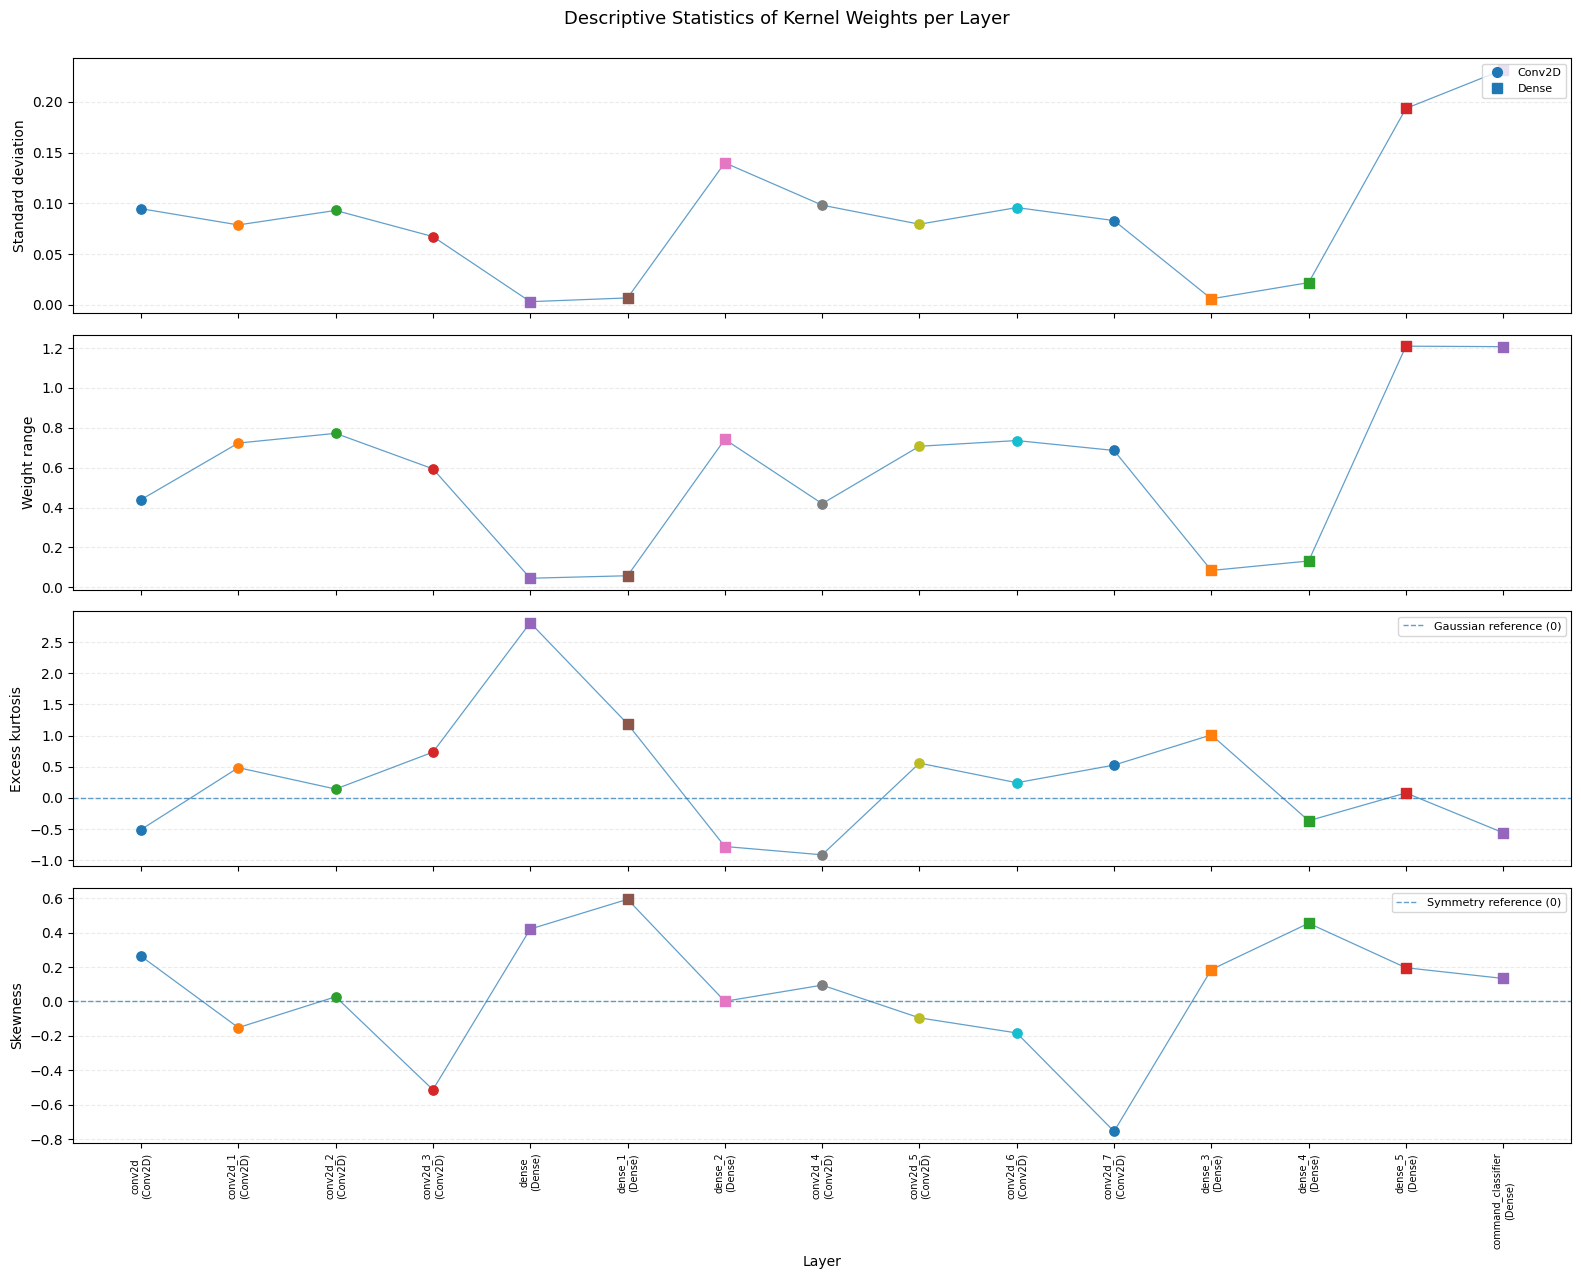


Weight statistics analysis complete.
Layers analysed: 15
Total kernel weights analysed: 6,950,688


In [ ]:
# ============================================================
# RUN — Weight distribution statistics
# ============================================================

# Always load the canonical FP32 checkpoint
model = load_fresh_model()

print("Loaded canonical FP32 model:")
print("/content/drive/MyDrive/results/revision_best_model.keras")

# Run descriptive weight analysis
weight_stats_df = plot_weight_statistics(
    model=model,
    save_path=(
        "/content/drive/MyDrive/results/"
        "revision_weight_statistics.png"
    )
)

print("\nWeight statistics analysis complete.")
print(f"Layers analysed: {len(weight_stats_df)}")
print(
    f"Total kernel weights analysed: "
    f"{weight_stats_df['n_weights'].sum():,}"
)

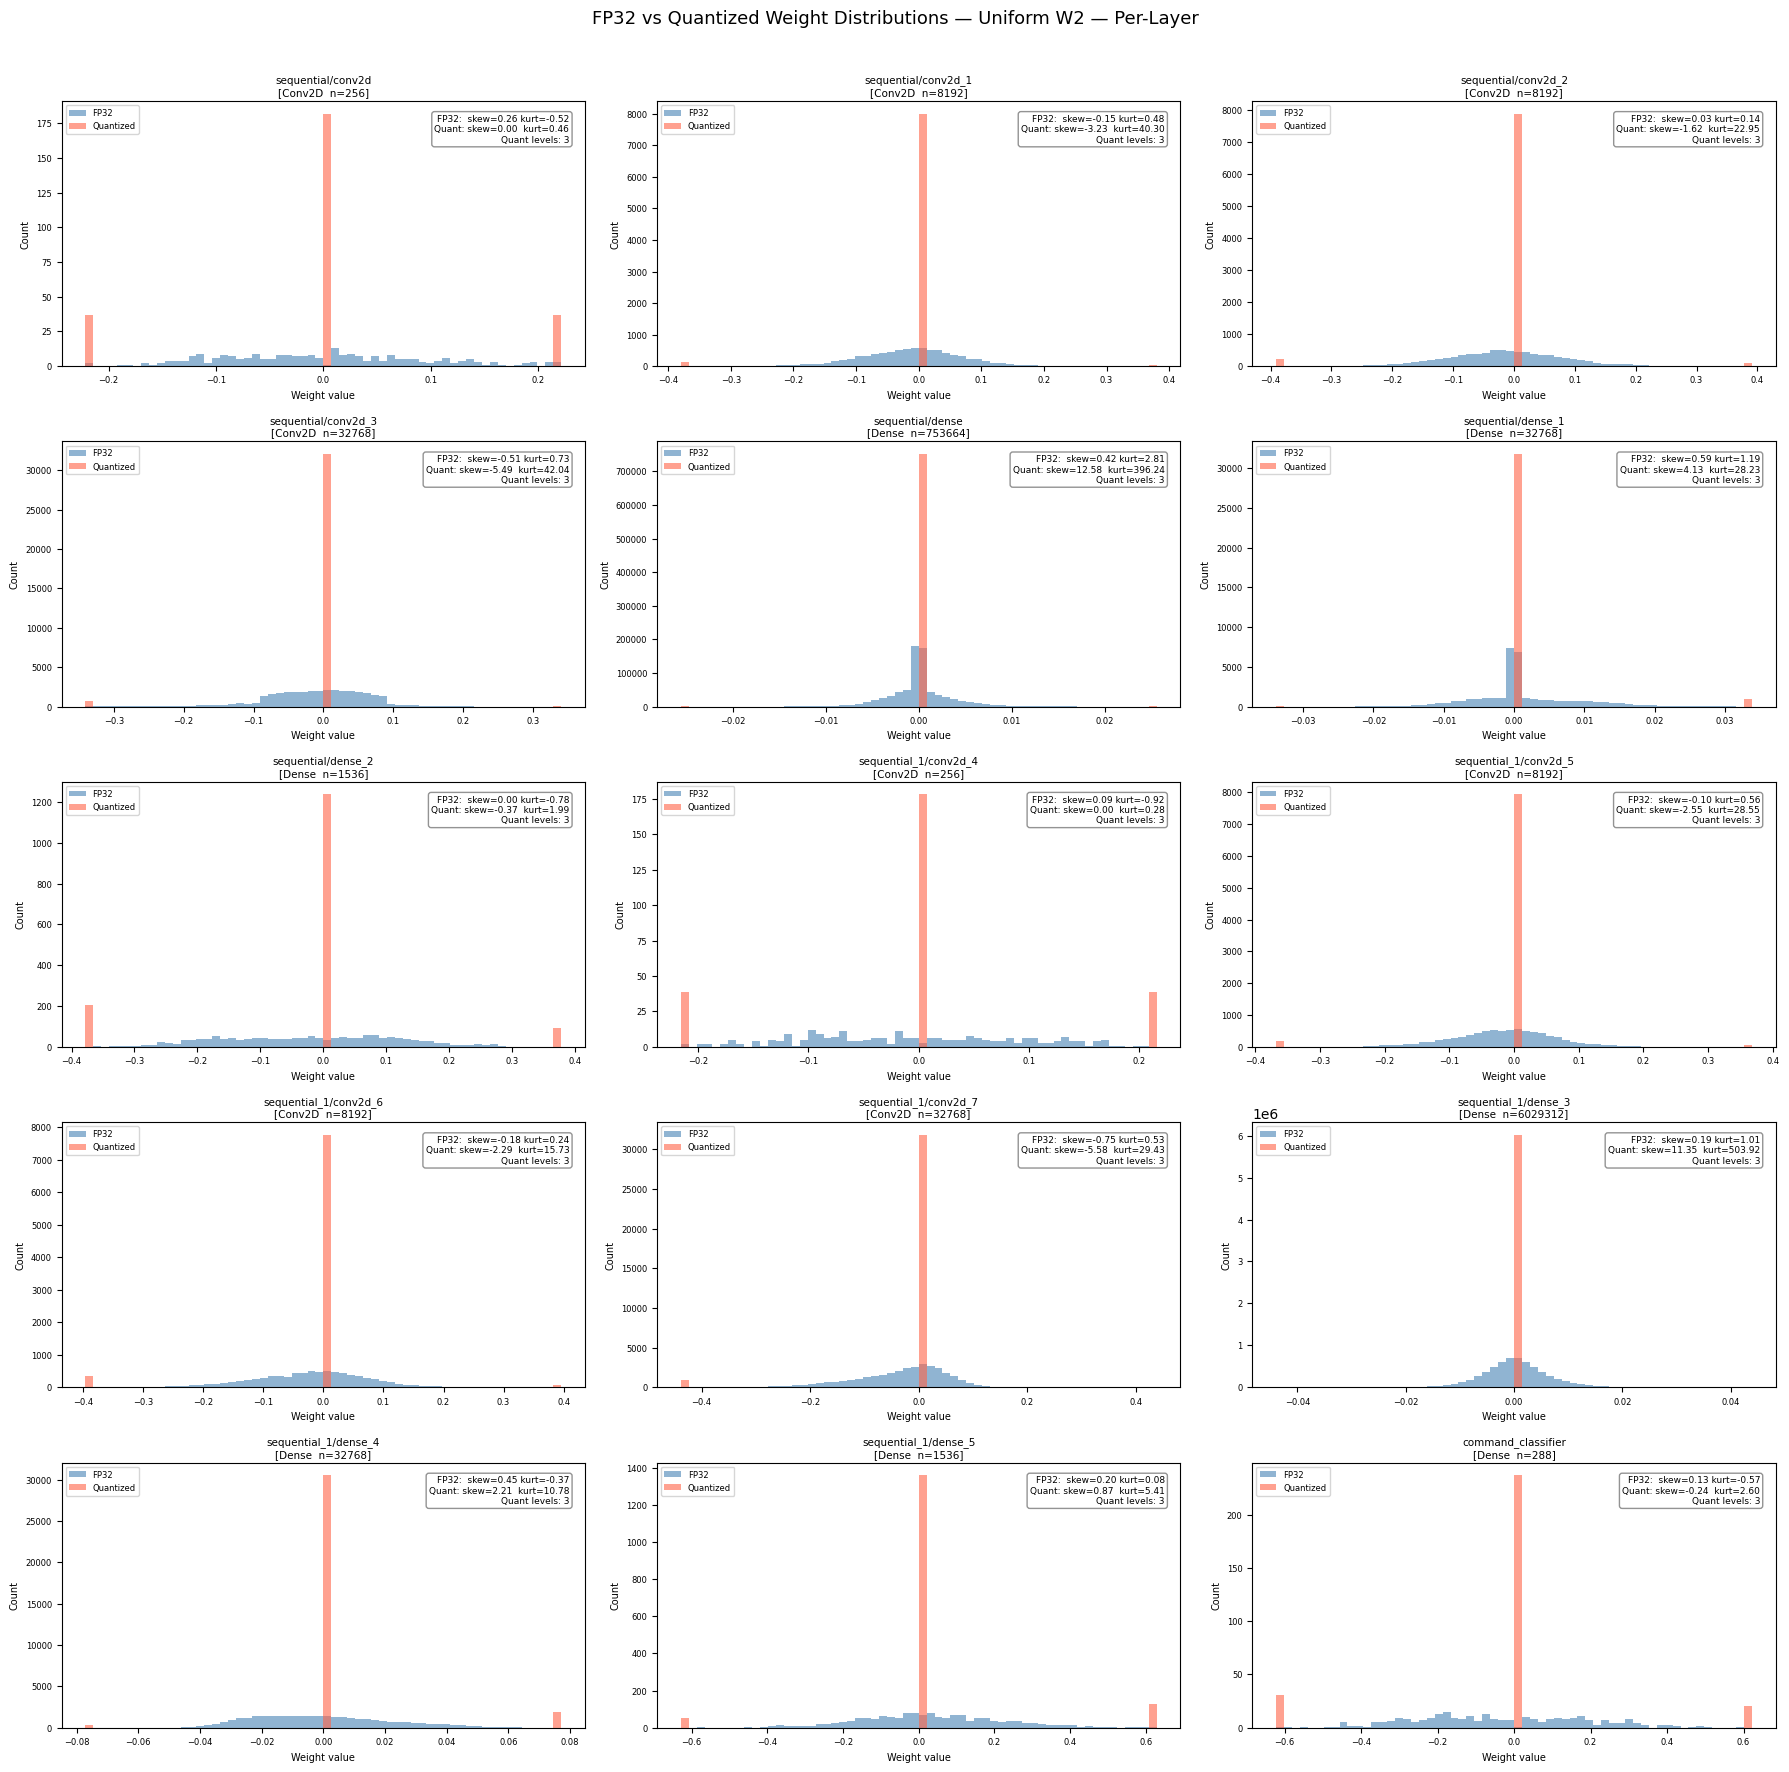


  PWLQ W2 (per-layer)
  conv2d                 Conv2D   → 2-bit (per_layer)
  conv2d_1               Conv2D   → 2-bit (per_layer)
  conv2d_2               Conv2D   → 2-bit (per_layer)
  conv2d_3               Conv2D   → 2-bit (per_layer)
  dense                  Dense    → 2-bit (per_layer)
  dense_1                Dense    → 2-bit (per_layer)
  dense_2                Dense    → 2-bit (per_layer)
  conv2d_4               Conv2D   → 2-bit (per_layer)
  conv2d_5               Conv2D   → 2-bit (per_layer)
  conv2d_6               Conv2D   → 2-bit (per_layer)
  conv2d_7               Conv2D   → 2-bit (per_layer)
  dense_3                Dense    → 2-bit (per_layer)
  dense_4                Dense    → 2-bit (per_layer)
  dense_5                Dense    → 2-bit (per_layer)
  command_classifier     Dense    → 2-bit (per_layer)

Quantization complete.


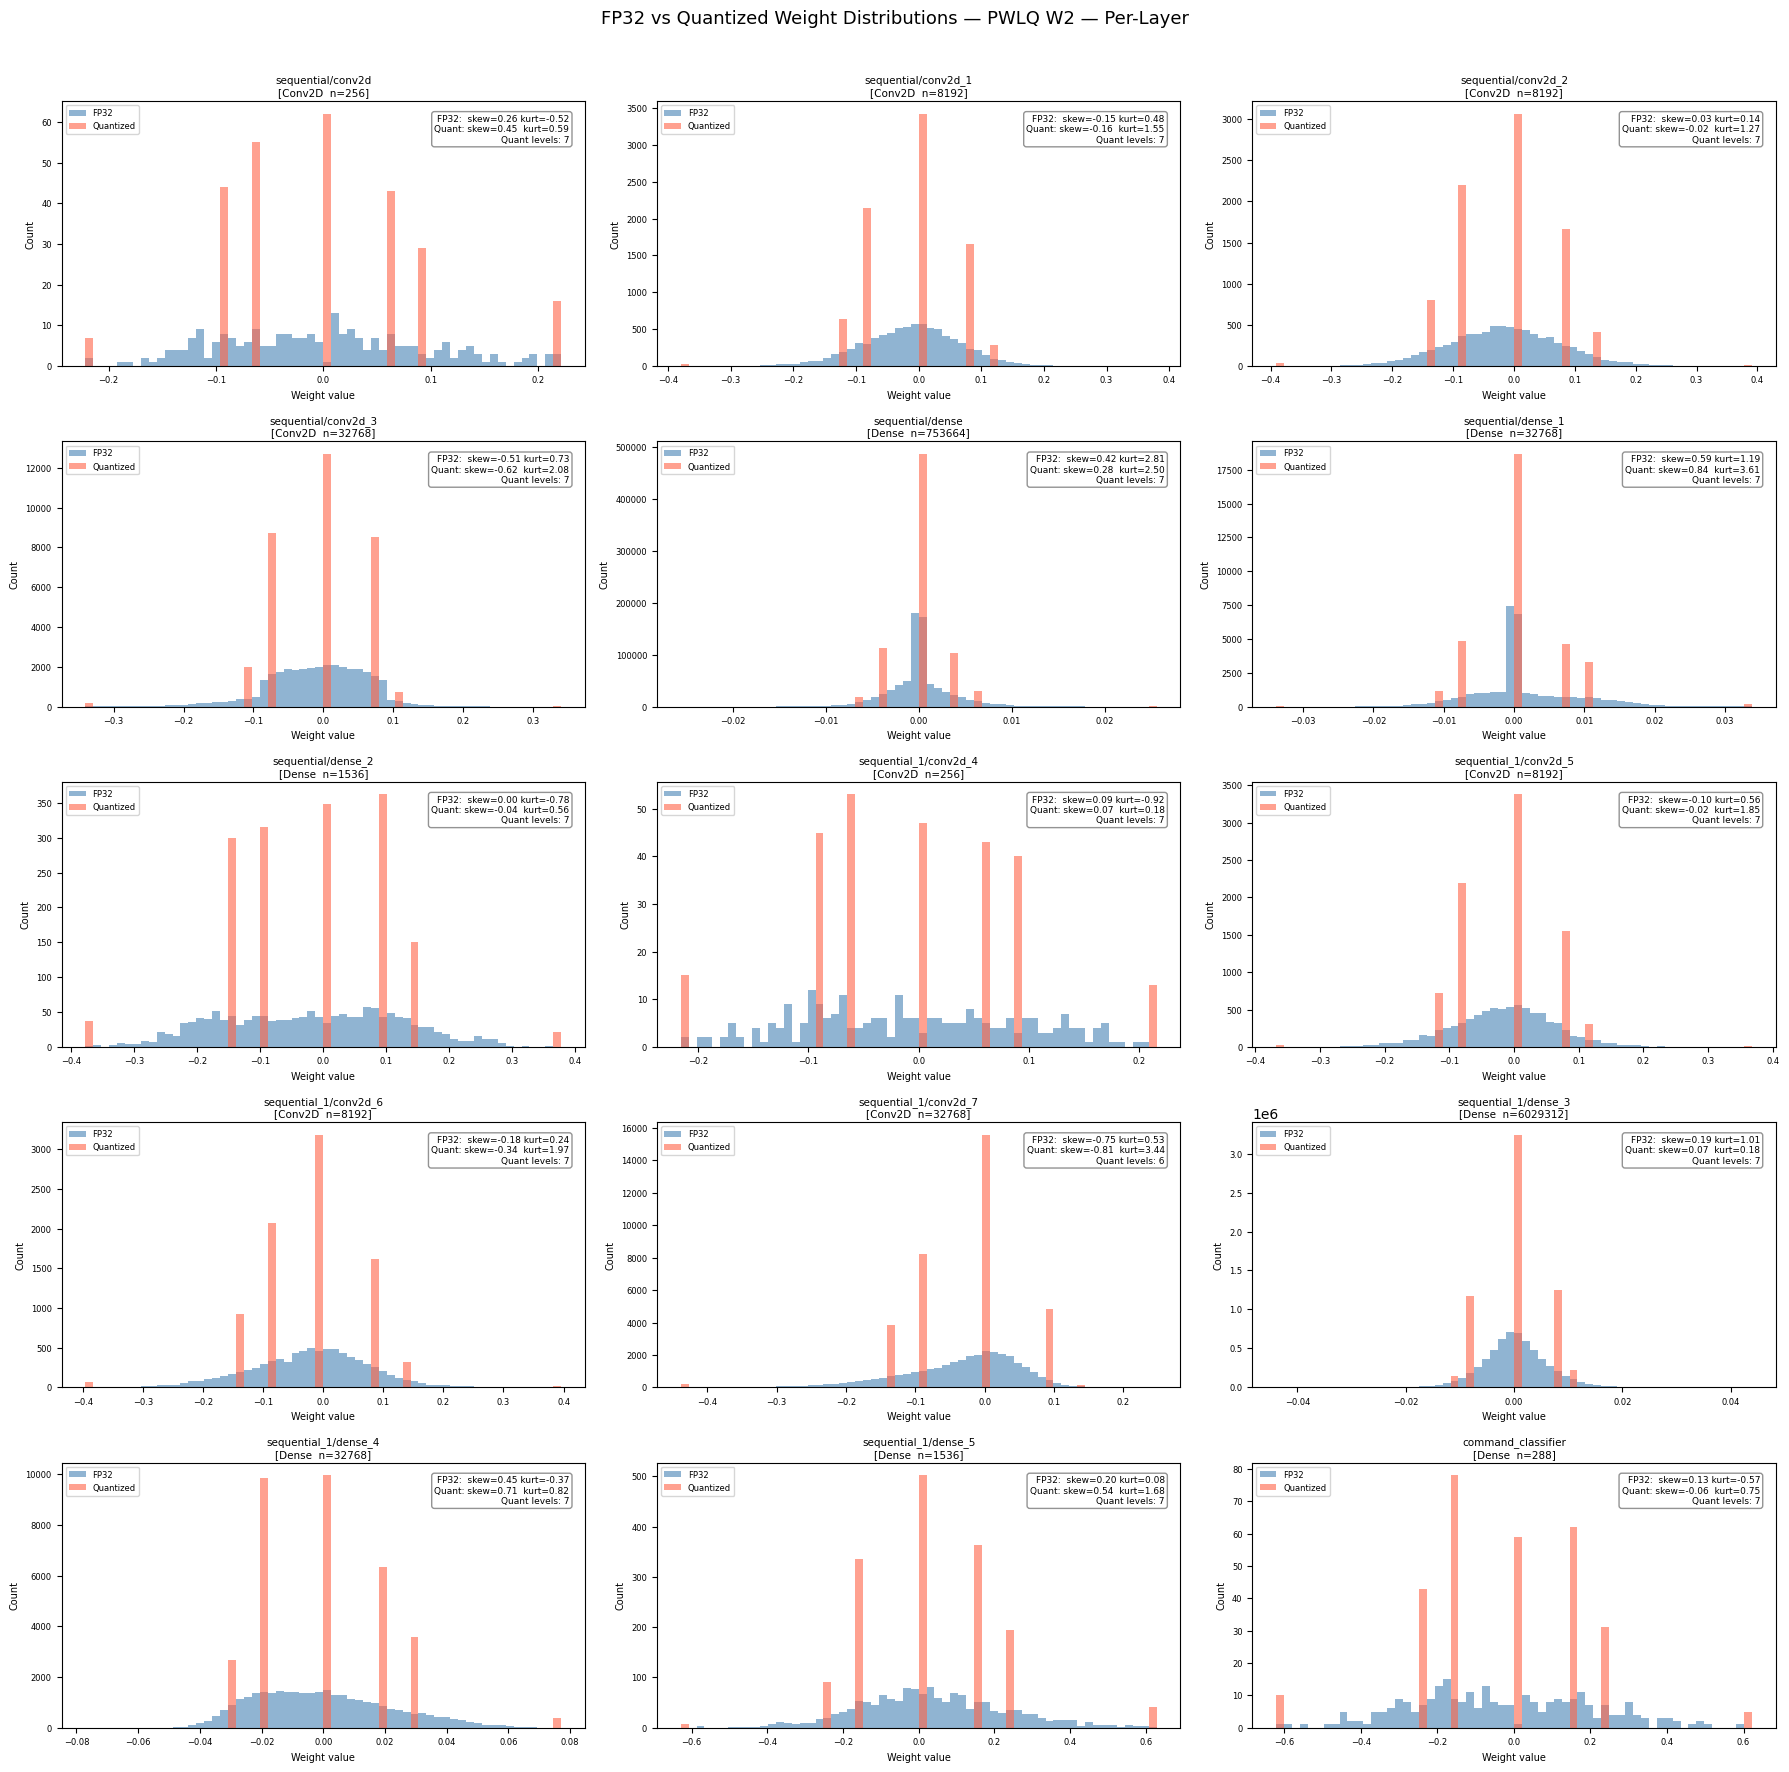

In [ ]:
# ============================================================
# WEIGHT DISTRIBUTION OVERLAP
# FP32 vs Uniform W2 (per-layer)
# FP32 vs PWLQ W2 (per-layer)
# ============================================================

BITS = 2

# ------------------------------------------------------------
# 1. Canonical FP32 reference
# ------------------------------------------------------------
fp32_model = load_fresh_model()


# ------------------------------------------------------------
# 2. Uniform quantization — W2, per-layer
# ------------------------------------------------------------
uniform_w2_model = load_fresh_model()

quantize_dequantize_uniform(
    uniform_w2_model,
    num_bits=BITS,
    verbose=False
)

plot_weight_distribution_comparison(
    fp32_model=fp32_model,
    quantized_model=uniform_w2_model,
    label="Uniform W2 — Per-Layer",
    bins=60
)


# ------------------------------------------------------------
# 3. PWLQ — W2, per-layer
# ------------------------------------------------------------
pwlq_w2_model = load_fresh_model()

quantize_model_pwlq(
    pwlq_w2_model,
    bits=BITS,
    granularity="per_layer",
    label="PWLQ W2 (per-layer)"
)

plot_weight_distribution_comparison(
    fp32_model=fp32_model,
    quantized_model=pwlq_w2_model,
    label="PWLQ W2 — Per-Layer",
    bins=60
)

Selected test example
---------------------
Class: off
File: /content/dataset/off/5fe4a278_nohash_3.wav

Feature information
-------------------
Waveform: (16000,) (1.000 s, 16000 Hz)
MFCC:  (98, 12)
MSLFB: (98, 40)

Expected model shapes:
MFCC_SHAPE: (98, 12)
MSLFB_SHAPE: (98, 40)


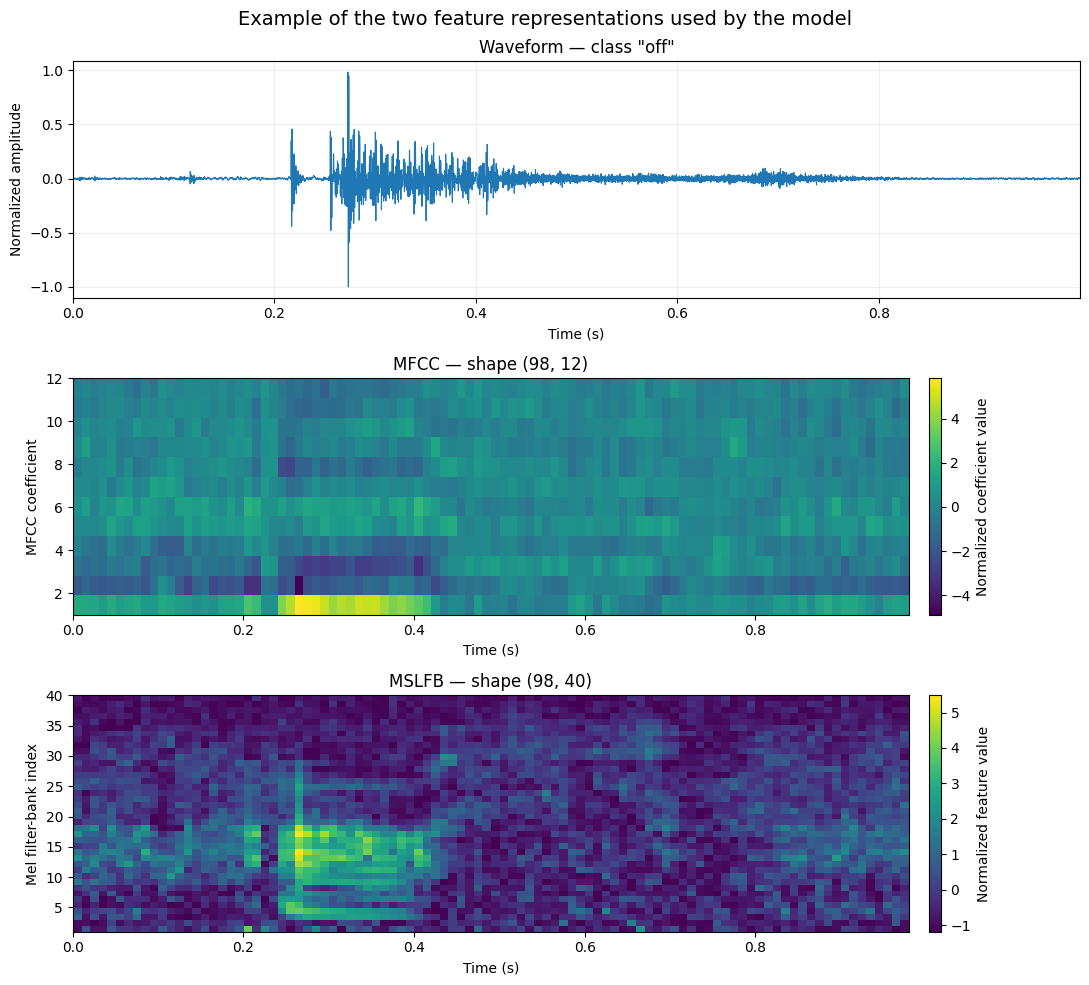

In [ ]:
# =========================================================
# VISUALIZE ONE MODEL INPUT:
# WAVEFORM + MFCC + MSLFB
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile


# ---------------------------------------------------------
# 1. SELECT ONE REAL TEST SAMPLE
# ---------------------------------------------------------

sample_idx = None

for i, path in enumerate(x_test_files):

    if isinstance(path, bytes):
        path = path.decode("utf-8")

    # Avoid synthetic/fixed silence example
    if path != "SILENCE" and str(path).endswith(".wav"):
        sample_idx = i
        break


if sample_idx is None:
    raise RuntimeError(
        "No real .wav sample was found in x_test_files."
    )


wav_path = x_test_files[sample_idx]

if isinstance(wav_path, bytes):
    wav_path = wav_path.decode("utf-8")


label_idx = int(y_test_labels[sample_idx])
class_name = le.classes_[label_idx]


print("Selected test example")
print("---------------------")
print("Class:", class_name)
print("File:", wav_path)


# ---------------------------------------------------------
# 2. LOAD ORIGINAL WAVEFORM
# ---------------------------------------------------------

sr, signal = wavfile.read(wav_path)

signal = signal.astype(np.float32)


# Normalize only for waveform visualization.
# This DOES NOT modify the features supplied to the model.
if np.max(np.abs(signal)) > 0:
    signal_plot = signal / np.max(np.abs(signal))
else:
    signal_plot = signal.copy()


time = np.arange(len(signal_plot)) / sr


# ---------------------------------------------------------
# 3. LOAD THE EXACT FEATURES USED BY THE MODEL
# ---------------------------------------------------------

mfcc_path = wav_path.replace(
    ".wav",
    "_mfcc.npy"
)

mslfb_path = wav_path.replace(
    ".wav",
    "_mslfb.npy"
)


mfcc_feat = np.load(
    mfcc_path
)

mslfb_feat = np.load(
    mslfb_path
)


# ---------------------------------------------------------
# 4. INFORMATION / DIMENSIONS
# ---------------------------------------------------------

print("\nFeature information")
print("-------------------")

print(
    f"Waveform: {signal.shape} "
    f"({len(signal) / sr:.3f} s, "
    f"{sr} Hz)"
)

print(
    f"MFCC:  {mfcc_feat.shape}"
)

print(
    f"MSLFB: {mslfb_feat.shape}"
)

print(
    "\nExpected model shapes:"
)

print(
    "MFCC_SHAPE:",
    MFCC_SHAPE
)

print(
    "MSLFB_SHAPE:",
    MSLFB_SHAPE
)


# ---------------------------------------------------------
# 5. TIME AXES FOR FEATURES
# ---------------------------------------------------------
#
# Your preprocessing uses:
# frame_size   = 25 ms
# frame_stride = 10 ms
#
# Therefore each feature row corresponds to one time frame.
# ---------------------------------------------------------

frame_stride = 0.01  # seconds

mfcc_times = (
    np.arange(mfcc_feat.shape[0])
    * frame_stride
)

mslfb_times = (
    np.arange(mslfb_feat.shape[0])
    * frame_stride
)


# ---------------------------------------------------------
# 6. PLOT
# ---------------------------------------------------------

fig, axes = plt.subplots(
    3,
    1,
    figsize=(11, 10)
)


# =========================================================
# A) WAVEFORM
# =========================================================

axes[0].plot(
    time,
    signal_plot,
    linewidth=0.8
)

axes[0].set_title(
    f'Waveform — class "{class_name}"'
)

axes[0].set_xlabel(
    "Time (s)"
)

axes[0].set_ylabel(
    "Normalized amplitude"
)

axes[0].set_xlim(
    0,
    time[-1]
)

axes[0].grid(
    alpha=0.2
)


# =========================================================
# B) MFCC
# =========================================================

im1 = axes[1].imshow(
    mfcc_feat.T,
    aspect="auto",
    origin="lower",
    extent=[
        mfcc_times[0],
        mfcc_times[-1] + frame_stride,
        1,
        mfcc_feat.shape[1]
    ]
)

axes[1].set_title(
    f"MFCC — shape {mfcc_feat.shape}"
)

axes[1].set_xlabel(
    "Time (s)"
)

axes[1].set_ylabel(
    "MFCC coefficient"
)

cbar1 = fig.colorbar(
    im1,
    ax=axes[1],
    pad=0.02
)

cbar1.set_label(
    "Normalized coefficient value"
)


# =========================================================
# C) MSLFB
# =========================================================

im2 = axes[2].imshow(
    mslfb_feat.T,
    aspect="auto",
    origin="lower",
    extent=[
        mslfb_times[0],
        mslfb_times[-1] + frame_stride,
        1,
        mslfb_feat.shape[1]
    ]
)

axes[2].set_title(
    f"MSLFB — shape {mslfb_feat.shape}"
)

axes[2].set_xlabel(
    "Time (s)"
)

axes[2].set_ylabel(
    "Mel filter-bank index"
)

cbar2 = fig.colorbar(
    im2,
    ax=axes[2],
    pad=0.02
)

cbar2.set_label(
    "Normalized feature value"
)


# ---------------------------------------------------------
# FINAL LAYOUT
# ---------------------------------------------------------

fig.suptitle(
    "Example of the two feature representations used by the model",
    fontsize=14
)

plt.tight_layout()

plt.show()